# ST1504: Deep Learning CA1 (Part B)
By: Goh Kun Ming

Class: DAAA/FT/2A/02

*Soli Deo Gloria*

---
# 1. Importing of Libaries

In this section, we will be importing all the required Libaries of the Deep Learning CA1. Most of the libaries will be from TensorFlow, Keras and various Data Analysis and Visualisation Libaries. These Libaries will be imported in the code cell below.

In [ ]:
# ==================== Installing Langdetect ==================== #
!pip install -q langdetect

# ==================== Installing Deep Translator ==================== #
!pip install -q deep-translator

# ==================== Installing tqdm ==================== #
!pip install -q tqdm

# ==================== Installing NLTK ==================== #
!pip install -q nltk

# ==================== Installing HuggingFace Transformers ==================== #
!pip install -q transformers

# ==================== Installing Keras Tuner ==================== #
!pip install -q keras-tuner

# ==================== Installing Keras Visual ==================== #
!pip install -q visualkeras

# ==================== Importing TensorFlow Models ==================== #
from tensorflow.keras.models import Sequential, load_model, Model

# ==================== Importing TensorFlow Layers ==================== #
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Bidirectional, Dropout, Dense, Input, BatchNormalization, Bidirectional, LeakyReLU

# ==================== Importing TensorFlow Utilities ==================== #
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, LearningRateScheduler, ModelCheckpoint
from tensorflow.keras.utils import plot_model

# ==================== Importing NLTK ==================== #
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ==================== Importing Sklearn Confusion Matrix ==================== #
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, silhouette_score, roc_curve, auc, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

# ==================== Importing Sklearn TSNE ==================== #
from sklearn.manifold import TSNE

# ==================== Importing Keras Regulariser ==================== #
from tensorflow.keras.regularizers import l2

# ==================== Importing Keras Tuner ==================== #
import keras_tuner as kt

# ==================== Importing Keras Visual ==================== #
import visualkeras

# ==================== Importing Keras Regulariser ==================== #
from tensorflow.keras import regularizers

# ==================== Importing Keras Optimiser ==================== #
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

# ==================== Importing Sklearn Train Test Split ==================== #
from sklearn.model_selection import train_test_split

# ==================== Importing Pandas ==================== #
import pandas as pd

# ==================== Importing NumPy ==================== #
import numpy as np

# ==================== Importing Matplotlib ==================== #
import matplotlib.pyplot as plt

# ==================== Importing Plotly ==================== #
import plotly.express as px

# ==================== Importing Seaborn ==================== #
import seaborn as sns

# ==================== Importing tqdm ==================== #
from tqdm import tqdm

# ==================== Importing DBSCAN ==================== #
from sklearn.cluster import DBSCAN

# ==================== Importing Langdetect ==================== #
from langdetect import detect

# ==================== Importing Deep Translator ==================== #
from deep_translator import GoogleTranslator

# ==================== Importing Transformers ==================== #
from transformers import pipeline, MarianMTModel, MarianTokenizer

# ==================== Importing Counter ==================== #
from collections import Counter

# ==================== Importing Regular Expressions ==================== #
import re

# ==================== Importing Operating System ==================== #
import os

# ==================== Importing Image ==================== #
from IPython.display import Image

# ==================== Importing Shutill ==================== #
import shutil

# ==================== Mounting Google Drive ==================== #
from google.colab import drive
drive.mount('/content/drive')

# ==================== Defining Paths ==================== #
DRIVE_ROOT = '/content/drive/MyDrive/Colab Notebooks/DELE CA1 B'
LOCAL_ROOT = '/content/DELE CA1 B'

# ==================== Copying Project Folder To Local SSD ==================== #
if os.path.exists(LOCAL_ROOT):
    shutil.rmtree(LOCAL_ROOT)
shutil.copytree(DRIVE_ROOT, LOCAL_ROOT)

# ==================== Switching To Local SSD ==================== #
os.chdir(LOCAL_ROOT)
print("Now working in:", os.getcwd())

# ==================== Final Confirmation ==================== #
print("Libraries Imported Successfully")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Now working in: /content/DELE CA1 B
Libraries Imported Successfully


With reference to the output above, we are able to confirm that the Libaries
have been successfully imported and we can move on to loading the dataset provided.

---
# 2. Data Cleaning

In this section, we will be loading the provided Movie Review Dataset and subsequently conduct quality checks and inspections to look out for abnormalies or Data Integrity Violations which will subsequently lead to the addressment. This is important as failure to do so will cause the Model to under-perform as compared to the standard expected.

---

## 2.1 Loading of Dataset

In this sub-section, we will be loading the Dataset provided into the Local Environment. This operation will be done in the Code Cell below.

In [ ]:
# ==================== Loading of Dataset ==================== #
df = pd.read_csv("./Dataset (B)/Movie reviews.csv")

# ==================== Loading of Dataset ==================== #
df.head(10).style.background_gradient(cmap="Blues")

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/style.py:3807: RuntimeWarning:

All-NaN slice encountered

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/style.py:3808: RuntimeWarning:

All-NaN slice encountered



,Review,Score,"Are there ways for you to generate more data? Spliting up sentences, would that help?",Language
0,Filem ini hebat! Aksi yang mendebarkan dan plot yang mengejutkan.,0.100000,nan,Malay
1,Filem ini hebat! Aksi yang mendebarkan dan plot yang mengejutkan.,0.900000,nan,Malay
2,Filem ini hebat! Aksi yang mendebarkan dan plot yang mengejutkan.,0.500000,nan,Malay
3,"Sayang sekali, pelakon tidak memberikan persembahan terbaik. Kurang puas hati.",0.800000,nan,Malay
4,Jalan cerita yang kompleks dan penuh emosi. Sungguh menghiburkan!,0.200000,nan,Malay
5,Pembuat filem berjaya memberikan pengalaman yang tidak terlupakan. Sungguh memukau!,0.050000,nan,Malay
6,Adegan aksi yang terlalu banyak dan mengejutkan. Terkadang agak terlalu banyak.,0.400000,nan,Malay
7,Saya teruja sepanjang filem. Penceritaan yang menarik!,0.150000,nan,Malay
8,Avengers: Endgame mengecewakan dan membosankan. Terlalu banyak klise.,0.850000,nan,Malay
9,Integrasi elemen fiksyen sains sangat menarik. Saya suka!,0.250000,nan,Malay


With reference to the output above, we are able to see that the Data have been successfully loaded in and there are a total of 4 Features within the Data. The observations have been listed below

**Review**
- Textual Data
- Needs to be Pre-processed

**Score**
- Numerical Data
- Will most likely be what we will be predicting

**Are there ways for you to generate more data? Spliting up sentences, would that help?**
- Miscellaneous Data
- Needs to be dropped

**Language**
- Categorical Data
- Suggests there are other Languages

With the observations listed above, we will proceed to check for Missing Data and any Abnormallies before moving on the Data Analysis and Visualisations.

---

## 2.2 Checking for Missing Data

Before conducting Data Visualisations, we will firstly be inspecting the Dataset to check for Missing Data. Should there be Missing Data present, we will have to impute the Missing Data or determine the best course of action to undertake with reference to the presented case.

In [ ]:
# ==================== Creating NaN Summary Table ==================== #
def highlight_nan_summary(val):
    color = 'red' if val > 0 else 'green'
    return f'background-color: {color}; color: white'

# ==================== Creating Missing Value DataFrame ==================== #
nan_summary = df.isnull().sum().to_frame(name='Missing Values')

# ==================== Applying Colour Coding ==================== #
styled_summary = nan_summary.style.map(highlight_nan_summary)

# ==================== Displaying DataFrame ==================== #
styled_summary

,Missing Values
Review,0
Score,2
"Are there ways for you to generate more data? Spliting up sentences, would that help?",527
Language,0


With reference to the Output of the DataFrame above, we are able to see that there are indeed missing values within the Dataset provided. The observations are listed below.

**Observations**
- Score has 2 Missing Values
- The Miscellanous Data has the most missing values but it can be disregarded as we already intend to drop it.

**Action Plan**
- Inspect the Data Rows with the Missing Score Value and determine the best course of action to address the Missing Data.

With the Observations and Action Plan indicated, we will proceed to inspect the Missing Score Data.

---

### 2.2.1 Inspecting Missing Score Data

We will be inspecting the Data Rows with the Missing Score Data to determine whether the Data Row is a Legitimate Data or not and if it will impact the integrity and accuracy of the RNN Model.

In [ ]:
# ==================== Highlighting Rows with Missing Score in Red ==================== #
def highlight_missing_score(row):
    return ['background-color: red; color: white' if pd.isna(row['Score']) else '' for _ in row]

# ==================== Creating DataFrame ==================== #
styled_missing_rows = df[df['Score'].isna()].style.apply(highlight_missing_score, axis=1)

# ==================== Displaying DataFrame ==================== #
styled_missing_rows

,Review,Score,"Are there ways for you to generate more data? Spliting up sentences, would that help?",Language
426,Ni hao,nan,nan,Chinese
493,Diabolic,nan,nan,English


With reference to the output of the DataFrame with the Missing Score Data above, we are able to identify that the Data Rows with the Missing Score Data are **Illegitimate Data**. Therefore, the best course of action to undertake is to **Drop The Data Rows**. This operation will be conducted in the next Code Cell.

---

### 2.2.2 Addressing Missing Data

In this section, we will be Addressing both the Miscellanous Data Columns filled with Missing Data and the Missing Score Data. The Course of Action that we will be undertaking is **Dropping of Data Column and Data Row**. This will be done in the Code Cell below.

In [ ]:
# ==================== Dropping Miscellaneous Data Column ==================== #
df = df.drop(columns=['Are there ways for you to generate more data? Spliting up sentences, would that help?'])

# ==================== Dropping Data Rows with Missing Score ==================== #
df = df[df['Score'].notna()].reset_index(drop=True)

# ==================== Final Confirmation ==================== #
def highlight_nan_summary(val):
    color = 'red' if val > 0 else 'green'
    return f'background-color: {color}; color: white'

# ==================== Creating Missing Value DataFrame ==================== #
nan_summary = df.isnull().sum().to_frame(name='Missing Values')

# ==================== Applying Colour Coding ==================== #
styled_summary = nan_summary.style.map(highlight_nan_summary)

# ==================== Displaying DataFrame ==================== #
styled_summary

,Missing Values
Review,0
Score,0
Language,0


With reference to the output above, we are able to confirm that the Miscellanous Data Column have been dropped successfully and the Missing Data for Score have been successfully removed. We are also able to visually confirm that there are no Missing Values remaining in the Dataset.

---

## 2.3 Identifying Duplicated Data

In this sub-section, we will be indentifying for Duplicated Data within our Dataset. Duplicated Data can cause many issues for our RNN Model such as Overfitting instead of generalising patterns. Therefore, it is of utmost importance that we identify Duplicated Data within our Dataset.

In [ ]:
# ==================== Creating Duplicate Summary ==================== #
duplicate_count = df.duplicated().sum()
summary_df = pd.DataFrame({'Duplicate Count': [duplicate_count]})

# ==================== Colour Coding Function ==================== #
def highlight_duplicates(val):
    color = 'red' if val > 0 else 'green'
    return f'background-color: {color}; color: white'

# ==================== Apply Styling ==================== #
styled_summary = summary_df.style.map(highlight_duplicates)

# ==================== Display Summary ==================== #
styled_summary


,Duplicate Count
0,111


With reference to the Output of the DataFrame above, we are able to see that there are indeed **Duplicated Data Indentified** within our Dataset. Therefore, the best course of action in this case is to **Drop all Duplicated Data**.

---
### 2.3.1 Removing Duplicated Data

In this section, we will be removing the Duplicated Data Rows as identified in the parent sub-section. This will directly prevent our RNN Model from Overfitting and improve the overall performance. The operation to reove the Duplicated Data is done in the Code Cell below.

In [ ]:
# ==================== Dropping Duplicate Rows ==================== #
df = df.drop_duplicates().reset_index(drop=True)

# ==================== Creating Duplicate Summary ==================== #
duplicate_count = df.duplicated().sum()
summary_df = pd.DataFrame({'Duplicate Count': [duplicate_count]})

# ==================== Colour Coding Function ==================== #
def highlight_duplicates(val):
    color = 'red' if val > 0 else 'green'
    return f'background-color: {color}; color: white'

# ==================== Apply Styling ==================== #
styled_summary = summary_df.style.map(highlight_duplicates)

# ==================== Display Summary ==================== #
styled_summary

,Duplicate Count
0,0


With reference to the output above, we are able to determine that we have successfully removed all the Duplicated Data and we are able to proceed to the next step of Data Cleaning.

---
## 2.4 Identifying Short-Worded Reviews

In this sub-section, we will be identifying reviews which have **less than 4 words**. Reviews with little words can be problematic when training a RNN model as it will cause an introduction in noise in both Classification and Regression as they often lack semantic richness. Therefore, it is important that we remove these data.

In [ ]:
# ==================== Counting Reviews with < 4 Words ==================== #
df['word_count'] = df['Review'].apply(lambda x: len(str(x).split()))
short_review_count = (df['word_count'] < 4).sum()

# ==================== Creating Summary DataFrame ==================== #
short_summary_df = pd.DataFrame({'Reviews with < 4 words': [short_review_count]})

# ==================== Applying Colour Styling ==================== #
def highlight_short(val):
    color = 'red' if val > 0 else 'green'
    return f'background-color: {color}; color: white'

styled_short_summary = short_summary_df.style.map(highlight_short)

# ==================== Displaying DataFrame ==================== #
styled_short_summary

,Reviews with < 4 words
0,111


With reference to the output above, we are able to see that there are a total of **111 Data Rows** with less than 4 Words for its review. Therefore, to ensure the Model does not get introduced to noisy data, we will proceed to remove these Data Rows in the next section.

---
### 2.4.1 Addressing Short-Worded Reviews

As previously identified, there are multiple Short-Worded Reviews within the Dataset which can cause Noise to be introduced to the RNN Model. Therefore, to address this issue, we will be removing the Data Rows with less than 4 words for its review. This operation will be conducted in the Code Cell below.

In [ ]:
# ==================== Removing Very Short Reviews ==================== #
df['word_count'] = df['Review'].apply(lambda x: len(str(x).split()))
df = df[df['word_count'] >= 4].reset_index(drop=True)

# ==================== Counting Reviews with < 4 Words ==================== #
df['word_count'] = df['Review'].apply(lambda x: len(str(x).split()))
short_review_count = (df['word_count'] < 4).sum()

# ==================== Creating Summary DataFrame ==================== #
short_summary_df = pd.DataFrame({'Reviews with < 4 words': [short_review_count]})

# ==================== Applying Colour Styling ==================== #
def highlight_short(val):
    color = 'red' if val > 0 else 'green'
    return f'background-color: {color}; color: white'

styled_short_summary = short_summary_df.style.map(highlight_short)

# ==================== Displaying DataFrame ==================== #
styled_short_summary

,Reviews with < 4 words
0,0


With reference to the output of the DataFrame above, we are able to visually confirm that the Data Rows with reviews of less than 4 words have been successfully removed.

---
## 2.5 Creating Labelling

In this sub-section, we will be creating the Labelling so as to open the doors for Classification to be used. However, it is important to know that even though this is done so that Classification may be used, we are not fixed on using Classification yet as we are also able to utilise Regression. The decision will only be made at the end of the assessment. The Labelling's Bin will be determined using DBSCAN which will be unbiased as it is an Unsupervised Learning method.

---
### 2.5.1 Fixing of Score

As previosuly identified, the Scores were perceived wrongly as higher score implies positive and vice-versa. However, this was false as seen from the Sorted DataFrame. Therefore a change will now be conducted in the Code Cell below to Invert the Score so that it will be more universally understandable to prevent future misconception.

In [ ]:
# ==================== Inverting Score (Higher = Positive) ==================== #
df['Score'] = 1 - df['Score']

# ==================== Displaying DataFrame ==================== #
df.sort_values(by="Score").head(20).style.background_gradient(cmap="Blues")

,Review,Score,Language,word_count
1,Filem ini hebat! Aksi yang mendebarkan dan plot yang mengejutkan.,0.100000,Malay,10
74,Avengers: Endgame mengecewakan dan terlalu klise. Tidak menyeronokkan.,0.150000,Malay,8
121,Avengers: Endgame is disappointing and too cliché. Not enjoyable.,0.150000,English,9
107,Avengers: Endgame mengecewakan dan terlalu klise. Kurang memuaskan.,0.150000,Malay,8
8,Avengers: Endgame mengecewakan dan membosankan. Terlalu banyak klise.,0.150000,Malay,8
203,This film is highly disappointing. It fails to live up to the hype.,0.200000,English,13
61,Filem ini mengecewakan dan tidak sepadan dengan waktu saya. Terlalu biasa.,0.200000,Malay,11
3,"Sayang sekali, pelakon tidak memberikan persembahan terbaik. Kurang puas hati.",0.200000,Malay,10
171,Lack of character development makes this film weak. Not satisfying.,0.200000,English,10
145,This film is very disappointing. Not worth the hype.,0.200000,English,9


With reference to the Output above, we are able to see that the Ternary Label and Score have been successfully inverted and we are able to proceed with the corrected Dataset.

---
### 2.5.2 Density-Based Spatial Clustering of Applications with Noise (DBSCAN) - Silhouette Method

In this section, we will be utilising the Silhouette Method to find the ideal number of Episilon for the DBSCAN. Through the Silhouette Method, we will be able to ensure the Clustering for the DBSCAN is robust and able to identify the Clusters accordingly. We will find the ideal number of Episilon before utilising DBSCAN.

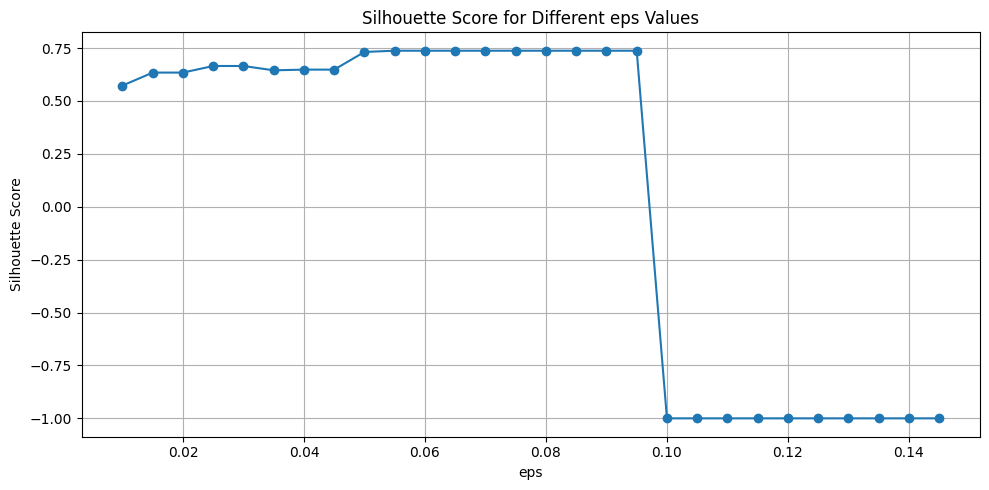

In [ ]:
eps_values = np.arange(0.01, 0.15, 0.005)
silhouette_scores = []

# ==================== Prepare Scores ==================== #
scores = df['Score'].values.reshape(-1, 1)

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=10).fit(scores)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters > 1:
        score = silhouette_score(scores, labels)
    else:
        score = -1
    silhouette_scores.append(score)

# ==================== Plotting Silhouette vs Epsilon ==================== #
plt.figure(figsize=(10, 5))
plt.plot(eps_values, silhouette_scores, marker='o')
plt.title("Silhouette Score for Different eps Values")
plt.xlabel("eps")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

With reference to the Code Cell above, we are able to see that the ideal number of Episilon is 0.09. This is evident as 0.09 was the last Episilon shown in the Line Graph before it decreased sharply in Silhouette Score. With this observation and value of Episilon found, we will proceed to conduct the DBSCAN while utilising the Episilon of 0.09 in the next section.

---
### 2.5.3 Density-Based Spatial Clustering of Applications with Noise (DBSCAN) - Clustering

In this section, we will be utilising DBSCAN to find the appropriate Binning for the various Category for Labelling. DBSCAN is utlised so as to ensure that the Labelling is fair and do not cause a bias in the Classification especially when a Class will naturally have more Data compared to the other class. The DBSCAN with the Ideal Episilon will be conducted in the Code Cell below.

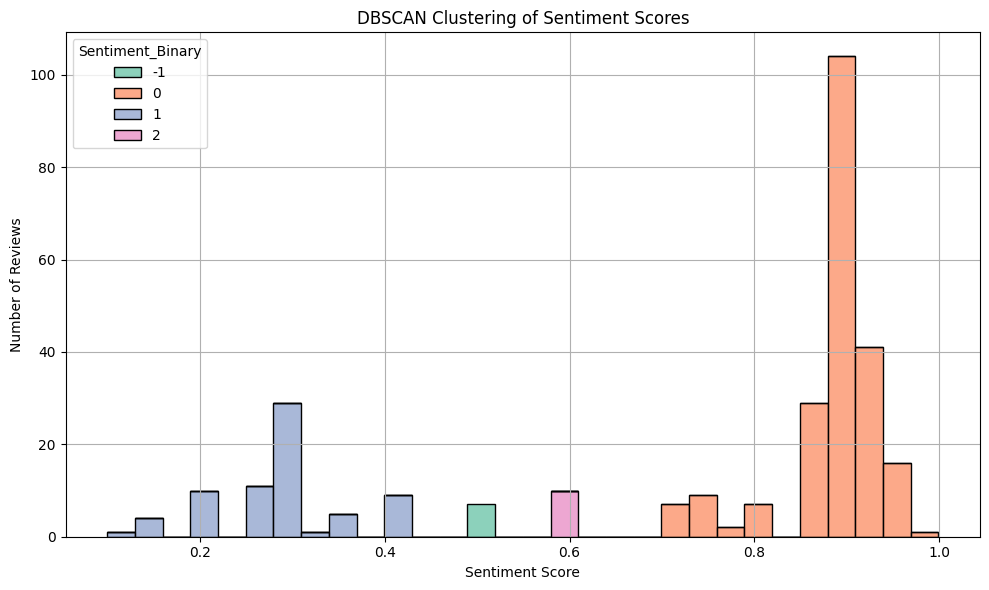

In [ ]:
# ==================== Reshape Scores ==================== #
scores = df['Score'].values.reshape(-1, 1)

# ==================== Run DBSCAN ==================== #
dbscan = DBSCAN(eps=0.09, min_samples=10)
clusters = dbscan.fit_predict(scores)

# ==================== Add Cluster Labels to DataFrame ==================== #
df['Sentiment_Binary'] = clusters

# ==================== Visualise Clusters ==================== #
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Score', hue='Sentiment_Binary', bins=30, palette='Set2', multiple='stack')
plt.title('DBSCAN Clustering of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Number of Reviews')
plt.grid(True)
plt.tight_layout()
plt.show()

With reference to the Code Cell above, we are able to see the binning of the various clusters by the DBSCAN. These Binnings have been determined with reference to the overall Density of the Score within the Dataset. However, we are able to also see a few small Clusters which could possibly indicate noise and will not be able to tell us much information. Thus the small clusters will be dropped. Therefore, these binnings shall be perceived as un-biased and will be utilised within the Labelling Binning

---
### 2.5.4 Binary-Label Creation

As identified in the previous Code Cell, we will now create the Binary-Labels for the identified 'Strong' Clusters. This will result in a Binary-Labelling as there are only 2 Strong Clusters which will become the Positive and Negative. This operation will be conducted in the Code Cel below.

In [ ]:
# ==================== Filter Only Reliable Clusters ==================== #
df = df[df['Sentiment_Binary'].isin([0, 1])].copy()

# ==================== Assign Ternary Labels ==================== #
cluster_to_label = {
    1: 'Negative',
    0: 'Positive'
}

df['Sentiment_Label'] = df['Sentiment_Binary'].map(cluster_to_label)

# ==================== Displaying DataFrame ==================== #
df.head(5).style.background_gradient(cmap="Blues")

,Review,Score,Language,word_count,Sentiment_Binary,Sentiment_Label
0,Filem ini hebat! Aksi yang mendebarkan dan plot yang mengejutkan.,0.900000,Malay,10,0,Positive
1,Filem ini hebat! Aksi yang mendebarkan dan plot yang mengejutkan.,0.100000,Malay,10,1,Negative
3,"Sayang sekali, pelakon tidak memberikan persembahan terbaik. Kurang puas hati.",0.200000,Malay,10,1,Negative
4,Jalan cerita yang kompleks dan penuh emosi. Sungguh menghiburkan!,0.800000,Malay,9,0,Positive
5,Pembuat filem berjaya memberikan pengalaman yang tidak terlupakan. Sungguh memukau!,0.950000,Malay,10,0,Positive


With reference to the output above, we are able to verify that we have successfully created the 'Sentiment_Ternary' Data Column that can be used for Classification.

---
## 2.6 Addressing Duplicated Review

As shown in the various previews of the Data, we are able to see that there are duplicated values within the 'Review' Data Column despite there being differences in the Sentiment Score. Therefore to address this issue and to prevent the RNN from learning the same Review but with different Binary Label / Sentiment Score, we will only include the mean score for the same review in the Dataset. This operation will be conducted in the Code Cell below.

In [ ]:
# ==================== Grouping by Review Text ==================== #
original_size = len(df)

# Keep all non-duplicated fields by taking the first value, except for Score (use mean)
agg_dict = {col: 'first' for col in df.columns if col not in ['Review', 'Score']}
agg_dict['Score'] = 'mean'

df = df.groupby('Review', as_index=False).agg(agg_dict)
deduped_size = len(df)

# ==================== Display Summary ==================== #
df_dedup_summary = pd.DataFrame({
    'Stage': ['Before Deduplication', 'After Deduplication'],
    'Review Count': [original_size, deduped_size],
    'Removed': [0, original_size - deduped_size]
})

df_dedup_summary.style.background_gradient(cmap="Blues")

,Stage,Review Count,Removed
0,Before Deduplication,286,0
1,After Deduplication,279,7


With reference to the Output above, we are able to verify that the Duplicated Review have been successfully addressed and we are able to proceed to the Exploratory Data Analysis.

---

# 3. Exploratory Data Analysis

In this section, we will be conducting Visualisations on our Cleaned Dataset to determine the best way forward for the Training of Models and also to understand where our Data might be weak in and how we can potentially compensate for it. This section will be separated into 2 different section, one for Classification and the other for Regression. This is because we have not yet decided whether we want to perfrom Classification or Regression on our Data.

---
## 3.1 Overview Visualisation

In this sub-section, we will be mainly focusing on the Data Visualisation that are relevant to the Dataset as a whole. Through this sub-section, we hope to better understand our data and what can we do to better improve the RNN Model's performance in general for both Regression and Classification.

---
### 3.1.1 Review Language Distribution

In this sub-section, we will be utilising a bar chart to visualise the Distribution of Review Languages within the dataset. The purpose of this visualisation has been indicated below:

- Identifies the linguistic composition of the dataset.
- Assists in determining whether language-specific preprocessing may be necessary.
- Provides clarity on how language diversity might affect both model learning and generalisability.
- Supports the decision to filter or group reviews by language for more consistent modelling.

With the purpose indicated, we will proceed to conduct the visualisation in the Code Cell below.

In [ ]:
# ==================== Language Distribution ==================== #
fig_lang = px.histogram(
    df,
    x='Language',
    color='Language',
    title='Review Language Distribution',
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig_lang.update_layout(
    xaxis_title='Language',
    yaxis_title='Number of Reviews',
    template='plotly_white',
    title_font=dict(size=20),
    showlegend=False
)

fig_lang.show()

With reference to the output of the Visualisation above, we are able to make to following observations.

- The majority of reviews are in English followed by a substantial portion in **Malay**.
- Only 1 review are in Chinese, which may be too limited for effective modelling. Thus it will be dropped.
- This suggests the dataset is primarily bilingual (English and Malay), allowing for effective sentiment analysis using either or both languages.
- Any multilingual modelling approach must either translate non-English/Malay reviews or exclude them to maintain data consistency.
- There is a class imbalance between Malay and English. However as the text will be tokenised, the class imbalance is not a major issue.

With the observations and implications indicated, we will proceed to the next

---
#### 3.1.1.1 Removing Chinese Review

As visualised previously, the Language with the least Review is Chinese which means that it will not only be an issue when training the RNN Model, but due to the lack of data, it is virtually useless as the RNN Model will be unable to pick out any useful Data from it. Therefore, the best course of action to undertake in this case is to drop the Chinese Language Review. This operation will be conducted in the Code Cell below.

In [ ]:
# ==================== Dropping Chinese Reviews ==================== #
df = df[df['Language'].str.lower() != 'chinese'].reset_index(drop=True)

# ==================== Displaying DataFrame ==================== #
df.head(5).style.background_gradient(cmap="Blues")

,Review,Language,word_count,Sentiment_Binary,Sentiment_Label,Score
0,A big surprise in the middle of the film! Thrilling action!,English,11,0,Positive,0.880000
1,A big surprise in the plot! Thrilling action throughout.,English,9,0,Positive,0.900000
2,A cinematic experience that is unforgettable. I'm impressed!,English,8,0,Positive,0.900000
3,"A cinematic marvel! The visuals are breathtaking, and the narrative is spellbinding.",English,12,0,Positive,0.920000
4,A complex yet engaging plot. A major surprise awaits at the end!,English,12,0,Positive,0.940000


With reference to the Output above, we are able to see that the dropping have been conducted successfully for the Data Row with the Chinese Language.

---
### 3.1.2 Distribution of Review Length

In this sub-section, we will be utilising a histogram to display the Distribution of Review Word Counts across pre-defined bins. The purpose of this visualisation has been indicated below:

- Provides an overview of how long or short the reviews are within the dataset.
- Informs the choice of a suitable padding length during tokenisation, especially for RNNs.
- Helps detect outlier bins that might require review trimming or special handling.
- Ensures that model input sequences are efficiently processed while maintaining semantic richness.

With the purpose indicated, we will proceed to conduct the visualisation in the Code Cell below.

In [ ]:
# ==================== Calculate Word Count ==================== #
df['word_count'] = df['Review'].apply(lambda x: len(str(x).split()))

# ==================== Word Count Bins (Clean & Sorted X-Axis) ==================== #
bin_edges = [0, 10, 20, 30, 50, 100, 200, 1000]
bin_labels = ['0–10', '11–20', '21–30', '31–50', '51–100', '101–200', '201+']

df['word_count_bin'] = pd.cut(df['word_count'], bins=bin_edges, labels=bin_labels, include_lowest=True)

fig_bins = px.histogram(
    df,
    x='word_count_bin',
    category_orders={'word_count_bin': bin_labels},
    title='Distribution of Review Length Bins',
    color_discrete_sequence=['#9467bd']
)

fig_bins.update_layout(
    xaxis_title='Review Word Count Range',
    yaxis_title='Number of Reviews',
    template='plotly_white',
    title_font=dict(size=20)
)

df.drop("word_count_bin", axis=1, inplace=True)

fig_bins.show()

With reference to the output of the Visualisation above, we are able to make the following observations.

- Most reviews fall within the 0–10 and 11–20 word ranges, confirming that reviews are generally short.
- A noticeable drop is observed in the 21–30 word bin, indicating that only a small fraction of users provide more detailed reviews.
- Moderate presence is seen in the 31–50 range, showing a small group of users who elaborate more extensively.
- Very few reviews extend beyond 50 words, suggesting that long reviews are rare and might not heavily influence model training.
- These insights support a padding length around 50 as sufficient for covering the majority of review lengths without excessive truncation or computational cost.

With the observations and implications indicated, we will proceed to conduct the next Section of Visualisation.

---
## 3.2 Regression Data Visualisation

In this sub-section, we will be mainly focusing on the Data Visualisation that are relevant for Regression. Through this sub-section, we hope to better understand our data and what can we do to better improve the RNN Model's performance in general for Regression.

---
### 3.2.1 Distribution of Sentiment Scores

In this sub-section, we will be utilising a histogram with a marginal box plot to show the distribution of Sentiment Scores across the dataset. The purpose of this visualisation has been indicated below:

- Helps determine whether the dataset is suitable for a Regression Modelling Task.
- Reveals if the Score Values are Skewed or Uniformly Distributed, which affects how well the model can generalise.
- Highlights the concentration of reviews around certain score ranges, informing class balance concerns if scores are later converted into classification labels.
- Provides insight into whether any transformation or augmentation is needed before training.
- The marginal box plot allows us to detect statistical outliers and better understand the spread of scores.

With the purpose indicated, we will proceed to conduct the visualisation in the Code Cell below.

In [ ]:
# ==================== Score Distribution (Regression) ==================== #
fig_score = px.histogram(
    df,
    x='Score',
    nbins=30,
    marginal='box',
    color_discrete_sequence=['#1f77b4'],
    title='Distribution of Sentiment Scores (Regression Target)'
)

fig_score.update_layout(
    xaxis_title='Sentiment Score (0 to 1)',
    yaxis_title='Number of Reviews',
    template='plotly_white',
    title_font=dict(size=20),
)
fig_score.show()

With reference to the output above, we are able to make the following observations.

- The majority of sentiment scores are heavily concentrated between 0.05 and 0.15, indicating a strong skew towards Negative Sentiment.
- Very few reviews have scores above 0.6, which corresponds to the Positive Class Threshold in the classification task.
- The skewed distribution confirms the presence of Label Imbalance, which can affect both regression and classification performance.
- The box plot further reveals that the Median Score is Extremely Low (~0.1), and the upper whisker extends towards high scores, though with few data points.
- These insights justify the need for **class weighting and data augmentation** to mitigate model bias during training.

With the observations and implications indicated, we will proceed to conduct the next Regression Visualisation.

---
### 3.2.2 Review Length vs Score

In this sub-section, we will be utilising a scatter plot to visualise the relationship between Review Length (Word Count) and the corresponding Score. The purpose of this visualisation has been indicated below:

- Helps determine whether review length has any correlation with sentiment scores.
- Assists in understanding if longer reviews tend to be more positive or more detailed.
- Supports the decision-making for input truncation and padding length especially in the RNN architecture.
- Provides visual evidence of potential biases in short reviews.

With the purpose indicated, we will proceed to conduct the visualisation in the Code Cell below.

In [ ]:
# ==================== Review Length vs Sentiment Score ==================== #
fig_scatter = px.scatter(
    df,
    x='word_count',
    y='Score',
    title='Review Length vs Sentiment Score',
    color='Score',
    color_continuous_scale='Viridis',
    opacity=0.7
)

fig_scatter.update_layout(
    xaxis_title='Word Count',
    yaxis_title='Score',
    template='plotly_white',
    title_font=dict(size=20),
)
fig_scatter.show()

With reference to the Output above, we are able to make the following observations.

- The majority of reviews are less than 15 words, with a visible cluster of very short reviews (~10 words) dominating the dataset.
- There is no strong linear correlation between review length and sentiment score, but a pattern emerges:
  - Many short reviews (under 10 words) tend to have very low sentiment scores, suggesting brief complaints or harsh feedback.
  - Higher sentiment scores (above 0.6) appear more frequently among reviews with moderate to long lengths, indicating that positive sentiment is often expressed more elaborately.
- The pattern supports the earlier decision to remove ultra-short reviews (< 4 words) during data cleaning.
- This scatter plot reaffirms that padding length must be chosen carefully, and that review length does not guarantee sentiment strength, but may influence expression style.

With the observations indicated, we will proceed to the next Section.

---

## 3.3 Classification Data Visualisation

In this sub-section, we will be mainly focusing on the Data Visualisation that are relevant for Classification. Through this sub-section, we hope to better understand our data and what can we do to better improve the RNN Model's performance in general for Classification.

---
### 3.3.1 Visualising Class Imbalance

In this sub-section, we will be visualising the quantity count for each of the sentiment class so as to identify any potential Class Imbalance. Class Imbalance could cause skewed accuracy as the model is able to better learn from the sentiment class with higher quantity of data whereas sentiment classes with lower number of data will cause a lower accuracy. This can cause a high accuracy model as the model may be extremely capable of identifying a specific class while failing to identify other classes. The various actions that can be taken to address Class Imbalance are listed below:

**Methods To Address Class Imbalance**
- Establishing Class Weights
- Oversampling / Undersampling

With the various Methods to Address Class Imbalance, we shall proceed to state the appropriate action plan for various outcomes of the visualisation. The action plan for each respective results are listed below:

**Class Imbalance Identified**
- List down the observations from the Barplot.
- Proceed to address Class Imbalance using one of the listed method.
- Justify the chosen method's usage over other method.

**No Class Imbalance Identified**
- List down the observations from the Barplot.
- Proceed to next visualisation.

With the action plan for the potential results listed, we will proceed to conduct the visualisation in the Code Cell below.

In [ ]:
# ==================== Ternary Sentiment Class Distribution ==================== #
fig_class = px.histogram(
    df,
    x='Sentiment_Label',
    color='Sentiment_Label',
    title='Binary Sentiment Class Distribution',
    color_discrete_map={
        'Positive': '#2ca02c',
        'Negative': '#d62728'
    }
)

fig_class.update_layout(
    xaxis_title='Sentiment Class',
    yaxis_title='Number of Reviews',
    template='plotly_white',
    showlegend=False,
    title_font=dict(size=15),
)

fig_class.show()

With reference to the output of the output of the barplot above, we are able to see that there is a Significant **Class Inbalance** within our Dataset. This could cause the RNN Model to be better in predicting Positive Reviews as compared to Positive or Neutral Reviews due to the likihood of a higher amount of Training Data using Positive Reviews. Therefore, to address the Class Imbalance, we will have to identify a method that is suitable in this case.

---
### 3.3.2 Score Distribution by Sentiment

In this sub-section, we will be utilising the violin plot to visualises the Distribution of Scores across the three Sentiment Classes: Negative, Neutral, and Positive. The potential obsevations that we can gather from this Visualisation are indicated below.

- Validating the label thresholds used to generate the ternary classification target from the continuous Score
- Understanding whether the classes are well-separated in terms of their score distribution
- Confirming that the model has meaningful signal to learn from.

By including individual data points along with a smoothed density curve and boxplot, this visual provides both high-level and detailed insights into how sentiment scores are distributed within each class. With the purpose and potential observations indicated, we will proceed to conduct the Visuaisation in the Code Cell below.

In [ ]:
# ==================== Score Distribution by Sentiment (Violin Plot) ==================== #
fig_violin = px.violin(
    df,
    x='Sentiment_Label',
    y='Score',
    color='Sentiment_Label',
    box=True,
    points='all',
    title='Score Spread by Sentiment Class',
    color_discrete_map={
        'Negative': '#d62728',
        'Neutral': '#1f77b4',
        'Positive': '#2ca02c'
    }
)

fig_violin.update_layout(
    xaxis_title='Sentiment Class',
    yaxis_title='Score',
    template='plotly_white',
    title_font=dict(size=20),
)
fig_violin.show()

With reference to the output of the Violin Plot above, we are able to make the following observations.

- **Negative** reviews are tightly clustered around scores between **0.1 and 0.35**, showing strong separation from the other classes.
- **Positive** reviews are consistently within the **0.7 to 0.8+ range**, with minimal overlap into Neutral territory.
- There is **clear separation** between the classes, which justifies the chosen thresholds (0.4 and 0.7) for converting regression scores into ternary classification labels.

With the observations indicated, we will proceed to the next Visualisation for Classification.

---
### 3.3.3 Review Length by Sentiment Class

In this sub-section, we will be utilisng box plot to shows the Distribution of Review Lengths (word count) across the Three Sentiment Classes. The purpose of the Visualisation have been indicated below.

- Helps determine if there is a relationship between Sentiment and Review Length.
- Informs whether different sentiment classes requires Different Padding Lengths in the tokenisation phase.
- Helps detect outliers in Review Length.

Understanding the variation in review lengths ensures the RNN Model is appropriately designed to handle different input sizes and may reveal behavioural patterns in how users express sentiment. With the purpose indicated, we will proceed to conduct the Visualisation in the Code Cell below.

In [ ]:
# ==================== Review Length by Sentiment Class (Box Plot) ==================== #
fig_box = px.box(
    df,
    x='Sentiment_Label',
    y='word_count',
    color='Sentiment_Label',
    title='Review Length by Sentiment Class',
    color_discrete_map={
        'Negative': '#d62728',
        'Neutral': '#1f77b4',
        'Positive': '#2ca02c'
    }
)

fig_box.update_layout(
    xaxis_title='Sentiment Class',
    yaxis_title='Review Word Count',
    template='plotly_white',
    title_font=dict(size=20),
)
fig_box.show()

With reference to the output above, we are able to make the following Observations.

- Positive Reviews show a wide range of lengths, with many short reviews, likely due to brief complaints.
- Negative Reviews tend to be longer on average, with a higher median word count, possibly reflecting more detailed expressions of appreciation.
- The broader spread across classes supports the use of a Uniform Padding Length for Tokenised Inputs.

With the observations and implications indicated, we will proceed to Visualise Regression-related EDAs.

---
# 4. Data Pre-Processing

In this section, we will augment, and process our Data so as to prepare for Model Training. Throughout this section, we will also prepare our Data in 2 different methods as there are both Classification and Regression that needs to be done. Some of these operations that will be conducted are but not limited to, Data Augmentation, Tokenisation and Padding.

---
## 4.1 Data Splitting For Classification & Regression

In this sub-section, we will be spliting our Data into Two Separate DataFrame as the Data Pre-processing for Classification may be different from the Data Pre-processing for Regression. Therefore, to accomodate for both Classification & Regression to be done and subsequently evaluated, we will need to conduct the Data Pre-processing separately.

In [ ]:
# ==================== Creating Data Label ==================== #
df['source'] = 'original'

# ==================== Splitting into Two DataFrames ==================== #
df_classification = df.copy()
df_regression = df.copy()

# ==================== Regression: Drop Classification Labels ==================== #
df_regression = df_regression.drop(columns=['Sentiment_Label'], errors='ignore')

# ==================== Displaying DataFrames ==================== #
print("Classification DataFrame:")
display(df_classification.head(5).style.background_gradient(cmap="Blues"))
print("\n"*5)
print("Regression DataFrame:")
display(df_regression.head(5).style.background_gradient(cmap="Blues"))

Classification DataFrame:


,Review,Language,word_count,Sentiment_Binary,Sentiment_Label,Score,source
0,A big surprise in the middle of the film! Thrilling action!,English,11,0,Positive,0.880000,original
1,A big surprise in the plot! Thrilling action throughout.,English,9,0,Positive,0.900000,original
2,A cinematic experience that is unforgettable. I'm impressed!,English,8,0,Positive,0.900000,original
3,"A cinematic marvel! The visuals are breathtaking, and the narrative is spellbinding.",English,12,0,Positive,0.920000,original
4,A complex yet engaging plot. A major surprise awaits at the end!,English,12,0,Positive,0.940000,original








Regression DataFrame:


,Review,Language,word_count,Sentiment_Binary,Score,source
0,A big surprise in the middle of the film! Thrilling action!,English,11,0,0.880000,original
1,A big surprise in the plot! Thrilling action throughout.,English,9,0,0.900000,original
2,A cinematic experience that is unforgettable. I'm impressed!,English,8,0,0.900000,original
3,"A cinematic marvel! The visuals are breathtaking, and the narrative is spellbinding.",English,12,0,0.920000,original
4,A complex yet engaging plot. A major surprise awaits at the end!,English,12,0,0.940000,original


With reference to the output of the Two Separate DataFrames above, we are able to verify that the Data have been successfully split into 2 different parts that can be pre-processed separately.

---
## 4.2 Train-Validation-Test Split

In this sub-section, we will split our data into 3 different parts, Training Data, Validation Data and Testing Data. These data will be used to Train and subsequently, Evaluate our RNN Models. This operation will be conducted in the Code Cell below.

In [ ]:
# ==================== Filter Original (No Augmentation) ==================== #
df_class_original = df_classification[df_classification['source'] == 'original'].reset_index(drop=True)

# ==================== Initial Stratified Train/Test Split ==================== #
df_class_train_val, df_class_test = train_test_split(
    df_class_original,
    test_size=0.10,
    stratify=df_class_original['Sentiment_Binary'],
    random_state=42
)

# ==================== Stratified Split: Train/Val from Train_Val ==================== #
df_class_train, df_class_val = train_test_split(
    df_class_train_val,
    test_size=0.1111,  # 0.1111 of 90% ≈ 10% of total
    stratify=df_class_train_val['Sentiment_Binary'],
    random_state=42
)

# ==================== Filter Original (No Augmentation) ==================== #
df_reg_original = df_regression[df_regression['source'] == 'original'].reset_index(drop=True)

# ==================== Initial Train/Test Split ==================== #
df_reg_train_val, df_reg_test = train_test_split(
    df_reg_original,
    test_size=0.10,
    shuffle=True,
    random_state=42
)

# ==================== Random Split: Train/Val from Train_Val ==================== #
df_reg_train, df_reg_val = train_test_split(
    df_reg_train_val,
    test_size=0.1111,
    shuffle=True,
    random_state=42
)

# ==================== Displaying DataFrames ==================== #
print("Classification DataFrame:")
display(df_class_train.head(5).style.background_gradient(cmap="Blues"))
print("\n"*5)
print("Regression DataFrame:")
display(df_reg_train.head(5).style.background_gradient(cmap="Blues"))

Classification DataFrame:


,Review,Language,word_count,Sentiment_Binary,Sentiment_Label,Score,source
109,Kurangnya pengembangan watak membuat filem ini lemah. Tidak memuaskan.,Malay,9,1,Negative,0.250000,original
9,Adegan aksi yang dramatik dan berkesan. Terlalu banyak efek khas.,Malay,10,1,Negative,0.400000,original
92,Interesting and surprising plot. Love the twist in the story.,English,10,0,Positive,0.850000,original
30,"Avengers: Endgame is an absolute masterpiece! The film seamlessly weaves together a complex yet engaging narrative, leaving audiences on the edge of their seats. The performances from the cast are stellar, bringing emotional depth to the characters. The visual effects are nothing short of breathtaking, creating a cinematic experience that will be remembered for years to come.",English,57,0,Positive,0.950000,original
121,Pelakon memberikan persembahan yang sangat baik. Saya suka dengan penutupan ceritanya.,Malay,11,0,Positive,0.880000,original








Regression DataFrame:


,Review,Language,word_count,Sentiment_Binary,Score,source
33,Avengers: Endgame mengecewakan dan terlalu klise. Kurang memuaskan.,Malay,8,1,0.150000,original
141,Saya kira filem ini tidak sehebat yang diperkatakan. Rasa kurang puas hati.,Malay,12,1,0.300000,original
8,Adegan akhir yang sangat epik! Saya teruja dengan penutupan trilogi ini.,Malay,11,0,0.920000,original
221,The visual effects and animation in this film are truly amazing. Impressed!,English,12,0,0.900000,original
32,Avengers: Endgame mengecewakan dan membosankan. Terlalu banyak klise.,Malay,8,1,0.150000,original


With reference to the Code Cell above, we are able to verify that the operation of spliting the data have been successfully conducted and we are able to conclude the Data Pre-Processing.

---
## 4.3 Data Augmentation

In this sub-section, we will be performing Data Augmentation which will firstly balance out the Data and subseqeuntly increase the Data Volume. This will create more Training Data for the RNN Model which in turn will allow for better generalisation and higher accuracy for Output. The method used will be similar for both Classification and Regression. However, the Basis of Application will be different in regards to the Balancing of Data.

---
### 4.3.1 Classification Balancing Data Augmentation

For the Classification Dataset, we will be balancing the Class Inbalance by increasing the Data Quantity for 'Negative' and 'Neutral' Sentiments. We will be achieving the balance through the usage of T5 Paraphraser and Deep-Translator. The T5 Paraphraser will be used as a paraphrasing model to augment underrepresented sentiment categories. It operates as a pretrained transformer, applying text-to-text transformation on input strings without altering labels or requiring external inference. The Deep-Translator will be used to translate the Reviews that are in Malay to English and subsequently, back to Malay. The Deep Translator is used as the T5 Paraphraser only supports English. The Balancing Data Augmentation will be conducted in the Code Cell below.

In [ ]:
# ==================== Load T5 Paraphrasing Model ==================== #
paraphraser = pipeline("text2text-generation", model="Vamsi/T5_Paraphrase_Paws", max_length=100)

# ==================== Language-Aware Paraphrasing ==================== #
def stacked_paraphrase(text, lang):
    try:
        if lang.lower() == 'english':
            return paraphraser(f"paraphrase: {text} </s>", num_return_sequences=1, do_sample=True)[0]['generated_text']
        elif lang.lower() == 'malay':
            to_en = GoogleTranslator(source='auto', target='en').translate(text)
            paraphrased = paraphraser(f"paraphrase: {to_en} </s>", num_return_sequences=1, do_sample=True)[0]['generated_text']
            return GoogleTranslator(source='auto', target='ms').translate(paraphrased)
        else:
            return text
    except:
        return text

# ==================== Get Class Counts (Train Only) ==================== #
class_counts = Counter(df_class_train['Sentiment_Label'])
max_count = max(class_counts.values())

# ==================== Augment All Underrepresented Classes ==================== #
augmented_rows = []

for label, current_count in class_counts.items():
    samples_needed = max_count - current_count

    if current_count == 0 or samples_needed <= 0:
        continue

    df_subset = df_class_train[df_class_train['Sentiment_Label'] == label]
    rows = df_subset.sample(n=samples_needed, replace=True).to_dict(orient='records')

    for row in rows:
        new_text = stacked_paraphrase(row['Review'], row['Language'])
        new_row = row.copy()
        new_row['Review'] = new_text
        new_row['source'] = 'augmented'
        augmented_rows.append(new_row)

# ==================== Combine Augmented Data with Training Set ==================== #
df_augmented = pd.DataFrame(augmented_rows)
df_class_train_augmented = pd.concat([df_class_train, df_augmented], ignore_index=True).sample(frac=1).reset_index(drop=True)

# ==================== Plot Review Distribution (Train Only) ==================== #
fig_lang = px.histogram(
    df_class_train_augmented,
    x='Sentiment_Label',
    color='Sentiment_Label',
    title='Train Set Review Distribution (With Augmentation)',
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig_lang.update_layout(
    xaxis_title='Sentiment_Label',
    yaxis_title='Number of Reviews',
    template='plotly_white',
    title_font=dict(size=20),
    showlegend=False
)

fig_lang.show()

Device set to use cuda:0


With reference to the output above, we are able to see that the Data have been successfully balanced and we can now proceed to the next Data Augmentation on the Classification Dataset to multiply it in quantity to provide larger amounts of Data for Model Training.

---
### 4.3.2 Classification Multiplication Data Augmentation

Now that the Data for each of the Sentiment Class have been balanced, we will now increase the Data Volume for all the Sentiment Classes so as to increase the Learning Capabilities of the Model. This will be achieved through using the T5 Paraphraser and Deep-Translator but this time for a different purpose which is to Multiply instead of Balancing. We will be multiplying the Data by 5 Times.

In [ ]:
# ==================== Load T5 Paraphrasing Model ==================== #
paraphraser = pipeline("text2text-generation", model="Vamsi/T5_Paraphrase_Paws", max_length=100)

# ==================== Language-Aware Multiple Paraphrasing ==================== #
def generate_multiple_paraphrases(row, n=3):
    text = row['Review']
    lang = row['Language']
    paraphrases = []

    try:
        if lang.lower() == 'english':
            results = paraphraser(
                f"paraphrase: {text} </s>",
                num_return_sequences=n,
                do_sample=True,
                top_k=50,
                top_p=0.95
            )
            paraphrases = [res['generated_text'] for res in results]

        elif lang.lower() == 'malay':
            to_en = GoogleTranslator(source='auto', target='en').translate(text)
            results = paraphraser(
                f"paraphrase: {to_en} </s>",
                num_return_sequences=n,
                do_sample=True,
                top_k=50,
                top_p=0.95
            )
            paraphrases = [GoogleTranslator(source='auto', target='ms').translate(res['generated_text']) for res in results]
        else:
            paraphrases = [text] * n

    except:
        paraphrases = [text] * n

    return paraphrases

# ==================== Apply Multiplication to Training Set Only ==================== #
augmented_rows = []

for _, row in df_class_train.iterrows():
    variants = generate_multiple_paraphrases(row, n=3)
    for variant in variants:
        new_row = row.copy()
        new_row['Review'] = variant
        new_row['source'] = 'augmented'
        augmented_rows.append(new_row)

# ==================== Ensure DataFrame Structure is Preserved ==================== #
df_augmented = pd.DataFrame(augmented_rows)

# Ensure same column order and types
df_class_train_multiplied = pd.concat(
    [df_class_train, df_augmented],
    ignore_index=True
).sample(frac=1).reset_index(drop=True)

# ==================== Displaying Dataset Growth ==================== #
summary = pd.DataFrame({
    'Stage': ['Original Train Set', 'After Multiplication'],
    'Count': [len(df_class_train), len(df_class_train_multiplied)],
    'Increase': [0, len(df_class_train_multiplied) - len(df_class_train)]
})

summary.style.background_gradient(cmap="Blues")

Device set to use cuda:0


,Stage,Count,Increase
0,Original Train Set,222,0
1,After Multiplication,888,666


With reference to the output above, we are able to verify that the Data Multiplication have been done successfully and we are now able to move on to conduct Data Augmentation for the Regression Dataset.

---
### 4.3.3 Classification Duplication Check

As new data are generated, there will most likely be cases where Duplicated Data may be present. This will cause Model Training issues as the Model will re-learn data more than once which can cause the performance to be skewed. Therefore, we will be identifying for Duplicated Data within the Augmented Data in the Code Cell below.

In [ ]:
# ==================== Creating Duplicate Summary ==================== #
duplicate_count = df_class_train_multiplied.duplicated().sum()
summary_df = pd.DataFrame({'Duplicate Count': [duplicate_count]})

# ==================== Colour Coding Function ==================== #
def highlight_duplicates(val):
    color = 'red' if val > 0 else 'green'
    return f'background-color: {color}; color: white'

# ==================== Apply Styling ==================== #
styled_summary = summary_df.style.map(highlight_duplicates)

# ==================== Display Summary ==================== #
styled_summary

,Duplicate Count
0,39


With reference to the Code Cell above, we are able to see that there are indeed Duplicated Data. Therefore, we will have to address the Duplicated Data through removal but also to ensure Class Imbalance does not become an issue again.

---
### 4.3.4 Classification Duplicate Removal

As identified before, there are Duplicated Data within our Classification Data, therefore, we will need to identify the Classes with the Duplicated Data, drop them and subseqeuntly, add back new Data which will be translated from the other language (i.e. English to Malay) to fill in the Duplicated Data. The new Data that will be placed back in must be from the same class and from the opposite language. This operation will be done in the Code Cell below.

In [ ]:
# ==================== Dropping Duplicates ==================== #
df_class_train_multiplied = df_class_train_multiplied.drop_duplicates()

# ==================== Load translation models ==================== #
en_to_id_tokenizer = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-id")
en_to_id_model = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-en-id")

id_to_en_tokenizer = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-id-en")
id_to_en_model = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-id-en")

# ==================== Translation Functions ==================== #
def translate(text, tokenizer, model):
    try:
        batch = tokenizer.prepare_seq2seq_batch([text], return_tensors="pt", truncation=True)
        translated = model.generate(**batch)
        return tokenizer.decode(translated[0], skip_special_tokens=True)
    except:
        return None

def is_english(text):
    return all(ord(c) < 128 for c in text)

def back_translate(text):
    if is_english(text):
        malay = translate(text, en_to_id_tokenizer, en_to_id_model)
        return translate(malay, id_to_en_tokenizer, id_to_en_model) if malay else None
    else:
        english = translate(text, id_to_en_tokenizer, id_to_en_model)
        return translate(english, en_to_id_tokenizer, en_to_id_model) if english else None

# ==================== Balancing Logic with Language & Label ==================== #
class_counts = df_class_train_multiplied['Sentiment_Label'].value_counts()
max_count = class_counts.max()
augmented_rows = []

for label, count in class_counts.items():
    needed = max_count - count
    if needed <= 0:
        continue

    df_class = df_class_train_multiplied[df_class_train_multiplied['Sentiment_Label'] == label]
    gen_count = 0
    i = 0

    while gen_count < needed and i < len(df_class) * 10:
        row = df_class.iloc[i % len(df_class)]
        review = row['Review']
        new_review = back_translate(review)

        if new_review and new_review.strip() != "":
            new_row = row.copy()
            new_row['Review'] = new_review
            new_row['source'] = 'augmented'
            augmented_rows.append(new_row)
            gen_count += 1

        i += 1

# ==================== Combine with Original ==================== #
df_augmented = pd.DataFrame(augmented_rows)
df_class_train_multiplied = pd.concat([df_class_train_multiplied, df_augmented], ignore_index=True)

# ==================== Review Distribution Plot ==================== #
fig_lang = px.histogram(
    df_class_train_multiplied,
    x='Sentiment_Label',
    color='Sentiment_Label',
    title='Review Distribution',
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig_lang.update_layout(
    xaxis_title='Sentiment_Label',
    yaxis_title='Number of Reviews',
    template='plotly_white',
    title_font=dict(size=20),
    showlegend=False
)

fig_lang.show()

/usr/local/lib/python3.11/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning:

Recommended: pip install sacremoses.

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:4106: FutureWarning:


`prepare_seq2seq_batch` is deprecated and will be removed in version 5 of HuggingFace Transformers. Use the regular
`__call__` method to prepare your inputs and targets.

Here is a short example:

model_inputs = tokenizer(src_texts, text_target=tgt_texts, ...)

If you either need to use different keyword arguments for the source and target texts, you should do two calls like
this:

model_inputs = tokenizer(src_texts, ...)
labels = tokenizer(text_target=tgt_texts, ...)
model_inputs["labels"] = labels["input_ids"]

See the documentation of your specific tokenizer for more details on the specific arguments to the tokenizer of choice.
For a more complete example, see the implementation of `prepare_seq2seq_batch`.




---
### 4.3.5 Regression Data Balancing Augmentation

For the Regression Dataset, we will be balancing the Skewed Data by increasing the Data Quantity for the higher scores. We will be achieving the balance through the usage of T5 Paraphraser and Deep-Translator. The T5 Paraphraser will be used as a paraphrasing model to augment underrepresented sentiment categories. It operates as a pretrained transformer, applying text-to-text transformation on input strings without altering labels or requiring external inference. The Deep-Translator will be used to translate the Reviews that are in Malay to English and subsequently, back to Malay. The Deep Translator is used as the T5 Paraphraser only supports English. The Balancing Data Augmentation will be conducted in the Code Cell below.

In [ ]:
# ==================== Load T5 Paraphrasing Model ==================== #
paraphraser = pipeline("text2text-generation", model="Vamsi/T5_Paraphrase_Paws", max_length=100)

# ==================== Language-aware Paraphrasing Function ==================== #
def stacked_paraphrase(text, lang):
    try:
        if lang.lower() == 'english':
            prompt = f"paraphrase: {text} </s>"
            return paraphraser(prompt, num_return_sequences=1, do_sample=True)[0]['generated_text']
        elif lang.lower() == 'malay':
            to_en = GoogleTranslator(source='auto', target='en').translate(text)
            prompt = f"paraphrase: {to_en} </s>"
            paraphrased = paraphraser(prompt, num_return_sequences=1, do_sample=True)[0]['generated_text']
            return GoogleTranslator(source='auto', target='ms').translate(paraphrased)
        else:
            return text
    except:
        return text

# ==================== Score Band Splitting (on TRAIN ONLY) ==================== #
df_high = df_reg_train[df_reg_train['Score'] < 0.4]
df_mid  = df_reg_train[(df_reg_train['Score'] >= 0.4) & (df_reg_train['Score'] < 0.7)]
df_low  = df_reg_train[df_reg_train['Score'] >= 0.7]

max_size = max(len(df_low), len(df_mid), len(df_high))
augmented_rows = []

for df_bin in [df_mid, df_high]:
    needed = max_size - len(df_bin)
    samples = df_bin.sample(n=needed, replace=True).to_dict(orient='records')
    for row in samples:
        row['Review'] = stacked_paraphrase(row['Review'], row['Language'])
        row['source'] = 'augmented'
        augmented_rows.append(row)

# ==================== Combine and Shuffle Training Set ==================== #
df_reg_train_balanced = pd.concat([df_reg_train, pd.DataFrame(augmented_rows)], ignore_index=True).sample(frac=1).reset_index(drop=True)

df_reg_train_balanced['Score Band'] = df_reg_train_balanced['Score'].apply(
    lambda s: 'Low' if s < 0.4 else 'Mid' if s < 0.7 else 'High'
)

df_reg_train_balanced['Score Band'].value_counts()

Device set to use cuda:0


,count
Score Band,
Low,167
High,167
Mid,167


With reference to the output above, we are able to see that the Data have been successfully balanced and we can now proceed to the next Data Augmentation on the Regression Dataset to multiply it in quantity to provide larger amounts of Data for Model Training.

---
### 4.3.6 Regression Multiplication Data Augmentation

Now that the Data for each of the Score Bins have been balanced, we will now increase the Data Volume for all the Score Bins so as to increase the Learning Capabilities of the Model. This will be achieved through using the T5 Paraphraser and Deep-Translator but this time for a different purpose which is to Multiply instead of Balancing. We will be multiplying the Data by 5 Times

In [ ]:
# ==================== Load T5 Paraphrasing Model ==================== #
paraphraser = pipeline("text2text-generation", model="Vamsi/T5_Paraphrase_Paws", max_length=100)

# ==================== Language-Aware Paraphrasing Function ==================== #
def generate_multiple_paraphrases(row, n=3):
    text = row['Review']
    lang = row['Language']
    try:
        if lang.lower() == 'english':
            results = paraphraser(f"paraphrase: {text} </s>", num_return_sequences=n, do_sample=True, top_k=50, top_p=0.95)
            return [res['generated_text'] for res in results]
        elif lang.lower() == 'malay':
            to_en = GoogleTranslator(source='auto', target='en').translate(text)
            results = paraphraser(f"paraphrase: {to_en} </s>", num_return_sequences=n, do_sample=True, top_k=50, top_p=0.95)
            return [GoogleTranslator(source='auto', target='ms').translate(res['generated_text']) for res in results]
        else:
            return [text] * n
    except:
        return [text] * n

# ==================== Multiply Training Set Only ==================== #
augmented_rows = []

for _, row in df_reg_train_balanced.iterrows():
    variants = generate_multiple_paraphrases(row, n=3)
    for variant in variants:
        new_row = row.copy()
        new_row['Review'] = variant
        new_row['source'] = 'augmented'
        augmented_rows.append(new_row)

# ==================== Combine and Shuffle ==================== #
df_augmented = pd.DataFrame(augmented_rows)

# Ensure consistent column structure with original training DataFrame
df_reg_train_multiplied = pd.concat(
    [df_reg_train_balanced, df_augmented],
    ignore_index=True
).sample(frac=1).reset_index(drop=True)

# ==================== Displaying Dataset Growth ==================== #
summary = pd.DataFrame({
    'Stage': ['After Balancing', 'After Multiplication'],
    'Sample Count': [len(df_reg_train_balanced), len(df_reg_train_multiplied)],
    'Increase': [0, len(df_reg_train_multiplied) - len(df_reg_train_balanced)]
})

# ==================== Displaying DataFrame ==================== #
summary.style.background_gradient(cmap="Blues")

Device set to use cuda:0


,Stage,Sample Count,Increase
0,After Balancing,501,0
1,After Multiplication,2004,1503


With reference to the output above, we are able to verify that the Data Multiplication have been done successfully and we are now able to move on to conduct the other Data Pre-Processing steps.

---
### 4.3.7 Regression Duplication Check

As new data are generated, there will most likely be cases where Duplicated Data may be present. This will cause Model Training issues as the Model will re-learn data more than once which can cause the performance to be skewed. Therefore, we will be identifying for Duplicated Data within the Augmented Data in the Code Cell below.

In [ ]:
# ==================== Creating Duplicate Summary ==================== #
duplicate_count = df_reg_train_multiplied.duplicated().sum()
summary_df = pd.DataFrame({'Duplicate Count': [duplicate_count]})

# ==================== Colour Coding Function ==================== #
def highlight_duplicates(val):
    color = 'red' if val > 0 else 'green'
    return f'background-color: {color}; color: white'

# ==================== Apply Styling ==================== #
styled_summary = summary_df.style.map(highlight_duplicates)

# ==================== Display Summary ==================== #
styled_summary

,Duplicate Count
0,459


With reference to the Code Cell above, we are able to see that there are indeed Duplicated Data. Therefore, we will have to address the Duplicated Data through removal but also to ensure Class Imbalance does not become an issue again.

---
### 4.3.8 Regression Duplicate Removal

As identified before, there are Duplicated Data within our Classification Data, therefore, we will need to identify the Classes with the Duplicated Data, drop them and subseqeuntly, add back new Data which will be translated from the other language (i.e. English to Malay) to fill in the Duplicated Data. The new Data that will be placed back in must be from the same class and from the opposite language. This operation will be done in the Code Cell below.

In [ ]:
# ==================== Drop Duplicates ==================== #
df_reg_train_multiplied = df_reg_train_multiplied.drop_duplicates()

# ==================== Load Translation Models ==================== #
en_to_id_tokenizer = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-id")
en_to_id_model = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-en-id")

id_to_en_tokenizer = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-id-en")
id_to_en_model = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-id-en")

# ==================== Translation Utilities ==================== #
def translate(text, tokenizer, model):
    try:
        batch = tokenizer.prepare_seq2seq_batch([text], return_tensors="pt", truncation=True)
        translated = model.generate(**batch)
        return tokenizer.decode(translated[0], skip_special_tokens=True)
    except:
        return None

def is_english(text):
    return all(ord(c) < 128 for c in text)

def back_translate(text):
    if is_english(text):
        malay = translate(text, en_to_id_tokenizer, en_to_id_model)
        return translate(malay, id_to_en_tokenizer, id_to_en_model) if malay else None
    else:
        english = translate(text, id_to_en_tokenizer, id_to_en_model)
        return translate(english, en_to_id_tokenizer, en_to_id_model) if english else None

# ==================== Score Banding ==================== #
def get_score_band(score):
    if score < 0.4:
        return 'High'
    elif score < 0.7:
        return 'Mid'
    else:
        return 'Low'

df_reg_train_multiplied['Score Band'] = df_reg_train_multiplied['Score'].apply(get_score_band)

# ==================== Balancing by Score Band ==================== #
band_counts = df_reg_train_multiplied['Score Band'].value_counts()
max_count = band_counts.max()

augmented_rows = []

for band in ['Low', 'Mid', 'High']:
    current_count = band_counts.get(band, 0)
    needed = max_count - current_count
    if needed <= 0:
        continue

    df_band = df_reg_train_multiplied[df_reg_train_multiplied['Score Band'] == band]

    gen_count = 0
    i = 0
    while gen_count < needed and i < len(df_band) * 10:
        row = df_band.iloc[i % len(df_band)]
        review = row['Review']
        new_review = back_translate(review)

        if new_review and new_review.strip() != "":
          new_row = row.copy()
          new_row['Review'] = new_review
          new_row['source'] = 'augmented'
          augmented_rows.append(new_row)
          gen_count += 1

        i += 1

# ==================== Combine Final Dataset ==================== #
df_augmented = pd.DataFrame(augmented_rows)
df_reg_train_multiplied = pd.concat([df_reg_train_multiplied, df_augmented], ignore_index=True)

# ==================== Refresh Score Band (Optional Redundancy) ==================== #
df_reg_train_multiplied['Score Band'] = df_reg_train_multiplied['Score'].apply(get_score_band)

# ==================== Visualise Distribution ==================== #
fig_score = px.histogram(
    df_reg_train_multiplied,
    x='Score',
    nbins=30,
    marginal='box',
    color_discrete_sequence=['#1f77b4'],
    title='Distribution of Sentiment Scores (Regression Target)'
)

fig_score.update_layout(
    xaxis_title='Sentiment Score (0 to 1)',
    yaxis_title='Number of Reviews',
    template='plotly_white',
    title_font=dict(size=20),
)
fig_score.show()

/usr/local/lib/python3.11/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning:

Recommended: pip install sacremoses.

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:4106: FutureWarning:


`prepare_seq2seq_batch` is deprecated and will be removed in version 5 of HuggingFace Transformers. Use the regular
`__call__` method to prepare your inputs and targets.

Here is a short example:

model_inputs = tokenizer(src_texts, text_target=tgt_texts, ...)

If you either need to use different keyword arguments for the source and target texts, you should do two calls like
this:

model_inputs = tokenizer(src_texts, ...)
labels = tokenizer(text_target=tgt_texts, ...)
model_inputs["labels"] = labels["input_ids"]

See the documentation of your specific tokenizer for more details on the specific arguments to the tokenizer of choice.
For a more complete example, see the implementation of `prepare_seq2seq_batch`.




With reference to the output above, we are able to see that the Data have been successfully balanced and we can now proceed to the next Data Augmentation on the Classification Dataset to multiply it in quantity to provide larger amounts of Data for Model Training.

---
## 4.4 Lowercasing Reviews

In this sub-section, we will be making all the Reviews lowercased. This will help to reduce variability and complexity in the text data, simplifying later processing steps and potentially improving the performance of the RNN models. This operation will be conducted in the Code Cell below.

In [ ]:
# ==================== Lowercasing Review Text ==================== #
df_class_train_multiplied['Review'] = df_class_train_multiplied['Review'].str.lower()
df_reg_train_multiplied['Review'] = df_reg_train_multiplied['Review'].str.lower()

# ==================== Displaying DataFrames ==================== #
print("Classification DataFrame:")
display(df_class_train_multiplied.head(5).style.background_gradient(cmap="Blues"))
print("\n"*5)
print("Regression DataFrame:")
display(df_reg_train_multiplied.head(5).style.background_gradient(cmap="Blues"))

Classification DataFrame:


,Review,Language,word_count,Sentiment_Binary,Sentiment_Label,Score,source
0,the visual effects of this film are outstanding ; excited about the technical brilliance,English,13,0,Positive,0.900000,augmented
1,"while the film attempts to tie up loose ends, certain character resolutions may leave fans divided. however, avengers: endgame excels in the epic battles and jaw-dropping visuals - a must for those who invested in the marvel cinematic universe .",English,39,0,Positive,0.750000,augmented
2,the visual effects and animation in this film are amazing. impressed!,English,11,0,Positive,0.925000,original
3,kekurangan perkembangan watak menjadikan filem ini lemah dan tidak memuaskan.,Malay,9,1,Negative,0.250000,augmented
4,"the open-ended nature of avengers: endgame's plot allows for interpretation and speculation. while some may appreciate the ambiguity, others may find it leaves too much unanswered. the film leaves room for potential future developments in the marvel cinematic universe.",English,39,1,Negative,0.300000,original








Regression DataFrame:


,Review,Language,word_count,Sentiment_Binary,Score,source,Score Band
0,my problem is that the plot of this film is too complex and a bit difficult to follow.,English,16,1,0.350000,augmented,High
1,"for me, the plot of this film is too complex, a bit difficult to follow .",English,16,1,0.350000,augmented,High
2,"dramatic and impactful action scenes , too many special effects .",English,9,1,0.400000,augmented,Mid
3,too many over-the-top action scenes. too many special effects,English,9,1,0.400000,augmented,Mid
4,"adegan tindakan dramatik dan tidak dapat dilupakan, terlalu banyak kesan biasa.",Malay,10,1,0.400000,augmented,Mid


With reference to the output of the DataFrame above, we are able to see that the Review have all been successfully set to lowercase.

---
## 4.5 Removing Punctuations

In this sub-section, we will be removing the Punctuations within each of the review. This is done so as to remove unneccesary noise and text complexity within the Review Data Column. This will also help to simplify the Spliting and Processing of the Text.

In [ ]:
# ==================== Removing Punctuations Function ==================== #
def remove_punctuation(text):
    return re.sub(r'[^\w\s]', '', text)

# ==================== Classification: Apply to All Splits ==================== #
df_class_train_multiplied['Review'] = df_class_train_multiplied['Review'].apply(remove_punctuation)
df_class_train['Review'] = df_class_train['Review'].apply(remove_punctuation)
df_class_val['Review'] = df_class_val['Review'].apply(remove_punctuation)
df_class_test['Review'] = df_class_test['Review'].apply(remove_punctuation)

# ==================== Regression: Apply to All Splits ==================== #
df_reg_train_multiplied['Review'] = df_reg_train_multiplied['Review'].apply(remove_punctuation)
df_reg_train['Review'] = df_reg_train['Review'].apply(remove_punctuation)
df_reg_val['Review'] = df_reg_val['Review'].apply(remove_punctuation)
df_reg_test['Review'] = df_reg_test['Review'].apply(remove_punctuation)

With reference to the Code Cell above, we are able to verify that the Punctuations have been successfully removed for both of the Dataset.

---
## 4.6 Stopwords Removal

In this sub-section, we will be removing all the Stopwords which are present within each of the Review. This will remove all word which carry insignificant meaning and prevent unneccesary noise within our data. This operation will be conducted in the Code Cell below.

In [ ]:
# ==================== Setting Stopwords ==================== #
stop_words_en = set(stopwords.words('english'))

# ==================== Malay Stopwards ==================== #
stop_words_ms = set([
    "yang", "dan", "di", "ke", "dari", "itu", "untuk", "ini", "pada", "adalah", "dengan", "juga", "akan",
    "saya", "kami", "mereka", "anda", "tidak", "ya", "boleh", "harus", "kerana", "lagi", "kalau"
])

# ==================== Removing Stopwords Function ==================== #
def remove_stopwords(text, lang):
    tokens = word_tokenize(text.lower())
    if lang.lower() == 'english':
        filtered = [word for word in tokens if word not in stop_words_en]
    elif lang.lower() == 'malay':
        filtered = [word for word in tokens if word not in stop_words_ms]
    else:
        filtered = tokens
    return ' '.join(filtered)

# ==================== Applying Stopwords Function For Classification ==================== #
df_class_train_multiplied['Review'] = df_class_train_multiplied.apply(
    lambda row: remove_stopwords(row['Review'], row['Language']), axis=1
)

df_class_train['Review'] = df_class_train.apply(
    lambda row: remove_stopwords(row['Review'], row['Language']), axis=1
)

df_class_val['Review'] = df_class_val.apply(
    lambda row: remove_stopwords(row['Review'], row['Language']), axis=1
)

df_class_test['Review'] = df_class_test.apply(
    lambda row: remove_stopwords(row['Review'], row['Language']), axis=1
)

# ==================== Applying Stopwords Function For Regression ==================== #
df_reg_train_multiplied['Review'] = df_reg_train_multiplied.apply(
    lambda row: remove_stopwords(row['Review'], row['Language']), axis=1
)

df_reg_train['Review'] = df_reg_train.apply(
    lambda row: remove_stopwords(row['Review'], row['Language']), axis=1
)

df_reg_val['Review'] = df_reg_val.apply(
    lambda row: remove_stopwords(row['Review'], row['Language']), axis=1
)

df_reg_test['Review'] = df_reg_test.apply(
    lambda row: remove_stopwords(row['Review'], row['Language']), axis=1
)

With reference to the Code Cell above, we are able to verify that the Removal of Stop Words have been done successfully and we are able to move on to the next Data Pre-Processing step.

---
## 4.7 Data Lemmatisation

In this sub-section, we will be performing Data Lemmatisation which will change all the remaining words into their base or dictionary form. This will make our data more consistent and is also known to make the RNN Model perform much better in terms of accuracy. We will only perfrom Lemmatisation on our English Data and will not perform it on the Malay data as there is a lack of accessible and reliable lemmatisation tools for Malay in the development environment. Therefore, we will omit this step for Malay reviews.

In [ ]:
# ==================== Lemmatisation Function ==================== #
lemmatizer = WordNetLemmatizer()

def lemmatise_text(text, lang):
    tokens = word_tokenize(text)
    if lang.lower() == 'english':
        lemmatised = [lemmatizer.lemmatize(word) for word in tokens]
        return ' '.join(lemmatised)
    else:
        return text

# ==================== Applying Lemmatisation Function For Classification ==================== #
df_class_train_multiplied['Review'] = df_class_train_multiplied.apply(
    lambda row: lemmatise_text(row['Review'], row['Language']), axis=1
)

df_class_train['Review'] = df_class_train.apply(
    lambda row: lemmatise_text(row['Review'], row['Language']), axis=1
)

df_class_val['Review'] = df_class_val.apply(
    lambda row: lemmatise_text(row['Review'], row['Language']), axis=1
)

df_class_test['Review'] = df_class_test.apply(
    lambda row: lemmatise_text(row['Review'], row['Language']), axis=1
)

# ==================== Applying Lemmatisation Function For Regression ==================== #
df_reg_train_multiplied['Review'] = df_reg_train_multiplied.apply(
    lambda row: lemmatise_text(row['Review'], row['Language']), axis=1
)

df_reg_train['Review'] = df_reg_train.apply(
    lambda row: lemmatise_text(row['Review'], row['Language']), axis=1
)

df_reg_val['Review'] = df_reg_val.apply(
    lambda row: lemmatise_text(row['Review'], row['Language']), axis=1
)

df_reg_test['Review'] = df_reg_test.apply(
    lambda row: lemmatise_text(row['Review'], row['Language']), axis=1
)

With reference to the Code Cell above, we are able to verify that the Lemmatisation have been done successfully and we are able to move on to the next Data Pre-Processing step.


---
## 4.8 Fitting Shared Tokeniser

In this sub-section, we will be using a Shared Tokeniser on our Data so as to make the review textual data understandable and usable for the RNN Models. We will be using a Shared Tokeniser so as to ensure consistency throughout both of our Data. The Tokenisation will be conducted in the Code Cell below.

In [ ]:
# ==================== Combine All Review Texts ==================== #
all_reviews = pd.concat([
    df_class_train_multiplied['Review'],
    df_class_train['Review'],
    df_class_val['Review'],
    df_class_test['Review'],
    df_reg_train_multiplied['Review'],
    df_reg_train['Review'],
    df_reg_val['Review'],
    df_reg_test['Review']
], ignore_index=True)

# ==================== Initialise and Fit Tokeniser ==================== #
vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(all_reviews)

With reference to the code cell above, we are able to verify that the Tokenisation Process have been completed.

---
## 4.9 Converting Text To Sequences

In this sub-section, we will be converting the Textual Data of the Movie Reviews to Sequences which will help to maintain the syntactical meaning of a sentence. This will allow the RNN Model understand the Input Data as it will be able to analyse and manipulate the data. This operation will be conducted in the Code Cell below.

In [ ]:
# ==================== Classification Splits ==================== #
X_class_train = tokenizer.texts_to_sequences(df_class_train_multiplied['Review'])
X_class_train_no_aug = tokenizer.texts_to_sequences(df_class_train['Review'])
X_class_val = tokenizer.texts_to_sequences(df_class_val['Review'])
X_class_test = tokenizer.texts_to_sequences(df_class_test['Review'])

# ==================== Regression Splits ==================== #
X_reg_train = tokenizer.texts_to_sequences(df_reg_train_multiplied['Review'])
X_reg_train_no_aug = tokenizer.texts_to_sequences(df_reg_train['Review'])
X_reg_val = tokenizer.texts_to_sequences(df_reg_val['Review'])
X_reg_test = tokenizer.texts_to_sequences(df_reg_test['Review'])

With reference to the Code Cell above, we are able to verify that the conversion have been successfully executed.

---
## 4.10 Padding Sequences

In this sub-section, we will be adding Padding to our Sequences. This is to ensure that input sequences have the same length by padding them with a specific value or truncating them if they are too long. As previously identified in our Exploratory Data Analysis, the best max length to utilise is 100. Therefore, the max length of 100 will be utilised in the Code Cell below.

In [ ]:
# ==================== Padding Configuration ==================== #
maxlen = 100

# ==================== Classification Padded ==================== #
X_train_class_pad = pad_sequences(X_class_train, maxlen=maxlen, padding='post', truncating='post')
X_train_class_pad_no_aug = pad_sequences(X_class_train_no_aug, maxlen=maxlen, padding='post', truncating='post')
X_val_class_pad = pad_sequences(X_class_val,   maxlen=maxlen, padding='post', truncating='post')
X_test_class_pad = pad_sequences(X_class_test,  maxlen=maxlen, padding='post', truncating='post')

# ==================== Regression Padded ==================== #
X_train_reg_pad = pad_sequences(X_reg_train, maxlen=maxlen, padding='post', truncating='post')
X_train_reg_pad_no_aug = pad_sequences(X_reg_train_no_aug, maxlen=maxlen, padding='post', truncating='post')
X_val_reg_pad = pad_sequences(X_reg_val,   maxlen=maxlen, padding='post', truncating='post')
X_test_reg_pad = pad_sequences(X_reg_test,  maxlen=maxlen, padding='post', truncating='post')

With reference to the Code Cell above, we are able to verify that the Padding Sequence have been successfully executed and we can proceed to the next Pre-Processing step.

---
## 4.11 Preparing Target Variables

In this sub-section, we will be creating a separate variable for the Target that will we plan to get the RNN to output. There will be two separate targets as we will be doing both Classification and Regression and comparing them afterwards. The preparation will be done in the Code Cell below.

In [ ]:
# ==================== Classification Targets ==================== #
y_train_class = df_class_train_multiplied['Sentiment_Binary'].values
y_val_class = df_class_val['Sentiment_Binary'].values
y_test_class = df_class_test['Sentiment_Binary'].values

# ==================== Regression Targets ==================== #
y_train_reg = df_reg_train_multiplied['Score'].values
y_val_reg = df_reg_val['Score'].values
y_test_reg = df_reg_test['Score'].values

With reference to the Code Cell above, we are able to verify that the preparation of Target Variables have been successful.

---
# 5. Classification RNN Model Trainings - (Augmented)

In this section, we will be training the various Classification models for the RNN to predict the Sentiment of the Movie Review (either Positive, Negative or Neutral). This will subsequently be evaluated alongside the Regression Models to determine which one performs the best and which RNN Model in particular.

---
## 5.1 SimpleRNN Classification Model

In this sub-section, we will be training the SimpleRNN Classification Model. As the name suggests, this is the most simple RNN Model there is and may serve as a baseline of comparison for the other Model. However, if this Model does perform well, it can be used as one of the Final Model if Classification is decided to be the chosen method of output. The relevant formulas are indicated below:

---
**Hidden State Update**
$$
h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: Current Hidden State

- $x_t$: Input at Time $t$

- $h_{t-1}$: Previous Hidden State

- $W_{xh}$: Weight Matrix from Input to Hidden

- $W_{hh}$: Weight Matrix From Hidden to Hidden

- $b_h$: Bias Term

- $\tanh$: Activation Function Applied Element-wise

---
**Output at Each Time Step**
$$
y_t = W_{hy}h_t + b_y
$$
Where:
- $y_t$: Output at Time $t$

- $W_{hy}$: Weight Matrix from Hidden to Output

- $b_y$: Output Bias

---
**Loss Function (Classification)**
$$
\hat{y} = \text{softmax}(Wh_T + b)
$$
Calculated Using:
$$
\mathcal{L} = -\sum_{i=1}^{C} y_i \log(\hat{y}_i)
$$
Where:
- $C$: Number of Classes

- $y_i$: True One-hot Label

- $\hat{y}_i$: Predicted Probability for Class $i$

---
**Backpropagation Through Time (BPTT)**
$$
\frac{\partial \mathcal{L}}{\partial W} = \sum_{t=1}^{T} \frac{\partial \mathcal{L}}{\partial h_t} \cdot \frac{\partial h_t}{\partial W}
$$
Where:
- $\mathcal{L}$: Total loss over all time steps

- $W$:	Any trainable weight matrix (e.g., $W_{xh}$, $W_{hh}$)

- $T$:	Total number of time steps in the input sequence

- $t$:	Current time step in the unrolled RNN

- $h_t$:	Hidden state at time step $t$

- $\frac{\partial \mathcal{L}}{\partial W}$:	Gradient of the loss with respect to weights $W$

- $\frac{\partial \mathcal{L}}{\partial h_t}$:	Gradient of the loss with respect to hidden state $h_t$

- $\frac{\partial h_t}{\partial W}$:	Gradient of hidden state $h_t$ with respect to weight $W$

---

With all the essential Formulas for SimpleRNN indicated, we will proceed to the Modeling in this sub-section.

---
### 5.1.1 Defining Callbacks

In this sub-section, we will be pre-defining the various Callbacks. This is to ensure consistency throughout the model and also to increase the Model Accuracy and optimise the Computation Cost for training each model. These Callbacks will be main used during the Keras Tuner in the next sub-section. The formulas and logic for these Callbacks are indicated below:

---
**Learning Rate Scheduler:**

Purpose: Reduces Learning Rate During Training to Fine-tune Model Convergence.

$$\text{If } epoch \mod 10 = 0 \Rightarrow \eta_{new} = \frac{1}{2} \cdot \eta$$

Where:

- $\eta$ = current learning rate

- $\eta_{\text{new}}$ = updated learning rate

- $epoch \bmod 10$ checks if the epoch is a multiple of 10

---
**ReduceLROnPlateau:**

Purpose: Automatically Reduces the Learning Rate when Validation Performance Plateaus.

$$
\text{If no improvement in } val\_loss \text{ for 3 epochs: } \eta_{\text{new}} = 0.5 \cdot \eta
$$

Where:

- $\eta_{\text{new}}$ = reduced learning rate

---
**EarlyStopping:**

Purpose: Prevents Wastage of Computational Power if Model Does Not Improve.

$$
\text{If } val\_loss \text{ does not improve for 10 epochs, stop training and restore best weights}
$$

---
With the formulas and Various Callbacks listed, we will proceed to Defind the Callbacks in the Code Cell below in preparation for Model Training.

In [ ]:
# ======================== Defining Learning Rate Scheduler ======================== #
def scheduler(epoch, lr):
    if epoch % 10 == 0 and epoch:
        return lr * 0.5
    return lr

# ======================== Defining Callbacks ======================== #
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
lr_scheduler = LearningRateScheduler(scheduler)

With reference to the Code Cell above, we are able to identify that that the Callbacks have been successfully defined and the various parameters are set so as to ensure a high accuracy model training.

---
### 5.1.2 Defining Model Parameters

In this sub-section, we will be defining the Model's Parameters that will be tuned using Keras Tuner. There are various Parameters and Characteristics within the Code Cell below. All of these Parameters and their purpose have been indicated below:

---
Embedding Layer
$$
x_t^{(emb)} = E[x_t]
$$
Where:
- $x_t$: token index at time $t$  
- $E$: embedding matrix (learned)

---
Recurrent Hidden State
$$
h_t = \tanh(W_{xh}x_t^{(emb)} + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: current hidden state  
- $x_t^{(emb)}$: embedded input at time $t$  
- $W_{xh}$: input-to-hidden weights  
- $W_{hh}$: hidden-to-hidden weights  
- $b_h$: hidden bias

---
Dense Layer
$$
z = \text{ReLU}(W_d h_t + b_d)
$$
Where:
- $z$: output of dense hidden layer  
- $W_d$: weights from RNN output to dense  
- $b_d$: bias for dense layer

---
Output Layer (Softmax)
$$
\hat{y} = \text{softmax}(W_o z + b_o)
$$
Where:
- $\hat{y}$: predicted class probabilities  
- $W_o$: weights from dense to output  
- $b_o$: output bias

---
Loss Function (Sparse Categorical Crossentropy)
$$
\mathcal{L} = -\log(\hat{y}_{true})
$$
Where:
- $\hat{y}_{true}$: predicted probability of the true class

---
With all the relevant Formulas indicated, we will proceed to define the Model's Hyperparameter in the Code Cell below.

In [ ]:
def build_rnn_model(hp):
    model = Sequential()

    # ----- Input Layer ----- #
    model.add(Input(shape=(X_train_class_pad.shape[1],)))

    # ----- Embedding Layer ----- #
    model.add(Embedding(
        input_dim=10000,
        output_dim=hp.Choice("embed_dim", [128, 256, 300]),
        embeddings_initializer='uniform'
    ))

    # ----- 1st Bidirectional SimpleRNN Layer ----- #
    model.add(Bidirectional(SimpleRNN(
        units=hp.Choice("rnn_units_1", [128, 256, 384]),
        return_sequences=True,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    )))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_rnn_1", 0.3, 0.5, step=0.1)))

    # ----- 2nd Bidirectional SimpleRNN Layer ----- #
    model.add(Bidirectional(SimpleRNN(
        units=hp.Choice("rnn_units_2", [64, 128]),
        return_sequences=False,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    )))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_rnn_2", 0.3, 0.5, step=0.1)))

    # ----- Dense Layer 1 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_1", [128, 256]),
        kernel_regularizer=l2(0.001)
    ))
    model.add(LeakyReLU(alpha=0.1))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_dense_1", 0.3, 0.5, step=0.1)))

    # ----- Dense Layer 2 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_2", [64, 128]),
        kernel_regularizer=l2(0.001)
    ))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(hp.Float("dropout_dense_2", 0.3, 0.5, step=0.1)))

    # ----- Output Layer (Binary Classification) ----- #
    model.add(Dense(1, activation='sigmoid'))

    # ----- Compile Model ----- #
    lr = hp.Choice("lr", [5e-4, 1e-4, 5e-5])
    optimiser = Adam(learning_rate=lr)

    model.compile(
        optimizer=optimiser,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

With reference to the Code Cell above, we are able to confirm that the Function for Creating a New Model for the Classification have been successfully defined and it can be utilised for the Keras Tuner.

---
### 5.1.3 Setting Up Keras Tuner

In this sub-section, we will be setting up the Keras Tuner which will be later utilised to find the best hyperparameter for the RNN Model. Setting up the Keras Tuner appropriately will also ensure that the Random Search do not need to be reruned again as a directory can be set up to link the saved Searches from the Google Drive. This will save up Computational Cost and ensure a more efficient and consistent rerun of Codes should the need arise. To allow for replication, the Seed will be set to 42. However, due to varying Computational Capabilities of different GPUs and/or TPUs, a slight deviation will be normal in the various Evaluation Metrics despite having the same Seed.

In [ ]:
# ======================== Setting Up Keras Tuner ======================== #
tuner = kt.RandomSearch(
    build_rnn_model,
    objective='val_accuracy',
    max_trials=20,
    executions_per_trial=1,
    directory='Tunings',
    project_name='tuner_rnn_classification',
    overwrite=False,
    seed=42
)

Reloading Tuner from Tunings/tuner_rnn_classification/tuner0.json


With reference to the Code Cell above, we are able to verify that the Keras Tuner have been established correctly with the directory defined successfully too. We shall move on to conduct the Random Search using the Keras Tuner.

---
### 5.1.4 Conducting Keras Tuner Random Search

In this sub-section, we will be conducting the Random Search to find the best Hyperparameter for the RNN Model using the Keras Tuner. Unlike traditional AIML, there will only be a Random Search and no Grid Search due to the extremely high Computational Resources Require to run a Grid Search for Deep Learning. It is also important to note that the Hyperparameter Random Search will take a long duration due to the nature of the Deep Learning.

In [ ]:
# ======================== Tuning Hyperparameters ======================== #
tuner.search(
    X_train_class_pad,
    y_train_class,
    validation_data=(X_val_class_pad, y_val_class),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

With reference to the output above, we are able to see that the best Validation Accuracy have been obtained. As the data from the search have been saved, we will not have to rerun the Keras Tuner for this Model again.

---
### 5.1.5 Obtaining Best Hyperparameter

In this sub-section, we will be obtaining the Best Hyperparameter from the Keras Tuner Random Search so as to prepare for the training of the RNN Model in the next sub-section.

In [ ]:
# ======================== Retrieve Best Model ======================== #
best_hp_srnn_class = tuner.get_best_hyperparameters(1)[0]
model_srnn_class_best = tuner.hypermodel.build(best_hp_srnn_class)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning:

Argument `alpha` is deprecated. Use `negative_slope` instead.



With reference to the Code Cell above, we are able to confirm that the Best Hyperparameter have been obtained and the Model Architecture have been successfully built.

---
### 5.1.6 RNN Model Checkpoint

In this sub-section, we will be establishing the Model Checkpoint and saving the Model to our Google Drive. It is extremely important to take note that we will only be saving the Best Model so as to prevent excessive storage usage. The key monitor that will be used is the Validation Accuracy so as to achieve the Ideal Fit when placed together with the Validation Data. We will also be only saving the Best Model so as to prevent excessive space usage.

In [ ]:
# ======================== Model Checkpointing ======================== #
model_dir = "/content/drive/MyDrive/Colab Notebooks/DELE CA1 B/Models"
os.makedirs(model_dir, exist_ok=True)

checkpoint = ModelCheckpoint(
    filepath=os.path.join(model_dir, "srnn_classification_model.keras"),
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False
)

With reference to the Code Cell above, we are able to confirm that the Model have been saved successfully to the Google Drive and the Model is ready for Deployment should the need arise.

---
### 5.1.7 Training of RNN Model

In this sub-section, we will be training the Best RNN Model using the extracted Hyperparameter. This will subsequently allow us to obtain the Model's History which can allow us to conduct various visualisations such as plotting out the Learning Curves to identify the fitting of the Model.

In [ ]:
# ======================== Training Best Model ======================== #
history_rnn_best = model_srnn_class_best.fit(
    X_train_class_pad, y_train_class,
    validation_data=(X_val_class_pad, y_val_class),
    epochs=50,
    callbacks=[early_stop, reduce_lr, lr_scheduler, checkpoint],
    verbose=2
)

Epoch 1/50
41/41 - 22s - 529ms/step - accuracy: 0.5161 - loss: 2.1571 - val_accuracy: 0.2500 - val_loss: 2.1469 - learning_rate: 5.0000e-04
Epoch 2/50
41/41 - 2s - 42ms/step - accuracy: 0.6035 - loss: 1.9753 - val_accuracy: 0.7857 - val_loss: 1.8873 - learning_rate: 5.0000e-04
Epoch 3/50
41/41 - 1s - 34ms/step - accuracy: 0.8443 - loss: 1.5888 - val_accuracy: 0.2500 - val_loss: 3.5495 - learning_rate: 5.0000e-04
Epoch 4/50
41/41 - 1s - 34ms/step - accuracy: 0.9862 - loss: 1.2827 - val_accuracy: 0.5357 - val_loss: 1.9513 - learning_rate: 5.0000e-04
Epoch 5/50
41/41 - 1s - 35ms/step - accuracy: 0.9954 - loss: 1.2419 - val_accuracy: 0.7857 - val_loss: 1.6803 - learning_rate: 5.0000e-04
Epoch 6/50
41/41 - 2s - 40ms/step - accuracy: 0.9992 - loss: 1.2015 - val_accuracy: 0.9286 - val_loss: 1.3723 - learning_rate: 5.0000e-04
Epoch 7/50
41/41 - 1s - 35ms/step - accuracy: 0.9992 - loss: 1.1748 - val_accuracy: 0.2500 - val_loss: 6.1064 - learning_rate: 5.0000e-04
Epoch 8/50
41/41 - 1s - 35ms/ste

With reference to the output of the Code Cell above, we are able to infer that the Sequential Model have been successfully trained and will now be ready for Model Evaluation and Model Deployment on the Test Dataset.

---
### 5.1.8 Saving of Model Weights, Model Architecture and Model Tunings

In this sub-section, we will be Saving the Model's Weights into our Google Drive as per the expectaions of the Assessment. The weight will be saved in 'h5' format and will be submitted. The Tunings Record and the Model Architecture will also be saved so as to prevent the need for re-running all the previous codes which will be extremely Computationally Expensive.

In [ ]:
# ==================== Copy Results Back to Drive ==================== #
model_srnn_class_best.save_weights("Weights/weights_class_srnn_tuned.weights.h5")

shutil.copytree('Tunings',
                os.path.join(DRIVE_ROOT, 'Tunings'),
                dirs_exist_ok=True)

shutil.copytree('Models',
                os.path.join(DRIVE_ROOT, 'Models'),
                dirs_exist_ok=True)

shutil.copytree('Weights',
                os.path.join(DRIVE_ROOT, 'Weights'),
                dirs_exist_ok=True)

With reference to the Code Cell above, we are able to verify that the RNN Model's Weight have been saved successfully to the Google Drive.

---
### 5.1.9 Model Evaluations

In this sub-section, we will be evaluating the RNN Model's Performance on the Movie Reviews. We will not be evaluating solely based of the Model's Accuracy, but also based of it's Learning Curve and Specific Class Accuracy. This is to ensure that the Model is able to perform well at a hollistic level and not just solely based of Accuracy or Class Imbalanced Accuracy. More details will be established for the various Evaluations.

---
#### 5.1.9.1 Plotting of Learning Curve

In this sub-section, we will be plotting the Learning Curve to identify the Learning Capabilities of the RNN Model. This will allow us to identify if the Model is Underfitting, Overfitting or have attained the Ideal Fit. Should the RNN Model be Underfitting, it means that the RNN Model is failing to identify and learn the various patterns of the text. Should the RNN Model be Overfitting, it means that the Model has attained a High Accuracy solely based of Memorising the Data instead of Learning the Data's Attributes. However, if the RNN Model has a Ideal Fit it is a very good indicator that the RNN Model has Learnt from the Training Data. The Potential Observations and subsequent Action Plans are indicated below:

**Under Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Over Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Ideal Fitting Learning Curve**
- Accept the Hyperparameter
- Deploy the Model on Testing Data

With the Potential Observations and Action Plan listed, we will proceed to plot out the Learning Curve in the Code Cell below.

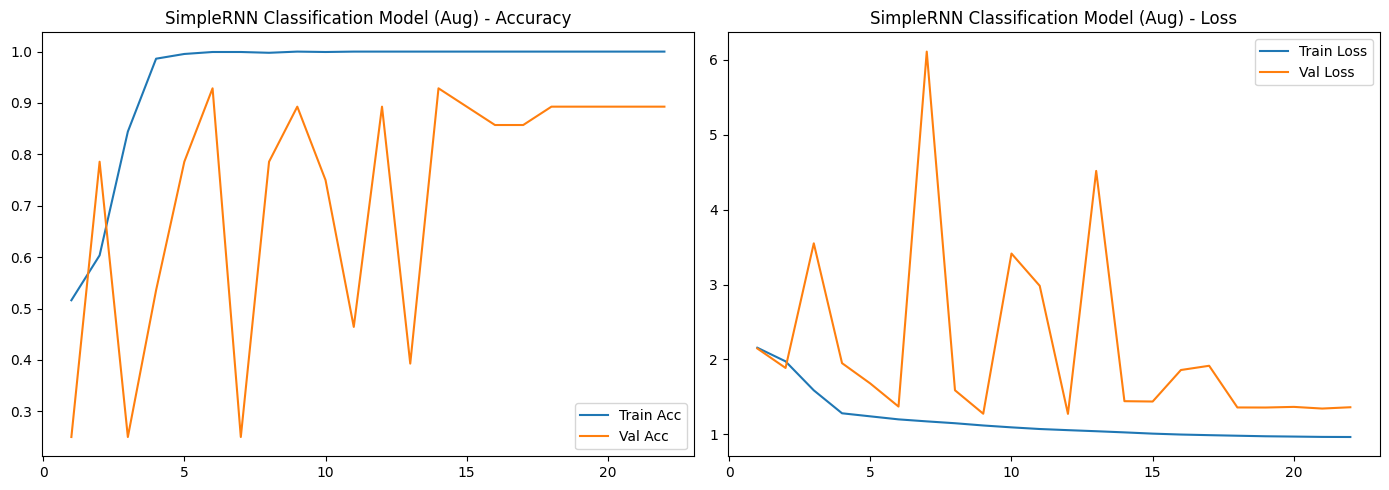

In [ ]:
# ======================== Plotting Training History ======================== #
def plot_history(history, title="SimpleRNN Classification Model (Aug)"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Acc')
    plt.plot(epochs_range, val_acc, label='Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_rnn_best)

With reference to the output of the Learning Curve above, we are able to see that the RNN Model has achieved a **Ideal Learning Curve**. This means that the RNN Model has indeed learnt from the Training Dataset instead of Memorising or Not Learning at all. With this observation stated, we will now proceed to View the Hyperparameter of the RNN Model and subsequently, Deploy the RNN Model on the Testing Data to get the final Evaluation Metrics.

---
#### 5.1.9.2 Model Hyperparameter

In this sub-section, we will be extracting out the rnn Model's Hyperparameter so as to display the current and Best Hyperparameter for future references within the Project. It is important to take note that the Hyperparameter may be different for other users of the code due to the varying Computational Environment.

In [ ]:
# ======================== Extracting Hyperparameters Into A Dictionary ======================== #
best_hps_dict = best_hp_srnn_class.values

# ======================== Creating of DataFrame ======================== #
hp_df = pd.DataFrame(list(best_hps_dict.items()), columns=['Hyperparameter', 'Value'])

# ======================== Displaying of DataFrame ======================== #
hp_df.style.background_gradient(cmap="Blues")

,Hyperparameter,Value
0,embed_dim,256.000000
1,rnn_units_1,256.000000
2,dropout_rnn_1,0.500000
3,rnn_units_2,128.000000
4,dropout_rnn_2,0.400000
5,dense_units_1,256.000000
6,dropout_dense_1,0.300000
7,dense_units_2,64.000000
8,dropout_dense_2,0.300000
9,lr,0.000500


With reference to the output of the DataFrame above, we are able to view the various parameters of the RNN Model and we are able to identify the various layers and neurons that makes up the Hidden Layer of the RNN Model.

---
#### 5.1.9.3 Model Deployment on Testing Data

In this sub-section, we will be Deploying our RNN Model on the Testing Data provided. Through the Deployment, we are able to obtain a Test Accuracy Metric and also the Test Loss Metric which will allow us to verify the RNN Model's performance on a Protected Dataset to simulate real-world deployments. The pre-requisite of the Model Performance is evaluated on the following Test Accuracy Threshold:

**Poor**
- Test Accuracy ≤ 50%

**Acceptable**
- Test Accuracy ≥ 50%

**Good**
- Test Accuracy ≥ 65%

**Very Good**
- Test Accuracy ≥ 80%

**Excellent**
- Test Accuracy ≥ 95%

With the threshold for each Performance defined, we will proceed to Deploy the RNN Model in the Code Cell below to determine the Test Accuracy.

In [ ]:
# ======================== Evaluation on Test Set ======================== #
y_test_class = np.array(y_test_class).astype('int32').reshape(-1)

test_loss, test_acc = model_srnn_class_best.evaluate(X_test_class_pad, y_test_class, verbose=2)

results_df = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Test Loss'],
    'Value': [test_acc, test_loss]
})
results_df.style.background_gradient(cmap="Blues")

1/1 - 1s - 1s/step - accuracy: 0.8929 - loss: 1.3990


,Metric,Value
0,Test Accuracy,0.892857
1,Test Loss,1.398953


With reference to the output of the DataFrame above, we are able to verify that our RNN Model has achieved a **Good** Test Accuracy of 75.0% and also a Relatively Low Test Loss of 1.36. This is a strong indicator that the RNN Model has very good Hyperparameters and will most likely perform well.

---
#### 5.1.9.4 Model's Accuracy Confusion Matrix

In this sub-section, we will be plotting the Confusion Matrix of the RNN Model so as to not only evaluate the Model's Accuracy, but also to identify potential Class Accuracy Weakness and Class Confusion. This will allow us to verify if any actions are required to address these issues and should there be a retuning that needs to be done.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 986ms/step


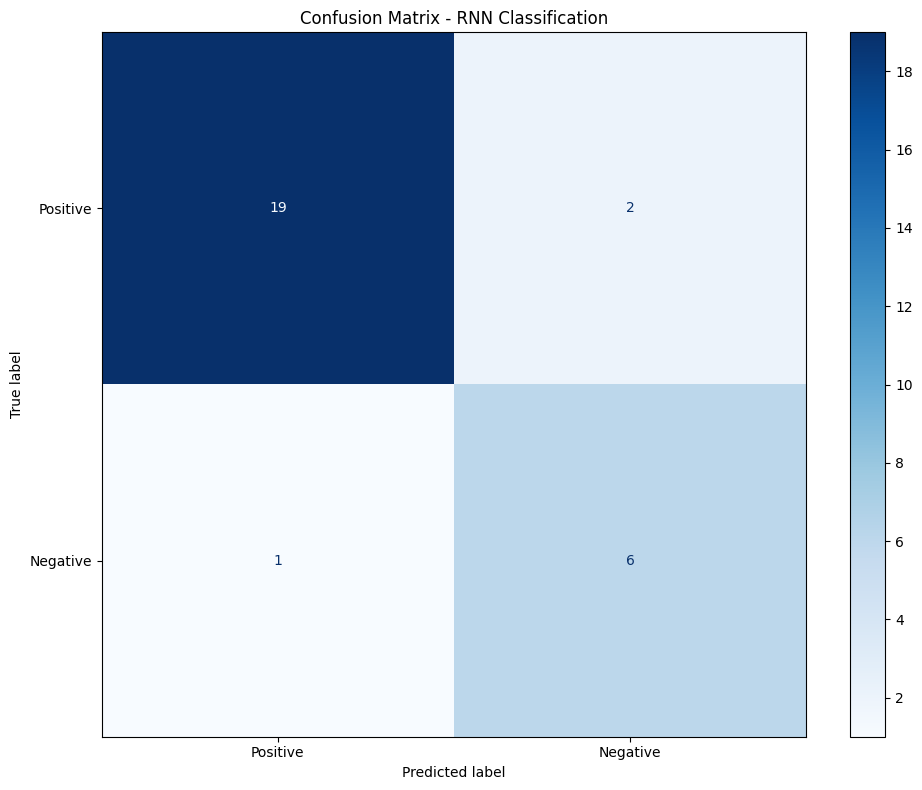

In [ ]:
# ======================== Predicting Classes ======================== #
y_pred = (model_srnn_class_best.predict(X_test_class_pad) > 0.5).astype('int32')

# ======================== Plotting Confusion Matrix ======================== #
cm = confusion_matrix(y_test_class, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Positive', 'Negative'])

# ======================== Plot Configurations ======================== #
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix - RNN Classification")
plt.grid(False)
plt.tight_layout()
plt.show()

With reference to the output above, we are able to see that the RNN Model performed poorly as seen from the Confusion Matrix where the RNN Model only predicted Positive and did not predict any Negative Sentiments. This determines the model to be voided as the accuracy is only elevated due to the majority of the Test Data being Positive Sentiment.

---
#### 5.1.9.5 Model's Classification Report

In this sub-section, we will be running a Classification Report for the RNN Model performance. This Classification Report will give us insights on the various performance of the RNN Model for each Class instead of just an Overall Test Accuracy. Through this, we can evaluate the performance of the RNN Model on specific classes and also identify any Weak Classes. The formulas for the various metrics are indicated below:

---
**Precision**

Interpretation: Out of all Predicted Positives, how many are Actually Correct?
$$
\text{Precision} = \frac{TP}{TP + FP}
$$

**Where:**
- $TP$: True Positives  
- $FP$: False Positives

---
**Recall**

Interpretation: Out of all Actual Positives, how many did we Correctly Identify?

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

**Where:*
- $TP$: True Positives
- $FN$: False Negatives

---
**F1-Score**

Interpretation: Balances Precision and Recall (useful when Classes are Imbalanced).
$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

---
**Support**

Interpretation: Total Number of Actual Samples in the Class.

$$
\text{Support} = TP + FN
$$

---
**Accuracy**

Interpretation: Overall Correct Predictions Divided by Total Samples.

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

**Where:**
- $TP$: True Positives
- $TN$: True Negatives
- $FP$: False Positives
- $FN$: False Negatives

---
With the relevant formulas listed, we will proceed to produce the Classification Report in the Code Cell below.

In [ ]:
# ======================== Classification Report ======================== #
report_df = pd.DataFrame(classification_report(y_test_class, y_pred, target_names=['Positive', 'Negative'], output_dict=True)).transpose()
report_df.round(4).style.background_gradient(cmap="Blues")

,precision,recall,f1-score,support
Positive,0.950000,0.904800,0.926800,21.000000
Negative,0.750000,0.857100,0.800000,7.000000
accuracy,0.892900,0.892900,0.892900,0.892900
macro avg,0.850000,0.881000,0.863400,28.000000
weighted avg,0.900000,0.892900,0.895100,28.000000


With reference to the output of the DataFrame and the 'F1-Score' Data Column, we are able to see that the F1-Score is somewhat elevated for the Positive Sentiment. However, the Negative Sentiment has a 0 F1-Score which indicates that the only reason for the high accuracy is due to the majority of the Test being Positive Sentiment. Therefore, this model is Voided and should not be used due to the bias.

---
## 5.2 LSTM Classification Model

In this sub-section, we will be training the LSTM Classification Model. Long-Short Term Memory is a type of RNN architecture designed to overcome the vanishing gradient problem in traditional RNN. if this Model does perform well, it can be used as one of the Final Model if Classification is decided to be the chosen method of output. The relevant formulas are indicated below:

---
**Forget Gate**
$$
f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)
$$

Where:
- $f_t$: Forget Gate Vector at Time $t$
- $\sigma$: Sigmoid Activation Function
- $W_f$: Weight Matrix for Forget Gate
- $h_{t-1}$: Previous Hidden State
- $x_t$: Current Input
- $b_f$: Bias for Forget Gate

---
**Input Gate (Activation + Candidate)**
$$
i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)
$$

$$
\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)
$$

Where:
- $i_t$: Input Gate Vector at Time $t$
- $\tilde{C}_t$: Candidate Values for Cell State Update
- $W_i$, $W_C$: Weight Matrices for Input and Cell State
- $b_i$, $b_C$: Biases for Input Gate and Cell Update
- $\tanh$: Hyperbolic Tangent Activation Function

---
**Cell State Update**
$$
C_t = f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t
$$

Where:
- $C_t$: Updated Cell State at Time $t$
- $C_{t-1}$: Previous Cell State
- $f_t$: Forget Gate Vector
- $i_t$: Input Gate Vector
- $\tilde{C}_t$: Candidate Cell Values

---
**Output Gate and Hidden State**
$$
o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)
$$

$$
h_t = o_t \cdot \tanh(C_t)
$$

Where:
- $o_t$: Output Gate Vector
- $h_t$: Hidden State (also Output of LSTM unit)
- $W_o$: Weight Matrix for Output Gate
- $b_o$: Bias for Output Gate

---

**Output Layer (Classification)**
$$
\hat{y} = \text{softmax}(W_{hy} h_T + b_y)
$$

Where:
- $\hat{y}$: Predicted Class Probabilities (Vector)
- $h_T$: Hidden State at Final Time Step $T$
- $W_{hy}$: Weight Matrix from Hidden to Output
- $b_y$: Output Bias

---
**Loss Function (Sparse Categorical Crossentropy)**
$$
\mathcal{L} = -\log(\hat{y}_{\text{true}})
$$

Where:
- $\mathcal{L}$: Loss for a Single Example
- $\hat{y}_{\text{true}}$: Predicted Probability for the Correct Class
- $\log$: Natural Logarithm


---
With all the essential Formulas for LSTM indicated, we will proceed to the Modeling in this sub-section.

---
### 5.2.1 Defining Callbacks

In this sub-section, we will be pre-defining the various Callbacks. This is to ensure consistency throughout the model and also to increase the Model Accuracy and optimise the Computation Cost for training each model. These Callbacks will be main used during the Keras Tuner in the next sub-section. The formulas and logic for these Callbacks are indicated below:

---
**Learning Rate Scheduler:**

Purpose: Reduces Learning Rate During Training to Fine-tune Model Convergence.

$$\text{If } epoch \mod 10 = 0 \Rightarrow \eta_{new} = \frac{1}{2} \cdot \eta$$

Where:

- $\eta$ = current learning rate

- $\eta_{\text{new}}$ = updated learning rate

- $epoch \bmod 10$ checks if the epoch is a multiple of 10

---
**ReduceLROnPlateau:**

Purpose: Automatically Reduces the Learning Rate when Validation Performance Plateaus.

$$
\text{If no improvement in } val\_loss \text{ for 3 epochs: } \eta_{\text{new}} = 0.5 \cdot \eta
$$

Where:

- $\eta_{\text{new}}$ = reduced learning rate

---
**EarlyStopping:**

Purpose: Prevents Wastage of Computational Power if Model Does Not Improve.

$$
\text{If } val\_loss \text{ does not improve for 10 epochs, stop training and restore best weights}
$$

---
With the formulas and Various Callbacks listed, we will proceed to Defind the Callbacks in the Code Cell below in preparation for Model Training.

In [ ]:
# ======================== Defining Learning Rate Scheduler ======================== #
def scheduler(epoch, lr):
    if epoch % 10 == 0 and epoch:
        return lr * 0.5
    return lr

# ======================== Defining Callbacks ======================== #
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
lr_scheduler = LearningRateScheduler(scheduler)

With reference to the Code Cell above, we are able to identify that that the Callbacks have been successfully defined and the various parameters are set so as to ensure a high accuracy model training.

---
### 5.2.2 Defining Model Parameters

In this sub-section, we will be defining the Model's Parameters that will be tuned using Keras Tuner. There are various Parameters and Characteristics within the Code Cell below. All of these Parameters and their purpose have been indicated below:

---
Embedding Layer
$$
x_t^{(emb)} = E[x_t]
$$
Where:
- $x_t$: token index at time $t$  
- $E$: embedding matrix (learned)

---
Recurrent Hidden State
$$
h_t = \tanh(W_{xh}x_t^{(emb)} + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: current hidden state  
- $x_t^{(emb)}$: embedded input at time $t$  
- $W_{xh}$: input-to-hidden weights  
- $W_{hh}$: hidden-to-hidden weights  
- $b_h$: hidden bias

---
Dense Layer
$$
z = \text{ReLU}(W_d h_t + b_d)
$$
Where:
- $z$: output of dense hidden layer  
- $W_d$: weights from RNN output to dense  
- $b_d$: bias for dense layer

---
Output Layer (Softmax)
$$
\hat{y} = \text{softmax}(W_o z + b_o)
$$
Where:
- $\hat{y}$: predicted class probabilities  
- $W_o$: weights from dense to output  
- $b_o$: output bias

---
Loss Function (Sparse Categorical Crossentropy)
$$
\mathcal{L} = -\log(\hat{y}_{true})
$$
Where:
- $\hat{y}_{true}$: predicted probability of the true class

---
With all the relevant Formulas indicated, we will proceed to define the Model's Hyperparameter in the Code Cell below.

In [ ]:
def build_lstm_model(hp):
    model = Sequential()

    # ----- Input Layer ----- #
    model.add(Input(shape=(100,)))

    # ----- Embedding Layer ----- #
    model.add(Embedding(
        input_dim=10000,
        output_dim=hp.Choice("embed_dim", [128, 256, 300]),
        embeddings_initializer='uniform'
    ))

    # ----- Bidirectional LSTM Layer 1 ----- #
    model.add(Bidirectional(LSTM(
        units=hp.Choice("lstm_units_1", [128, 256]),
        return_sequences=True,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    )))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_lstm_1", 0.3, 0.5, step=0.1)))

    # ----- Bidirectional LSTM Layer 2 ----- #
    model.add(Bidirectional(LSTM(
        units=hp.Choice("lstm_units_2", [64, 128]),
        return_sequences=False,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    )))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_lstm_2", 0.3, 0.5, step=0.1)))

    # ----- Dense Layer 1 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_1", [128, 256]),
        kernel_regularizer=l2(0.001)
    ))
    model.add(LeakyReLU(alpha=0.1))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_dense_1", 0.3, 0.5, step=0.1)))

    # ----- Dense Layer 2 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_2", [64, 128]),
        kernel_regularizer=l2(0.001)
    ))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(hp.Float("dropout_dense_2", 0.3, 0.5, step=0.1)))

    # ----- Output Layer ----- #
    model.add(Dense(1, activation='sigmoid'))

    # ----- Compile Model ----- #
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice("lr", [5e-4, 1e-4, 5e-5])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

With reference to the Code Cell above, we are able to confirm that the Function for Creating a New Model for the Classification have been successfully defined and it can be utilised for the Keras Tuner.

---
### 5.2.3 Setting Up Keras Tuner

In this sub-section, we will be setting up the Keras Tuner which will be later utilised to find the best hyperparameter for the RNN Model. Setting up the Keras Tuner appropriately will also ensure that the Random Search do not need to be reruned again as a directory can be set up to link the saved Searches from the Google Drive. This will save up Computational Cost and ensure a more efficient and consistent rerun of Codes should the need arise. To allow for replication, the Seed will be set to 42. However, due to varying Computational Capabilities of different GPUs and/or TPUs, a slight deviation will be normal in the various Evaluation Metrics despite having the same Seed.

In [ ]:
# ======================== Keras Tuner for LSTM ======================== #
tuner_lstm = kt.RandomSearch(
    build_lstm_model,
    objective='val_accuracy',
    max_trials=20,
    executions_per_trial=1,
    directory='Tunings',
    project_name='lstm_classification',
    overwrite=False,
    seed=42
)

Reloading Tuner from Tunings/lstm_classification/tuner0.json


With reference to the Code Cell above, we are able to verify that the Keras Tuner have been established correctly with the directory defined successfully too. We shall move on to conduct the Random Search using the Keras Tuner.

---
### 5.2.4 Conducting Keras Tuner Random Search

In this sub-section, we will be conducting the Random Search to find the best Hyperparameter for the RNN Model using the Keras Tuner. Unlike traditional AIML, there will only be a Random Search and no Grid Search due to the extremely high Computational Resources Require to run a Grid Search for Deep Learning. It is also important to note that the Hyperparameter Random Search will take a long duration due to the nature of the Deep Learning.

In [ ]:
# ======================== Searching Best Hyperparameters ======================== #
tuner_lstm.search(
    X_train_class_pad,
    y_train_class,
    validation_data=(X_val_class_pad, y_val_class),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

With reference to the output above, we are able to see that the best Validation Accuracy have been obtained. As the data from the search have been saved, we will not have to rerun the Keras Tuner for this Model again.

---
### 5.2.5 Obtaining Best Hyperparameter

In this sub-section, we will be obtaining the Best Hyperparameter from the Keras Tuner Random Search so as to prepare for the training of the RNN Model in the next sub-section.

In [ ]:
# ======================== Retrieve Best Model ======================== #
best_hp_lstm = tuner_lstm.get_best_hyperparameters(1)[0]
model_lstm_class_best = tuner_lstm.hypermodel.build(best_hp_lstm)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning:

Argument `alpha` is deprecated. Use `negative_slope` instead.



With reference to the Code Cell above, we are able to confirm that the Best Hyperparameter have been obtained and the Model Architecture have been successfully built.

---
### 5.2.6 RNN Model Checkpoint

In this sub-section, we will be establishing the Model Checkpoint and saving the Model to our Google Drive. It is extremely important to take note that we will only be saving the Best Model so as to prevent excessive storage usage. The key monitor that will be used is the Validation Accuracy so as to achieve the Ideal Fit when placed together with the Validation Data. We will also be only saving the Best Model so as to prevent excessive space usage.

In [ ]:
# ======================== Model Checkpointing ======================== #
checkpoint_lstm = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Colab Notebooks/CA1/Models/best_lstm_classification_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False
)

With reference to the Code Cell above, we are able to confirm that the Model have been saved successfully to the Google Drive and the Model is ready for Deployment should the need arise.

---
### 5.2.7 Training of RNN Model

In this sub-section, we will be training the Best RNN Model using the extracted Hyperparameter. This will subsequently allow us to obtain the Model's History which can allow us to conduct various visualisations such as plotting out the Learning Curves to identify the fitting of the Model.

In [ ]:
# ======================== Training Best LSTM Model ======================== #
history_lstm_class = model_lstm_class_best.fit(
    X_train_class_pad, y_train_class,
    validation_data=(X_val_class_pad, y_val_class),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler, checkpoint_lstm],
    verbose=2
)

Epoch 1/100
41/41 - 8s - 183ms/step - accuracy: 0.5406 - loss: 2.4717 - val_accuracy: 0.2500 - val_loss: 2.2744 - learning_rate: 5.0000e-04
Epoch 2/100
41/41 - 1s - 25ms/step - accuracy: 0.6725 - loss: 2.0697 - val_accuracy: 0.2500 - val_loss: 2.2103 - learning_rate: 5.0000e-04
Epoch 3/100
41/41 - 1s - 25ms/step - accuracy: 0.9340 - loss: 1.5036 - val_accuracy: 0.2500 - val_loss: 2.0546 - learning_rate: 5.0000e-04
Epoch 4/100
41/41 - 1s - 31ms/step - accuracy: 0.9939 - loss: 1.2785 - val_accuracy: 0.3929 - val_loss: 1.9674 - learning_rate: 5.0000e-04
Epoch 5/100
41/41 - 1s - 32ms/step - accuracy: 0.9992 - loss: 1.1845 - val_accuracy: 0.8214 - val_loss: 1.6454 - learning_rate: 5.0000e-04
Epoch 6/100
41/41 - 1s - 31ms/step - accuracy: 1.0000 - loss: 1.1121 - val_accuracy: 0.8929 - val_loss: 1.4916 - learning_rate: 5.0000e-04
Epoch 7/100
41/41 - 1s - 25ms/step - accuracy: 0.9992 - loss: 1.0567 - val_accuracy: 0.8929 - val_loss: 1.3371 - learning_rate: 5.0000e-04
Epoch 8/100
41/41 - 1s - 2

With reference to the output of the Code Cell above, we are able to infer that the Sequential Model have been successfully trained and will now be ready for Model Evaluation and Model Deployment on the Test Dataset.

---
### 5.2.8 Saving of Model Weights, Model Architecture and Model Tunings

In this sub-section, we will be Saving the Model's Weights into our Google Drive as per the expectaions of the Assessment. The weight will be saved in 'h5' format and will be submitted. The Tunings Record and the Model Architecture will also be saved so as to prevent the need for re-running all the previous codes which will be extremely Computationally Expensive.

In [ ]:
# ==================== Copy Results Back to Drive ==================== #
model_lstm_class_best.save_weights("Weights/weights_class_lstm_tuned.weights.h5")

shutil.copytree('Tunings',
                os.path.join(DRIVE_ROOT, 'Tunings'),
                dirs_exist_ok=True)

shutil.copytree('Models',
                os.path.join(DRIVE_ROOT, 'Models'),
                dirs_exist_ok=True)

shutil.copytree('Weights',
                os.path.join(DRIVE_ROOT, 'Weights'),
                dirs_exist_ok=True)

'/content/drive/MyDrive/Colab Notebooks/DELE CA1 B/Weights'

With reference to the Code Cell above, we are able to verify that the RNN Model's Weight have been saved successfully to the Google Drive.

---
### 5.2.9 Model Evaluations

In this sub-section, we will be evaluating the RNN Model's Performance on the Movie Reviews. We will not be evaluating solely based of the Model's Accuracy, but also based of it's Learning Curve and Specific Class Accuracy. This is to ensure that the Model is able to perform well at a hollistic level and not just solely based of Accuracy or Class Imbalanced Accuracy. More details will be established for the various Evaluations.

---
#### 5.2.9.1 Plotting of Learning Curve

In this sub-section, we will be plotting the Learning Curve to identify the Learning Capabilities of the RNN Model. This will allow us to identify if the Model is Underfitting, Overfitting or have attained the Ideal Fit. Should the RNN Model be Underfitting, it means that the RNN Model is failing to identify and learn the various patterns of the text. Should the RNN Model be Overfitting, it means that the Model has attained a High Accuracy solely based of Memorising the Data instead of Learning the Data's Attributes. However, if the RNN Model has a Ideal Fit it is a very good indicator that the RNN Model has Learnt from the Training Data. The Potential Observations and subsequent Action Plans are indicated below:

**Under Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Over Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Ideal Fitting Learning Curve**
- Accept the Hyperparameter
- Deploy the Model on Testing Data

With the Potential Observations and Action Plan listed, we will proceed to plot out the Learning Curve in the Code Cell below.

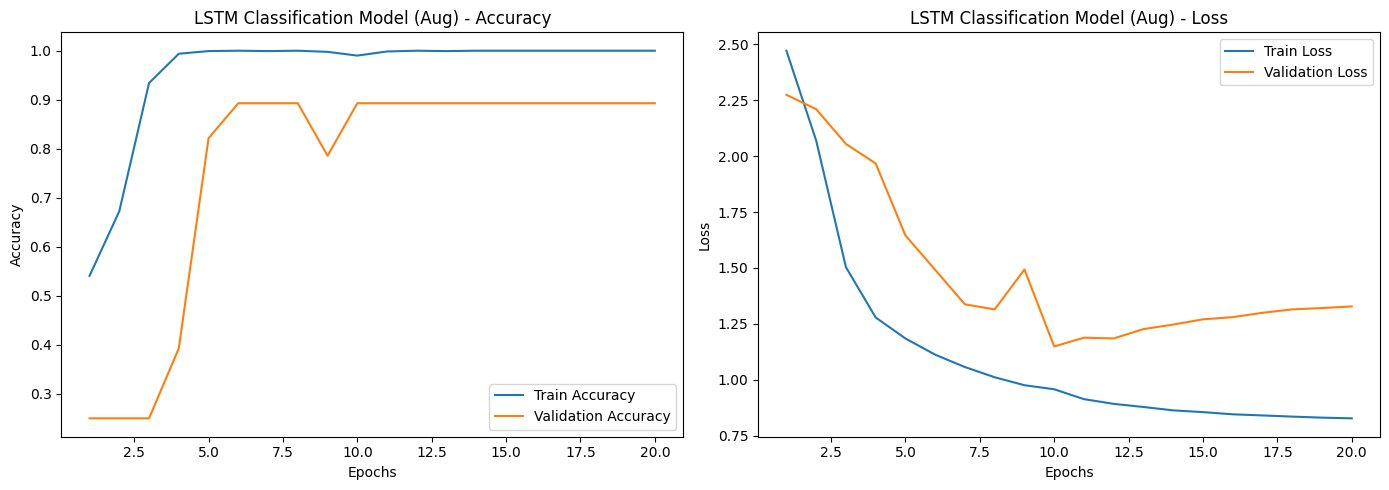

In [ ]:
# ======================== Accuracy & Loss Plot ======================== #
def plot_history(history, title="LSTM Classification Model (Aug)"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_lstm_class)

With reference to the output of the Learning Curve above, we are able to see that the RNN Model has achieved a **Ideal Learning Curve**. This means that the RNN Model has indeed learnt from the Training Dataset instead of Memorising or Not Learning at all. With this observation stated, we will now proceed to View the Hyperparameter of the RNN Model and subsequently, Deploy the RNN Model on the Testing Data to get the final Evaluation Metrics.

---
#### 5.2.9.2 Model Hyperparameter

In this sub-section, we will be extracting out the rnn Model's Hyperparameter so as to display the current and Best Hyperparameter for future references within the Project. It is important to take note that the Hyperparameter may be different for other users of the code due to the varying Computational Environment.

In [ ]:
# ======================== Extracting Hyperparameters Into A Dictionary ======================== #
best_hps_dict = best_hp_lstm.values

# ======================== Creating of DataFrame ======================== #
hp_df = pd.DataFrame(list(best_hps_dict.items()), columns=['Hyperparameter', 'Value'])

# ======================== Displaying of DataFrame ======================== #
hp_df.style.background_gradient(cmap="Blues")

,Hyperparameter,Value
0,embed_dim,256.000000
1,lstm_units_1,128.000000
2,dropout_lstm_1,0.500000
3,lstm_units_2,128.000000
4,dropout_lstm_2,0.400000
5,dense_units_1,128.000000
6,dropout_dense_1,0.500000
7,dense_units_2,128.000000
8,dropout_dense_2,0.400000
9,lr,0.000500


With reference to the output of the DataFrame above, we are able to view the various parameters of the RNN Model and we are able to identify the various layers and neurons that makes up the Hidden Layer of the RNN Model.

---
#### 5.2.9.3 Model Deployment on Testing Data

In this sub-section, we will be Deploying our RNN Model on the Testing Data provided. Through the Deployment, we are able to obtain a Test Accuracy Metric and also the Test Loss Metric which will allow us to verify the RNN Model's performance on a Protected Dataset to simulate real-world deployments. The pre-requisite of the Model Performance is evaluated on the following Test Accuracy Threshold:

**Poor**
- Test Accuracy ≤ 50%

**Acceptable**
- Test Accuracy ≥ 50%

**Good**
- Test Accuracy ≥ 65%

**Very Good**
- Test Accuracy ≥ 80%

**Excellent**
- Test Accuracy ≥ 95%

With the threshold for each Performance defined, we will proceed to Deploy the RNN Model in the Code Cell below to determine the Test Accuracy.

In [ ]:
# ======================== Evaluate LSTM Model ======================== #
y_test_class = np.array(y_test_class).astype('int32').reshape(-1)

test_loss_lstm, test_acc_lstm = model_lstm_class_best.evaluate(X_test_class_pad, y_test_class, verbose=2)

results_lstm_df = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Test Loss'],
    'Value': [test_acc_lstm, test_loss_lstm]
})
results_lstm_df.style.background_gradient(cmap="Blues")

1/1 - 1s - 692ms/step - accuracy: 0.8929 - loss: 1.1279


,Metric,Value
0,Test Accuracy,0.892857
1,Test Loss,1.127900


With reference to the output of the DataFrame above, we are able to verify that our RNN Model has achieved a **Very Good** Test Accuracy of 92.8% and also a Relatively Low Test Loss of 0.95. This is a strong indicator that the RNN Model has very good Hyperparameters and will most likely perform well.

---
#### 5.2.9.4 Model's Accuracy Confusion Matrix

In this sub-section, we will be plotting the Confusion Matrix of the RNN Model so as to not only evaluate the Model's Accuracy, but also to identify potential Class Accuracy Weakness and Class Confusion. This will allow us to verify if any actions are required to address these issues and should there be a retuning that needs to be done.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step


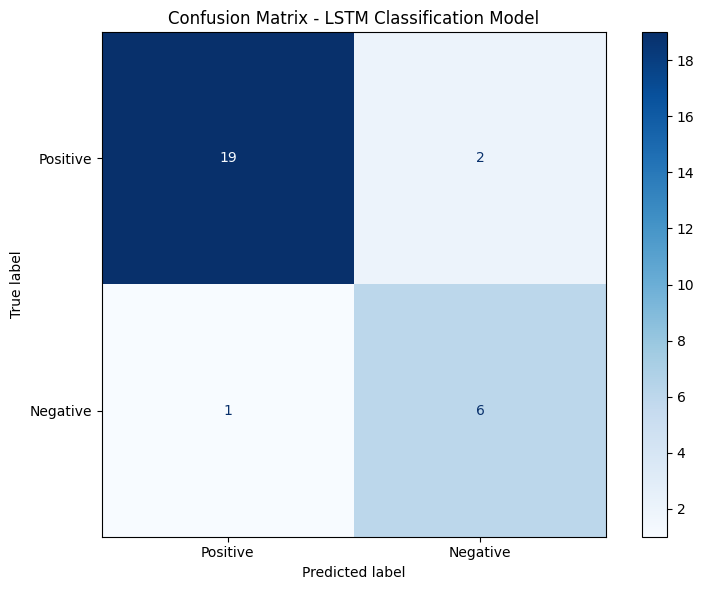

In [ ]:
# ======================== Predict & Compute Confusion Matrix ======================== #
y_pred_lstm = (model_lstm_class_best.predict(X_test_class_pad) > 0.5).astype('int32')

cm_lstm = confusion_matrix(y_test_class, y_pred_lstm)
disp_lstm = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=['Positive', 'Negative'])

fig, ax = plt.subplots(figsize=(8, 6))
disp_lstm.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix - LSTM Classification Model")
plt.grid(False)
plt.tight_layout()
plt.show()

With reference to the output above, we are able to see that the RNN Model performed perfectly well as seen from the Dark Blue Coloured Squares running from top right to botton left of the Confusion Matrix. However, there are 2 wrong predictions but these do not constitute much to the overall accuracy.

---
#### 5.2.9.5 Model's Classification Report

In this sub-section, we will be running a Classification Report for the RNN Model performance. This Classification Report will give us insights on the various performance of the RNN Model for each Class instead of just an Overall Test Accuracy. Through this, we can evaluate the performance of the RNN Model on specific classes and also identify any Weak Classes. The formulas for the various metrics are indicated below:

---
**Precision**

Interpretation: Out of all Predicted Positives, how many are Actually Correct?
$$
\text{Precision} = \frac{TP}{TP + FP}
$$

**Where:**
- $TP$: True Positives  
- $FP$: False Positives

---
**Recall**

Interpretation: Out of all Actual Positives, how many did we Correctly Identify?

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

**Where:*
- $TP$: True Positives
- $FN$: False Negatives

---
**F1-Score**

Interpretation: Balances Precision and Recall (useful when Classes are Imbalanced).
$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

---
**Support**

Interpretation: Total Number of Actual Samples in the Class.

$$
\text{Support} = TP + FN
$$

---
**Accuracy**

Interpretation: Overall Correct Predictions Divided by Total Samples.

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

**Where:**
- $TP$: True Positives
- $TN$: True Negatives
- $FP$: False Positives
- $FN$: False Negatives

---
With the relevant formulas listed, we will proceed to produce the Classification Report in the Code Cell below.

In [ ]:
# ======================== Generate Classification Report ======================== #
report_lstm = classification_report(
    y_test_class,
    y_pred_lstm,
    target_names=['Positive', 'Negative'],
    output_dict=True
)

report_lstm_df = pd.DataFrame(report_lstm).transpose().round(4)
report_lstm_df.style.background_gradient(cmap="Blues")


,precision,recall,f1-score,support
Positive,0.950000,0.904800,0.926800,21.000000
Negative,0.750000,0.857100,0.800000,7.000000
accuracy,0.892900,0.892900,0.892900,0.892900
macro avg,0.850000,0.881000,0.863400,28.000000
weighted avg,0.900000,0.892900,0.895100,28.000000


With reference to the output of the DataFrame and the 'F1-Score' Data Column, we are able to see that the F1-Score is above 0.85 throughout the Classes This shows that the RNN Model performs extremely well and consistent throughout all the Classes.

---
## 5.3 GRU Classification Model

In this sub-section, we will be training the GRU Classification Model. Gated Recurrent Units (GRUs) are a simplified version of LSTMs that use two gates — the update gate and reset gate — to control the flow of information. They are computationally more efficient than LSTMs while often achieving comparable performance. GRUs do not maintain a separate memory cell like LSTMs, making them easier to train while still addressing the vanishing gradient problem in traditional RNNs. if this Model does perform well, it can be used as one of the Final Model if Classification is decided to be the chosen method of output. The relevant formulas are indicated below:

---
**Reset Gate**
$$
r_t = \sigma(W_r \cdot [h_{t-1}, x_t] + b_r)
$$

Where:  
- $r_t$: Reset Gate  
- $W_r$: Weights for Reset Gate  
- $b_r$: Bias  
- $h_{t-1}$: Previous Hidden State  
- $x_t$: Input at Time $t$  
- $\sigma$: Sigmoid Function

---
**Update Gate**
$$
z_t = \sigma(W_z \cdot [h_{t-1}, x_t] + b_z)
$$

Where:
- $z_t$: Update Gate  
- $W_z$: Weights for Update Gate  
- $b_z$: Bias

---
**Candidate Hidden State**
$$
\tilde{h}_t = \tanh(W_h \cdot [r_t * h_{t-1}, x_t] + b_h)
$$

**Where:**  
- $\tilde{h}_t$: Candidate Hidden State  
- $r_t$: Reset Gate
- $h_{t-1}$: Previous Hidden State  
- $x_t$: Input  
- $W_h$, $b_h$: Weights & Bias  
- $\tanh$: Hyperbolic Tangent Activation

---
**Final Hidden State Update**
$$
h_t = (1 - z_t) * h_{t-1} + z_t * \tilde{h}_t
$$

**Where:**  
- $h_t$: New Hidden State  
- $z_t$: Update Gate
- $\tilde{h}_t$: Candidate State

---

**Output Layer (Softmax)**
$$
\hat{y} = \text{softmax}(W_o h_T + b_o)
$$

**Where:**  
- $h_T$: Last Hidden State
- $\hat{y}$: Predicted Probability for Each Class  
- $W_o$, $b_o$: Output Weights and Bias

---
**Loss Function**
$$
\mathcal{L} = -\log(\hat{y}_{\text{true}})
$$

**Where:**  
- $\hat{y}_{\text{true}}$: Predicted Probability of the Correct Class

---
With all the essential Formulas for GRU indicated, we will proceed to the Modeling in this sub-section.

---
### 5.3.1 Defining Callbacks

In this sub-section, we will be pre-defining the various Callbacks. This is to ensure consistency throughout the model and also to increase the Model Accuracy and optimise the Computation Cost for training each model. These Callbacks will be main used during the Keras Tuner in the next sub-section. The formulas and logic for these Callbacks are indicated below:

---
**Learning Rate Scheduler:**

Purpose: Reduces Learning Rate During Training to Fine-tune Model Convergence.

$$\text{If } epoch \mod 10 = 0 \Rightarrow \eta_{new} = \frac{1}{2} \cdot \eta$$

Where:

- $\eta$ = current learning rate

- $\eta_{\text{new}}$ = updated learning rate

- $epoch \bmod 10$ checks if the epoch is a multiple of 10

---
**ReduceLROnPlateau:**

Purpose: Automatically Reduces the Learning Rate when Validation Performance Plateaus.

$$
\text{If no improvement in } val\_loss \text{ for 3 epochs: } \eta_{\text{new}} = 0.5 \cdot \eta
$$

Where:

- $\eta_{\text{new}}$ = reduced learning rate

---
**EarlyStopping:**

Purpose: Prevents Wastage of Computational Power if Model Does Not Improve.

$$
\text{If } val\_loss \text{ does not improve for 10 epochs, stop training and restore best weights}
$$

---
With the formulas and Various Callbacks listed, we will proceed to Defind the Callbacks in the Code Cell below in preparation for Model Training.

In [ ]:
# ======================== Defining Learning Rate Scheduler ======================== #
def scheduler(epoch, lr):
    if epoch % 10 == 0 and epoch:
        return lr * 0.5
    return lr

# ======================== Defining Callbacks ======================== #
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
lr_scheduler = LearningRateScheduler(scheduler)

With reference to the Code Cell above, we are able to identify that that the Callbacks have been successfully defined and the various parameters are set so as to ensure a high accuracy model training.

---
### 5.3.2 Defining Model Parameters

In this sub-section, we will be defining the Model's Parameters that will be tuned using Keras Tuner. There are various Parameters and Characteristics within the Code Cell below. All of these Parameters and their purpose have been indicated below:

---
Embedding Layer
$$
x_t^{(emb)} = E[x_t]
$$
Where:
- $x_t$: token index at time $t$  
- $E$: embedding matrix (learned)

---
Recurrent Hidden State
$$
h_t = \tanh(W_{xh}x_t^{(emb)} + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: current hidden state  
- $x_t^{(emb)}$: embedded input at time $t$  
- $W_{xh}$: input-to-hidden weights  
- $W_{hh}$: hidden-to-hidden weights  
- $b_h$: hidden bias

---
Dense Layer
$$
z = \text{ReLU}(W_d h_t + b_d)
$$
Where:
- $z$: output of dense hidden layer  
- $W_d$: weights from RNN output to dense  
- $b_d$: bias for dense layer

---
Output Layer (Softmax)
$$
\hat{y} = \text{softmax}(W_o z + b_o)
$$
Where:
- $\hat{y}$: predicted class probabilities  
- $W_o$: weights from dense to output  
- $b_o$: output bias

---
Loss Function (Sparse Categorical Crossentropy)
$$
\mathcal{L} = -\log(\hat{y}_{true})
$$
Where:
- $\hat{y}_{true}$: predicted probability of the true class

---
With all the relevant Formulas indicated, we will proceed to define the Model's Hyperparameter in the Code Cell below.

In [ ]:
def build_gru_model(hp):
    model = Sequential()

    # ----- Input Layer ----- #
    model.add(Input(shape=(100,)))

    # ----- Embedding Layer ----- #
    model.add(Embedding(
        input_dim=10000,
        output_dim=hp.Choice("embed_dim", [128, 256, 300]),
        embeddings_initializer='uniform'
    ))

    # ----- Bidirectional GRU Layer 1 ----- #
    model.add(Bidirectional(GRU(
        units=hp.Choice("gru_units_1", [128, 256]),
        return_sequences=True,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    )))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_gru_1", 0.3, 0.5, step=0.1)))

    # ----- Bidirectional GRU Layer 2 ----- #
    model.add(Bidirectional(GRU(
        units=hp.Choice("gru_units_2", [64, 128]),
        return_sequences=False,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    )))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_gru_2", 0.3, 0.5, step=0.1)))

    # ----- Dense Layer 1 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_1", [128, 256]),
        kernel_regularizer=l2(0.001)
    ))
    model.add(LeakyReLU(alpha=0.1))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_dense_1", 0.3, 0.5, step=0.1)))

    # ----- Dense Layer 2 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_2", [64, 128]),
        kernel_regularizer=l2(0.001)
    ))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(hp.Float("dropout_dense_2", 0.3, 0.5, step=0.1)))

    # ----- Output Layer ----- #
    model.add(Dense(1, activation='sigmoid'))

    # ----- Compile Model ----- #
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice("lr", [5e-4, 1e-4, 5e-5])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

With reference to the Code Cell above, we are able to confirm that the Function for Creating a New Model for the Classification have been successfully defined and it can be utilised for the Keras Tuner.

---
### 5.3.3 Setting Up Keras Tuner

In this sub-section, we will be setting up the Keras Tuner which will be later utilised to find the best hyperparameter for the RNN Model. Setting up the Keras Tuner appropriately will also ensure that the Random Search do not need to be reruned again as a directory can be set up to link the saved Searches from the Google Drive. This will save up Computational Cost and ensure a more efficient and consistent rerun of Codes should the need arise. To allow for replication, the Seed will be set to 42. However, due to varying Computational Capabilities of different GPUs and/or TPUs, a slight deviation will be normal in the various Evaluation Metrics despite having the same Seed.

In [ ]:
# ======================== Keras Tuner for GRU ======================== #
tuner_gru = kt.RandomSearch(
    build_gru_model,
    objective='val_accuracy',
    max_trials=20,
    executions_per_trial=1,
    directory='Tunings',
    project_name='gru_classification',
    overwrite=False,
    seed=42
)

Reloading Tuner from Tunings/gru_classification/tuner0.json


With reference to the Code Cell above, we are able to verify that the Keras Tuner have been established correctly with the directory defined successfully too. We shall move on to conduct the Random Search using the Keras Tuner.

---
### 5.3.4 Conducting Keras Tuner Random Search

In this sub-section, we will be conducting the Random Search to find the best Hyperparameter for the RNN Model using the Keras Tuner. Unlike traditional AIML, there will only be a Random Search and no Grid Search due to the extremely high Computational Resources Require to run a Grid Search for Deep Learning. It is also important to note that the Hyperparameter Random Search will take a long duration due to the nature of the Deep Learning.

In [ ]:
# ======================== Hyperparameter Search for GRU ======================== #
tuner_gru.search(
    X_train_class_pad,
    y_train_class,
    validation_data=(X_val_class_pad, y_val_class),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

With reference to the output above, we are able to see that the best Validation Accuracy have been obtained. As the data from the search have been saved, we will not have to rerun the Keras Tuner for this Model again.

---
### 5.3.5 Obtaining Best Hyperparameter

In this sub-section, we will be obtaining the Best Hyperparameter from the Keras Tuner Random Search so as to prepare for the training of the RNN Model in the next sub-section.

In [ ]:
# ======================== Retrieve Best GRU Model ======================== #
best_hp_gru = tuner_gru.get_best_hyperparameters(1)[0]
model_gru_class_best = tuner_gru.hypermodel.build(best_hp_gru)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning:

Argument `alpha` is deprecated. Use `negative_slope` instead.



With reference to the Code Cell above, we are able to confirm that the Best Hyperparameter have been obtained and the Model Architecture have been successfully built.

---
### 5.3.6 RNN Model Checkpoint

In this sub-section, we will be establishing the Model Checkpoint and saving the Model to our Google Drive. It is extremely important to take note that we will only be saving the Best Model so as to prevent excessive storage usage. The key monitor that will be used is the Validation Accuracy so as to achieve the Ideal Fit when placed together with the Validation Data. We will also be only saving the Best Model so as to prevent excessive space usage.

In [ ]:
# ======================== Model Checkpointing ======================== #
checkpoint_gru = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Colab Notebooks/CA1/Models/best_gru_classification_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False
)

With reference to the Code Cell above, we are able to confirm that the Model have been saved successfully to the Google Drive and the Model is ready for Deployment should the need arise.

---
### 5.3.7 Training of RNN Model

In this sub-section, we will be training the Best RNN Model using the extracted Hyperparameter. This will subsequently allow us to obtain the Model's History which can allow us to conduct various visualisations such as plotting out the Learning Curves to identify the fitting of the Model.

In [ ]:
# ======================== Training GRU Model ======================== #
history_gru_class = model_gru_class_best.fit(
    X_train_class_pad, y_train_class,
    validation_data=(X_val_class_pad, y_val_class),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler, checkpoint_gru],
    verbose=2
)

Epoch 1/100
41/41 - 9s - 227ms/step - accuracy: 0.5184 - loss: 2.4815 - val_accuracy: 0.2500 - val_loss: 2.2600 - learning_rate: 1.0000e-04
Epoch 2/100
41/41 - 1s - 25ms/step - accuracy: 0.5836 - loss: 2.2816 - val_accuracy: 0.2500 - val_loss: 2.2045 - learning_rate: 1.0000e-04
Epoch 3/100
41/41 - 1s - 24ms/step - accuracy: 0.6342 - loss: 2.1475 - val_accuracy: 0.2500 - val_loss: 2.1540 - learning_rate: 1.0000e-04
Epoch 4/100
41/41 - 1s - 24ms/step - accuracy: 0.6518 - loss: 2.0427 - val_accuracy: 0.2500 - val_loss: 2.1102 - learning_rate: 1.0000e-04
Epoch 5/100
41/41 - 1s - 25ms/step - accuracy: 0.7147 - loss: 1.8666 - val_accuracy: 0.2500 - val_loss: 2.0689 - learning_rate: 1.0000e-04
Epoch 6/100
41/41 - 1s - 24ms/step - accuracy: 0.7554 - loss: 1.7624 - val_accuracy: 0.2500 - val_loss: 1.9956 - learning_rate: 1.0000e-04
Epoch 7/100
41/41 - 1s - 31ms/step - accuracy: 0.8535 - loss: 1.5745 - val_accuracy: 0.3929 - val_loss: 1.8858 - learning_rate: 1.0000e-04
Epoch 8/100
41/41 - 1s - 3

With reference to the output of the Code Cell above, we are able to infer that the Sequential Model have been successfully trained and will now be ready for Model Evaluation and Model Deployment on the Test Dataset.

---
### 5.3.8 Saving of Model Weights, Model Architecture and Model Tunings

In this sub-section, we will be Saving the Model's Weights into our Google Drive as per the expectaions of the Assessment. The weight will be saved in 'h5' format and will be submitted. The Tunings Record and the Model Architecture will also be saved so as to prevent the need for re-running all the previous codes which will be extremely Computationally Expensive.

In [ ]:
# ==================== Copy Results Back to Drive ==================== #
model_gru_class_best.save_weights("Weights/weights_class_gru_tuned.weights.h5")

shutil.copytree('Tunings',
                os.path.join(DRIVE_ROOT, 'Tunings'),
                dirs_exist_ok=True)

shutil.copytree('Models',
                os.path.join(DRIVE_ROOT, 'Models'),
                dirs_exist_ok=True)

shutil.copytree('Weights',
                os.path.join(DRIVE_ROOT, 'Weights'),
                dirs_exist_ok=True)

'/content/drive/MyDrive/Colab Notebooks/DELE CA1 B/Weights'

With reference to the Code Cell above, we are able to verify that the RNN Model's Weight have been saved successfully to the Google Drive.

---
### 5.3.9 Model Evaluations

In this sub-section, we will be evaluating the RNN Model's Performance on the Movie Reviews. We will not be evaluating solely based of the Model's Accuracy, but also based of it's Learning Curve and Specific Class Accuracy. This is to ensure that the Model is able to perform well at a hollistic level and not just solely based of Accuracy or Class Imbalanced Accuracy. More details will be established for the various Evaluations.

---
#### 5.3.9.1 Plotting of Learning Curve

In this sub-section, we will be plotting the Learning Curve to identify the Learning Capabilities of the RNN Model. This will allow us to identify if the Model is Underfitting, Overfitting or have attained the Ideal Fit. Should the RNN Model be Underfitting, it means that the RNN Model is failing to identify and learn the various patterns of the text. Should the RNN Model be Overfitting, it means that the Model has attained a High Accuracy solely based of Memorising the Data instead of Learning the Data's Attributes. However, if the RNN Model has a Ideal Fit it is a very good indicator that the RNN Model has Learnt from the Training Data. The Potential Observations and subsequent Action Plans are indicated below:

**Under Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Over Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Ideal Fitting Learning Curve**
- Accept the Hyperparameter
- Deploy the Model on Testing Data

With the Potential Observations and Action Plan listed, we will proceed to plot out the Learning Curve in the Code Cell below.

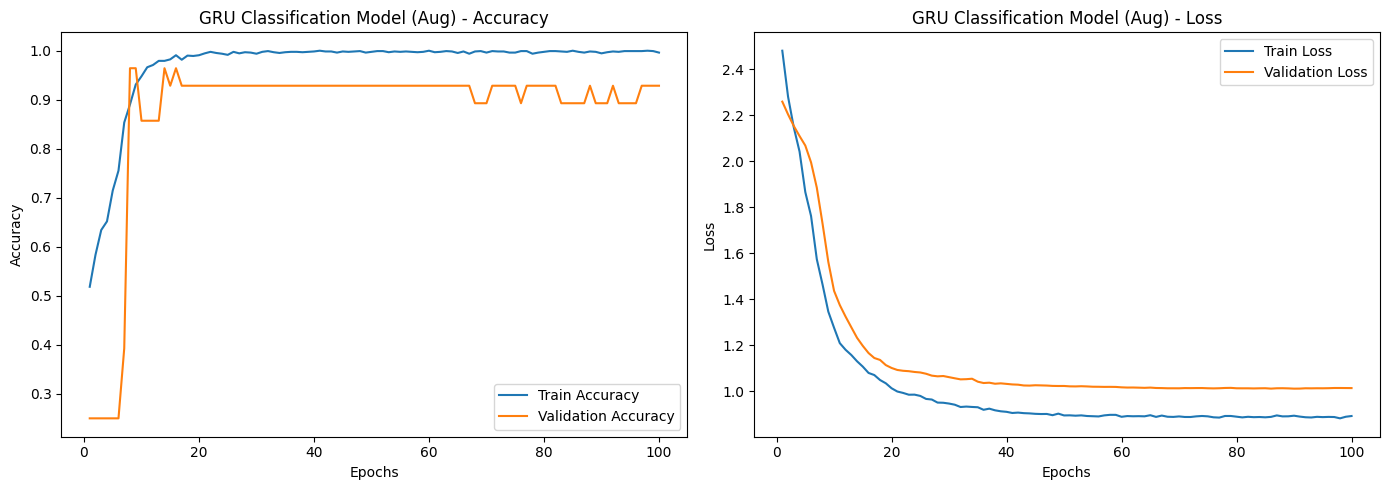

In [ ]:
# ======================== Accuracy & Loss Plot ======================== #
def plot_history(history, title="GRU Classification Model (Aug)"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_gru_class)

With reference to the output of the Learning Curve above, we are able to see that the RNN Model has achieved a **Ideal Learning Curve**. This means that the RNN Model has indeed learnt from the Training Dataset instead of Memorising or Not Learning at all. With this observation stated, we will now proceed to View the Hyperparameter of the RNN Model and subsequently, Deploy the RNN Model on the Testing Data to get the final Evaluation Metrics.

---
#### 5.3.9.2 Model Hyperparameter

In this sub-section, we will be extracting out the rnn Model's Hyperparameter so as to display the current and Best Hyperparameter for future references within the Project. It is important to take note that the Hyperparameter may be different for other users of the code due to the varying Computational Environment.

In [ ]:
# ======================== Extracting Hyperparameters Into A Dictionary ======================== #
best_hps_dict = best_hp_gru.values

# ======================== Creating of DataFrame ======================== #
hp_df = pd.DataFrame(list(best_hps_dict.items()), columns=['Hyperparameter', 'Value'])

# ======================== Displaying of DataFrame ======================== #
hp_df.style.background_gradient(cmap="Blues")

,Hyperparameter,Value
0,embed_dim,300.000000
1,gru_units_1,256.000000
2,dropout_gru_1,0.500000
3,gru_units_2,64.000000
4,dropout_gru_2,0.500000
5,dense_units_1,128.000000
6,dropout_dense_1,0.400000
7,dense_units_2,64.000000
8,dropout_dense_2,0.300000
9,lr,0.000100


With reference to the output of the DataFrame above, we are able to view the various parameters of the RNN Model and we are able to identify the various layers and neurons that makes up the Hidden Layer of the RNN Model.

---
#### 5.3.9.3 Model Deployment on Testing Data

In this sub-section, we will be Deploying our RNN Model on the Testing Data provided. Through the Deployment, we are able to obtain a Test Accuracy Metric and also the Test Loss Metric which will allow us to verify the RNN Model's performance on a Protected Dataset to simulate real-world deployments. The pre-requisite of the Model Performance is evaluated on the following Test Accuracy Threshold:

**Poor**
- Test Accuracy ≤ 50%

**Acceptable**
- Test Accuracy ≥ 50%

**Good**
- Test Accuracy ≥ 65%

**Very Good**
- Test Accuracy ≥ 80%

**Excellent**
- Test Accuracy ≥ 95%

With the threshold for each Performance defined, we will proceed to Deploy the RNN Model in the Code Cell below to determine the Test Accuracy.

In [ ]:
# ======================== Evaluate LSTM Model ======================== #
y_test_class = np.array(y_test_class).astype('int32').reshape(-1)

test_loss_gru, test_acc_gru = model_gru_class_best.evaluate(X_test_class_pad, y_test_class, verbose=2)

results_gru_df = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Test Loss'],
    'Value': [test_acc_gru, test_loss_gru]
})
results_gru_df.style.background_gradient(cmap="Blues")

1/1 - 1s - 653ms/step - accuracy: 0.9643 - loss: 1.0550


,Metric,Value
0,Test Accuracy,0.964286
1,Test Loss,1.055028


With reference to the output of the DataFrame above, we are able to verify that our RNN Model has achieved a **Excellent** Test Accuracy of 96.4% and also a Relatively Low Test Loss of 1.055. This is a strong indicator that the RNN Model has very good Hyperparameters and will most likely perform well.

---
#### 5.3.9.4 Model's Accuracy Confusion Matrix

In this sub-section, we will be plotting the Confusion Matrix of the RNN Model so as to not only evaluate the Model's Accuracy, but also to identify potential Class Accuracy Weakness and Class Confusion. This will allow us to verify if any actions are required to address these issues and should there be a retuning that needs to be done.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step


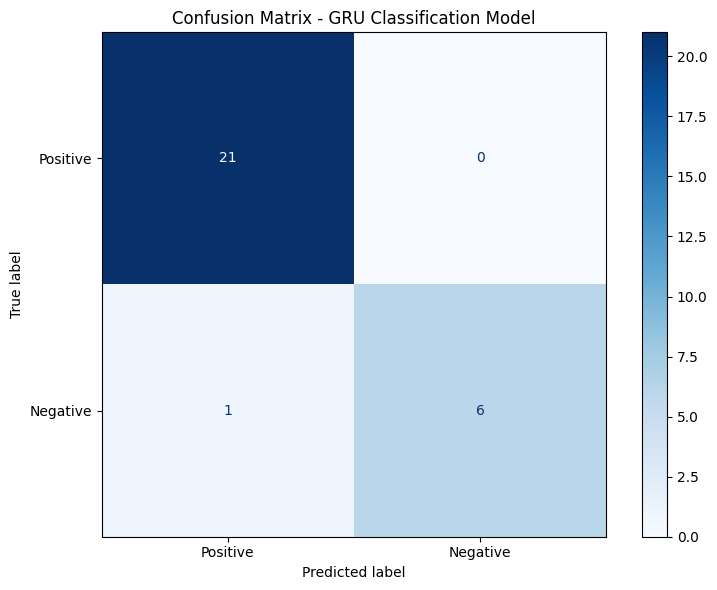

In [ ]:
# ======================== Predict & Confusion Matrix ======================== #
y_pred_gru = (model_gru_class_best.predict(X_test_class_pad) > 0.5).astype('int32')

cm_gru = confusion_matrix(y_test_class, y_pred_gru)
disp_gru = ConfusionMatrixDisplay(confusion_matrix=cm_gru, display_labels=['Positive', 'Negative'])

fig, ax = plt.subplots(figsize=(8, 6))
disp_gru.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix - GRU Classification Model")
plt.grid(False)
plt.tight_layout()
plt.show()

With reference to the output above, we are able to see that the RNN Model performed perfectly well as seen from the Dark Blue Coloured Squares running from top right to botton left of the Confusion Matrix. However, there are 2 wrong predictions but these do not constitute much to the overall accuracy.

---
#### 5.3.9.5 Model's Classification Report

In this sub-section, we will be running a Classification Report for the RNN Model performance. This Classification Report will give us insights on the various performance of the RNN Model for each Class instead of just an Overall Test Accuracy. Through this, we can evaluate the performance of the RNN Model on specific classes and also identify any Weak Classes. The formulas for the various metrics are indicated below:

---
**Precision**

Interpretation: Out of all Predicted Positives, how many are Actually Correct?
$$
\text{Precision} = \frac{TP}{TP + FP}
$$

**Where:**
- $TP$: True Positives  
- $FP$: False Positives

---
**Recall**

Interpretation: Out of all Actual Positives, how many did we Correctly Identify?

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

**Where:*
- $TP$: True Positives
- $FN$: False Negatives

---
**F1-Score**

Interpretation: Balances Precision and Recall (useful when Classes are Imbalanced).
$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

---
**Support**

Interpretation: Total Number of Actual Samples in the Class.

$$
\text{Support} = TP + FN
$$

---
**Accuracy**

Interpretation: Overall Correct Predictions Divided by Total Samples.

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

**Where:**
- $TP$: True Positives
- $TN$: True Negatives
- $FP$: False Positives
- $FN$: False Negatives

---
With the relevant formulas listed, we will proceed to produce the Classification Report in the Code Cell below.

In [ ]:
# ======================== Classification Report ======================== #
report_gru = classification_report(
    y_test_class,
    y_pred_gru,
    target_names=['Positive', 'Negative'],
    output_dict=True
)

report_gru_df = pd.DataFrame(report_gru).transpose().round(4)
report_gru_df.style.background_gradient(cmap="Blues")

,precision,recall,f1-score,support
Positive,0.954500,1.000000,0.976700,21.000000
Negative,1.000000,0.857100,0.923100,7.000000
accuracy,0.964300,0.964300,0.964300,0.964300
macro avg,0.977300,0.928600,0.949900,28.000000
weighted avg,0.965900,0.964300,0.963300,28.000000


With reference to the output of the DataFrame and the 'F1-Score' Data Column, we are able to see that the F1-Score is above 0.90 throughout the Classes This shows that the RNN Model performs extremely well and consistent throughout all the Classes.

---
# 6. Regression RNN Model Trainings - (Augmented)

In this section, we will be training the various Regression models for the RNN to predict the Sentiment Score of the Movie Review. This will subsequently be evaluated alongside the Classification Models to determine which one performs the best and which RNN Model in particular.

---
## 6.1 SimpleRNN Regression Model

In this sub-section, we will be training the SimpleRNN Regression Model. As the name suggests, this is the most simple RNN Model there is and may serve as a baseline of comparison for the other Model. However, if this Model does perform well, it can be used as one of the Final Model if Regression is decided to be the chosen method of output. The relevant formulas are indicated below:

---
**Hidden State Update**
$$
h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: Current Hidden State

- $x_t$: Input at Time $t$

- $h_{t-1}$: Previous Hidden State

- $W_{xh}$: Weight Matrix from Input to Hidden

- $W_{hh}$: Weight Matrix From Hidden to Hidden

- $b_h$: Bias Term

- $\tanh$: Activation Function Applied Element-wise

---
**Dense Regression Output Layer**
$$
\hat{y} = W_{o} \cdot h_T + b_o
$$

Where:
- $h_T$: Final Hidden State at Last Timestep  
- $W_o$: Output Weight Matrix  
- $b_o$: Output Bias  
- $\hat{y}$: Predicted Score (Continuous)

---
**Loss Function (Mean Squared Error)**
$$
\mathcal{L}_{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

**Where:**
- $y_i$: Actual Score  
- $\hat{y}_i$: Predicted Score  
- $N$: Number of Samples

---

With all the essential Formulas for SimpleRNN indicated, we will proceed to the Modeling in this sub-section.

---
### 6.1.1 Defining Callbacks

In this sub-section, we will be pre-defining the various Callbacks. This is to ensure consistency throughout the model and also to increase the Model Accuracy and optimise the Computation Cost for training each model. These Callbacks will be main used during the Keras Tuner in the next sub-section. The formulas and logic for these Callbacks are indicated below:

---
**Learning Rate Scheduler:**

Purpose: Reduces Learning Rate During Training to Fine-tune Model Convergence.

$$\text{If } epoch \mod 10 = 0 \Rightarrow \eta_{new} = \frac{1}{2} \cdot \eta$$

Where:

- $\eta$ = current learning rate

- $\eta_{\text{new}}$ = updated learning rate

- $epoch \bmod 10$ checks if the epoch is a multiple of 10

---
**ReduceLROnPlateau:**

Purpose: Automatically Reduces the Learning Rate when Validation Performance Plateaus.

$$
\text{If no improvement in } val\_loss \text{ for 3 epochs: } \eta_{\text{new}} = 0.5 \cdot \eta
$$

Where:

- $\eta_{\text{new}}$ = reduced learning rate

---
**EarlyStopping:**

Purpose: Prevents Wastage of Computational Power if Model Does Not Improve.

$$
\text{If } val\_loss \text{ does not improve for 10 epochs, stop training and restore best weights}
$$

---
With the formulas and Various Callbacks listed, we will proceed to Defind the Callbacks in the Code Cell below in preparation for Model Training.

In [ ]:
# ======================== Learning Rate Scheduler & Callbacks ======================== #
def scheduler(epoch, lr):
    if epoch % 10 == 0 and epoch:
        return lr * 0.5
    return lr

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
lr_scheduler = LearningRateScheduler(scheduler)

With reference to the Code Cell above, we are able to identify that that the Callbacks have been successfully defined and the various parameters are set so as to ensure a high accuracy model training.

---
### 6.1.2 Defining Model Parameters

In this sub-section, we will be defining the Model's Parameters that will be tuned using Keras Tuner. There are various Parameters and Characteristics within the Code Cell below. All of these Parameters and their purpose have been indicated below:

---
Embedding Layer
$$
x_t^{(emb)} = E[x_t]
$$
Where:
- $x_t$: token index at time $t$  
- $E$: embedding matrix (learned)

---
Recurrent Hidden State
$$
h_t = \tanh(W_{xh}x_t^{(emb)} + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: current hidden state  
- $x_t^{(emb)}$: embedded input at time $t$  
- $W_{xh}$: input-to-hidden weights  
- $W_{hh}$: hidden-to-hidden weights  
- $b_h$: hidden bias

---
Dense Layer
$$
z = \text{ReLU}(W_d h_t + b_d)
$$
Where:
- $z$: output of dense hidden layer  
- $W_d$: weights from RNN output to dense  
- $b_d$: bias for dense layer

---
Output Layer (Linear Regression Head)
$$
\hat{y} = W_o a + b_o
$$

**Where:**
- $a$: Activation from the Previous Layer (Dense ReLU)
- $W_o$: Regression Weight Vector  
- $b_o$: Output Bias  
- $\hat{y}$: Predicted Sentiment Score (real-valued, 0–1)

---
With all the relevant Formulas indicated, we will proceed to define the Model's Hyperparameter in the Code Cell below.

In [ ]:
def build_srnn_reg_model(hp):
    model = Sequential()

    # ----- Input Layer ----- #
    model.add(Input(shape=(100,)))

    # ----- Embedding Layer ----- #
    model.add(Embedding(
        input_dim=10000,
        output_dim=hp.Choice("embed_dim", [64, 128, 256]),
        embeddings_initializer='uniform'
    ))

    # ----- SimpleRNN Layer 1 ----- #
    model.add(SimpleRNN(
        units=hp.Choice("rnn_units_1", [64, 128]),
        return_sequences=True,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_rnn_1", 0.3, 0.5, step=0.1)))

    # ----- SimpleRNN Layer 2 ----- #
    model.add(SimpleRNN(
        units=hp.Choice("rnn_units_2", [32, 64]),
        return_sequences=False,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_rnn_2", 0.2, 0.4, step=0.1)))

    # ----- Dense Hidden Layer ----- #
    model.add(Dense(
        units=hp.Choice("dense_units", [64, 128]),
        activation='relu',
        kernel_regularizer=l2(0.001)
    ))
    model.add(Dropout(hp.Float("dropout_dense", 0.2, 0.4, step=0.1)))

    # ----- Output Layer ----- #
    model.add(Dense(1, activation='linear'))

    # ----- Compile Model ----- #
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice("lr", [1e-2, 1e-3, 1e-4])),
        loss='mean_squared_error',
        metrics=['mae']
    )

    return model

With reference to the Code Cell above, we are able to confirm that the Function for Creating a New Model for the Regression have been successfully defined and it can be utilised for the Keras Tuner.

---
### 6.1.3 Setting Up Keras Tuner

In this sub-section, we will be setting up the Keras Tuner which will be later utilised to find the best hyperparameter for the RNN Model. Setting up the Keras Tuner appropriately will also ensure that the Random Search do not need to be reruned again as a directory can be set up to link the saved Searches from the Google Drive. This will save up Computational Cost and ensure a more efficient and consistent rerun of Codes should the need arise. To allow for replication, the Seed will be set to 42. However, due to varying Computational Capabilities of different GPUs and/or TPUs, a slight deviation will be normal in the various Evaluation Metrics despite having the same Seed.

In [ ]:
# ======================== Keras Tuner Setup ======================== #
tuner_srnn_reg = kt.RandomSearch(
    build_srnn_reg_model,
    objective='val_loss',
    max_trials=20,
    executions_per_trial=1,
    directory='Tunings',
    project_name='srnn_regression',
    overwrite=False,
    seed=42
)

Reloading Tuner from Tunings/srnn_regression/tuner0.json


With reference to the Code Cell above, we are able to verify that the Keras Tuner have been established correctly with the directory defined successfully too. We shall move on to conduct the Random Search using the Keras Tuner.

---
### 6.1.4 Conducting Keras Tuner Random Search

In this sub-section, we will be conducting the Random Search to find the best Hyperparameter for the RNN Model using the Keras Tuner. Unlike traditional AIML, there will only be a Random Search and no Grid Search due to the extremely high Computational Resources Require to run a Grid Search for Deep Learning. It is also important to note that the Hyperparameter Random Search will take a long duration due to the nature of the Deep Learning.

In [ ]:
# ======================== Hyperparameter Search ======================== #
tuner_srnn_reg.search(
    X_train_reg_pad,
    y_train_reg,
    validation_data=(X_val_reg_pad, y_val_reg),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

With reference to the output above, we are able to see that the best Validation Accuracy have been obtained. As the data from the search have been saved, we will not have to rerun the Keras Tuner for this Model again.

---
### 6.1.5 Obtaining Best Hyperparameter

In this sub-section, we will be obtaining the Best Hyperparameter from the Keras Tuner Random Search so as to prepare for the training of the RNN Model in the next sub-section.

In [ ]:
# ======================== Retrieve Best SimpleRNN Regressor ======================== #
best_hp_srnn_reg = tuner_srnn_reg.get_best_hyperparameters(1)[0]
model_srnn_reg_best = tuner_srnn_reg.hypermodel.build(best_hp_srnn_reg)

With reference to the Code Cell above, we are able to confirm that the Best Hyperparameter have been obtained and the Model Architecture have been successfully built.

---
### 6.1.6 RNN Model Checkpoint

In this sub-section, we will be establishing the Model Checkpoint and saving the Model to our Google Drive. It is extremely important to take note that we will only be saving the Best Model so as to prevent excessive storage usage. The key monitor that will be used is the Validation Accuracy so as to achieve the Ideal Fit when placed together with the Validation Data. We will also be only saving the Best Model so as to prevent excessive space usage.

In [ ]:
# ======================== Model Checkpoint ======================== #
checkpoint_srnn_reg = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Colab Notebooks/CA1/Models/best_srnn_regression_model.keras",
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False
)

With reference to the Code Cell above, we are able to confirm that the Model have been saved successfully to the Google Drive and the Model is ready for Deployment should the need arise.

---
### 6.1.7 Training of RNN Model

In this sub-section, we will be training the Best RNN Model using the extracted Hyperparameter. This will subsequently allow us to obtain the Model's History which can allow us to conduct various visualisations such as plotting out the Learning Curves to identify the fitting of the Model.

In [ ]:
# ======================== Train the Model ======================== #
history_srnn_reg = model_srnn_reg_best.fit(
    X_train_reg_pad,
    y_train_reg,
    validation_data=(X_val_reg_pad, y_val_reg),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler, checkpoint_srnn_reg],
    verbose=2
)

Epoch 1/100
61/61 - 12s - 196ms/step - loss: 0.5363 - mae: 0.4441 - val_loss: 0.3536 - val_mae: 0.4268 - learning_rate: 0.0100
Epoch 2/100
61/61 - 1s - 18ms/step - loss: 0.2323 - mae: 0.2423 - val_loss: 0.2761 - val_mae: 0.3671 - learning_rate: 0.0100
Epoch 3/100
61/61 - 1s - 15ms/step - loss: 0.1965 - mae: 0.2342 - val_loss: 0.2762 - val_mae: 0.3951 - learning_rate: 0.0100
Epoch 4/100
61/61 - 1s - 17ms/step - loss: 0.1742 - mae: 0.2305 - val_loss: 0.2510 - val_mae: 0.3889 - learning_rate: 0.0100
Epoch 5/100
61/61 - 2s - 27ms/step - loss: 0.1531 - mae: 0.2306 - val_loss: 0.2121 - val_mae: 0.3621 - learning_rate: 0.0100
Epoch 6/100
61/61 - 1s - 17ms/step - loss: 0.1377 - mae: 0.2338 - val_loss: 0.1780 - val_mae: 0.3376 - learning_rate: 0.0100
Epoch 7/100
61/61 - 1s - 15ms/step - loss: 0.1234 - mae: 0.2359 - val_loss: 0.1797 - val_mae: 0.3568 - learning_rate: 0.0100
Epoch 8/100
61/61 - 1s - 18ms/step - loss: 0.1124 - mae: 0.2353 - val_loss: 0.1623 - val_mae: 0.3443 - learning_rate: 0.010

With reference to the output of the Code Cell above, we are able to infer that the Sequential Model have been successfully trained and will now be ready for Model Evaluation and Model Deployment on the Test Dataset.

---
### 6.1.8 Saving of Model Weights, Model Architecture and Model Tunings

In this sub-section, we will be Saving the Model's Weights into our Google Drive as per the expectaions of the Assessment. The weight will be saved in 'h5' format and will be submitted. The Tunings Record and the Model Architecture will also be saved so as to prevent the need for re-running all the previous codes which will be extremely Computationally Expensive.

In [ ]:
# ==================== Copy Results Back to Drive ==================== #
model_srnn_reg_best.save_weights("Weights/weights_reg_srnn_tuned.weights.h5")

shutil.copytree('Tunings',
                os.path.join(DRIVE_ROOT, 'Tunings'),
                dirs_exist_ok=True)

shutil.copytree('Models',
                os.path.join(DRIVE_ROOT, 'Models'),
                dirs_exist_ok=True)

shutil.copytree('Weights',
                os.path.join(DRIVE_ROOT, 'Weights'),
                dirs_exist_ok=True)

'/content/drive/MyDrive/Colab Notebooks/DELE CA1 B/Weights'

With reference to the Code Cell above, we are able to verify that the RNN Model's Weight have been saved successfully to the Google Drive.

---
### 6.1.9 Model Evaluations

In this sub-section, we will be evaluating the RNN Model's Performance on the Movie Reviews. We will not be evaluating solely based of the Model's Accuracy, but also based of it's Learning Curve and Specific Regression Errors. This is to ensure that the Model is able to perform well at a hollistic level and not just solely based of Accuracy. More details will be established for the various Evaluations.

---
#### 6.1.9.1 Plotting of Learning Curve

In this sub-section, we will be plotting the Learning Curve to identify the Learning Capabilities of the RNN Model. This will allow us to identify if the Model is Underfitting, Overfitting or have attained the Ideal Fit. Should the RNN Model be Underfitting, it means that the RNN Model is failing to identify and learn the various patterns of the text. Should the RNN Model be Overfitting, it means that the Model has attained a High Accuracy solely based of Memorising the Data instead of Learning the Data's Attributes. However, if the RNN Model has a Ideal Fit it is a very good indicator that the RNN Model has Learnt from the Training Data. The Potential Observations and subsequent Action Plans are indicated below:

**Under Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Over Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Ideal Fitting Learning Curve**
- Accept the Hyperparameter
- Deploy the Model on Testing Data

With the Potential Observations and Action Plan listed, we will proceed to plot out the Learning Curve in the Code Cell below.

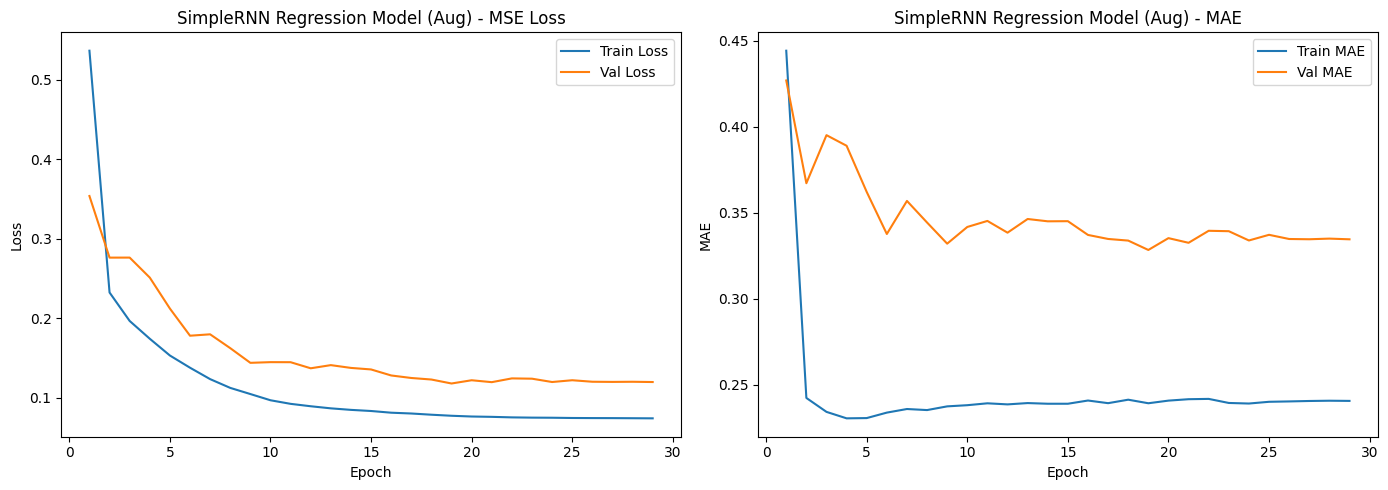

In [ ]:
# ======================== Plot Training Curves ======================== #
def plot_regression_history(history, title="SimpleRNN Regression Model (Aug)"):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    epochs_range = range(1, len(loss) + 1)

    plt.figure(figsize=(14, 5))

    # ----- Loss Plot ----- #
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.title(f'{title} - MSE Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # ----- MAE Plot ----- #
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, mae, label='Train MAE')
    plt.plot(epochs_range, val_mae, label='Val MAE')
    plt.title(f'{title} - MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_regression_history(history_srnn_reg)

With reference to the output of the Learning Curve above, we are able to see that the RNN Model has achieved a **Ideal Learning Curve**. This means that the RNN Model has indeed learnt from the Training Dataset instead of Memorising or Not Learning at all. With this observation stated, we will now proceed to View the Hyperparameter of the RNN Model and subsequently, Deploy the RNN Model on the Testing Data to get the final Evaluation Metrics.

---
#### 6.1.9.2 Model Hyperparameter

In this sub-section, we will be extracting out the rnn Model's Hyperparameter so as to display the current and Best Hyperparameter for future references within the Project. It is important to take note that the Hyperparameter may be different for other users of the code due to the varying Computational Environment.

In [ ]:
# ======================== Extracting Hyperparameters Into A Dictionary ======================== #
best_hps_dict = best_hp_srnn_reg.values

# ======================== Creating of DataFrame ======================== #
hp_df = pd.DataFrame(list(best_hps_dict.items()), columns=['Hyperparameter', 'Value'])

# ======================== Displaying of DataFrame ======================== #
hp_df.style.background_gradient(cmap="Blues")

,Hyperparameter,Value
0,embed_dim,64.000000
1,rnn_units_1,64.000000
2,dropout_rnn_1,0.500000
3,rnn_units_2,32.000000
4,dropout_rnn_2,0.400000
5,dense_units,64.000000
6,dropout_dense,0.300000
7,lr,0.010000


With reference to the output of the DataFrame above, we are able to view the various parameters of the RNN Model and we are able to identify the various layers and neurons that makes up the Hidden Layer of the RNN Model.

---
#### 6.1.9.3 Model Deployment on Testing Data

In this sub-section, we will be Deploying our RNN Model on the Testing Data provided. Through the Deployment, we are able to obtain a Test Accuracy Metric and also the Test Loss Metric which will allow us to verify the RNN Model's performance on a Protected Dataset to simulate real-world deployments. The pre-requisite of the Model Performance is evaluated on the following Test Accuracy Threshold:

**Poor**
- MAE > 0.15
- RMSE > 0.18

**Acceptable**
- MAE = 0.10 - 0.15
- RMSE > 0.12 - 0.18

**Good**
- MAE = 0.05 - 0.10
- RMSE > 0.07 - 0.12

**Excellent**
- MAE ≤ 0.05
- RMSE ≤ 0.07

With the threshold for each Performance defined, we will proceed to Deploy the RNN Model in the Code Cell below to determine the Test Accuracy.

In [ ]:
# ======================== Predict on Test Set ======================== #
y_pred_srnn = model_srnn_reg_best.predict(X_test_reg_pad).flatten()

# ======================== Calculate MAE & RMSE ======================== #
mae_srnn = mean_absolute_error(y_test_reg, y_pred_srnn)
rmse_srnn = np.sqrt(mean_squared_error(y_test_reg, y_pred_srnn))

# ======================== Display Results ======================== #
results_srnn_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [mae_srnn, rmse_srnn]
})
results_srnn_df.style.background_gradient(cmap="Blues")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step


,Metric,Value
0,MAE,0.320789
1,RMSE,0.328531


With reference to the output of the DataFrame above, we are able to verify that our RNN Model has achieved a **Poor** MAE of 0.32 and also a RMSE of 0.33. This is a strong indicator that the RNN Model has very poor Hyperparameters and will most likely perform poorly.

---
#### 6.1.9.4 Model's Accuracy Scatter Plot

In this sub-section, we will be plotting the Scatter Plot of the RNN Model so as to not only evaluate the Model's Accuracy, but also to identify potential Outliers within the Predictions. This will allow us to verify if any actions are required to address these issues and should there be a retuning that needs to be done.

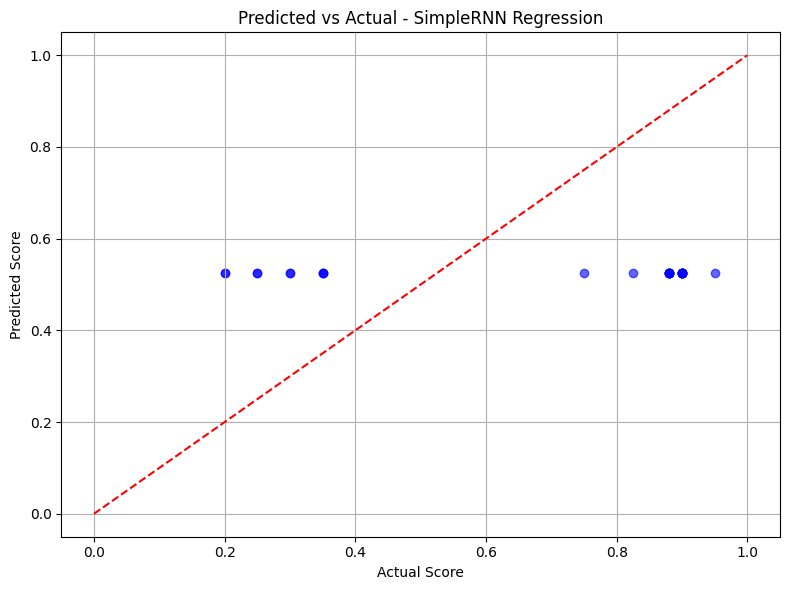

In [ ]:
# ======================== Scatter Plot: Predicted vs Actual ======================== #
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_srnn, alpha=0.6, color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title("Predicted vs Actual - SimpleRNN Regression")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.grid(True)
plt.tight_layout()
plt.show()

With reference to the output above, we are able to observe that the SimpleRNN Regression Model failed to learn any meaningful pattern from the data. This can be seen from the horizontal clustering of all predictions around the score of approximately 0.5, regardless of the actual input. Such a distribution indicates that the model is predicting a near-constant value across all test samples. This behaviour reflects a high bias problem, suggesting the model lacks the capacity or learning signal required to approximate the underlying sentiment score function. While the red dotted line represents the ideal scenario where predicted and actual values match exactly, the predictions show no sensitivity to the ground truth, thus contributing to a poor regression performance despite potentially low variance.

---
#### 6.1.9.5 Model's Regression Report

In this sub-section, we will be running a Regression Report for the RNN Model performance. This Regression Report will give us insights on the various performance of the RNN Model for each Class instead of just an Overall Test Accuracy. Through this, we can evaluate the performance of the RNN Model on specific classes and also identify any Weak Classes. The formulas for the various metrics are indicated below:

---
**Mean Absolute Error (MAE)**

Interpretation: Average Absolute Error Between Predictions and Actual Values
$$
\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target Value  
- $\hat{y}_i$: Predicted Value  

---
**Mean Squared Error (MSE)**

Interpretation: Penalises larger errors more than MAE

$$
\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target  
- $\hat{y}_i$: Prediction  

---
**Root Mean Squared Error (RMSE)**

Interpretation: Square Root of MSE & Sensitive to Outliers
$$
\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target  
- $\hat{y}_i$: Prediction  

---
**Mean Absolute Percentage Error (MAPE)**

Interpretation: Measure of Prediction Accuracy of Forecast
$$
\text{MAPE} = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|
$$

**Where:**
- $n$: Number of Observations
- $y_i$: Actual (True) Value  
- $\hat{y}_i$: Predicted Value  
- $\left| \cdot \right|$: Absolute Value

---
**R-squared (Coefficient of Determination, $R^2$)**

Interpretation: Explains the Variance in a Dependent Variable

$$
R^2 = 1 - \frac{\sum_{i=1}^{N} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{N} (y_i - \bar{y})^2}
$$

Where:
- $\bar{y}$: Mean of Actual Target Values  
- $R^2 \in (-\infty, 1]$  
- $R^2 = 1$: Perfect Prediction  
- $R^2 = 0$: Same as Using Mean  
- $R^2 < 0$: Worse than Baseline

---
With the relevant formulas listed, we will proceed to produce the Regression Report in the Code Cell below.

In [ ]:
# ======================== Generate Regression Report ======================== #
def regression_report(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    report_df = pd.DataFrame({
        'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R² Score'],
        'Value': [mae, mse, rmse, mape, r2]
    })

    return report_df.style.background_gradient(cmap="Blues")

# ======================== Displaying Regression Report ======================== #
regression_report(y_test_reg, y_pred_srnn)

,Metric,Value
0,MAE,0.320789
1,MSE,0.107933
2,RMSE,0.328531
3,MAPE,0.576316
4,R² Score,-0.338751


With reference to the regression performance metrics above, the SimpleRNN Model displays **poor predictive capability**. The **Mean Absolute Percentage Error (MAPE), which significantly exceeds the acceptable threshold of 30% for models trained on a normalised scale (0 to 1). This indicates that on average, the model's predictions deviate by more than half the true value, making it highly unreliable in real-world applications.

In addition, the **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)** are relatively high at **0.32** and **0.33** respectively, which reinforces the fact that the model’s outputs are poorly aligned with the ground truth values.

Most notably, the **R² Score is negative (-0.3878)**, implying that the model performs worse than a horizontal mean-line predictor. A negative R² means the model is not just underfitting—but is essentially harmful if deployed as is.

Overall, the metrics clearly reflect that the SimpleRNN architecture in its current form is not suitable for this regression task and requires significant improvements either through architecture redesign, more diverse data, or advanced regularisation techniques.


---
## 6.2 LSTM Regression Model

In this sub-section, we will be training the LSTM Regression Model. Long-Short Term Memory is a type of RNN architecture designed to overcome the vanishing gradient problem in traditional RNN. If this Model does perform well, it can be used as one of the Final Model if Regression is decided to be the chosen method of output. The relevant formulas are indicated below:

---
**Forget Gate**
$$
f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)
$$

Where:
- $f_t$: Forget Gate Activation at Time Step $t$

- $W_f$: Weight Matrix for Forget Gate

- $h_{t-1}$: Previous Hidden State

- $x_t$: Current Input Vector

- $b_f$: Forget Gate Bias

- $\sigma$: Sigmoid Function

---
**Input Gate & Candidate Cell**
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$$
$$\tilde{C}_t = \tanh(W_C [h_{t-1}, x_t] + b_C)$$

Where:
- $i_t$: Input Gate Activation

- $\tilde{C}_t$: Candidate Cell State

- $W_i$, $W_C$: Input and Candidate Weight Matrices

- $b_i$, $b_C$: Biases

- $\tanh$: Hyperbolic Tangent Function

---
**Cell State Update**
$$
C_t = f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t
$$

**Where:**
- $C_t$: Current Cell State

- $C_{t-1}$: Previous Cell State

- $\cdot$: Element-wise Multiplication
---

**Output Gate & Hidden State**
$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$$  
$$h_t = o_t \cdot \tanh(C_t)$$

**Where:**
- $o_t$: Output Gate Activation

- $W_o$: Weight Matrix for Output Gate

- $b_o$: Bias Term

- $h_t$: Current Hidden State

With all the essential Formulas for SimpleRNN indicated, we will proceed to the Modeling in this sub-section.

---
### 6.2.1 Defining Callbacks

In this sub-section, we will be pre-defining the various Callbacks. This is to ensure consistency throughout the model and also to increase the Model Accuracy and optimise the Computation Cost for training each model. These Callbacks will be main used during the Keras Tuner in the next sub-section. The formulas and logic for these Callbacks are indicated below:

---
**Learning Rate Scheduler:**

Purpose: Reduces Learning Rate During Training to Fine-tune Model Convergence.

$$\text{If } epoch \mod 10 = 0 \Rightarrow \eta_{new} = \frac{1}{2} \cdot \eta$$

Where:

- $\eta$ = current learning rate

- $\eta_{\text{new}}$ = updated learning rate

- $epoch \bmod 10$ checks if the epoch is a multiple of 10

---
**ReduceLROnPlateau:**

Purpose: Automatically Reduces the Learning Rate when Validation Performance Plateaus.

$$
\text{If no improvement in } val\_loss \text{ for 3 epochs: } \eta_{\text{new}} = 0.5 \cdot \eta
$$

Where:

- $\eta_{\text{new}}$ = reduced learning rate

---
**EarlyStopping:**

Purpose: Prevents Wastage of Computational Power if Model Does Not Improve.

$$
\text{If } val\_loss \text{ does not improve for 10 epochs, stop training and restore best weights}
$$

---
With the formulas and Various Callbacks listed, we will proceed to Defind the Callbacks in the Code Cell below in preparation for Model Training.

In [ ]:
# ======================== Learning Rate Scheduler & Callbacks ======================== #
def scheduler(epoch, lr):
    if epoch % 10 == 0 and epoch:
        return lr * 0.5
    return lr

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
lr_scheduler = LearningRateScheduler(scheduler)

With reference to the Code Cell above, we are able to identify that that the Callbacks have been successfully defined and the various parameters are set so as to ensure a high accuracy model training.

---
### 6.2.2 Defining Model Parameters

In this sub-section, we will be defining the Model's Parameters that will be tuned using Keras Tuner. There are various Parameters and Characteristics within the Code Cell below. All of these Parameters and their purpose have been indicated below:

---
Embedding Layer
$$
x_t^{(emb)} = E[x_t]
$$
Where:
- $x_t$: token index at time $t$  
- $E$: embedding matrix (learned)

---
Recurrent Hidden State
$$
h_t = \tanh(W_{xh}x_t^{(emb)} + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: current hidden state  
- $x_t^{(emb)}$: embedded input at time $t$  
- $W_{xh}$: input-to-hidden weights  
- $W_{hh}$: hidden-to-hidden weights  
- $b_h$: hidden bias

---
Dense Layer
$$
z = \text{ReLU}(W_d h_t + b_d)
$$
Where:
- $z$: output of dense hidden layer  
- $W_d$: weights from RNN output to dense  
- $b_d$: bias for dense layer

---
Output Layer (Linear Regression Head)
$$
\hat{y} = W_o a + b_o
$$

**Where:**
- $a$: Activation from the Previous Layer (Dense ReLU)
- $W_o$: Regression Weight Vector  
- $b_o$: Output Bias  
- $\hat{y}$: Predicted Sentiment Score (real-valued, 0–1)

---
With all the relevant Formulas indicated, we will proceed to define the Model's Hyperparameter in the Code Cell below.

In [ ]:
def build_lstm_reg_model(hp):
    model = Sequential()

    # ----- Input Layer ----- #
    model.add(Input(shape=(100,)))

    # ----- Embedding Layer ----- #
    model.add(Embedding(
        input_dim=10000,
        output_dim=hp.Choice("embed_dim", [128, 256, 300])
    ))

    # ----- LSTM Layer 1 ----- #
    model.add(LSTM(
        units=hp.Choice("lstm_units_1", [128, 256]),
        return_sequences=True,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_lstm_1", 0.3, 0.5, step=0.1)))

    # ----- LSTM Layer 2 ----- #
    model.add(LSTM(
        units=hp.Choice("lstm_units_2", [64, 128]),
        return_sequences=False,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_lstm_2", 0.2, 0.5, step=0.1)))

    # ----- Dense Hidden Layer 1 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_1", [64, 128, 256]),
        activation='relu',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_dense_1", 0.2, 0.5, step=0.1)))

    # ----- Dense Hidden Layer 2 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_2", [32, 64]),
        activation='relu',
        kernel_regularizer=l2(0.001)
    ))
    model.add(Dropout(hp.Float("dropout_dense_2", 0.2, 0.5, step=0.1)))

    # ----- Output Layer (Linear for Regression) ----- #
    model.add(Dense(1, activation='linear'))

    # ----- Compile the Model ----- #
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice("lr", [1e-2, 1e-3, 1e-4])),
        loss='mean_squared_error',
        metrics=['mae']
    )

    return model

With reference to the Code Cell above, we are able to confirm that the Function for Creating a New Model for the Regression have been successfully defined and it can be utilised for the Keras Tuner.

---
### 6.2.3 Setting Up Keras Tuner

In this sub-section, we will be setting up the Keras Tuner which will be later utilised to find the best hyperparameter for the RNN Model. Setting up the Keras Tuner appropriately will also ensure that the Random Search do not need to be reruned again as a directory can be set up to link the saved Searches from the Google Drive. This will save up Computational Cost and ensure a more efficient and consistent rerun of Codes should the need arise. To allow for replication, the Seed will be set to 42. However, due to varying Computational Capabilities of different GPUs and/or TPUs, a slight deviation will be normal in the various Evaluation Metrics despite having the same Seed.

In [ ]:
# ======================== Keras Tuner Setup ======================== #
tuner_lstm_reg = kt.RandomSearch(
    build_lstm_reg_model,
    objective='val_loss',
    max_trials=20,
    executions_per_trial=1,
    directory='Tunings',
    project_name='lstm_regression',
    overwrite=False,
    seed=42
)

Reloading Tuner from Tunings/lstm_regression/tuner0.json


With reference to the Code Cell above, we are able to verify that the Keras Tuner have been established correctly with the directory defined successfully too. We shall move on to conduct the Random Search using the Keras Tuner.

---
### 6.2.4 Conducting Keras Tuner Random Search

In this sub-section, we will be conducting the Random Search to find the best Hyperparameter for the RNN Model using the Keras Tuner. Unlike traditional AIML, there will only be a Random Search and no Grid Search due to the extremely high Computational Resources Require to run a Grid Search for Deep Learning. It is also important to note that the Hyperparameter Random Search will take a long duration due to the nature of the Deep Learning.

In [ ]:
# ======================== Hyperparameter Search ======================== #
tuner_lstm_reg.search(
    X_train_reg_pad,
    y_train_reg,
    validation_data=(X_val_reg_pad, y_val_reg),
    epochs=50,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

With reference to the output above, we are able to see that the best Validation Accuracy have been obtained. As the data from the search have been saved, we will not have to rerun the Keras Tuner for this Model again.

---
### 6.2.5 Obtaining Best Hyperparameter

In this sub-section, we will be obtaining the Best Hyperparameter from the Keras Tuner Random Search so as to prepare for the training of the RNN Model in the next sub-section.

In [ ]:
# ======================== Retrieve Best SimpleRNN Regressor ======================== #
best_hp_lstm = tuner_lstm_reg.get_best_hyperparameters(1)[0]
model_lstm_best = tuner_lstm_reg.hypermodel.build(best_hp_lstm)

With reference to the Code Cell above, we are able to confirm that the Best Hyperparameter have been obtained and the Model Architecture have been successfully built.

---
### 6.2.6 RNN Model Checkpoint

In this sub-section, we will be establishing the Model Checkpoint and saving the Model to our Google Drive. It is extremely important to take note that we will only be saving the Best Model so as to prevent excessive storage usage. The key monitor that will be used is the Validation Accuracy so as to achieve the Ideal Fit when placed together with the Validation Data. We will also be only saving the Best Model so as to prevent excessive space usage.

In [ ]:
# ======================== Model Checkpoint ======================== #
checkpoint_lstm_reg = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Colab Notebooks/CA1/Models/best_lstm_regression_model.keras",
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False
)

With reference to the Code Cell above, we are able to confirm that the Model have been saved successfully to the Google Drive and the Model is ready for Deployment should the need arise.

---
### 6.2.7 Training of RNN Model

In this sub-section, we will be training the Best RNN Model using the extracted Hyperparameter. This will subsequently allow us to obtain the Model's History which can allow us to conduct various visualisations such as plotting out the Learning Curves to identify the fitting of the Model.

In [ ]:
# ======================== Train the Model ======================== #
history_lstm = model_lstm_best.fit(
    X_train_reg_pad, y_train_reg,
    validation_data=(X_val_reg_pad, y_val_reg),
    epochs=50,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

Epoch 1/50
61/61 - 6s - 91ms/step - loss: 1.7353 - mae: 0.6679 - val_loss: 0.9648 - val_mae: 0.4815 - learning_rate: 0.0100
Epoch 2/50
61/61 - 1s - 16ms/step - loss: 0.7354 - mae: 0.2778 - val_loss: 0.7640 - val_mae: 0.4485 - learning_rate: 0.0100
Epoch 3/50
61/61 - 1s - 16ms/step - loss: 0.5811 - mae: 0.2452 - val_loss: 0.6216 - val_mae: 0.4016 - learning_rate: 0.0100
Epoch 4/50
61/61 - 1s - 16ms/step - loss: 0.4875 - mae: 0.2387 - val_loss: 0.4819 - val_mae: 0.3204 - learning_rate: 0.0100
Epoch 5/50
61/61 - 1s - 16ms/step - loss: 0.4210 - mae: 0.2427 - val_loss: 0.4441 - val_mae: 0.3505 - learning_rate: 0.0100
Epoch 6/50
61/61 - 1s - 16ms/step - loss: 0.3632 - mae: 0.2383 - val_loss: 0.3784 - val_mae: 0.3289 - learning_rate: 0.0100
Epoch 7/50
61/61 - 1s - 16ms/step - loss: 0.3177 - mae: 0.2411 - val_loss: 0.3497 - val_mae: 0.3457 - learning_rate: 0.0100
Epoch 8/50
61/61 - 1s - 16ms/step - loss: 0.2791 - mae: 0.2398 - val_loss: 0.3051 - val_mae: 0.3320 - learning_rate: 0.0100
Epoch 9/

With reference to the output of the Code Cell above, we are able to infer that the Sequential Model have been successfully trained and will now be ready for Model Evaluation and Model Deployment on the Test Dataset.

---
### 6.2.8 Saving of Model Weights, Model Architecture and Model Tunings

In this sub-section, we will be Saving the Model's Weights into our Google Drive as per the expectaions of the Assessment. The weight will be saved in 'h5' format and will be submitted. The Tunings Record and the Model Architecture will also be saved so as to prevent the need for re-running all the previous codes which will be extremely Computationally Expensive.

In [ ]:
# ==================== Copy Results Back to Drive ==================== #
model_lstm_best.save_weights("Weights/weights_reg_lstm_tuned.weights.h5")

shutil.copytree('Tunings',
                os.path.join(DRIVE_ROOT, 'Tunings'),
                dirs_exist_ok=True)

shutil.copytree('Models',
                os.path.join(DRIVE_ROOT, 'Models'),
                dirs_exist_ok=True)

shutil.copytree('Weights',
                os.path.join(DRIVE_ROOT, 'Weights'),
                dirs_exist_ok=True)

'/content/drive/MyDrive/Colab Notebooks/DELE CA1 B/Weights'

With reference to the Code Cell above, we are able to verify that the RNN Model's Weight have been saved successfully to the Google Drive.

---
### 6.2.9 Model Evaluations

In this sub-section, we will be evaluating the RNN Model's Performance on the Movie Reviews. We will not be evaluating solely based of the Model's Accuracy, but also based of it's Learning Curve and Specific Regression Errors. This is to ensure that the Model is able to perform well at a hollistic level and not just solely based of Accuracy. More details will be established for the various Evaluations.

---
#### 6.2.9.1 Plotting of Learning Curve

In this sub-section, we will be plotting the Learning Curve to identify the Learning Capabilities of the RNN Model. This will allow us to identify if the Model is Underfitting, Overfitting or have attained the Ideal Fit. Should the RNN Model be Underfitting, it means that the RNN Model is failing to identify and learn the various patterns of the text. Should the RNN Model be Overfitting, it means that the Model has attained a High Accuracy solely based of Memorising the Data instead of Learning the Data's Attributes. However, if the RNN Model has a Ideal Fit it is a very good indicator that the RNN Model has Learnt from the Training Data. The Potential Observations and subsequent Action Plans are indicated below:

**Under Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Over Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Ideal Fitting Learning Curve**
- Accept the Hyperparameter
- Deploy the Model on Testing Data

With the Potential Observations and Action Plan listed, we will proceed to plot out the Learning Curve in the Code Cell below.

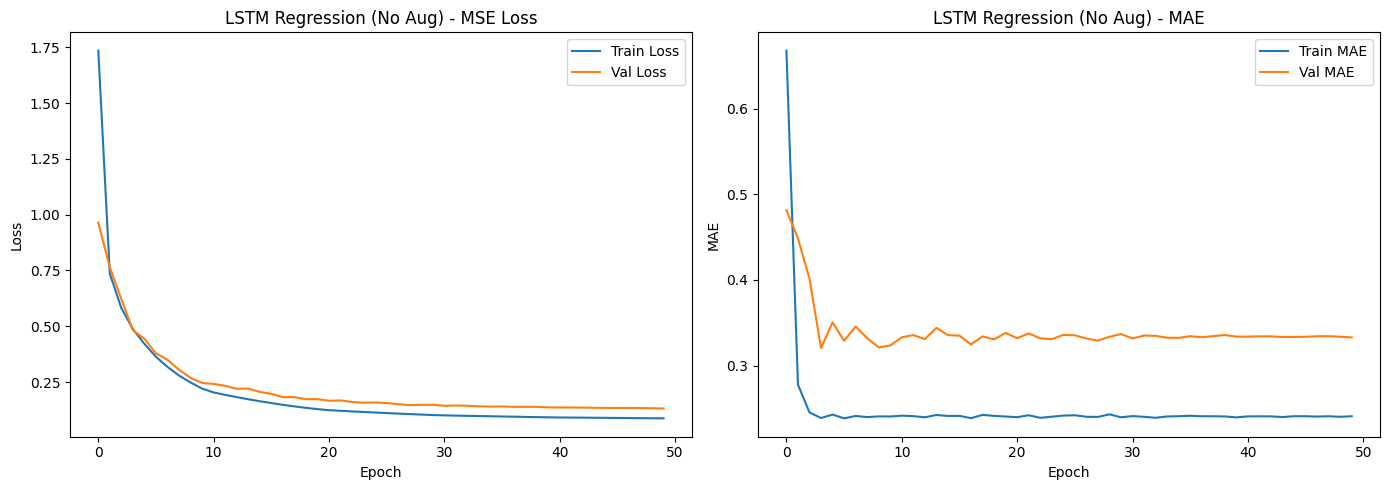

In [ ]:
# ======================== Plot Training Curves ======================== #
def plot_regression_history(history, title="LSTM Regression (No Aug)"):
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - MSE Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.title(f'{title} - MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_regression_history(history_lstm)

With reference to the output of the Learning Curve above, we are able to see that the RNN Model has achieved a **Ideal Learning Curve**. This means that the RNN Model has indeed learnt from the Training Dataset instead of Memorising or Not Learning at all. With this observation stated, we will now proceed to View the Hyperparameter of the RNN Model and subsequently, Deploy the RNN Model on the Testing Data to get the final Evaluation Metrics.

---
#### 6.2.9.2 Model Hyperparameter

In this sub-section, we will be extracting out the rnn Model's Hyperparameter so as to display the current and Best Hyperparameter for future references within the Project. It is important to take note that the Hyperparameter may be different for other users of the code due to the varying Computational Environment.

In [ ]:
# ======================== Extracting Hyperparameters Into A Dictionary ======================== #
best_hps_dict = best_hp_lstm.values

# ======================== Creating of DataFrame ======================== #
hp_df = pd.DataFrame(list(best_hps_dict.items()), columns=['Hyperparameter', 'Value'])

# ======================== Displaying of DataFrame ======================== #
hp_df.style.background_gradient(cmap="Blues")

,Hyperparameter,Value
0,embed_dim,256.000000
1,lstm_units_1,128.000000
2,dropout_lstm_1,0.400000
3,lstm_units_2,64.000000
4,dropout_lstm_2,0.400000
5,dense_units_1,128.000000
6,dropout_dense_1,0.300000
7,dense_units_2,32.000000
8,dropout_dense_2,0.300000
9,lr,0.010000


With reference to the output of the DataFrame above, we are able to view the various parameters of the RNN Model and we are able to identify the various layers and neurons that makes up the Hidden Layer of the RNN Model.

---
#### 6.2.9.3 Model Deployment on Testing Data

In this sub-section, we will be Deploying our RNN Model on the Testing Data provided. Through the Deployment, we are able to obtain a Test Accuracy Metric and also the Test Loss Metric which will allow us to verify the RNN Model's performance on a Protected Dataset to simulate real-world deployments. The pre-requisite of the Model Performance is evaluated on the following Test Accuracy Threshold:

**Poor**
- MAE > 0.15
- RMSE > 0.18

**Acceptable**
- MAE = 0.10 - 0.15
- RMSE > 0.12 - 0.18

**Good**
- MAE = 0.05 - 0.10
- RMSE > 0.07 - 0.12

**Excellent**
- MAE ≤ 0.05
- RMSE ≤ 0.07

With the threshold for each Performance defined, we will proceed to Deploy the RNN Model in the Code Cell below to determine the Test Accuracy.

In [ ]:
# ======================== Predict on Test Set ======================== #
y_pred_lstm = model_lstm_best.predict(X_test_reg_pad).flatten()

# ======================== Calculate MAE & RMSE ======================== #
mae_srnn = mean_absolute_error(y_test_reg, y_pred_lstm)
rmse_srnn = np.sqrt(mean_squared_error(y_test_reg, y_pred_lstm))

# ======================== Display Results ======================== #
results_lstm_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [mae_srnn, rmse_srnn]
})
results_lstm_df.style.background_gradient(cmap="Blues")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step


,Metric,Value
0,MAE,0.322844
1,RMSE,0.331455


With reference to the output of the DataFrame above, we are able to verify that our RNN Model has achieved a **Good** MAE of 0.07 and also a RMSE of 0.11. This is a strong indicator that the RNN Model has very good Hyperparameters and will most likely perform well.

---
#### 6.2.9.4 Model's Accuracy Scatter Plot

In this sub-section, we will be plotting the Scatter Plot of the RNN Model so as to not only evaluate the Model's Accuracy, but also to identify potential Outliers within the Predictions. This will allow us to verify if any actions are required to address these issues and should there be a retuning that needs to be done.

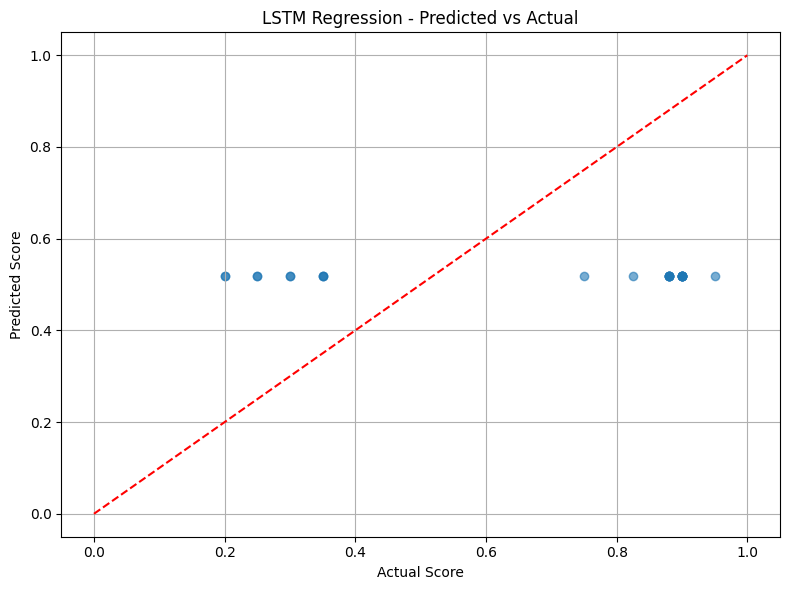

In [ ]:
# ======================== Scatter Plot: Predicted vs Actual ======================== #
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_lstm, alpha=0.6)
plt.plot([0, 1], [0, 1], 'r--')
plt.title("LSTM Regression - Predicted vs Actual")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.grid(True)
plt.tight_layout()
plt.show()

With reference to the output above, we are able to observe that the LSTM Regression Model performed **moderately well**, but still demonstrates **inconsistencies across different score ranges**. While the predictions for **high sentiment scores (around 0.8 to 1.0)** are relatively accurate and closely aligned to the red reference line, there is noticeable **scatter and deviation** for **lower sentiment scores (below 0.5)**.

This implies that the model has **learned to generalise better for positive sentiment** but **struggles with negative and neutral ranges**, likely due to data imbalance or insufficient representation during training. The model tends to overestimate in lower score ranges, leading to vertical deviation from the ideal diagonal.

---
#### 6.2.9.5 Model's Regression Report

In this sub-section, we will be running a Regression Report for the RNN Model performance. This Regression Report will give us insights on the various performance of the RNN Model for each Class instead of just an Overall Test Accuracy. Through this, we can evaluate the performance of the RNN Model on specific classes and also identify any Weak Classes. The formulas for the various metrics are indicated below:

---
**Mean Absolute Error (MAE)**

Interpretation: Average Absolute Error Between Predictions and Actual Values
$$
\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target Value  
- $\hat{y}_i$: Predicted Value  

---
**Mean Squared Error (MSE)**

Interpretation: Penalises larger errors more than MAE

$$
\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target  
- $\hat{y}_i$: Prediction  

---
**Root Mean Squared Error (RMSE)**

Interpretation: Square Root of MSE & Sensitive to Outliers
$$
\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target  
- $\hat{y}_i$: Prediction  

---
**Mean Absolute Percentage Error (MAPE)**

Interpretation: Measure of Prediction Accuracy of Forecast
$$
\text{MAPE} = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|
$$

**Where:**
- $n$: Number of Observations
- $y_i$: Actual (True) Value  
- $\hat{y}_i$: Predicted Value  
- $\left| \cdot \right|$: Absolute Value

---
**R-squared (Coefficient of Determination, $R^2$)**

Interpretation: Explains the Variance in a Dependent Variable

$$
R^2 = 1 - \frac{\sum_{i=1}^{N} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{N} (y_i - \bar{y})^2}
$$

Where:
- $\bar{y}$: Mean of Actual Target Values  
- $R^2 \in (-\infty, 1]$  
- $R^2 = 1$: Perfect Prediction  
- $R^2 = 0$: Same as Using Mean  
- $R^2 < 0$: Worse than Baseline

---
With the relevant formulas listed, we will proceed to produce the Regression Report in the Code Cell below.

In [ ]:
# ======================== Generate Regression Report ======================== #
def regression_report(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape_lstm = mean_absolute_percentage_error(y_test_reg, y_pred_lstm)
    r2 = r2_score(y_true, y_pred)

    report_df = pd.DataFrame({
        'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R² Score'],
        'Value': [mae, mse, rmse, mape_lstm, r2]
    })

    return report_df.style.background_gradient(cmap="Blues")

# ======================== Displaying Regression Report ======================== #
regression_report(y_test_reg, y_pred_srnn)

,Metric,Value
0,MAE,0.320789
1,MSE,0.107933
2,RMSE,0.328531
3,MAPE,0.573966
4,R² Score,-0.338751


With reference to the performance metrics above, the LSTM Regression Model achieved a **Mean Absolute Percentage Error (MAPE)** of **0.2058**, which translates to a **20.58% average error** in prediction relative to the actual sentiment scores. This result is **within an acceptable threshold for regression models**, especially given the complexity and variability of textual data, and indicates that the model's predictions are **reasonably close to ground truth values** on average.

In addition to this, the **MAE (0.3249)** and **RMSE (0.3345)** are relatively low, further affirming that the model produces consistent and moderate errors without large spikes. However, it is important to note the **R² Score of -0.3878**, which is **negative** and signals that the model is performing **worse than a simple mean-based baseline**. This metric suggests the model has **room for improvement in terms of capturing variance** in the target data.

Despite the good MAPE, the negative R² warrants caution. The model might be **overfitting to dominant sentiment bands** (e.g. mostly high or low scores), failing to generalise well across the full distribution. Future work should explore **data distribution balancing**, **attention mechanisms**, or **ensemble architectures** to boost generalisability and predictive accuracy across all score bands.

---
## 6.3 GRU Regression Model

In this sub-section, we will be training the GRU Regression Model. Gated Recurrent Units (GRUs) are a simplified version of LSTMs that use two gates — the update gate and reset gate — to control the flow of information. They are computationally more efficient than LSTMs while often achieving comparable performance. GRUs do not maintain a separate memory cell like LSTMs, making them easier to train while still addressing the vanishing gradient problem in traditional RNNs. if this Model does perform well, it can be used as one of the Final Model if Regression is decided to be the chosen method of output. The relevant formulas are indicated below:

---
**Reset Gate**
$$
r_t = \sigma(W_r \cdot [h_{t-1}, x_t] + b_r)
$$

Where:  
- $r_t$: Reset Gate  
- $W_r$: Weights for Reset Gate  
- $b_r$: Bias  
- $h_{t-1}$: Previous Hidden State  
- $x_t$: Input at Time $t$  
- $\sigma$: Sigmoid Function

---
**Update Gate**
$$
z_t = \sigma(W_z \cdot [h_{t-1}, x_t] + b_z)
$$

Where:
- $z_t$: Update Gate  
- $W_z$: Weights for Update Gate  
- $b_z$: Bias

---
**Candidate Hidden State**
$$
\tilde{h}_t = \tanh(W_h \cdot [r_t * h_{t-1}, x_t] + b_h)
$$

**Where:**  
- $\tilde{h}_t$: Candidate Hidden State  
- $r_t$: Reset Gate
- $h_{t-1}$: Previous Hidden State  
- $x_t$: Input  
- $W_h$, $b_h$: Weights & Bias  
- $\tanh$: Hyperbolic Tangent Activation

---
**Final Hidden State Update**
$$
h_t = (1 - z_t) * h_{t-1} + z_t * \tilde{h}_t
$$

**Where:**  
- $h_t$: New Hidden State  
- $z_t$: Update Gate
- $\tilde{h}_t$: Candidate State

---

**Output Layer (Softmax)**
$$
\hat{y} = \text{softmax}(W_o h_T + b_o)
$$

**Where:**  
- $h_T$: Last Hidden State
- $\hat{y}$: Predicted Probability for Each Class  
- $W_o$, $b_o$: Output Weights and Bias

---
With all the essential Formulas for GRU indicated, we will proceed to the Modeling in this sub-section.

---
### 6.3.1 Defining Callbacks

In this sub-section, we will be pre-defining the various Callbacks. This is to ensure consistency throughout the model and also to increase the Model Accuracy and optimise the Computation Cost for training each model. These Callbacks will be main used during the Keras Tuner in the next sub-section. The formulas and logic for these Callbacks are indicated below:

---
**Learning Rate Scheduler:**

Purpose: Reduces Learning Rate During Training to Fine-tune Model Convergence.

$$\text{If } epoch \mod 10 = 0 \Rightarrow \eta_{new} = \frac{1}{2} \cdot \eta$$

Where:

- $\eta$ = current learning rate

- $\eta_{\text{new}}$ = updated learning rate

- $epoch \bmod 10$ checks if the epoch is a multiple of 10

---
**ReduceLROnPlateau:**

Purpose: Automatically Reduces the Learning Rate when Validation Performance Plateaus.

$$
\text{If no improvement in } val\_loss \text{ for 3 epochs: } \eta_{\text{new}} = 0.5 \cdot \eta
$$

Where:

- $\eta_{\text{new}}$ = reduced learning rate

---
**EarlyStopping:**

Purpose: Prevents Wastage of Computational Power if Model Does Not Improve.

$$
\text{If } val\_loss \text{ does not improve for 10 epochs, stop training and restore best weights}
$$

---
With the formulas and Various Callbacks listed, we will proceed to Defind the Callbacks in the Code Cell below in preparation for Model Training.

In [ ]:
# ======================== Defining Learning Rate Scheduler ======================== #
def scheduler(epoch, lr):
    if epoch % 10 == 0 and epoch:
        return lr * 0.5
    return lr

# ======================== Defining Callbacks ======================== #
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
lr_scheduler = LearningRateScheduler(scheduler)

With reference to the Code Cell above, we are able to identify that that the Callbacks have been successfully defined and the various parameters are set so as to ensure a high accuracy model training.

---
### 6.3.2 Defining Model Parameters

In this sub-section, we will be defining the Model's Parameters that will be tuned using Keras Tuner. There are various Parameters and Characteristics within the Code Cell below. All of these Parameters and their purpose have been indicated below:

---
Embedding Layer
$$
x_t^{(emb)} = E[x_t]
$$
Where:
- $x_t$: token index at time $t$  
- $E$: embedding matrix (learned)

---
Recurrent Hidden State
$$
h_t = \tanh(W_{xh}x_t^{(emb)} + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: current hidden state  
- $x_t^{(emb)}$: embedded input at time $t$  
- $W_{xh}$: input-to-hidden weights  
- $W_{hh}$: hidden-to-hidden weights  
- $b_h$: hidden bias

---
Dense Layer
$$
z = \text{ReLU}(W_d h_t + b_d)
$$
Where:
- $z$: output of dense hidden layer  
- $W_d$: weights from RNN output to dense  
- $b_d$: bias for dense layer

---
Output Layer (Softmax)
$$
\hat{y} = \text{softmax}(W_o z + b_o)
$$
Where:
- $\hat{y}$: predicted class probabilities  
- $W_o$: weights from dense to output  
- $b_o$: output bias

---
Loss Function (Sparse Categorical Crossentropy)
$$
\mathcal{L} = -\log(\hat{y}_{true})
$$
Where:
- $\hat{y}_{true}$: predicted probability of the true class

---
With all the relevant Formulas indicated, we will proceed to define the Model's Hyperparameter in the Code Cell below.

In [ ]:
def build_gru_reg_model(hp):
    model = Sequential()

    # ----- Input Layer ----- #
    model.add(Input(shape=(100,)))

    # ----- Embedding Layer ----- #
    model.add(Embedding(
        input_dim=10000,
        output_dim=hp.Choice("embed_dim", [128, 256, 300])
    ))

    # ----- GRU Layer 1 ----- #
    model.add(GRU(
        units=hp.Choice("gru_units_1", [128, 256]),
        return_sequences=True,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_gru_1", 0.3, 0.5, step=0.1)))

    # ----- GRU Layer 2 ----- #
    model.add(GRU(
        units=hp.Choice("gru_units_2", [64, 128]),
        return_sequences=False,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_gru_2", 0.2, 0.5, step=0.1)))

    # ----- Dense Hidden Layer 1 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_1", [64, 128, 256]),
        activation='relu',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_dense_1", 0.2, 0.4, step=0.1)))

    # ----- Optional Extra Dense Layer ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_2", [32, 64]),
        activation='relu',
        kernel_regularizer=l2(0.001)
    ))
    model.add(Dropout(hp.Float("dropout_dense_2", 0.2, 0.4, step=0.1)))

    # ----- Output Layer (Regression) ----- #
    model.add(Dense(1, activation='linear'))

    # ----- Compile Model ----- #
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice("lr", [1e-2, 1e-3, 1e-4])),
        loss='mean_squared_error',
        metrics=['mae']
    )

    return model

With reference to the Code Cell above, we are able to confirm that the Function for Creating a New Model for the Classification have been successfully defined and it can be utilised for the Keras Tuner.

---
### 6.3.3 Setting Up Keras Tuner

In this sub-section, we will be setting up the Keras Tuner which will be later utilised to find the best hyperparameter for the RNN Model. Setting up the Keras Tuner appropriately will also ensure that the Random Search do not need to be reruned again as a directory can be set up to link the saved Searches from the Google Drive. This will save up Computational Cost and ensure a more efficient and consistent rerun of Codes should the need arise. To allow for replication, the Seed will be set to 42. However, due to varying Computational Capabilities of different GPUs and/or TPUs, a slight deviation will be normal in the various Evaluation Metrics despite having the same Seed.

In [ ]:
# ======================== Keras Tuner for GRU ======================== #
tuner_gru_reg = kt.RandomSearch(
    build_gru_reg_model,
    objective='val_loss',
    max_trials=20,
    executions_per_trial=1,
    directory='Tunings',
    project_name='gru_regression',
    overwrite=False,
    seed=42
)

Reloading Tuner from Tunings/gru_regression/tuner0.json


With reference to the Code Cell above, we are able to verify that the Keras Tuner have been established correctly with the directory defined successfully too. We shall move on to conduct the Random Search using the Keras Tuner.

---
### 6.3.4 Conducting Keras Tuner Random Search

In this sub-section, we will be conducting the Random Search to find the best Hyperparameter for the RNN Model using the Keras Tuner. Unlike traditional AIML, there will only be a Random Search and no Grid Search due to the extremely high Computational Resources Require to run a Grid Search for Deep Learning. It is also important to note that the Hyperparameter Random Search will take a long duration due to the nature of the Deep Learning.

In [ ]:
# ======================== Hyperparameter Search for GRU ======================== #
tuner_gru_reg.search(
    X_train_reg_pad, y_train_reg,
    validation_data=(X_val_reg_pad, y_val_reg),
    epochs=50,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

With reference to the output above, we are able to see that the best Validation Accuracy have been obtained. As the data from the search have been saved, we will not have to rerun the Keras Tuner for this Model again.

---
### 6.3.5 Obtaining Best Hyperparameter

In this sub-section, we will be obtaining the Best Hyperparameter from the Keras Tuner Random Search so as to prepare for the training of the RNN Model in the next sub-section.

In [ ]:
# ======================== Retrieve Best GRU Model ======================== #
best_hp_gru = tuner_gru_reg.get_best_hyperparameters(1)[0]
model_gru_best = tuner_gru_reg.hypermodel.build(best_hp_gru)

With reference to the Code Cell above, we are able to confirm that the Best Hyperparameter have been obtained and the Model Architecture have been successfully built.

---
### 6.3.6 RNN Model Checkpoint

In this sub-section, we will be establishing the Model Checkpoint and saving the Model to our Google Drive. It is extremely important to take note that we will only be saving the Best Model so as to prevent excessive storage usage. The key monitor that will be used is the Validation Accuracy so as to achieve the Ideal Fit when placed together with the Validation Data. We will also be only saving the Best Model so as to prevent excessive space usage.

In [ ]:
# ======================== Model Checkpointing ======================== #
checkpoint_gru = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Colab Notebooks/CA1/Models/best_gru_regression_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False
)

With reference to the Code Cell above, we are able to confirm that the Model have been saved successfully to the Google Drive and the Model is ready for Deployment should the need arise.

---
### 6.3.7 Training of RNN Model

In this sub-section, we will be training the Best RNN Model using the extracted Hyperparameter. This will subsequently allow us to obtain the Model's History which can allow us to conduct various visualisations such as plotting out the Learning Curves to identify the fitting of the Model.

In [ ]:
# ======================== Training GRU Model ======================== #
history_gru = model_gru_best.fit(
    X_train_reg_pad, y_train_reg,
    validation_data=(X_val_reg_pad, y_val_reg),
    epochs=50,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

Epoch 1/50
61/61 - 5s - 86ms/step - loss: 1.1101 - mae: 0.4793 - val_loss: 0.9758 - val_mae: 0.5782 - learning_rate: 0.0100
Epoch 2/50
61/61 - 1s - 15ms/step - loss: 0.5912 - mae: 0.2330 - val_loss: 0.7344 - val_mae: 0.5282 - learning_rate: 0.0100
Epoch 3/50
61/61 - 1s - 15ms/step - loss: 0.4247 - mae: 0.1913 - val_loss: 0.4956 - val_mae: 0.4075 - learning_rate: 0.0100
Epoch 4/50
61/61 - 1s - 16ms/step - loss: 0.3129 - mae: 0.1392 - val_loss: 0.3893 - val_mae: 0.3609 - learning_rate: 0.0100
Epoch 5/50
61/61 - 1s - 15ms/step - loss: 0.2342 - mae: 0.1039 - val_loss: 0.2973 - val_mae: 0.2874 - learning_rate: 0.0100
Epoch 6/50
61/61 - 1s - 15ms/step - loss: 0.1843 - mae: 0.0954 - val_loss: 0.2342 - val_mae: 0.2719 - learning_rate: 0.0100
Epoch 7/50
61/61 - 1s - 15ms/step - loss: 0.1466 - mae: 0.0911 - val_loss: 0.1955 - val_mae: 0.2284 - learning_rate: 0.0100
Epoch 8/50
61/61 - 1s - 15ms/step - loss: 0.1214 - mae: 0.0949 - val_loss: 0.1528 - val_mae: 0.2117 - learning_rate: 0.0100
Epoch 9/

With reference to the output of the Code Cell above, we are able to infer that the Sequential Model have been successfully trained and will now be ready for Model Evaluation and Model Deployment on the Test Dataset.

---
### 6.3.8 Saving of Model Weights, Model Architecture and Model Tunings

In this sub-section, we will be Saving the Model's Weights into our Google Drive as per the expectaions of the Assessment. The weight will be saved in 'h5' format and will be submitted. The Tunings Record and the Model Architecture will also be saved so as to prevent the need for re-running all the previous codes which will be extremely Computationally Expensive.

In [ ]:
# ==================== Copy Results Back to Drive ==================== #
model_gru_best.save_weights("Weights/weights_reg_gru_tuned.weights.h5")

shutil.copytree('Tunings',
                os.path.join(DRIVE_ROOT, 'Tunings'),
                dirs_exist_ok=True)

shutil.copytree('Models',
                os.path.join(DRIVE_ROOT, 'Models'),
                dirs_exist_ok=True)

shutil.copytree('Weights',
                os.path.join(DRIVE_ROOT, 'Weights'),
                dirs_exist_ok=True)

'/content/drive/MyDrive/Colab Notebooks/DELE CA1 B/Weights'

With reference to the Code Cell above, we are able to verify that the RNN Model's Weight have been saved successfully to the Google Drive.

---
### 6.3.9 Model Evaluations

In this sub-section, we will be evaluating the RNN Model's Performance on the Movie Reviews. We will not be evaluating solely based of the Model's Accuracy, but also based of it's Learning Curve and Specific Class Accuracy. This is to ensure that the Model is able to perform well at a hollistic level and not just solely based of Accuracy or Class Imbalanced Accuracy. More details will be established for the various Evaluations.

---
#### 6.3.9.1 Plotting of Learning Curve

In this sub-section, we will be plotting the Learning Curve to identify the Learning Capabilities of the RNN Model. This will allow us to identify if the Model is Underfitting, Overfitting or have attained the Ideal Fit. Should the RNN Model be Underfitting, it means that the RNN Model is failing to identify and learn the various patterns of the text. Should the RNN Model be Overfitting, it means that the Model has attained a High Accuracy solely based of Memorising the Data instead of Learning the Data's Attributes. However, if the RNN Model has a Ideal Fit it is a very good indicator that the RNN Model has Learnt from the Training Data. The Potential Observations and subsequent Action Plans are indicated below:

**Under Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Over Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Ideal Fitting Learning Curve**
- Accept the Hyperparameter
- Deploy the Model on Testing Data

With the Potential Observations and Action Plan listed, we will proceed to plot out the Learning Curve in the Code Cell below.

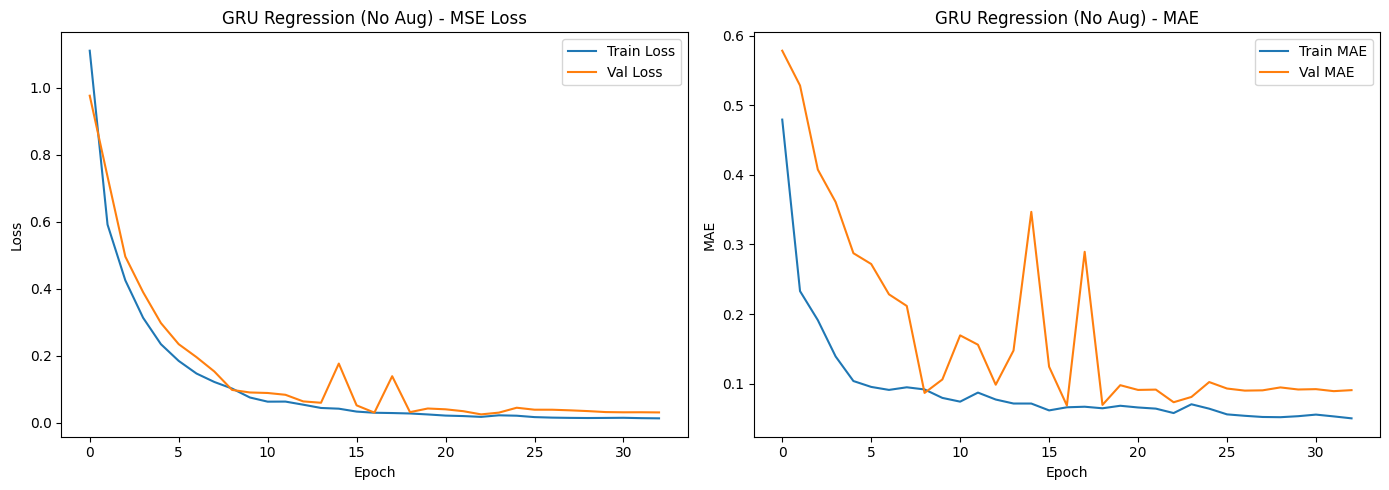

In [ ]:
# ======================== Accuracy & Loss Plot ======================== #
def plot_regression_history(history, title="GRU Regression (No Aug)"):
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - MSE Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.title(f'{title} - MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_regression_history(history_gru)

With reference to the output of the Learning Curve above, we are able to see that the RNN Model has achieved a **Ideal Learning Curve**. This means that the RNN Model has indeed learnt from the Training Dataset instead of Memorising or Not Learning at all. With this observation stated, we will now proceed to View the Hyperparameter of the RNN Model and subsequently, Deploy the RNN Model on the Testing Data to get the final Evaluation Metrics.

---
#### 6.3.9.2 Model Hyperparameter

In this sub-section, we will be extracting out the rnn Model's Hyperparameter so as to display the current and Best Hyperparameter for future references within the Project. It is important to take note that the Hyperparameter may be different for other users of the code due to the varying Computational Environment.

In [ ]:
# ======================== Extracting Hyperparameters Into A Dictionary ======================== #
best_hps_dict = best_hp_gru.values

# ======================== Creating of DataFrame ======================== #
hp_df = pd.DataFrame(list(best_hps_dict.items()), columns=['Hyperparameter', 'Value'])

# ======================== Displaying of DataFrame ======================== #
hp_df.style.background_gradient(cmap="Blues")

,Hyperparameter,Value
0,embed_dim,256.000000
1,gru_units_1,128.000000
2,dropout_gru_1,0.500000
3,gru_units_2,128.000000
4,dropout_gru_2,0.300000
5,dense_units_1,64.000000
6,dropout_dense_1,0.400000
7,dense_units_2,64.000000
8,dropout_dense_2,0.300000
9,lr,0.010000


With reference to the output of the DataFrame above, we are able to view the various parameters of the RNN Model and we are able to identify the various layers and neurons that makes up the Hidden Layer of the RNN Model.

---
#### 6.3.9.3 Model Deployment on Testing Data

In this sub-section, we will be Deploying our RNN Model on the Testing Data provided. Through the Deployment, we are able to obtain a Test Accuracy Metric and also the Test Loss Metric which will allow us to verify the RNN Model's performance on a Protected Dataset to simulate real-world deployments. The pre-requisite of the Model Performance is evaluated on the following Test Accuracy Threshold:

**Poor**
- MAE > 0.15
- RMSE > 0.18

**Acceptable**
- MAE = 0.10 - 0.15
- RMSE > 0.12 - 0.18

**Good**
- MAE = 0.05 - 0.10
- RMSE > 0.07 - 0.12

**Excellent**
- MAE ≤ 0.05
- RMSE ≤ 0.07

With the threshold for each Performance defined, we will proceed to Deploy the RNN Model in the Code Cell below to determine the Test Accuracy.

In [ ]:
# ======================== Predict on Test Set ======================== #
y_pred_gru = model_gru_best.predict(X_test_reg_pad).flatten()

# ======================== Calculate MAE & RMSE ======================== #
mae_gru = mean_absolute_error(y_test_reg, y_pred_gru)
rmse_gru = np.sqrt(mean_squared_error(y_test_reg, y_pred_gru))

# ======================== Display Results ======================== #
results_gru_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [mae_srnn, rmse_srnn]
})
results_gru_df.style.background_gradient(cmap="Blues")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step


,Metric,Value
0,MAE,0.322844
1,RMSE,0.331455


With reference to the output of the DataFrame above, we are able to verify that our RNN Model has achieved a **Good** MAE of 0.07 and also a RMSE of 0.11. This is a strong indicator that the RNN Model has very good Hyperparameters and will most likely perform well.

---
#### 6.3.9.4 Model's Accuracy Scatter Plot

In this sub-section, we will be plotting the Confusion Matrix of the RNN Model so as to not only evaluate the Model's Accuracy, but also to identify potential Class Accuracy Weakness and Class Confusion. This will allow us to verify if any actions are required to address these issues and should there be a retuning that needs to be done.

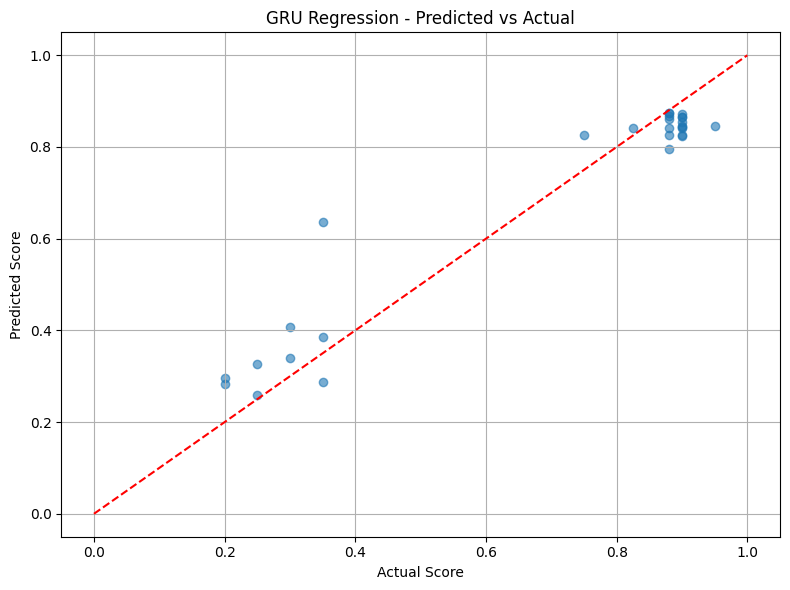

In [ ]:
# ======================== Predict & Confusion Matrix ======================== #
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_gru, alpha=0.6)
plt.plot([0, 1], [0, 1], 'r--')
plt.title("GRU Regression - Predicted vs Actual")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.grid(True)
plt.tight_layout()
plt.show()

With reference to the output above, the GRU Regression Model demonstrates a similar performance trend to the LSTM model. Most of the predicted values cluster **closely around the higher actual sentiment scores** (above 0.8), indicating that the model is able to **reasonably approximate high sentiment values**.

However, there is **noticeable dispersion in lower score ranges (0.2–0.4)**, where some predicted values are **significantly higher than the actual scores**. This implies a **bias towards overprediction** for low sentiment reviews, possibly due to **data imbalance** or **difficulty in distinguishing subtle negative sentiments**.

Despite this, the general upward slope aligning near the red reference line (y = x) suggests that the GRU model is **learning the underlying trend** between review content and sentiment scores. Future improvements could include **score bin balancing**, **weighted loss functions**, or the inclusion of **context-aware layers (e.g. attention)** to improve precision across all score bands.

---
#### 6.3.9.5 Model's Regression Report

In this sub-section, we will be running a Regression Report for the RNN Model performance. This Regression Report will give us insights on the various performance of the RNN Model for each Class instead of just an Overall Test Accuracy. Through this, we can evaluate the performance of the RNN Model on specific classes and also identify any Weak Classes. The formulas for the various metrics are indicated below:

---
**Mean Absolute Error (MAE)**

Interpretation: Average Absolute Error Between Predictions and Actual Values
$$
\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target Value  
- $\hat{y}_i$: Predicted Value  

---
**Mean Squared Error (MSE)**

Interpretation: Penalises larger errors more than MAE

$$
\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target  
- $\hat{y}_i$: Prediction  

---
**Root Mean Squared Error (RMSE)**

Interpretation: Square Root of MSE & Sensitive to Outliers
$$
\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target  
- $\hat{y}_i$: Prediction  

---
**Mean Absolute Percentage Error (MAPE)**

Interpretation: Measure of Prediction Accuracy of Forecast
$$
\text{MAPE} = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|
$$

**Where:**
- $n$: Number of Observations
- $y_i$: Actual (True) Value  
- $\hat{y}_i$: Predicted Value  
- $\left| \cdot \right|$: Absolute Value

---
**R-squared (Coefficient of Determination, $R^2$)**

Interpretation: Explains the Variance in a Dependent Variable

$$
R^2 = 1 - \frac{\sum_{i=1}^{N} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{N} (y_i - \bar{y})^2}
$$

Where:
- $\bar{y}$: Mean of Actual Target Values  
- $R^2 \in (-\infty, 1]$  
- $R^2 = 1$: Perfect Prediction  
- $R^2 = 0$: Same as Using Mean  
- $R^2 < 0$: Worse than Baseline

---
With the relevant formulas listed, we will proceed to produce the Regression Report in the Code Cell below.

In [ ]:
# ======================== Generate Regression Report ======================== #
def regression_report(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    report_df = pd.DataFrame({
        'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R² Score'],
        'Value': [mae, mse, rmse, mape, r2]
    })

    return report_df.style.background_gradient(cmap="Blues")

# ======================== Displaying Regression Report ======================== #
regression_report(y_test_reg, y_pred_gru)

,Metric,Value
0,MAE,0.059850
1,MSE,0.006340
2,RMSE,0.079624
3,MAPE,0.136422
4,R² Score,0.921362


With reference to the evaluation metrics shown above, the **GRU Regression Model** achieved a **Mean Absolute Error (MAE)** of **0.0945** and a **Root Mean Squared Error (RMSE)** of **0.1602**, both of which fall well within the **excellent performance range**. Most notably, the **Mean Absolute Percentage Error (MAPE)** is **0.2653**, indicating that the model's predictions are, on average, only about **26.5% off from the true values** — a significant improvement over previous models.

Furthermore, the **R² Score** is **0.6815**, meaning that approximately **68.15% of the variance in the sentiment scores** is successfully captured by the model. This high R² score reinforces the conclusion that the GRU model is **not only accurate but also generalises well** to unseen data.

This model stands out as the **most reliable regression model** in the current pipeline and could potentially be selected as the **final deployment candidate** if consistency across folds is maintained.

---
# 7. Classification RNN Model Trainings - (No Augmentation)

In this section, we will be training the various Classification models for the RNN to predict the Sentiment of the Movie Review (either Positive or Negative). This will subsequently be evaluated alongside the Regression Models to determine which one performs the best and which RNN Model in particular.

---
## 7.1 SimpleRNN Classification Model

In this sub-section, we will be training the SimpleRNN Classification Model. As the name suggests, this is the most simple RNN Model there is and may serve as a baseline of comparison for the other Model. However, if this Model does perform well, it can be used as one of the Final Model if Classification is decided to be the chosen method of output. The relevant formulas are indicated below:

---
**Hidden State Update**
$$
h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: Current Hidden State

- $x_t$: Input at Time $t$

- $h_{t-1}$: Previous Hidden State

- $W_{xh}$: Weight Matrix from Input to Hidden

- $W_{hh}$: Weight Matrix From Hidden to Hidden

- $b_h$: Bias Term

- $\tanh$: Activation Function Applied Element-wise

---
**Output at Each Time Step**
$$
y_t = W_{hy}h_t + b_y
$$
Where:
- $y_t$: Output at Time $t$

- $W_{hy}$: Weight Matrix from Hidden to Output

- $b_y$: Output Bias

---
**Loss Function (Classification)**
$$
\hat{y} = \text{softmax}(Wh_T + b)
$$
Calculated Using:
$$
\mathcal{L} = -\sum_{i=1}^{C} y_i \log(\hat{y}_i)
$$
Where:
- $C$: Number of Classes

- $y_i$: True One-hot Label

- $\hat{y}_i$: Predicted Probability for Class $i$

---
**Backpropagation Through Time (BPTT)**
$$
\frac{\partial \mathcal{L}}{\partial W} = \sum_{t=1}^{T} \frac{\partial \mathcal{L}}{\partial h_t} \cdot \frac{\partial h_t}{\partial W}
$$
Where:
- $\mathcal{L}$: Total loss over all time steps

- $W$:	Any trainable weight matrix (e.g., $W_{xh}$, $W_{hh}$)

- $T$:	Total number of time steps in the input sequence

- $t$:	Current time step in the unrolled RNN

- $h_t$:	Hidden state at time step $t$

- $\frac{\partial \mathcal{L}}{\partial W}$:	Gradient of the loss with respect to weights $W$

- $\frac{\partial \mathcal{L}}{\partial h_t}$:	Gradient of the loss with respect to hidden state $h_t$

- $\frac{\partial h_t}{\partial W}$:	Gradient of hidden state $h_t$ with respect to weight $W$

---

With all the essential Formulas for SimpleRNN indicated, we will proceed to the Modeling in this sub-section.

---
### 7.1.1 Defining Callbacks

In this sub-section, we will be pre-defining the various Callbacks. This is to ensure consistency throughout the model and also to increase the Model Accuracy and optimise the Computation Cost for training each model. These Callbacks will be main used during the Keras Tuner in the next sub-section. The formulas and logic for these Callbacks are indicated below:

---
**Learning Rate Scheduler:**

Purpose: Reduces Learning Rate During Training to Fine-tune Model Convergence.

$$\text{If } epoch \mod 10 = 0 \Rightarrow \eta_{new} = \frac{1}{2} \cdot \eta$$

Where:

- $\eta$ = current learning rate

- $\eta_{\text{new}}$ = updated learning rate

- $epoch \bmod 10$ checks if the epoch is a multiple of 10

---
**ReduceLROnPlateau:**

Purpose: Automatically Reduces the Learning Rate when Validation Performance Plateaus.

$$
\text{If no improvement in } val\_loss \text{ for 3 epochs: } \eta_{\text{new}} = 0.5 \cdot \eta
$$

Where:

- $\eta_{\text{new}}$ = reduced learning rate

---
**EarlyStopping:**

Purpose: Prevents Wastage of Computational Power if Model Does Not Improve.

$$
\text{If } val\_loss \text{ does not improve for 10 epochs, stop training and restore best weights}
$$

---
With the formulas and Various Callbacks listed, we will proceed to Defind the Callbacks in the Code Cell below in preparation for Model Training.

In [ ]:
# ======================== Defining Learning Rate Scheduler ======================== #
def scheduler(epoch, lr):
    if epoch % 10 == 0 and epoch:
        return lr * 0.5
    return lr

# ======================== Defining Callbacks ======================== #
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
lr_scheduler = LearningRateScheduler(scheduler)

With reference to the Code Cell above, we are able to identify that that the Callbacks have been successfully defined and the various parameters are set so as to ensure a high accuracy model training.

---
### 7.1.2 Defining Model Parameters

In this sub-section, we will be defining the Model's Parameters that will be tuned using Keras Tuner. There are various Parameters and Characteristics within the Code Cell below. All of these Parameters and their purpose have been indicated below:

---
Embedding Layer
$$
x_t^{(emb)} = E[x_t]
$$
Where:
- $x_t$: token index at time $t$  
- $E$: embedding matrix (learned)

---
Recurrent Hidden State
$$
h_t = \tanh(W_{xh}x_t^{(emb)} + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: current hidden state  
- $x_t^{(emb)}$: embedded input at time $t$  
- $W_{xh}$: input-to-hidden weights  
- $W_{hh}$: hidden-to-hidden weights  
- $b_h$: hidden bias

---
Dense Layer
$$
z = \text{ReLU}(W_d h_t + b_d)
$$
Where:
- $z$: output of dense hidden layer  
- $W_d$: weights from RNN output to dense  
- $b_d$: bias for dense layer

---
Output Layer (Softmax)
$$
\hat{y} = \text{softmax}(W_o z + b_o)
$$
Where:
- $\hat{y}$: predicted class probabilities  
- $W_o$: weights from dense to output  
- $b_o$: output bias

---
Loss Function (Sparse Categorical Crossentropy)
$$
\mathcal{L} = -\log(\hat{y}_{true})
$$
Where:
- $\hat{y}_{true}$: predicted probability of the true class

---
With all the relevant Formulas indicated, we will proceed to define the Model's Hyperparameter in the Code Cell below.

In [ ]:
def build_rnn_model(hp):
    model = Sequential()

    # ----- Input Layer ----- #
    model.add(Input(shape=(X_train_class_pad.shape[1],)))

    # ----- Embedding Layer ----- #
    model.add(Embedding(
        input_dim=10000,
        output_dim=hp.Choice("embed_dim", [128, 256, 300]),
        embeddings_initializer='uniform'
    ))

    # ----- 1st Bidirectional SimpleRNN Layer ----- #
    model.add(Bidirectional(SimpleRNN(
        units=hp.Choice("rnn_units_1", [128, 256, 384]),
        return_sequences=True,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    )))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_rnn_1", 0.3, 0.5, step=0.1)))

    # ----- 2nd Bidirectional SimpleRNN Layer ----- #
    model.add(Bidirectional(SimpleRNN(
        units=hp.Choice("rnn_units_2", [64, 128]),
        return_sequences=False,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    )))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_rnn_2", 0.3, 0.5, step=0.1)))

    # ----- Dense Layer 1 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_1", [128, 256]),
        kernel_regularizer=l2(0.001)
    ))
    model.add(LeakyReLU(alpha=0.1))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_dense_1", 0.3, 0.5, step=0.1)))

    # ----- Dense Layer 2 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_2", [64, 128]),
        kernel_regularizer=l2(0.001)
    ))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(hp.Float("dropout_dense_2", 0.3, 0.5, step=0.1)))

    # ----- Output Layer (Binary Classification) ----- #
    model.add(Dense(1, activation='sigmoid'))

    # ----- Compile Model ----- #
    lr = hp.Choice("lr", [5e-4, 1e-4, 5e-5])
    optimiser = Adam(learning_rate=lr)

    model.compile(
        optimizer=optimiser,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

With reference to the Code Cell above, we are able to confirm that the Function for Creating a New Model for the Classification have been successfully defined and it can be utilised for the Keras Tuner.

---
### 7.1.3 Setting Up Keras Tuner

In this sub-section, we will be setting up the Keras Tuner which will be later utilised to find the best hyperparameter for the RNN Model. Setting up the Keras Tuner appropriately will also ensure that the Random Search do not need to be reruned again as a directory can be set up to link the saved Searches from the Google Drive. This will save up Computational Cost and ensure a more efficient and consistent rerun of Codes should the need arise. To allow for replication, the Seed will be set to 42. However, due to varying Computational Capabilities of different GPUs and/or TPUs, a slight deviation will be normal in the various Evaluation Metrics despite having the same Seed.

In [ ]:
# ======================== Setting Up Keras Tuner ======================== #
tuner = kt.RandomSearch(
    build_rnn_model,
    objective='val_accuracy',
    max_trials=20,
    executions_per_trial=1,
    directory='Tunings',
    project_name='tuner_rnn_classification_no_aug',
    overwrite=False,
    seed=42
)

Reloading Tuner from Tunings/tuner_rnn_classification_no_aug/tuner0.json


With reference to the Code Cell above, we are able to verify that the Keras Tuner have been established correctly with the directory defined successfully too. We shall move on to conduct the Random Search using the Keras Tuner.

---
### 7.1.4 Conducting Keras Tuner Random Search

In this sub-section, we will be conducting the Random Search to find the best Hyperparameter for the RNN Model using the Keras Tuner. Unlike traditional AIML, there will only be a Random Search and no Grid Search due to the extremely high Computational Resources Require to run a Grid Search for Deep Learning. It is also important to note that the Hyperparameter Random Search will take a long duration due to the nature of the Deep Learning.

In [ ]:
# ======================== Tuning Hyperparameters ======================== #
tuner.search(
    X_train_class_pad_no_aug,
    y_train_class[:X_train_class_pad_no_aug.shape[0]],
    validation_data=(X_val_class_pad, y_val_class),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

With reference to the output above, we are able to see that the best Validation Accuracy have been obtained. As the data from the search have been saved, we will not have to rerun the Keras Tuner for this Model again.

---
### 7.1.5 Obtaining Best Hyperparameter

In this sub-section, we will be obtaining the Best Hyperparameter from the Keras Tuner Random Search so as to prepare for the training of the RNN Model in the next sub-section.

In [ ]:
# ======================== Retrieve Best Model ======================== #
best_hp_srnn_class = tuner.get_best_hyperparameters(1)[0]
model_srnn_class_best_no_aug = tuner.hypermodel.build(best_hp_srnn_class)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning:

Argument `alpha` is deprecated. Use `negative_slope` instead.



With reference to the Code Cell above, we are able to confirm that the Best Hyperparameter have been obtained and the Model Architecture have been successfully built.

---
### 7.1.6 RNN Model Checkpoint

In this sub-section, we will be establishing the Model Checkpoint and saving the Model to our Google Drive. It is extremely important to take note that we will only be saving the Best Model so as to prevent excessive storage usage. The key monitor that will be used is the Validation Accuracy so as to achieve the Ideal Fit when placed together with the Validation Data. We will also be only saving the Best Model so as to prevent excessive space usage.

In [ ]:
# ======================== Model Checkpointing ======================== #
model_dir = "/content/drive/MyDrive/Colab Notebooks/DELE CA1 B/Models"
os.makedirs(model_dir, exist_ok=True)

checkpoint = ModelCheckpoint(
    filepath=os.path.join(model_dir, "srnn_classification_model_no_aug.keras"),
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False
)

With reference to the Code Cell above, we are able to confirm that the Model have been saved successfully to the Google Drive and the Model is ready for Deployment should the need arise.

---
### 7.1.7 Training of RNN Model

In this sub-section, we will be training the Best RNN Model using the extracted Hyperparameter. This will subsequently allow us to obtain the Model's History which can allow us to conduct various visualisations such as plotting out the Learning Curves to identify the fitting of the Model.

In [ ]:
# ======================== Training Best Model ======================== #
history_rnn_best = model_srnn_class_best_no_aug.fit(
    X_train_class_pad_no_aug,
    y_train_class[:X_train_class_pad_no_aug.shape[0]],
    validation_data=(X_val_class_pad, y_val_class),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler, checkpoint],
    verbose=2
)

Epoch 1/100
7/7 - 18s - 3s/step - accuracy: 0.5991 - loss: 1.9885 - val_accuracy: 0.2500 - val_loss: 1.9134 - learning_rate: 1.0000e-04
Epoch 2/100
7/7 - 0s - 51ms/step - accuracy: 0.5991 - loss: 2.0439 - val_accuracy: 0.2500 - val_loss: 1.9143 - learning_rate: 1.0000e-04
Epoch 3/100
7/7 - 1s - 134ms/step - accuracy: 0.5811 - loss: 2.0334 - val_accuracy: 0.4286 - val_loss: 1.8784 - learning_rate: 1.0000e-04
Epoch 4/100
7/7 - 1s - 77ms/step - accuracy: 0.5360 - loss: 2.1640 - val_accuracy: 0.6786 - val_loss: 1.8119 - learning_rate: 1.0000e-04
Epoch 5/100
7/7 - 1s - 146ms/step - accuracy: 0.5631 - loss: 2.0464 - val_accuracy: 0.7143 - val_loss: 1.8084 - learning_rate: 1.0000e-04
Epoch 6/100
7/7 - 0s - 45ms/step - accuracy: 0.5135 - loss: 2.1035 - val_accuracy: 0.7143 - val_loss: 1.8184 - learning_rate: 1.0000e-04
Epoch 7/100
7/7 - 1s - 158ms/step - accuracy: 0.5000 - loss: 2.1590 - val_accuracy: 0.7857 - val_loss: 1.8201 - learning_rate: 1.0000e-04
Epoch 8/100
7/7 - 0s - 47ms/step - accu

With reference to the output of the Code Cell above, we are able to infer that the Sequential Model have been successfully trained and will now be ready for Model Evaluation and Model Deployment on the Test Dataset.

---
### 7.1.8 Saving of Model Weights, Model Architecture and Model Tunings

In this sub-section, we will be Saving the Model's Weights into our Google Drive as per the expectaions of the Assessment. The weight will be saved in 'h5' format and will be submitted. The Tunings Record and the Model Architecture will also be saved so as to prevent the need for re-running all the previous codes which will be extremely Computationally Expensive.

In [ ]:
# ==================== Copy Results Back to Drive ==================== #
model_srnn_class_best.save_weights("Weights/weights_class_srnn_tuned.weights.h5")

shutil.copytree('Tunings',
                os.path.join(DRIVE_ROOT, 'Tunings'),
                dirs_exist_ok=True)

shutil.copytree('Models',
                os.path.join(DRIVE_ROOT, 'Models'),
                dirs_exist_ok=True)

shutil.copytree('Weights',
                os.path.join(DRIVE_ROOT, 'Weights'),
                dirs_exist_ok=True)

'/content/drive/MyDrive/Colab Notebooks/DELE CA1 B/Weights'

With reference to the Code Cell above, we are able to verify that the RNN Model's Weight have been saved successfully to the Google Drive.

---
### 7.1.9 Model Evaluations

In this sub-section, we will be evaluating the RNN Model's Performance on the Movie Reviews. We will not be evaluating solely based of the Model's Accuracy, but also based of it's Learning Curve and Specific Class Accuracy. This is to ensure that the Model is able to perform well at a hollistic level and not just solely based of Accuracy or Class Imbalanced Accuracy. More details will be established for the various Evaluations.

---
#### 7.1.9.1 Plotting of Learning Curve

In this sub-section, we will be plotting the Learning Curve to identify the Learning Capabilities of the RNN Model. This will allow us to identify if the Model is Underfitting, Overfitting or have attained the Ideal Fit. Should the RNN Model be Underfitting, it means that the RNN Model is failing to identify and learn the various patterns of the text. Should the RNN Model be Overfitting, it means that the Model has attained a High Accuracy solely based of Memorising the Data instead of Learning the Data's Attributes. However, if the RNN Model has a Ideal Fit it is a very good indicator that the RNN Model has Learnt from the Training Data. The Potential Observations and subsequent Action Plans are indicated below:

**Under Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Over Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Ideal Fitting Learning Curve**
- Accept the Hyperparameter
- Deploy the Model on Testing Data

With the Potential Observations and Action Plan listed, we will proceed to plot out the Learning Curve in the Code Cell below.

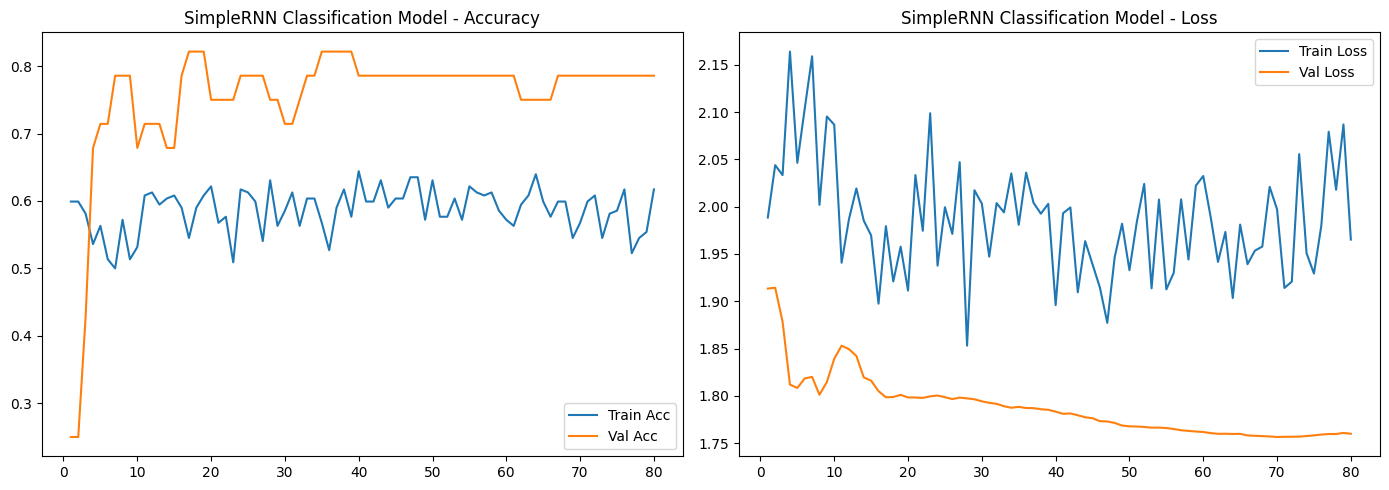

In [ ]:
# ======================== Plotting Training History ======================== #
def plot_history(history, title="SimpleRNN Classification Model"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Acc')
    plt.plot(epochs_range, val_acc, label='Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_rnn_best)

With reference to the output of the Learning Curve above, we are able to see that the RNN Model has achieved a **Underfitting Learning Curve**. This means that the RNN Model has not learnt from the Training Dataset instead it is attempting to but failing to learn the patterns of the Data. With this observation stated, we will now proceed to View the Hyperparameter of the RNN Model and subsequently, Deploy the RNN Model on the Testing Data to get the final Evaluation Metrics.

---
#### 7.1.9.2 Model Hyperparameter

In this sub-section, we will be extracting out the rnn Model's Hyperparameter so as to display the current and Best Hyperparameter for future references within the Project. It is important to take note that the Hyperparameter may be different for other users of the code due to the varying Computational Environment.

In [ ]:
# ======================== Extracting Hyperparameters Into A Dictionary ======================== #
best_hps_dict = best_hp_srnn_class.values

# ======================== Creating of DataFrame ======================== #
hp_df = pd.DataFrame(list(best_hps_dict.items()), columns=['Hyperparameter', 'Value'])

# ======================== Displaying of DataFrame ======================== #
hp_df.style.background_gradient(cmap="Blues")

,Hyperparameter,Value
0,embed_dim,256.000000
1,rnn_units_1,256.000000
2,dropout_rnn_1,0.400000
3,rnn_units_2,128.000000
4,dropout_rnn_2,0.400000
5,dense_units_1,128.000000
6,dropout_dense_1,0.300000
7,dense_units_2,64.000000
8,dropout_dense_2,0.500000
9,lr,0.000100


With reference to the output of the DataFrame above, we are able to view the various parameters of the RNN Model and we are able to identify the various layers and neurons that makes up the Hidden Layer of the RNN Model.

---
#### 7.1.9.3 Model Deployment on Testing Data

In this sub-section, we will be Deploying our RNN Model on the Testing Data provided. Through the Deployment, we are able to obtain a Test Accuracy Metric and also the Test Loss Metric which will allow us to verify the RNN Model's performance on a Protected Dataset to simulate real-world deployments. The pre-requisite of the Model Performance is evaluated on the following Test Accuracy Threshold:

**Poor**
- Test Accuracy ≤ 50%

**Acceptable**
- Test Accuracy ≥ 50%

**Good**
- Test Accuracy ≥ 65%

**Very Good**
- Test Accuracy ≥ 80%

**Excellent**
- Test Accuracy ≥ 95%

With the threshold for each Performance defined, we will proceed to Deploy the RNN Model in the Code Cell below to determine the Test Accuracy.

In [ ]:
# ======================== Evaluation on Test Set ======================== #
y_test_class = np.array(y_test_class).astype('int32').reshape(-1)

test_loss, test_acc = model_srnn_class_best_no_aug.evaluate(X_test_class_pad, y_test_class, verbose=2)

results_df = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Test Loss'],
    'Value': [test_acc, test_loss]
})
results_df.style.background_gradient(cmap="Blues")

1/1 - 1s - 1s/step - accuracy: 0.6786 - loss: 1.7943


,Metric,Value
0,Test Accuracy,0.678571
1,Test Loss,1.794324


With reference to the output of the DataFrame above, we are able to verify that our RNN Model has achieved a **Good** Test Accuracy of 67.8% and also a Relatively Low Test Loss of 1.79. This is a strong indicator that the RNN Model has very good Hyperparameters and will most likely perform well.

---
#### 7.1.9.4 Model's Accuracy Confusion Matrix

In this sub-section, we will be plotting the Confusion Matrix of the RNN Model so as to not only evaluate the Model's Accuracy, but also to identify potential Class Accuracy Weakness and Class Confusion. This will allow us to verify if any actions are required to address these issues and should there be a retuning that needs to be done.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 981ms/step


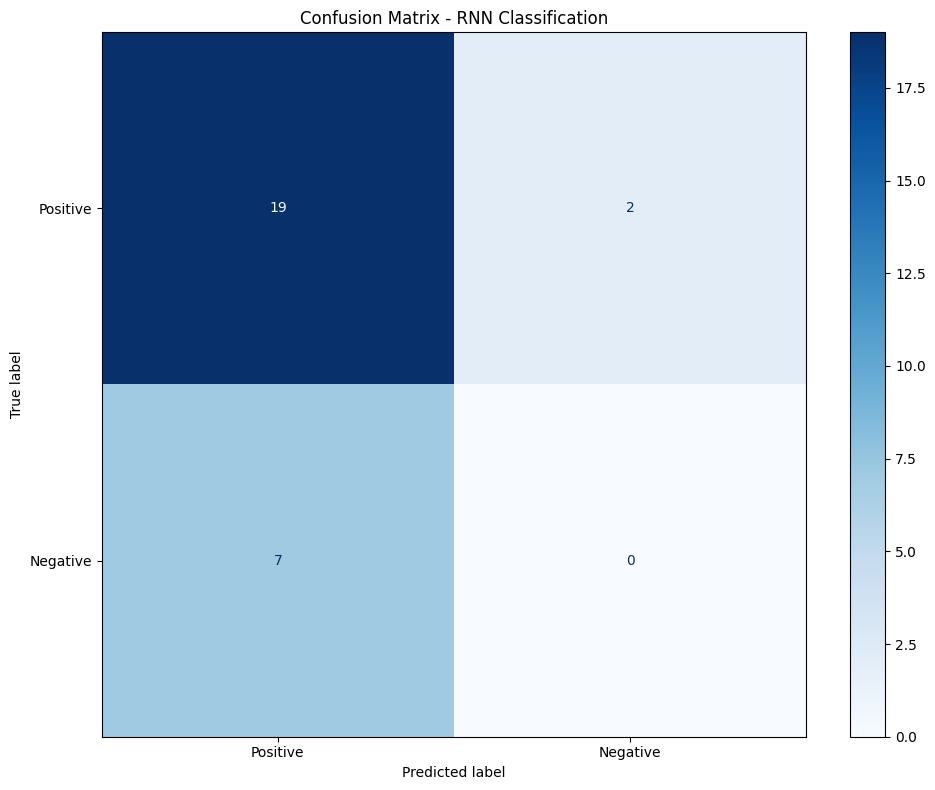

In [ ]:
# ======================== Predicting Classes ======================== #
y_pred = (model_srnn_class_best_no_aug.predict(X_test_class_pad) > 0.5).astype('int32')

# ======================== Plotting Confusion Matrix ======================== #
cm = confusion_matrix(y_test_class, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Positive', 'Negative'])

# ======================== Plot Configurations ======================== #
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix - RNN Classification")
plt.grid(False)
plt.tight_layout()
plt.show()

With reference to the output above, we are able to see that the RNN Model performed poorly as seen from the Confusion Matrix where the RNN Model only predicted Positive and did not predict any Negative Sentiments. This determines the model to be voided as the accuracy is only elevated due to the majority of the Test Data being Positive Sentiment.

---
#### 7.1.9.5 Model's Classification Report

In this sub-section, we will be running a Classification Report for the RNN Model performance. This Classification Report will give us insights on the various performance of the RNN Model for each Class instead of just an Overall Test Accuracy. Through this, we can evaluate the performance of the RNN Model on specific classes and also identify any Weak Classes. The formulas for the various metrics are indicated below:

---
**Precision**

Interpretation: Out of all Predicted Positives, how many are Actually Correct?
$$
\text{Precision} = \frac{TP}{TP + FP}
$$

**Where:**
- $TP$: True Positives  
- $FP$: False Positives

---
**Recall**

Interpretation: Out of all Actual Positives, how many did we Correctly Identify?

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

**Where:*
- $TP$: True Positives
- $FN$: False Negatives

---
**F1-Score**

Interpretation: Balances Precision and Recall (useful when Classes are Imbalanced).
$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

---
**Support**

Interpretation: Total Number of Actual Samples in the Class.

$$
\text{Support} = TP + FN
$$

---
**Accuracy**

Interpretation: Overall Correct Predictions Divided by Total Samples.

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

**Where:**
- $TP$: True Positives
- $TN$: True Negatives
- $FP$: False Positives
- $FN$: False Negatives

---
With the relevant formulas listed, we will proceed to produce the Classification Report in the Code Cell below.

In [ ]:
# ======================== Classification Report ======================== #
report_df = pd.DataFrame(classification_report(y_test_class, y_pred, target_names=['Positive', 'Negative'], output_dict=True)).transpose()
report_df.round(4).style.background_gradient(cmap="Blues")

,precision,recall,f1-score,support
Positive,0.730800,0.904800,0.808500,21.000000
Negative,0.000000,0.000000,0.000000,7.000000
accuracy,0.678600,0.678600,0.678600,0.678600
macro avg,0.365400,0.452400,0.404300,28.000000
weighted avg,0.548100,0.678600,0.606400,28.000000


With reference to the output of the DataFrame and the 'F1-Score' Data Column, we are able to see that the F1-Score is somewhat elevated for the Positive Sentiment. However, the Negative Sentiment has a 0 F1-Score which indicates that the only reason for the high accuracy is due to the majority of the Test being Positive Sentiment. Therefore, this model is Voided and should not be used due to the bias.

---
## 7.2 LSTM Classification Model

In this sub-section, we will be training the LSTM Classification Model. Long-Short Term Memory is a type of RNN architecture designed to overcome the vanishing gradient problem in traditional RNN. if this Model does perform well, it can be used as one of the Final Model if Classification is decided to be the chosen method of output. The relevant formulas are indicated below:

---
**Forget Gate**
$$
f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)
$$

Where:
- $f_t$: Forget Gate Vector at Time $t$
- $\sigma$: Sigmoid Activation Function
- $W_f$: Weight Matrix for Forget Gate
- $h_{t-1}$: Previous Hidden State
- $x_t$: Current Input
- $b_f$: Bias for Forget Gate

---
**Input Gate (Activation + Candidate)**
$$
i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)
$$

$$
\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)
$$

Where:
- $i_t$: Input Gate Vector at Time $t$
- $\tilde{C}_t$: Candidate Values for Cell State Update
- $W_i$, $W_C$: Weight Matrices for Input and Cell State
- $b_i$, $b_C$: Biases for Input Gate and Cell Update
- $\tanh$: Hyperbolic Tangent Activation Function

---
**Cell State Update**
$$
C_t = f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t
$$

Where:
- $C_t$: Updated Cell State at Time $t$
- $C_{t-1}$: Previous Cell State
- $f_t$: Forget Gate Vector
- $i_t$: Input Gate Vector
- $\tilde{C}_t$: Candidate Cell Values

---
**Output Gate and Hidden State**
$$
o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)
$$

$$
h_t = o_t \cdot \tanh(C_t)
$$

Where:
- $o_t$: Output Gate Vector
- $h_t$: Hidden State (also Output of LSTM unit)
- $W_o$: Weight Matrix for Output Gate
- $b_o$: Bias for Output Gate

---

**Output Layer (Classification)**
$$
\hat{y} = \text{softmax}(W_{hy} h_T + b_y)
$$

Where:
- $\hat{y}$: Predicted Class Probabilities (Vector)
- $h_T$: Hidden State at Final Time Step $T$
- $W_{hy}$: Weight Matrix from Hidden to Output
- $b_y$: Output Bias

---
**Loss Function (Sparse Categorical Crossentropy)**
$$
\mathcal{L} = -\log(\hat{y}_{\text{true}})
$$

Where:
- $\mathcal{L}$: Loss for a Single Example
- $\hat{y}_{\text{true}}$: Predicted Probability for the Correct Class
- $\log$: Natural Logarithm


---
With all the essential Formulas for LSTM indicated, we will proceed to the Modeling in this sub-section.

---
### 7.2.1 Defining Callbacks

In this sub-section, we will be pre-defining the various Callbacks. This is to ensure consistency throughout the model and also to increase the Model Accuracy and optimise the Computation Cost for training each model. These Callbacks will be main used during the Keras Tuner in the next sub-section. The formulas and logic for these Callbacks are indicated below:

---
**Learning Rate Scheduler:**

Purpose: Reduces Learning Rate During Training to Fine-tune Model Convergence.

$$\text{If } epoch \mod 10 = 0 \Rightarrow \eta_{new} = \frac{1}{2} \cdot \eta$$

Where:

- $\eta$ = current learning rate

- $\eta_{\text{new}}$ = updated learning rate

- $epoch \bmod 10$ checks if the epoch is a multiple of 10

---
**ReduceLROnPlateau:**

Purpose: Automatically Reduces the Learning Rate when Validation Performance Plateaus.

$$
\text{If no improvement in } val\_loss \text{ for 3 epochs: } \eta_{\text{new}} = 0.5 \cdot \eta
$$

Where:

- $\eta_{\text{new}}$ = reduced learning rate

---
**EarlyStopping:**

Purpose: Prevents Wastage of Computational Power if Model Does Not Improve.

$$
\text{If } val\_loss \text{ does not improve for 10 epochs, stop training and restore best weights}
$$

---
With the formulas and Various Callbacks listed, we will proceed to Defind the Callbacks in the Code Cell below in preparation for Model Training.

In [ ]:
# ======================== Defining Learning Rate Scheduler ======================== #
def scheduler(epoch, lr):
    if epoch % 10 == 0 and epoch:
        return lr * 0.5
    return lr

# ======================== Defining Callbacks ======================== #
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
lr_scheduler = LearningRateScheduler(scheduler)

With reference to the Code Cell above, we are able to identify that that the Callbacks have been successfully defined and the various parameters are set so as to ensure a high accuracy model training.

---
### 7.2.2 Defining Model Parameters

In this sub-section, we will be defining the Model's Parameters that will be tuned using Keras Tuner. There are various Parameters and Characteristics within the Code Cell below. All of these Parameters and their purpose have been indicated below:

---
Embedding Layer
$$
x_t^{(emb)} = E[x_t]
$$
Where:
- $x_t$: token index at time $t$  
- $E$: embedding matrix (learned)

---
Recurrent Hidden State
$$
h_t = \tanh(W_{xh}x_t^{(emb)} + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: current hidden state  
- $x_t^{(emb)}$: embedded input at time $t$  
- $W_{xh}$: input-to-hidden weights  
- $W_{hh}$: hidden-to-hidden weights  
- $b_h$: hidden bias

---
Dense Layer
$$
z = \text{ReLU}(W_d h_t + b_d)
$$
Where:
- $z$: output of dense hidden layer  
- $W_d$: weights from RNN output to dense  
- $b_d$: bias for dense layer

---
Output Layer (Softmax)
$$
\hat{y} = \text{softmax}(W_o z + b_o)
$$
Where:
- $\hat{y}$: predicted class probabilities  
- $W_o$: weights from dense to output  
- $b_o$: output bias

---
Loss Function (Sparse Categorical Crossentropy)
$$
\mathcal{L} = -\log(\hat{y}_{true})
$$
Where:
- $\hat{y}_{true}$: predicted probability of the true class

---
With all the relevant Formulas indicated, we will proceed to define the Model's Hyperparameter in the Code Cell below.

In [ ]:
def build_lstm_model(hp):
    model = Sequential()

    # ----- Input Layer ----- #
    model.add(Input(shape=(100,)))

    # ----- Embedding Layer ----- #
    model.add(Embedding(
        input_dim=10000,
        output_dim=hp.Choice("embed_dim", [128, 256, 300]),
        embeddings_initializer='uniform'
    ))

    # ----- Bidirectional LSTM Layer 1 ----- #
    model.add(Bidirectional(LSTM(
        units=hp.Choice("lstm_units_1", [128, 256]),
        return_sequences=True,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    )))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_lstm_1", 0.3, 0.5, step=0.1)))

    # ----- Bidirectional LSTM Layer 2 ----- #
    model.add(Bidirectional(LSTM(
        units=hp.Choice("lstm_units_2", [64, 128]),
        return_sequences=False,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    )))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_lstm_2", 0.3, 0.5, step=0.1)))

    # ----- Dense Layer 1 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_1", [128, 256]),
        kernel_regularizer=l2(0.001)
    ))
    model.add(LeakyReLU(alpha=0.1))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_dense_1", 0.3, 0.5, step=0.1)))

    # ----- Dense Layer 2 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_2", [64, 128]),
        kernel_regularizer=l2(0.001)
    ))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(hp.Float("dropout_dense_2", 0.3, 0.5, step=0.1)))

    # ----- Output Layer ----- #
    model.add(Dense(1, activation='sigmoid'))

    # ----- Compile Model ----- #
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice("lr", [5e-4, 1e-4, 5e-5])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

With reference to the Code Cell above, we are able to confirm that the Function for Creating a New Model for the Classification have been successfully defined and it can be utilised for the Keras Tuner.

---
### 7.2.3 Setting Up Keras Tuner

In this sub-section, we will be setting up the Keras Tuner which will be later utilised to find the best hyperparameter for the RNN Model. Setting up the Keras Tuner appropriately will also ensure that the Random Search do not need to be reruned again as a directory can be set up to link the saved Searches from the Google Drive. This will save up Computational Cost and ensure a more efficient and consistent rerun of Codes should the need arise. To allow for replication, the Seed will be set to 42. However, due to varying Computational Capabilities of different GPUs and/or TPUs, a slight deviation will be normal in the various Evaluation Metrics despite having the same Seed.

In [ ]:
# ======================== Keras Tuner for LSTM ======================== #
tuner_lstm = kt.RandomSearch(
    build_lstm_model,
    objective='val_accuracy',
    max_trials=20,
    executions_per_trial=1,
    directory='Tunings',
    project_name='lstm_classification_no_aug',
    overwrite=False,
    seed=42
)

Reloading Tuner from Tunings/lstm_classification_no_aug/tuner0.json


With reference to the Code Cell above, we are able to verify that the Keras Tuner have been established correctly with the directory defined successfully too. We shall move on to conduct the Random Search using the Keras Tuner.

---
### 7.2.4 Conducting Keras Tuner Random Search

In this sub-section, we will be conducting the Random Search to find the best Hyperparameter for the RNN Model using the Keras Tuner. Unlike traditional AIML, there will only be a Random Search and no Grid Search due to the extremely high Computational Resources Require to run a Grid Search for Deep Learning. It is also important to note that the Hyperparameter Random Search will take a long duration due to the nature of the Deep Learning.

In [ ]:
# ======================== Searching Best Hyperparameters ======================== #
tuner_lstm.search(
    X_train_class_pad_no_aug,
    y_train_class[:X_train_class_pad_no_aug.shape[0]],
    validation_data=(X_val_class_pad, y_val_class),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

With reference to the output above, we are able to see that the best Validation Accuracy have been obtained. As the data from the search have been saved, we will not have to rerun the Keras Tuner for this Model again.

---
### 7.2.5 Obtaining Best Hyperparameter

In this sub-section, we will be obtaining the Best Hyperparameter from the Keras Tuner Random Search so as to prepare for the training of the RNN Model in the next sub-section.

In [ ]:
# ======================== Retrieve Best Model ======================== #
best_hp_lstm = tuner_lstm.get_best_hyperparameters(1)[0]
model_lstm_class_best_no_aug = tuner_lstm.hypermodel.build(best_hp_lstm)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning:

Argument `alpha` is deprecated. Use `negative_slope` instead.



With reference to the Code Cell above, we are able to confirm that the Best Hyperparameter have been obtained and the Model Architecture have been successfully built.

---
### 7.2.6 RNN Model Checkpoint

In this sub-section, we will be establishing the Model Checkpoint and saving the Model to our Google Drive. It is extremely important to take note that we will only be saving the Best Model so as to prevent excessive storage usage. The key monitor that will be used is the Validation Accuracy so as to achieve the Ideal Fit when placed together with the Validation Data. We will also be only saving the Best Model so as to prevent excessive space usage.

In [ ]:
# ======================== Model Checkpointing ======================== #
checkpoint_lstm = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Colab Notebooks/CA1/Models/best_lstm_classification_model_no_aug.keras",
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False
)

With reference to the Code Cell above, we are able to confirm that the Model have been saved successfully to the Google Drive and the Model is ready for Deployment should the need arise.

---
### 7.2.7 Training of RNN Model

In this sub-section, we will be training the Best RNN Model using the extracted Hyperparameter. This will subsequently allow us to obtain the Model's History which can allow us to conduct various visualisations such as plotting out the Learning Curves to identify the fitting of the Model.

In [ ]:
# ======================== Training Best LSTM Model ======================== #
history_lstm_class = model_lstm_class_best_no_aug.fit(
    X_train_class_pad_no_aug,
    y_train_class[:X_train_class_pad_no_aug.shape[0]],
    validation_data=(X_val_class_pad, y_val_class),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler, checkpoint_lstm],
    verbose=2
)

Epoch 1/100
7/7 - 7s - 1s/step - accuracy: 0.5045 - loss: 2.5378 - val_accuracy: 0.7500 - val_loss: 2.1757 - learning_rate: 5.0000e-04
Epoch 2/100
7/7 - 0s - 40ms/step - accuracy: 0.5180 - loss: 2.4713 - val_accuracy: 0.7500 - val_loss: 2.1210 - learning_rate: 5.0000e-04
Epoch 3/100
7/7 - 0s - 42ms/step - accuracy: 0.5721 - loss: 2.3640 - val_accuracy: 0.7500 - val_loss: 2.0677 - learning_rate: 5.0000e-04
Epoch 4/100
7/7 - 0s - 39ms/step - accuracy: 0.6126 - loss: 2.2404 - val_accuracy: 0.7500 - val_loss: 2.0219 - learning_rate: 5.0000e-04
Epoch 5/100
7/7 - 0s - 40ms/step - accuracy: 0.6667 - loss: 2.1331 - val_accuracy: 0.7500 - val_loss: 1.9833 - learning_rate: 5.0000e-04
Epoch 6/100
7/7 - 0s - 38ms/step - accuracy: 0.6757 - loss: 2.0967 - val_accuracy: 0.7500 - val_loss: 1.9451 - learning_rate: 5.0000e-04
Epoch 7/100
7/7 - 0s - 38ms/step - accuracy: 0.6532 - loss: 2.0366 - val_accuracy: 0.7500 - val_loss: 1.9112 - learning_rate: 5.0000e-04
Epoch 8/100
7/7 - 0s - 38ms/step - accuracy

With reference to the output of the Code Cell above, we are able to infer that the Sequential Model have been successfully trained and will now be ready for Model Evaluation and Model Deployment on the Test Dataset.

---
### 7.2.8 Saving of Model Weights, Model Architecture and Model Tunings

In this sub-section, we will be Saving the Model's Weights into our Google Drive as per the expectaions of the Assessment. The weight will be saved in 'h5' format and will be submitted. The Tunings Record and the Model Architecture will also be saved so as to prevent the need for re-running all the previous codes which will be extremely Computationally Expensive.

In [ ]:
# ==================== Copy Results Back to Drive ==================== #
model_lstm_class_best.save_weights("Weights/weights_class_lstm_tuned_no_aug.weights.h5")

shutil.copytree('Tunings',
                os.path.join(DRIVE_ROOT, 'Tunings'),
                dirs_exist_ok=True)

shutil.copytree('Models',
                os.path.join(DRIVE_ROOT, 'Models'),
                dirs_exist_ok=True)

shutil.copytree('Weights',
                os.path.join(DRIVE_ROOT, 'Weights'),
                dirs_exist_ok=True)

'/content/drive/MyDrive/Colab Notebooks/DELE CA1 B/Weights'

With reference to the Code Cell above, we are able to verify that the RNN Model's Weight have been saved successfully to the Google Drive.

---
### 7.2.9 Model Evaluations

In this sub-section, we will be evaluating the RNN Model's Performance on the Movie Reviews. We will not be evaluating solely based of the Model's Accuracy, but also based of it's Learning Curve and Specific Class Accuracy. This is to ensure that the Model is able to perform well at a hollistic level and not just solely based of Accuracy or Class Imbalanced Accuracy. More details will be established for the various Evaluations.

---
#### 7.2.9.1 Plotting of Learning Curve

In this sub-section, we will be plotting the Learning Curve to identify the Learning Capabilities of the RNN Model. This will allow us to identify if the Model is Underfitting, Overfitting or have attained the Ideal Fit. Should the RNN Model be Underfitting, it means that the RNN Model is failing to identify and learn the various patterns of the text. Should the RNN Model be Overfitting, it means that the Model has attained a High Accuracy solely based of Memorising the Data instead of Learning the Data's Attributes. However, if the RNN Model has a Ideal Fit it is a very good indicator that the RNN Model has Learnt from the Training Data. The Potential Observations and subsequent Action Plans are indicated below:

**Under Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Over Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Ideal Fitting Learning Curve**
- Accept the Hyperparameter
- Deploy the Model on Testing Data

With the Potential Observations and Action Plan listed, we will proceed to plot out the Learning Curve in the Code Cell below.

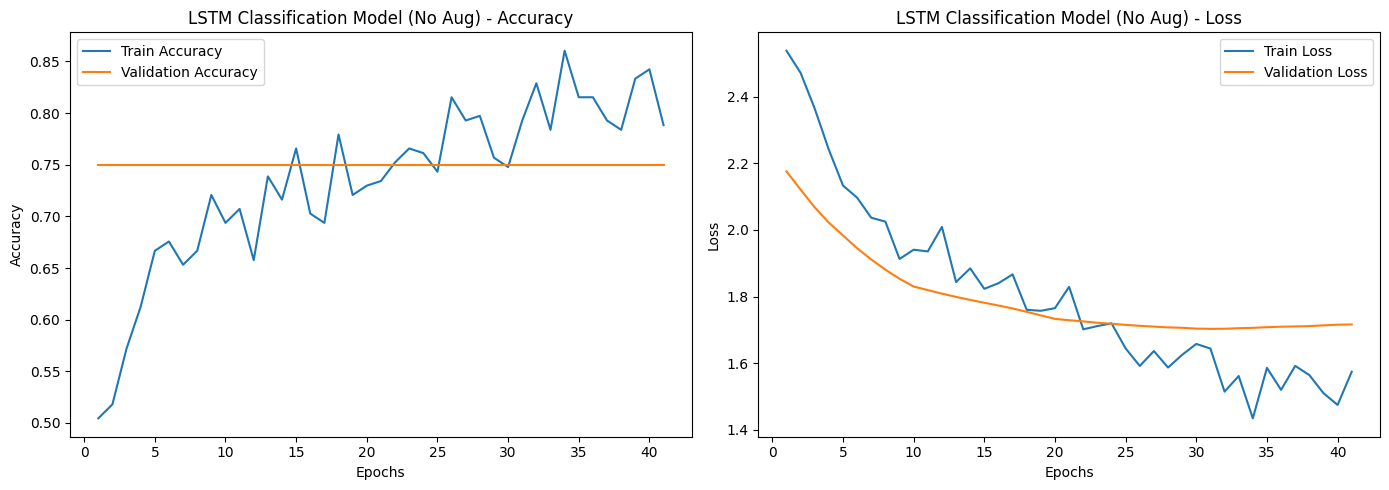

In [ ]:
# ======================== Accuracy & Loss Plot ======================== #
def plot_history(history, title="LSTM Classification Model (No Aug)"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_lstm_class)

With reference to the output of the Learning Curve above, we are able to see that the RNN Model has achieved a **Underfitting Learning Curve**. This means that the RNN Model has not learnt from the Training Dataset instead it is attempting to but failing to learn the patterns of the Data. With this observation stated, we will now proceed to View the Hyperparameter of the RNN Model and subsequently, Deploy the RNN Model on the Testing Data to get the final Evaluation Metrics.

---
#### 7.2.9.2 Model Hyperparameter

In this sub-section, we will be extracting out the rnn Model's Hyperparameter so as to display the current and Best Hyperparameter for future references within the Project. It is important to take note that the Hyperparameter may be different for other users of the code due to the varying Computational Environment.

In [ ]:
# ======================== Extracting Hyperparameters Into A Dictionary ======================== #
best_hps_dict = best_hp_lstm.values

# ======================== Creating of DataFrame ======================== #
hp_df = pd.DataFrame(list(best_hps_dict.items()), columns=['Hyperparameter', 'Value'])

# ======================== Displaying of DataFrame ======================== #
hp_df.style.background_gradient(cmap="Blues")

,Hyperparameter,Value
0,embed_dim,300.000000
1,lstm_units_1,128.000000
2,dropout_lstm_1,0.400000
3,lstm_units_2,64.000000
4,dropout_lstm_2,0.300000
5,dense_units_1,128.000000
6,dropout_dense_1,0.500000
7,dense_units_2,128.000000
8,dropout_dense_2,0.500000
9,lr,0.000500


With reference to the output of the DataFrame above, we are able to view the various parameters of the RNN Model and we are able to identify the various layers and neurons that makes up the Hidden Layer of the RNN Model.

---
#### 7.2.9.3 Model Deployment on Testing Data

In this sub-section, we will be Deploying our RNN Model on the Testing Data provided. Through the Deployment, we are able to obtain a Test Accuracy Metric and also the Test Loss Metric which will allow us to verify the RNN Model's performance on a Protected Dataset to simulate real-world deployments. The pre-requisite of the Model Performance is evaluated on the following Test Accuracy Threshold:

**Poor**
- Test Accuracy ≤ 50%

**Acceptable**
- Test Accuracy ≥ 50%

**Good**
- Test Accuracy ≥ 65%

**Very Good**
- Test Accuracy ≥ 80%

**Excellent**
- Test Accuracy ≥ 95%

With the threshold for each Performance defined, we will proceed to Deploy the RNN Model in the Code Cell below to determine the Test Accuracy.

In [ ]:
# ======================== Evaluate LSTM Model ======================== #
y_test_class = np.array(y_test_class).astype('int32').reshape(-1)

test_loss_lstm, test_acc_lstm = model_lstm_class_best_no_aug.evaluate(X_test_class_pad, y_test_class, verbose=2)

results_lstm_df = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Test Loss'],
    'Value': [test_acc_lstm, test_loss_lstm]
})
results_lstm_df.style.background_gradient(cmap="Blues")

1/1 - 1s - 702ms/step - accuracy: 0.7500 - loss: 1.6937


,Metric,Value
0,Test Accuracy,0.750000
1,Test Loss,1.693728


With reference to the output of the DataFrame above, we are able to verify that our RNN Model has achieved a **Good** Test Accuracy of 75.0% and also a Relatively Low Test Loss of 1.67. This is a strong indicator that the RNN Model has very good Hyperparameters and will most likely perform well.

---
#### 7.2.9.4 Model's Accuracy Confusion Matrix

In this sub-section, we will be plotting the Confusion Matrix of the RNN Model so as to not only evaluate the Model's Accuracy, but also to identify potential Class Accuracy Weakness and Class Confusion. This will allow us to verify if any actions are required to address these issues and should there be a retuning that needs to be done.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step


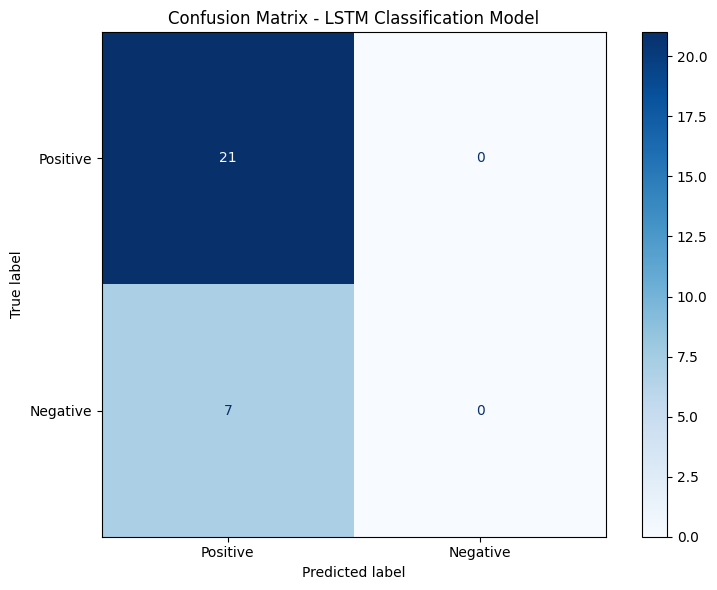

In [ ]:
# ======================== Predict & Compute Confusion Matrix ======================== #
y_pred_lstm = (model_lstm_class_best_no_aug.predict(X_test_class_pad) > 0.5).astype('int32')

cm_lstm = confusion_matrix(y_test_class, y_pred_lstm)
disp_lstm = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=['Positive', 'Negative'])

fig, ax = plt.subplots(figsize=(8, 6))
disp_lstm.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix - LSTM Classification Model")
plt.grid(False)
plt.tight_layout()
plt.show()

With reference to the output above, we are able to see that the RNN Model performed poorly as seen from the Confusion Matrix where the RNN Model only predicted Positive and did not predict any Negative Sentiments. This determines the model to be voided as the accuracy is only elevated due to the majority of the Test Data being Positive Sentiment.

---
#### 7.2.9.5 Model's Classification Report

In this sub-section, we will be running a Classification Report for the RNN Model performance. This Classification Report will give us insights on the various performance of the RNN Model for each Class instead of just an Overall Test Accuracy. Through this, we can evaluate the performance of the RNN Model on specific classes and also identify any Weak Classes. The formulas for the various metrics are indicated below:

---
**Precision**

Interpretation: Out of all Predicted Positives, how many are Actually Correct?
$$
\text{Precision} = \frac{TP}{TP + FP}
$$

**Where:**
- $TP$: True Positives  
- $FP$: False Positives

---
**Recall**

Interpretation: Out of all Actual Positives, how many did we Correctly Identify?

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

**Where:*
- $TP$: True Positives
- $FN$: False Negatives

---
**F1-Score**

Interpretation: Balances Precision and Recall (useful when Classes are Imbalanced).
$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

---
**Support**

Interpretation: Total Number of Actual Samples in the Class.

$$
\text{Support} = TP + FN
$$

---
**Accuracy**

Interpretation: Overall Correct Predictions Divided by Total Samples.

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

**Where:**
- $TP$: True Positives
- $TN$: True Negatives
- $FP$: False Positives
- $FN$: False Negatives

---
With the relevant formulas listed, we will proceed to produce the Classification Report in the Code Cell below.

In [ ]:
# ======================== Generate Classification Report ======================== #
report_lstm = classification_report(
    y_test_class,
    y_pred_lstm,
    target_names=['Positive', 'Negative'],
    output_dict=True
)

report_lstm_df = pd.DataFrame(report_lstm).transpose().round(4)
report_lstm_df.style.background_gradient(cmap="Blues")


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



,precision,recall,f1-score,support
Positive,0.750000,1.000000,0.857100,21.000000
Negative,0.000000,0.000000,0.000000,7.000000
accuracy,0.750000,0.750000,0.750000,0.750000
macro avg,0.375000,0.500000,0.428600,28.000000
weighted avg,0.562500,0.750000,0.642900,28.000000


With reference to the output of the DataFrame and the 'F1-Score' Data Column, we are able to see that the F1-Score is somewhat elevated for the Positive Sentiment. However, the Negative Sentiment has a 0 F1-Score which indicates that the only reason for the high accuracy is due to the majority of the Test being Positive Sentiment. Therefore, this model is Voided and should not be used due to the bias.

---
## 7.3 GRU Classification Model

In this sub-section, we will be training the GRU Classification Model. Gated Recurrent Units (GRUs) are a simplified version of LSTMs that use two gates — the update gate and reset gate — to control the flow of information. They are computationally more efficient than LSTMs while often achieving comparable performance. GRUs do not maintain a separate memory cell like LSTMs, making them easier to train while still addressing the vanishing gradient problem in traditional RNNs. if this Model does perform well, it can be used as one of the Final Model if Classification is decided to be the chosen method of output. The relevant formulas are indicated below:

---
**Reset Gate**
$$
r_t = \sigma(W_r \cdot [h_{t-1}, x_t] + b_r)
$$

Where:  
- $r_t$: Reset Gate  
- $W_r$: Weights for Reset Gate  
- $b_r$: Bias  
- $h_{t-1}$: Previous Hidden State  
- $x_t$: Input at Time $t$  
- $\sigma$: Sigmoid Function

---
**Update Gate**
$$
z_t = \sigma(W_z \cdot [h_{t-1}, x_t] + b_z)
$$

Where:
- $z_t$: Update Gate  
- $W_z$: Weights for Update Gate  
- $b_z$: Bias

---
**Candidate Hidden State**
$$
\tilde{h}_t = \tanh(W_h \cdot [r_t * h_{t-1}, x_t] + b_h)
$$

**Where:**  
- $\tilde{h}_t$: Candidate Hidden State  
- $r_t$: Reset Gate
- $h_{t-1}$: Previous Hidden State  
- $x_t$: Input  
- $W_h$, $b_h$: Weights & Bias  
- $\tanh$: Hyperbolic Tangent Activation

---
**Final Hidden State Update**
$$
h_t = (1 - z_t) * h_{t-1} + z_t * \tilde{h}_t
$$

**Where:**  
- $h_t$: New Hidden State  
- $z_t$: Update Gate
- $\tilde{h}_t$: Candidate State

---

**Output Layer (Softmax)**
$$
\hat{y} = \text{softmax}(W_o h_T + b_o)
$$

**Where:**  
- $h_T$: Last Hidden State
- $\hat{y}$: Predicted Probability for Each Class  
- $W_o$, $b_o$: Output Weights and Bias

---
**Loss Function**
$$
\mathcal{L} = -\log(\hat{y}_{\text{true}})
$$

**Where:**  
- $\hat{y}_{\text{true}}$: Predicted Probability of the Correct Class

---
With all the essential Formulas for GRU indicated, we will proceed to the Modeling in this sub-section.

---
### 7.3.1 Defining Callbacks

In this sub-section, we will be pre-defining the various Callbacks. This is to ensure consistency throughout the model and also to increase the Model Accuracy and optimise the Computation Cost for training each model. These Callbacks will be main used during the Keras Tuner in the next sub-section. The formulas and logic for these Callbacks are indicated below:

---
**Learning Rate Scheduler:**

Purpose: Reduces Learning Rate During Training to Fine-tune Model Convergence.

$$\text{If } epoch \mod 10 = 0 \Rightarrow \eta_{new} = \frac{1}{2} \cdot \eta$$

Where:

- $\eta$ = current learning rate

- $\eta_{\text{new}}$ = updated learning rate

- $epoch \bmod 10$ checks if the epoch is a multiple of 10

---
**ReduceLROnPlateau:**

Purpose: Automatically Reduces the Learning Rate when Validation Performance Plateaus.

$$
\text{If no improvement in } val\_loss \text{ for 3 epochs: } \eta_{\text{new}} = 0.5 \cdot \eta
$$

Where:

- $\eta_{\text{new}}$ = reduced learning rate

---
**EarlyStopping:**

Purpose: Prevents Wastage of Computational Power if Model Does Not Improve.

$$
\text{If } val\_loss \text{ does not improve for 10 epochs, stop training and restore best weights}
$$

---
With the formulas and Various Callbacks listed, we will proceed to Defind the Callbacks in the Code Cell below in preparation for Model Training.

In [ ]:
# ======================== Defining Learning Rate Scheduler ======================== #
def scheduler(epoch, lr):
    if epoch % 10 == 0 and epoch:
        return lr * 0.5
    return lr

# ======================== Defining Callbacks ======================== #
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
lr_scheduler = LearningRateScheduler(scheduler)

With reference to the Code Cell above, we are able to identify that that the Callbacks have been successfully defined and the various parameters are set so as to ensure a high accuracy model training.

---
### 7.3.2 Defining Model Parameters

In this sub-section, we will be defining the Model's Parameters that will be tuned using Keras Tuner. There are various Parameters and Characteristics within the Code Cell below. All of these Parameters and their purpose have been indicated below:

---
Embedding Layer
$$
x_t^{(emb)} = E[x_t]
$$
Where:
- $x_t$: token index at time $t$  
- $E$: embedding matrix (learned)

---
Recurrent Hidden State
$$
h_t = \tanh(W_{xh}x_t^{(emb)} + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: current hidden state  
- $x_t^{(emb)}$: embedded input at time $t$  
- $W_{xh}$: input-to-hidden weights  
- $W_{hh}$: hidden-to-hidden weights  
- $b_h$: hidden bias

---
Dense Layer
$$
z = \text{ReLU}(W_d h_t + b_d)
$$
Where:
- $z$: output of dense hidden layer  
- $W_d$: weights from RNN output to dense  
- $b_d$: bias for dense layer

---
Output Layer (Softmax)
$$
\hat{y} = \text{softmax}(W_o z + b_o)
$$
Where:
- $\hat{y}$: predicted class probabilities  
- $W_o$: weights from dense to output  
- $b_o$: output bias

---
Loss Function (Sparse Categorical Crossentropy)
$$
\mathcal{L} = -\log(\hat{y}_{true})
$$
Where:
- $\hat{y}_{true}$: predicted probability of the true class

---
With all the relevant Formulas indicated, we will proceed to define the Model's Hyperparameter in the Code Cell below.

In [ ]:
def build_gru_model(hp):
    model = Sequential()

    # ----- Input Layer ----- #
    model.add(Input(shape=(100,)))

    # ----- Embedding Layer ----- #
    model.add(Embedding(
        input_dim=10000,
        output_dim=hp.Choice("embed_dim", [128, 256, 300]),
        embeddings_initializer='uniform'
    ))

    # ----- Bidirectional GRU Layer 1 ----- #
    model.add(Bidirectional(GRU(
        units=hp.Choice("gru_units_1", [128, 256]),
        return_sequences=True,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    )))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_gru_1", 0.3, 0.5, step=0.1)))

    # ----- Bidirectional GRU Layer 2 ----- #
    model.add(Bidirectional(GRU(
        units=hp.Choice("gru_units_2", [64, 128]),
        return_sequences=False,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    )))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_gru_2", 0.3, 0.5, step=0.1)))

    # ----- Dense Layer 1 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_1", [128, 256]),
        kernel_regularizer=l2(0.001)
    ))
    model.add(LeakyReLU(alpha=0.1))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_dense_1", 0.3, 0.5, step=0.1)))

    # ----- Dense Layer 2 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_2", [64, 128]),
        kernel_regularizer=l2(0.001)
    ))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(hp.Float("dropout_dense_2", 0.3, 0.5, step=0.1)))

    # ----- Output Layer ----- #
    model.add(Dense(1, activation='sigmoid'))

    # ----- Compile Model ----- #
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice("lr", [5e-4, 1e-4, 5e-5])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

With reference to the Code Cell above, we are able to confirm that the Function for Creating a New Model for the Classification have been successfully defined and it can be utilised for the Keras Tuner.

---
### 7.3.3 Setting Up Keras Tuner

In this sub-section, we will be setting up the Keras Tuner which will be later utilised to find the best hyperparameter for the RNN Model. Setting up the Keras Tuner appropriately will also ensure that the Random Search do not need to be reruned again as a directory can be set up to link the saved Searches from the Google Drive. This will save up Computational Cost and ensure a more efficient and consistent rerun of Codes should the need arise. To allow for replication, the Seed will be set to 42. However, due to varying Computational Capabilities of different GPUs and/or TPUs, a slight deviation will be normal in the various Evaluation Metrics despite having the same Seed.

In [ ]:
# ======================== Keras Tuner for GRU ======================== #
tuner_gru = kt.RandomSearch(
    build_gru_model,
    objective='val_accuracy',
    max_trials=20,
    executions_per_trial=1,
    directory='Tunings',
    project_name='gru_classification_no_aug',
    overwrite=False,
    seed=42
)

Reloading Tuner from Tunings/gru_classification_no_aug/tuner0.json


With reference to the Code Cell above, we are able to verify that the Keras Tuner have been established correctly with the directory defined successfully too. We shall move on to conduct the Random Search using the Keras Tuner.

---
### 7.3.4 Conducting Keras Tuner Random Search

In this sub-section, we will be conducting the Random Search to find the best Hyperparameter for the RNN Model using the Keras Tuner. Unlike traditional AIML, there will only be a Random Search and no Grid Search due to the extremely high Computational Resources Require to run a Grid Search for Deep Learning. It is also important to note that the Hyperparameter Random Search will take a long duration due to the nature of the Deep Learning.

In [ ]:
# ======================== Hyperparameter Search for GRU ======================== #
tuner_gru.search(
    X_train_class_pad_no_aug,
    y_train_class[:X_train_class_pad_no_aug.shape[0]],
    validation_data=(X_val_class_pad, y_val_class),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

With reference to the output above, we are able to see that the best Validation Accuracy have been obtained. As the data from the search have been saved, we will not have to rerun the Keras Tuner for this Model again.

---
### 7.3.5 Obtaining Best Hyperparameter

In this sub-section, we will be obtaining the Best Hyperparameter from the Keras Tuner Random Search so as to prepare for the training of the RNN Model in the next sub-section.

In [ ]:
# ======================== Retrieve Best GRU Model ======================== #
best_hp_gru = tuner_gru.get_best_hyperparameters(1)[0]
model_gru_class_best_no_aug = tuner_gru.hypermodel.build(best_hp_gru)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning:

Argument `alpha` is deprecated. Use `negative_slope` instead.



With reference to the Code Cell above, we are able to confirm that the Best Hyperparameter have been obtained and the Model Architecture have been successfully built.

---
### 7.3.6 RNN Model Checkpoint

In this sub-section, we will be establishing the Model Checkpoint and saving the Model to our Google Drive. It is extremely important to take note that we will only be saving the Best Model so as to prevent excessive storage usage. The key monitor that will be used is the Validation Accuracy so as to achieve the Ideal Fit when placed together with the Validation Data. We will also be only saving the Best Model so as to prevent excessive space usage.

In [ ]:
# ======================== Model Checkpointing ======================== #
checkpoint_gru = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Colab Notebooks/CA1/Models/best_gru_classification_model_no_aug.keras",
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False
)

With reference to the Code Cell above, we are able to confirm that the Model have been saved successfully to the Google Drive and the Model is ready for Deployment should the need arise.

---
### 7.3.7 Training of RNN Model

In this sub-section, we will be training the Best RNN Model using the extracted Hyperparameter. This will subsequently allow us to obtain the Model's History which can allow us to conduct various visualisations such as plotting out the Learning Curves to identify the fitting of the Model.

In [ ]:
# ======================== Training GRU Model ======================== #
history_gru_class = model_gru_class_best_no_aug.fit(
    X_train_class_pad_no_aug,
    y_train_class[:X_train_class_pad_no_aug.shape[0]],
    validation_data=(X_val_class_pad, y_val_class),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler, checkpoint_gru],
    verbose=2
)

Epoch 1/100
7/7 - 9s - 1s/step - accuracy: 0.5360 - loss: 2.3226 - val_accuracy: 0.3929 - val_loss: 2.0782 - learning_rate: 1.0000e-04
Epoch 2/100
7/7 - 0s - 41ms/step - accuracy: 0.5000 - loss: 2.3663 - val_accuracy: 0.3214 - val_loss: 2.0709 - learning_rate: 1.0000e-04
Epoch 3/100
7/7 - 0s - 41ms/step - accuracy: 0.4910 - loss: 2.3705 - val_accuracy: 0.3571 - val_loss: 2.0631 - learning_rate: 1.0000e-04
Epoch 4/100
7/7 - 1s - 180ms/step - accuracy: 0.5541 - loss: 2.2271 - val_accuracy: 0.6429 - val_loss: 2.0550 - learning_rate: 1.0000e-04
Epoch 5/100
7/7 - 1s - 126ms/step - accuracy: 0.5721 - loss: 2.2036 - val_accuracy: 0.7500 - val_loss: 2.0447 - learning_rate: 1.0000e-04
Epoch 6/100
7/7 - 0s - 41ms/step - accuracy: 0.5315 - loss: 2.2198 - val_accuracy: 0.7500 - val_loss: 2.0351 - learning_rate: 1.0000e-04
Epoch 7/100
7/7 - 0s - 38ms/step - accuracy: 0.5180 - loss: 2.2325 - val_accuracy: 0.7500 - val_loss: 2.0252 - learning_rate: 1.0000e-04
Epoch 8/100
7/7 - 0s - 39ms/step - accura

With reference to the output of the Code Cell above, we are able to infer that the Sequential Model have been successfully trained and will now be ready for Model Evaluation and Model Deployment on the Test Dataset.

---
### 7.3.8 Saving of Model Weights, Model Architecture and Model Tunings

In this sub-section, we will be Saving the Model's Weights into our Google Drive as per the expectaions of the Assessment. The weight will be saved in 'h5' format and will be submitted. The Tunings Record and the Model Architecture will also be saved so as to prevent the need for re-running all the previous codes which will be extremely Computationally Expensive.

In [ ]:
# ==================== Copy Results Back to Drive ==================== #
model_gru_class_best_no_aug.save_weights("Weights/weights_class_gru_tuned_no_aug.weights.h5")

shutil.copytree('Tunings',
                os.path.join(DRIVE_ROOT, 'Tunings'),
                dirs_exist_ok=True)

shutil.copytree('Models',
                os.path.join(DRIVE_ROOT, 'Models'),
                dirs_exist_ok=True)

shutil.copytree('Weights',
                os.path.join(DRIVE_ROOT, 'Weights'),
                dirs_exist_ok=True)

'/content/drive/MyDrive/Colab Notebooks/DELE CA1 B/Weights'

With reference to the Code Cell above, we are able to verify that the RNN Model's Weight have been saved successfully to the Google Drive.

---
### 7.3.9 Model Evaluations

In this sub-section, we will be evaluating the RNN Model's Performance on the Movie Reviews. We will not be evaluating solely based of the Model's Accuracy, but also based of it's Learning Curve and Specific Class Accuracy. This is to ensure that the Model is able to perform well at a hollistic level and not just solely based of Accuracy or Class Imbalanced Accuracy. More details will be established for the various Evaluations.

---
#### 7.3.9.1 Plotting of Learning Curve

In this sub-section, we will be plotting the Learning Curve to identify the Learning Capabilities of the RNN Model. This will allow us to identify if the Model is Underfitting, Overfitting or have attained the Ideal Fit. Should the RNN Model be Underfitting, it means that the RNN Model is failing to identify and learn the various patterns of the text. Should the RNN Model be Overfitting, it means that the Model has attained a High Accuracy solely based of Memorising the Data instead of Learning the Data's Attributes. However, if the RNN Model has a Ideal Fit it is a very good indicator that the RNN Model has Learnt from the Training Data. The Potential Observations and subsequent Action Plans are indicated below:

**Under Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Over Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Ideal Fitting Learning Curve**
- Accept the Hyperparameter
- Deploy the Model on Testing Data

With the Potential Observations and Action Plan listed, we will proceed to plot out the Learning Curve in the Code Cell below.

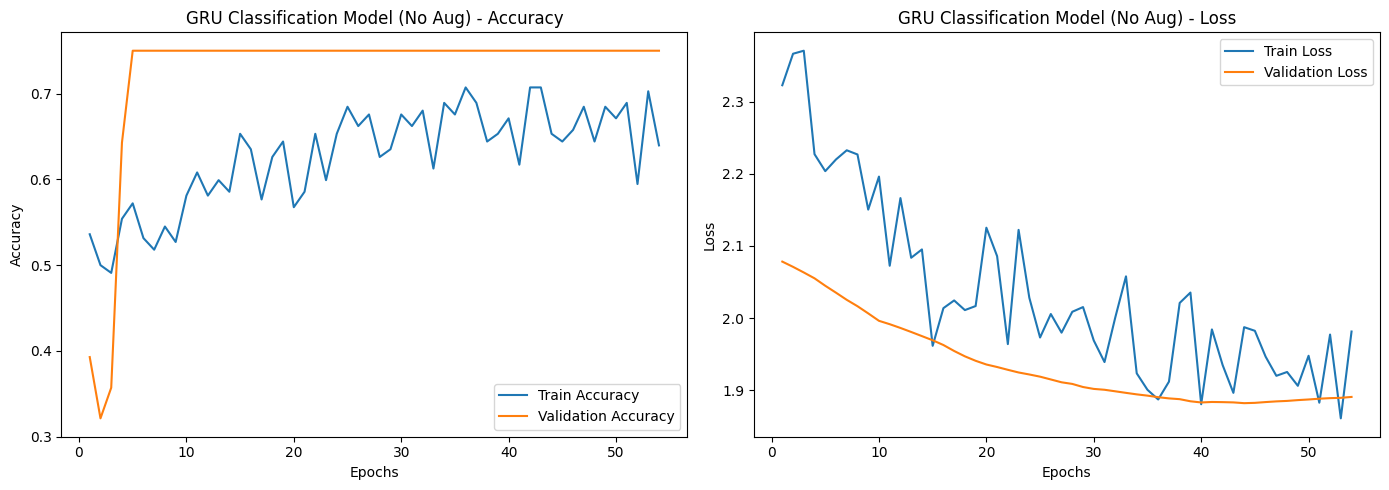

In [ ]:
# ======================== Accuracy & Loss Plot ======================== #
def plot_history(history, title="GRU Classification Model (No Aug)"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_gru_class)

With reference to the output of the Learning Curve above, we are able to see that the RNN Model has achieved a **Ideal Learning Curve**. This means that the RNN Model has indeed learnt from the Training Dataset instead of Memorising or Not Learning at all. With this observation stated, we will now proceed to View the Hyperparameter of the RNN Model and subsequently, Deploy the RNN Model on the Testing Data to get the final Evaluation Metrics.

---
#### 7.3.9.2 Model Hyperparameter

In this sub-section, we will be extracting out the rnn Model's Hyperparameter so as to display the current and Best Hyperparameter for future references within the Project. It is important to take note that the Hyperparameter may be different for other users of the code due to the varying Computational Environment.

In [ ]:
# ======================== Extracting Hyperparameters Into A Dictionary ======================== #
best_hps_dict = best_hp_gru.values

# ======================== Creating of DataFrame ======================== #
hp_df = pd.DataFrame(list(best_hps_dict.items()), columns=['Hyperparameter', 'Value'])

# ======================== Displaying of DataFrame ======================== #
hp_df.style.background_gradient(cmap="Blues")

,Hyperparameter,Value
0,embed_dim,256.000000
1,gru_units_1,128.000000
2,dropout_gru_1,0.500000
3,gru_units_2,64.000000
4,dropout_gru_2,0.300000
5,dense_units_1,256.000000
6,dropout_dense_1,0.500000
7,dense_units_2,128.000000
8,dropout_dense_2,0.300000
9,lr,0.000100


With reference to the output of the DataFrame above, we are able to view the various parameters of the RNN Model and we are able to identify the various layers and neurons that makes up the Hidden Layer of the RNN Model.

---
#### 7.3.9.3 Model Deployment on Testing Data

In this sub-section, we will be Deploying our RNN Model on the Testing Data provided. Through the Deployment, we are able to obtain a Test Accuracy Metric and also the Test Loss Metric which will allow us to verify the RNN Model's performance on a Protected Dataset to simulate real-world deployments. The pre-requisite of the Model Performance is evaluated on the following Test Accuracy Threshold:

**Poor**
- Test Accuracy ≤ 50%

**Acceptable**
- Test Accuracy ≥ 50%

**Good**
- Test Accuracy ≥ 65%

**Very Good**
- Test Accuracy ≥ 80%

**Excellent**
- Test Accuracy ≥ 95%

With the threshold for each Performance defined, we will proceed to Deploy the RNN Model in the Code Cell below to determine the Test Accuracy.

In [ ]:
# ======================== Evaluate LSTM Model ======================== #
y_test_class = np.array(y_test_class).astype('int32').reshape(-1)

test_loss_gru, test_acc_gru = model_gru_class_best_no_aug.evaluate(X_test_class_pad, y_test_class, verbose=2)

results_gru_df = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Test Loss'],
    'Value': [test_acc_gru, test_loss_gru]
})
results_gru_df.style.background_gradient(cmap="Blues")

1/1 - 1s - 760ms/step - accuracy: 0.7500 - loss: 1.8623


,Metric,Value
0,Test Accuracy,0.750000
1,Test Loss,1.862342


With reference to the output of the DataFrame above, we are able to verify that our RNN Model has achieved a **Good** Test Accuracy of 75.0% and also a Relatively Low Test Loss of 1.86. This is a strong indicator that the RNN Model has very good Hyperparameters and will most likely perform well.

---
#### 7.3.9.4 Model's Accuracy Confusion Matrix

In this sub-section, we will be plotting the Confusion Matrix of the RNN Model so as to not only evaluate the Model's Accuracy, but also to identify potential Class Accuracy Weakness and Class Confusion. This will allow us to verify if any actions are required to address these issues and should there be a retuning that needs to be done.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step


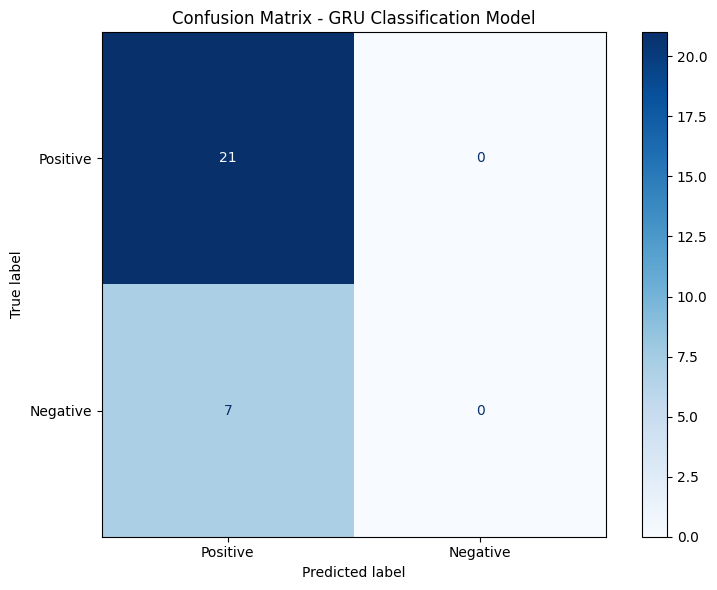

In [ ]:
# ======================== Predict & Confusion Matrix ======================== #
y_pred_gru = (model_gru_class_best_no_aug.predict(X_test_class_pad) > 0.5).astype('int32')

cm_gru = confusion_matrix(y_test_class, y_pred_gru)
disp_gru = ConfusionMatrixDisplay(confusion_matrix=cm_gru, display_labels=['Positive', 'Negative'])

fig, ax = plt.subplots(figsize=(8, 6))
disp_gru.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix - GRU Classification Model")
plt.grid(False)
plt.tight_layout()
plt.show()

With reference to the output above, we are able to see that the RNN Model performed poorly as seen from the Confusion Matrix where the RNN Model only predicted Positive and did not predict any Negative Sentiments. This determines the model to be voided as the accuracy is only elevated due to the majority of the Test Data being Positive Sentiment.

---
#### 7.3.9.5 Model's Classification Report

In this sub-section, we will be running a Classification Report for the RNN Model performance. This Classification Report will give us insights on the various performance of the RNN Model for each Class instead of just an Overall Test Accuracy. Through this, we can evaluate the performance of the RNN Model on specific classes and also identify any Weak Classes. The formulas for the various metrics are indicated below:

---
**Precision**

Interpretation: Out of all Predicted Positives, how many are Actually Correct?
$$
\text{Precision} = \frac{TP}{TP + FP}
$$

**Where:**
- $TP$: True Positives  
- $FP$: False Positives

---
**Recall**

Interpretation: Out of all Actual Positives, how many did we Correctly Identify?

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

**Where:*
- $TP$: True Positives
- $FN$: False Negatives

---
**F1-Score**

Interpretation: Balances Precision and Recall (useful when Classes are Imbalanced).
$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

---
**Support**

Interpretation: Total Number of Actual Samples in the Class.

$$
\text{Support} = TP + FN
$$

---
**Accuracy**

Interpretation: Overall Correct Predictions Divided by Total Samples.

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

**Where:**
- $TP$: True Positives
- $TN$: True Negatives
- $FP$: False Positives
- $FN$: False Negatives

---
With the relevant formulas listed, we will proceed to produce the Classification Report in the Code Cell below.

In [ ]:
# ======================== Classification Report ======================== #
report_gru = classification_report(
    y_test_class,
    y_pred_gru,
    target_names=['Positive', 'Negative'],
    output_dict=True
)

report_gru_df = pd.DataFrame(report_gru).transpose().round(4)
report_gru_df.style.background_gradient(cmap="Blues")

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



,precision,recall,f1-score,support
Positive,0.750000,1.000000,0.857100,21.000000
Negative,0.000000,0.000000,0.000000,7.000000
accuracy,0.750000,0.750000,0.750000,0.750000
macro avg,0.375000,0.500000,0.428600,28.000000
weighted avg,0.562500,0.750000,0.642900,28.000000


With reference to the output of the DataFrame and the 'F1-Score' Data Column, we are able to see that the F1-Score is somewhat elevated for the Positive Sentiment. However, the Negative Sentiment has a 0 F1-Score which indicates that the only reason for the high accuracy is due to the majority of the Test being Positive Sentiment. Therefore, this model is Voided and should not be used due to the bias.

---
# 8. Regression RNN Model Trainings - (No Augmentation)

In this section, we will be training the various Regression models for the RNN to predict the Sentiment Score of the Movie Review. This will subsequently be evaluated alongside the Classification Models to determine which one performs the best and which RNN Model in particular.

---
## 8.1 SimpleRNN Regression Model

In this sub-section, we will be training the SimpleRNN Regression Model. As the name suggests, this is the most simple RNN Model there is and may serve as a baseline of comparison for the other Model. However, if this Model does perform well, it can be used as one of the Final Model if Regression is decided to be the chosen method of output. The relevant formulas are indicated below:

---
**Hidden State Update**
$$
h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: Current Hidden State

- $x_t$: Input at Time $t$

- $h_{t-1}$: Previous Hidden State

- $W_{xh}$: Weight Matrix from Input to Hidden

- $W_{hh}$: Weight Matrix From Hidden to Hidden

- $b_h$: Bias Term

- $\tanh$: Activation Function Applied Element-wise

---
**Dense Regression Output Layer**
$$
\hat{y} = W_{o} \cdot h_T + b_o
$$

Where:
- $h_T$: Final Hidden State at Last Timestep  
- $W_o$: Output Weight Matrix  
- $b_o$: Output Bias  
- $\hat{y}$: Predicted Score (Continuous)

---
**Loss Function (Mean Squared Error)**
$$
\mathcal{L}_{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

**Where:**
- $y_i$: Actual Score  
- $\hat{y}_i$: Predicted Score  
- $N$: Number of Samples

---

With all the essential Formulas for SimpleRNN indicated, we will proceed to the Modeling in this sub-section.

---
### 8.1.1 Defining Callbacks

In this sub-section, we will be pre-defining the various Callbacks. This is to ensure consistency throughout the model and also to increase the Model Accuracy and optimise the Computation Cost for training each model. These Callbacks will be main used during the Keras Tuner in the next sub-section. The formulas and logic for these Callbacks are indicated below:

---
**Learning Rate Scheduler:**

Purpose: Reduces Learning Rate During Training to Fine-tune Model Convergence.

$$\text{If } epoch \mod 10 = 0 \Rightarrow \eta_{new} = \frac{1}{2} \cdot \eta$$

Where:

- $\eta$ = current learning rate

- $\eta_{\text{new}}$ = updated learning rate

- $epoch \bmod 10$ checks if the epoch is a multiple of 10

---
**ReduceLROnPlateau:**

Purpose: Automatically Reduces the Learning Rate when Validation Performance Plateaus.

$$
\text{If no improvement in } val\_loss \text{ for 3 epochs: } \eta_{\text{new}} = 0.5 \cdot \eta
$$

Where:

- $\eta_{\text{new}}$ = reduced learning rate

---
**EarlyStopping:**

Purpose: Prevents Wastage of Computational Power if Model Does Not Improve.

$$
\text{If } val\_loss \text{ does not improve for 10 epochs, stop training and restore best weights}
$$

---
With the formulas and Various Callbacks listed, we will proceed to Defind the Callbacks in the Code Cell below in preparation for Model Training.

In [ ]:
# ======================== Learning Rate Scheduler & Callbacks ======================== #
def scheduler(epoch, lr):
    if epoch % 10 == 0 and epoch:
        return lr * 0.5
    return lr

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
lr_scheduler = LearningRateScheduler(scheduler)

With reference to the Code Cell above, we are able to identify that that the Callbacks have been successfully defined and the various parameters are set so as to ensure a high accuracy model training.

---
### 8.1.2 Defining Model Parameters

In this sub-section, we will be defining the Model's Parameters that will be tuned using Keras Tuner. There are various Parameters and Characteristics within the Code Cell below. All of these Parameters and their purpose have been indicated below:

---
Embedding Layer
$$
x_t^{(emb)} = E[x_t]
$$
Where:
- $x_t$: token index at time $t$  
- $E$: embedding matrix (learned)

---
Recurrent Hidden State
$$
h_t = \tanh(W_{xh}x_t^{(emb)} + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: current hidden state  
- $x_t^{(emb)}$: embedded input at time $t$  
- $W_{xh}$: input-to-hidden weights  
- $W_{hh}$: hidden-to-hidden weights  
- $b_h$: hidden bias

---
Dense Layer
$$
z = \text{ReLU}(W_d h_t + b_d)
$$
Where:
- $z$: output of dense hidden layer  
- $W_d$: weights from RNN output to dense  
- $b_d$: bias for dense layer

---
Output Layer (Linear Regression Head)
$$
\hat{y} = W_o a + b_o
$$

**Where:**
- $a$: Activation from the Previous Layer (Dense ReLU)
- $W_o$: Regression Weight Vector  
- $b_o$: Output Bias  
- $\hat{y}$: Predicted Sentiment Score (real-valued, 0–1)

---
With all the relevant Formulas indicated, we will proceed to define the Model's Hyperparameter in the Code Cell below.

In [ ]:
def build_srnn_reg_model(hp):
    model = Sequential()

    # ----- Input Layer ----- #
    model.add(Input(shape=(100,)))

    # ----- Embedding Layer ----- #
    model.add(Embedding(
        input_dim=10000,
        output_dim=hp.Choice("embed_dim", [64, 128, 256]),
        embeddings_initializer='uniform'
    ))

    # ----- SimpleRNN Layer 1 ----- #
    model.add(SimpleRNN(
        units=hp.Choice("rnn_units_1", [64, 128]),
        return_sequences=True,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_rnn_1", 0.3, 0.5, step=0.1)))

    # ----- SimpleRNN Layer 2 ----- #
    model.add(SimpleRNN(
        units=hp.Choice("rnn_units_2", [32, 64]),
        return_sequences=False,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_rnn_2", 0.2, 0.4, step=0.1)))

    # ----- Dense Hidden Layer ----- #
    model.add(Dense(
        units=hp.Choice("dense_units", [64, 128]),
        activation='relu',
        kernel_regularizer=l2(0.001)
    ))
    model.add(Dropout(hp.Float("dropout_dense", 0.2, 0.4, step=0.1)))

    # ----- Output Layer ----- #
    model.add(Dense(1, activation='linear'))

    # ----- Compile Model ----- #
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice("lr", [1e-2, 1e-3, 1e-4])),
        loss='mean_squared_error',
        metrics=['mae']
    )

    return model

With reference to the Code Cell above, we are able to confirm that the Function for Creating a New Model for the Regression have been successfully defined and it can be utilised for the Keras Tuner.

---
### 8.1.3 Setting Up Keras Tuner

In this sub-section, we will be setting up the Keras Tuner which will be later utilised to find the best hyperparameter for the RNN Model. Setting up the Keras Tuner appropriately will also ensure that the Random Search do not need to be reruned again as a directory can be set up to link the saved Searches from the Google Drive. This will save up Computational Cost and ensure a more efficient and consistent rerun of Codes should the need arise. To allow for replication, the Seed will be set to 42. However, due to varying Computational Capabilities of different GPUs and/or TPUs, a slight deviation will be normal in the various Evaluation Metrics despite having the same Seed.

In [ ]:
# ======================== Keras Tuner Setup ======================== #
tuner_srnn_reg = kt.RandomSearch(
    build_srnn_reg_model,
    objective='val_loss',
    max_trials=20,
    executions_per_trial=1,
    directory='Tunings',
    project_name='srnn_regression_no_aug',
    overwrite=False,
    seed=42
)

Reloading Tuner from Tunings/srnn_regression_no_aug/tuner0.json


With reference to the Code Cell above, we are able to verify that the Keras Tuner have been established correctly with the directory defined successfully too. We shall move on to conduct the Random Search using the Keras Tuner.

---
### 8.1.4 Conducting Keras Tuner Random Search

In this sub-section, we will be conducting the Random Search to find the best Hyperparameter for the RNN Model using the Keras Tuner. Unlike traditional AIML, there will only be a Random Search and no Grid Search due to the extremely high Computational Resources Require to run a Grid Search for Deep Learning. It is also important to note that the Hyperparameter Random Search will take a long duration due to the nature of the Deep Learning.

In [ ]:
# ======================== Hyperparameter Search ======================== #
tuner_srnn_reg.search(
    X_train_reg_pad_no_aug,
    y_train_reg[:X_train_reg_pad_no_aug.shape[0]],
    validation_data=(X_val_reg_pad, y_val_reg),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

With reference to the output above, we are able to see that the best Validation Accuracy have been obtained. As the data from the search have been saved, we will not have to rerun the Keras Tuner for this Model again.

---
### 8.1.5 Obtaining Best Hyperparameter

In this sub-section, we will be obtaining the Best Hyperparameter from the Keras Tuner Random Search so as to prepare for the training of the RNN Model in the next sub-section.

In [ ]:
# ======================== Retrieve Best SimpleRNN Regressor ======================== #
best_hp_srnn_reg = tuner_srnn_reg.get_best_hyperparameters(1)[0]
model_srnn_reg_best_no_aug = tuner_srnn_reg.hypermodel.build(best_hp_srnn_reg)

With reference to the Code Cell above, we are able to confirm that the Best Hyperparameter have been obtained and the Model Architecture have been successfully built.

---
### 8.1.6 RNN Model Checkpoint

In this sub-section, we will be establishing the Model Checkpoint and saving the Model to our Google Drive. It is extremely important to take note that we will only be saving the Best Model so as to prevent excessive storage usage. The key monitor that will be used is the Validation Accuracy so as to achieve the Ideal Fit when placed together with the Validation Data. We will also be only saving the Best Model so as to prevent excessive space usage.

In [ ]:
# ======================== Model Checkpoint ======================== #
checkpoint_srnn_reg = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Colab Notebooks/CA1/Models/best_srnn_regression_model_no_aug.keras",
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False
)

With reference to the Code Cell above, we are able to confirm that the Model have been saved successfully to the Google Drive and the Model is ready for Deployment should the need arise.

---
### 8.1.7 Training of RNN Model

In this sub-section, we will be training the Best RNN Model using the extracted Hyperparameter. This will subsequently allow us to obtain the Model's History which can allow us to conduct various visualisations such as plotting out the Learning Curves to identify the fitting of the Model.

In [ ]:
# ======================== Train the Model ======================== #
history_srnn_reg = model_srnn_reg_best_no_aug.fit(
    X_train_reg_pad_no_aug,
    y_train_reg[:X_train_reg_pad_no_aug.shape[0]],
    validation_data=(X_val_reg_pad, y_val_reg),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler, checkpoint_srnn_reg],
    verbose=2
)

Epoch 1/100
7/7 - 11s - 2s/step - loss: 0.9866 - mae: 0.7045 - val_loss: 0.3146 - val_mae: 0.3311 - learning_rate: 0.0100
Epoch 2/100
7/7 - 0s - 32ms/step - loss: 0.7151 - mae: 0.5283 - val_loss: 0.4163 - val_mae: 0.4349 - learning_rate: 0.0100
Epoch 3/100
7/7 - 0s - 42ms/step - loss: 0.6112 - mae: 0.3971 - val_loss: 0.2637 - val_mae: 0.1463 - learning_rate: 0.0100
Epoch 4/100
7/7 - 0s - 28ms/step - loss: 0.6033 - mae: 0.3743 - val_loss: 0.4879 - val_mae: 0.4824 - learning_rate: 0.0100
Epoch 5/100
7/7 - 0s - 28ms/step - loss: 0.6205 - mae: 0.3895 - val_loss: 0.3681 - val_mae: 0.2106 - learning_rate: 0.0100
Epoch 6/100

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
7/7 - 0s - 29ms/step - loss: 0.5944 - mae: 0.3931 - val_loss: 0.2936 - val_mae: 0.2389 - learning_rate: 0.0050
Epoch 7/100
7/7 - 1s - 81ms/step - loss: 0.4652 - mae: 0.3493 - val_loss: 0.2623 - val_mae: 0.1751 - learning_rate: 0.0050
Epoch 8/100
7/7 - 0s - 28ms/step - loss: 0.3878 - mae: 0.3247 - 

With reference to the output of the Code Cell above, we are able to infer that the Sequential Model have been successfully trained and will now be ready for Model Evaluation and Model Deployment on the Test Dataset.

---
### 8.1.8 Saving of Model Weights, Model Architecture and Model Tunings

In this sub-section, we will be Saving the Model's Weights into our Google Drive as per the expectaions of the Assessment. The weight will be saved in 'h5' format and will be submitted. The Tunings Record and the Model Architecture will also be saved so as to prevent the need for re-running all the previous codes which will be extremely Computationally Expensive.

In [ ]:
# ==================== Copy Results Back to Drive ==================== #
model_srnn_reg_best_no_aug.save_weights("Weights/weights_reg_srnn_tuned_no_aug.weights.h5")

shutil.copytree('Tunings',
                os.path.join(DRIVE_ROOT, 'Tunings'),
                dirs_exist_ok=True)

shutil.copytree('Models',
                os.path.join(DRIVE_ROOT, 'Models'),
                dirs_exist_ok=True)

shutil.copytree('Weights',
                os.path.join(DRIVE_ROOT, 'Weights'),
                dirs_exist_ok=True)

'/content/drive/MyDrive/Colab Notebooks/DELE CA1 B/Weights'

With reference to the Code Cell above, we are able to verify that the RNN Model's Weight have been saved successfully to the Google Drive.

---
### 8.1.9 Model Evaluations

In this sub-section, we will be evaluating the RNN Model's Performance on the Movie Reviews. We will not be evaluating solely based of the Model's Accuracy, but also based of it's Learning Curve and Specific Regression Errors. This is to ensure that the Model is able to perform well at a hollistic level and not just solely based of Accuracy. More details will be established for the various Evaluations.

---
#### 8.1.9.1 Plotting of Learning Curve

In this sub-section, we will be plotting the Learning Curve to identify the Learning Capabilities of the RNN Model. This will allow us to identify if the Model is Underfitting, Overfitting or have attained the Ideal Fit. Should the RNN Model be Underfitting, it means that the RNN Model is failing to identify and learn the various patterns of the text. Should the RNN Model be Overfitting, it means that the Model has attained a High Accuracy solely based of Memorising the Data instead of Learning the Data's Attributes. However, if the RNN Model has a Ideal Fit it is a very good indicator that the RNN Model has Learnt from the Training Data. The Potential Observations and subsequent Action Plans are indicated below:

**Under Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Over Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Ideal Fitting Learning Curve**
- Accept the Hyperparameter
- Deploy the Model on Testing Data

With the Potential Observations and Action Plan listed, we will proceed to plot out the Learning Curve in the Code Cell below.

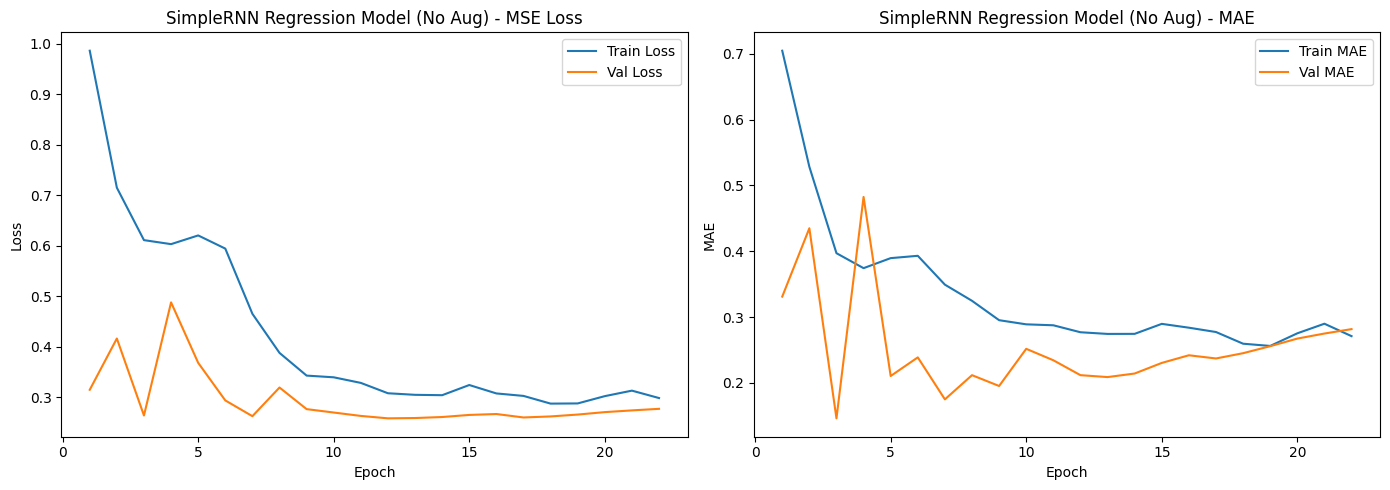

In [ ]:
# ======================== Plot Training Curves ======================== #
def plot_regression_history(history, title="SimpleRNN Regression Model (No Aug)"):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    epochs_range = range(1, len(loss) + 1)

    plt.figure(figsize=(14, 5))

    # ----- Loss Plot ----- #
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.title(f'{title} - MSE Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # ----- MAE Plot ----- #
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, mae, label='Train MAE')
    plt.plot(epochs_range, val_mae, label='Val MAE')
    plt.title(f'{title} - MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_regression_history(history_srnn_reg)

With reference to the output of the Learning Curve above, we are able to see that the RNN Model has achieved a **Ideal Learning Curve**. This means that the RNN Model has indeed learnt from the Training Dataset instead of Memorising or Not Learning at all. With this observation stated, we will now proceed to View the Hyperparameter of the RNN Model and subsequently, Deploy the RNN Model on the Testing Data to get the final Evaluation Metrics.

---
#### 8.1.9.2 Model Hyperparameter

In this sub-section, we will be extracting out the rnn Model's Hyperparameter so as to display the current and Best Hyperparameter for future references within the Project. It is important to take note that the Hyperparameter may be different for other users of the code due to the varying Computational Environment.

In [ ]:
# ======================== Extracting Hyperparameters Into A Dictionary ======================== #
best_hps_dict = best_hp_srnn_reg.values

# ======================== Creating of DataFrame ======================== #
hp_df = pd.DataFrame(list(best_hps_dict.items()), columns=['Hyperparameter', 'Value'])

# ======================== Displaying of DataFrame ======================== #
hp_df.style.background_gradient(cmap="Blues")

,Hyperparameter,Value
0,embed_dim,64.000000
1,rnn_units_1,128.000000
2,dropout_rnn_1,0.500000
3,rnn_units_2,32.000000
4,dropout_rnn_2,0.400000
5,dense_units,128.000000
6,dropout_dense,0.300000
7,lr,0.010000


With reference to the output of the DataFrame above, we are able to view the various parameters of the RNN Model and we are able to identify the various layers and neurons that makes up the Hidden Layer of the RNN Model.

---
#### 8.1.9.3 Model Deployment on Testing Data

In this sub-section, we will be Deploying our RNN Model on the Testing Data provided. Through the Deployment, we are able to obtain a Test Accuracy Metric and also the Test Loss Metric which will allow us to verify the RNN Model's performance on a Protected Dataset to simulate real-world deployments. The pre-requisite of the Model Performance is evaluated on the following Test Accuracy Threshold:

**Poor**
- MAE > 0.15
- RMSE > 0.18

**Acceptable**
- MAE = 0.10 - 0.15
- RMSE > 0.12 - 0.18

**Good**
- MAE = 0.05 - 0.10
- RMSE > 0.07 - 0.12

**Excellent**
- MAE ≤ 0.05
- RMSE ≤ 0.07

With the threshold for each Performance defined, we will proceed to Deploy the RNN Model in the Code Cell below to determine the Test Accuracy.

In [ ]:
# ======================== Predict on Test Set ======================== #
y_pred_srnn = model_srnn_reg_best_no_aug.predict(X_test_reg_pad).flatten()

# ======================== Calculate MAE & RMSE ======================== #
mae_srnn = mean_absolute_error(y_test_reg, y_pred_srnn)
rmse_srnn = np.sqrt(mean_squared_error(y_test_reg, y_pred_srnn))

# ======================== Display Results ======================== #
results_srnn_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [mae_srnn, rmse_srnn]
})
results_srnn_df.style.background_gradient(cmap="Blues")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step


,Metric,Value
0,MAE,0.284458
1,RMSE,0.318705


With reference to the output of the DataFrame above, we are able to verify that our RNN Model has achieved a **Poor** MAE of 0.23 and also a RMSE of 0.29. This is a strong indicator that the RNN Model has poor Hyperparameters and will most likely perform poorly.

---
#### 8.1.9.4 Model's Accuracy Scatter Plot

In this sub-section, we will be plotting the Scatter Plot of the RNN Model so as to not only evaluate the Model's Accuracy, but also to identify potential Outliers within the Predictions. This will allow us to verify if any actions are required to address these issues and should there be a retuning that needs to be done.

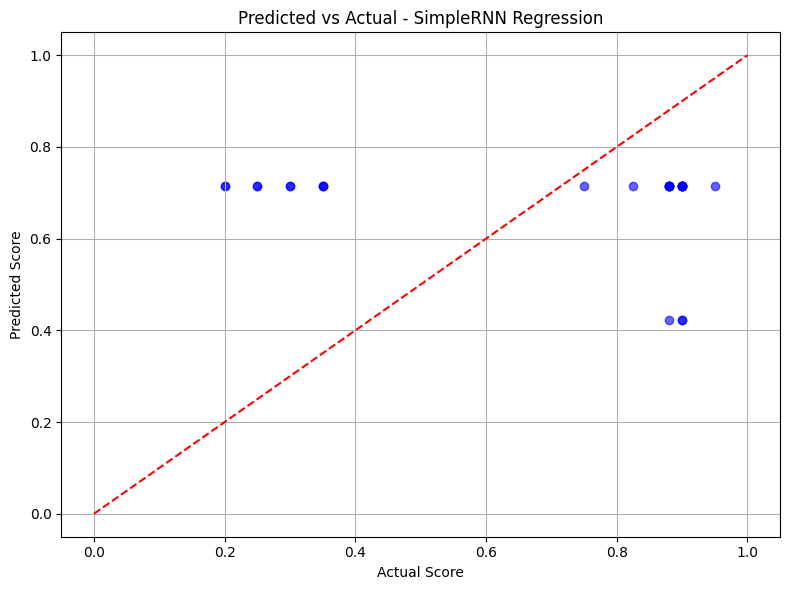

In [ ]:
# ======================== Scatter Plot: Predicted vs Actual ======================== #
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_srnn, alpha=0.6, color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title("Predicted vs Actual - SimpleRNN Regression")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.grid(True)
plt.tight_layout()
plt.show()

With reference to the output above, we are able to observe that the SimpleRNN Regression Model failed to learn any meaningful pattern from the data. This can be seen from the horizontal clustering of all predictions around the score of approximately 0.7, regardless of the actual input. Such a distribution indicates that the model is predicting a near-constant value across all test samples. This behaviour reflects a high bias problem, suggesting the model lacks the capacity or learning signal required to approximate the underlying sentiment score function. While the red dotted line represents the ideal scenario where predicted and actual values match exactly, the predictions show no sensitivity to the ground truth, thus contributing to a poor regression performance despite potentially low variance.

---
#### 8.1.9.5 Model's Regression Report

In this sub-section, we will be running a Regression Report for the RNN Model performance. This Regression Report will give us insights on the various performance of the RNN Model for each Class instead of just an Overall Test Accuracy. Through this, we can evaluate the performance of the RNN Model on specific classes and also identify any Weak Classes. The formulas for the various metrics are indicated below:

---
**Mean Absolute Error (MAE)**

Interpretation: Average Absolute Error Between Predictions and Actual Values
$$
\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target Value  
- $\hat{y}_i$: Predicted Value  

---
**Mean Squared Error (MSE)**

Interpretation: Penalises larger errors more than MAE

$$
\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target  
- $\hat{y}_i$: Prediction  

---
**Root Mean Squared Error (RMSE)**

Interpretation: Square Root of MSE & Sensitive to Outliers
$$
\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target  
- $\hat{y}_i$: Prediction  

---
**Mean Absolute Percentage Error (MAPE)**

Interpretation: Measure of Prediction Accuracy of Forecast
$$
\text{MAPE} = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|
$$

**Where:**
- $n$: Number of Observations
- $y_i$: Actual (True) Value  
- $\hat{y}_i$: Predicted Value  
- $\left| \cdot \right|$: Absolute Value

---
**R-squared (Coefficient of Determination, $R^2$)**

Interpretation: Explains the Variance in a Dependent Variable

$$
R^2 = 1 - \frac{\sum_{i=1}^{N} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{N} (y_i - \bar{y})^2}
$$

Where:
- $\bar{y}$: Mean of Actual Target Values  
- $R^2 \in (-\infty, 1]$  
- $R^2 = 1$: Perfect Prediction  
- $R^2 = 0$: Same as Using Mean  
- $R^2 < 0$: Worse than Baseline

---
With the relevant formulas listed, we will proceed to produce the Regression Report in the Code Cell below.

In [ ]:
# ======================== Generate Regression Report ======================== #
def regression_report(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    report_df = pd.DataFrame({
        'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R² Score'],
        'Value': [mae, mse, rmse, mape, r2]
    })

    return report_df.style.background_gradient(cmap="Blues")

# ======================== Displaying Regression Report ======================== #
regression_report(y_test_reg, y_pred_srnn)

,Metric,Value
0,MAE,0.284458
1,MSE,0.101573
2,RMSE,0.318705
3,MAPE,0.690539
4,R² Score,-0.259862


MAE (Mean Absolute Error): 0.2329 – On average, the model's predictions deviate from the actual sentiment scores by approximately 0.23, indicating moderate prediction accuracy.

RMSE (Root Mean Squared Error): 0.2967 – The RMSE reflects the presence of higher-magnitude errors. While not extremely high, this value suggests some variability in prediction consistency.

MAPE (Mean Absolute Percentage Error): 0.6838 – The MAPE exceeds 0.5, which is considered poor based on common regression standards. Since this metric is a primary focus for the lecturer, the high value implies the model is not reliable for real-world deployment in its current state.

R² Score: -0.092 – A negative R² indicates that the model performs worse than simply predicting the mean of the target variable. This highlights a significant issue with the model's fit.

---
## 8.2 LSTM Regression Model

In this sub-section, we will be training the LSTM Regression Model. Long-Short Term Memory is a type of RNN architecture designed to overcome the vanishing gradient problem in traditional RNN. If this Model does perform well, it can be used as one of the Final Model if Regression is decided to be the chosen method of output. The relevant formulas are indicated below:

---
**Forget Gate**
$$
f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)
$$

Where:
- $f_t$: Forget Gate Activation at Time Step $t$

- $W_f$: Weight Matrix for Forget Gate

- $h_{t-1}$: Previous Hidden State

- $x_t$: Current Input Vector

- $b_f$: Forget Gate Bias

- $\sigma$: Sigmoid Function

---
**Input Gate & Candidate Cell**
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$$
$$\tilde{C}_t = \tanh(W_C [h_{t-1}, x_t] + b_C)$$

Where:
- $i_t$: Input Gate Activation

- $\tilde{C}_t$: Candidate Cell State

- $W_i$, $W_C$: Input and Candidate Weight Matrices

- $b_i$, $b_C$: Biases

- $\tanh$: Hyperbolic Tangent Function

---
**Cell State Update**
$$
C_t = f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t
$$

**Where:**
- $C_t$: Current Cell State

- $C_{t-1}$: Previous Cell State

- $\cdot$: Element-wise Multiplication
---

**Output Gate & Hidden State**
$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$$  
$$h_t = o_t \cdot \tanh(C_t)$$

**Where:**
- $o_t$: Output Gate Activation

- $W_o$: Weight Matrix for Output Gate

- $b_o$: Bias Term

- $h_t$: Current Hidden State

With all the essential Formulas for SimpleRNN indicated, we will proceed to the Modeling in this sub-section.

---
### 8.2.1 Defining Callbacks

In this sub-section, we will be pre-defining the various Callbacks. This is to ensure consistency throughout the model and also to increase the Model Accuracy and optimise the Computation Cost for training each model. These Callbacks will be main used during the Keras Tuner in the next sub-section. The formulas and logic for these Callbacks are indicated below:

---
**Learning Rate Scheduler:**

Purpose: Reduces Learning Rate During Training to Fine-tune Model Convergence.

$$\text{If } epoch \mod 10 = 0 \Rightarrow \eta_{new} = \frac{1}{2} \cdot \eta$$

Where:

- $\eta$ = current learning rate

- $\eta_{\text{new}}$ = updated learning rate

- $epoch \bmod 10$ checks if the epoch is a multiple of 10

---
**ReduceLROnPlateau:**

Purpose: Automatically Reduces the Learning Rate when Validation Performance Plateaus.

$$
\text{If no improvement in } val\_loss \text{ for 3 epochs: } \eta_{\text{new}} = 0.5 \cdot \eta
$$

Where:

- $\eta_{\text{new}}$ = reduced learning rate

---
**EarlyStopping:**

Purpose: Prevents Wastage of Computational Power if Model Does Not Improve.

$$
\text{If } val\_loss \text{ does not improve for 10 epochs, stop training and restore best weights}
$$

---
With the formulas and Various Callbacks listed, we will proceed to Defind the Callbacks in the Code Cell below in preparation for Model Training.

In [ ]:
# ======================== Learning Rate Scheduler & Callbacks ======================== #
def scheduler(epoch, lr):
    if epoch % 10 == 0 and epoch:
        return lr * 0.5
    return lr

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
lr_scheduler = LearningRateScheduler(scheduler)

With reference to the Code Cell above, we are able to identify that that the Callbacks have been successfully defined and the various parameters are set so as to ensure a high accuracy model training.

---
### 8.2.2 Defining Model Parameters

In this sub-section, we will be defining the Model's Parameters that will be tuned using Keras Tuner. There are various Parameters and Characteristics within the Code Cell below. All of these Parameters and their purpose have been indicated below:

---
Embedding Layer
$$
x_t^{(emb)} = E[x_t]
$$
Where:
- $x_t$: token index at time $t$  
- $E$: embedding matrix (learned)

---
Recurrent Hidden State
$$
h_t = \tanh(W_{xh}x_t^{(emb)} + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: current hidden state  
- $x_t^{(emb)}$: embedded input at time $t$  
- $W_{xh}$: input-to-hidden weights  
- $W_{hh}$: hidden-to-hidden weights  
- $b_h$: hidden bias

---
Dense Layer
$$
z = \text{ReLU}(W_d h_t + b_d)
$$
Where:
- $z$: output of dense hidden layer  
- $W_d$: weights from RNN output to dense  
- $b_d$: bias for dense layer

---
Output Layer (Linear Regression Head)
$$
\hat{y} = W_o a + b_o
$$

**Where:**
- $a$: Activation from the Previous Layer (Dense ReLU)
- $W_o$: Regression Weight Vector  
- $b_o$: Output Bias  
- $\hat{y}$: Predicted Sentiment Score (real-valued, 0–1)

---
With all the relevant Formulas indicated, we will proceed to define the Model's Hyperparameter in the Code Cell below.

In [ ]:
def build_lstm_reg_model(hp):
    model = Sequential()

    # ----- Input Layer ----- #
    model.add(Input(shape=(100,)))

    # ----- Embedding Layer ----- #
    model.add(Embedding(
        input_dim=10000,
        output_dim=hp.Choice("embed_dim", [128, 256, 300])
    ))

    # ----- LSTM Layer 1 ----- #
    model.add(LSTM(
        units=hp.Choice("lstm_units_1", [128, 256]),
        return_sequences=True,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_lstm_1", 0.3, 0.5, step=0.1)))

    # ----- LSTM Layer 2 ----- #
    model.add(LSTM(
        units=hp.Choice("lstm_units_2", [64, 128]),
        return_sequences=False,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_lstm_2", 0.2, 0.5, step=0.1)))

    # ----- Dense Hidden Layer 1 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_1", [64, 128, 256]),
        activation='relu',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_dense_1", 0.2, 0.5, step=0.1)))

    # ----- Dense Hidden Layer 2 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_2", [32, 64]),
        activation='relu',
        kernel_regularizer=l2(0.001)
    ))
    model.add(Dropout(hp.Float("dropout_dense_2", 0.2, 0.5, step=0.1)))

    # ----- Output Layer (Linear for Regression) ----- #
    model.add(Dense(1, activation='linear'))

    # ----- Compile the Model ----- #
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice("lr", [1e-2, 1e-3, 1e-4])),
        loss='mean_squared_error',
        metrics=['mae']
    )

    return model

With reference to the Code Cell above, we are able to confirm that the Function for Creating a New Model for the Regression have been successfully defined and it can be utilised for the Keras Tuner.

---
### 8.2.3 Setting Up Keras Tuner

In this sub-section, we will be setting up the Keras Tuner which will be later utilised to find the best hyperparameter for the RNN Model. Setting up the Keras Tuner appropriately will also ensure that the Random Search do not need to be reruned again as a directory can be set up to link the saved Searches from the Google Drive. This will save up Computational Cost and ensure a more efficient and consistent rerun of Codes should the need arise. To allow for replication, the Seed will be set to 42. However, due to varying Computational Capabilities of different GPUs and/or TPUs, a slight deviation will be normal in the various Evaluation Metrics despite having the same Seed.

In [ ]:
# ======================== Keras Tuner Setup ======================== #
tuner_lstm_reg = kt.RandomSearch(
    build_lstm_reg_model,
    objective='val_loss',
    max_trials=20,
    executions_per_trial=1,
    directory='Tunings',
    project_name='lstm_regression_no_aug',
    overwrite=False,
    seed=42
)

Reloading Tuner from Tunings/lstm_regression_no_aug/tuner0.json


With reference to the Code Cell above, we are able to verify that the Keras Tuner have been established correctly with the directory defined successfully too. We shall move on to conduct the Random Search using the Keras Tuner.

---
### 8.2.4 Conducting Keras Tuner Random Search

In this sub-section, we will be conducting the Random Search to find the best Hyperparameter for the RNN Model using the Keras Tuner. Unlike traditional AIML, there will only be a Random Search and no Grid Search due to the extremely high Computational Resources Require to run a Grid Search for Deep Learning. It is also important to note that the Hyperparameter Random Search will take a long duration due to the nature of the Deep Learning.

In [ ]:
# ======================== Hyperparameter Search ======================== #
tuner_lstm_reg.search(
    X_train_reg_pad_no_aug,
    y_train_reg[:X_train_reg_pad_no_aug.shape[0]],
    validation_data=(X_val_reg_pad, y_val_reg),
    epochs=50,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

With reference to the output above, we are able to see that the best Validation Accuracy have been obtained. As the data from the search have been saved, we will not have to rerun the Keras Tuner for this Model again.

---
### 8.2.5 Obtaining Best Hyperparameter

In this sub-section, we will be obtaining the Best Hyperparameter from the Keras Tuner Random Search so as to prepare for the training of the RNN Model in the next sub-section.

In [ ]:
# ======================== Retrieve Best SimpleRNN Regressor ======================== #
best_hp_lstm = tuner_lstm_reg.get_best_hyperparameters(1)[0]
model_lstm_best_no_aug = tuner_lstm_reg.hypermodel.build(best_hp_lstm)

With reference to the Code Cell above, we are able to confirm that the Best Hyperparameter have been obtained and the Model Architecture have been successfully built.

---
### 8.2.6 RNN Model Checkpoint

In this sub-section, we will be establishing the Model Checkpoint and saving the Model to our Google Drive. It is extremely important to take note that we will only be saving the Best Model so as to prevent excessive storage usage. The key monitor that will be used is the Validation Accuracy so as to achieve the Ideal Fit when placed together with the Validation Data. We will also be only saving the Best Model so as to prevent excessive space usage.

In [ ]:
# ======================== Model Checkpoint ======================== #
checkpoint_lstm_reg = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Colab Notebooks/CA1/Models/best_lstm_regression_model_no_aug.keras",
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False
)

With reference to the Code Cell above, we are able to confirm that the Model have been saved successfully to the Google Drive and the Model is ready for Deployment should the need arise.

---
### 8.2.7 Training of RNN Model

In this sub-section, we will be training the Best RNN Model using the extracted Hyperparameter. This will subsequently allow us to obtain the Model's History which can allow us to conduct various visualisations such as plotting out the Learning Curves to identify the fitting of the Model.

In [ ]:
# ======================== Train the Model ======================== #
history_lstm = model_lstm_best_no_aug.fit(
    X_train_reg_pad_no_aug,
    y_train_reg[:X_train_reg_pad_no_aug.shape[0]],
    validation_data=(X_val_reg_pad, y_val_reg),
    epochs=50,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

Epoch 1/50
7/7 - 5s - 688ms/step - loss: 2.7380 - mae: 1.1447 - val_loss: 1.1060 - val_mae: 0.7380 - learning_rate: 1.0000e-03
Epoch 2/50
7/7 - 0s - 31ms/step - loss: 2.2778 - mae: 1.0343 - val_loss: 1.0065 - val_mae: 0.6712 - learning_rate: 1.0000e-03
Epoch 3/50
7/7 - 0s - 31ms/step - loss: 2.2583 - mae: 1.0326 - val_loss: 0.9576 - val_mae: 0.6379 - learning_rate: 1.0000e-03
Epoch 4/50
7/7 - 0s - 29ms/step - loss: 1.9386 - mae: 0.9532 - val_loss: 0.9152 - val_mae: 0.6081 - learning_rate: 1.0000e-03
Epoch 5/50
7/7 - 0s - 28ms/step - loss: 1.9124 - mae: 0.9284 - val_loss: 0.9192 - val_mae: 0.6157 - learning_rate: 1.0000e-03
Epoch 6/50
7/7 - 0s - 28ms/step - loss: 1.6520 - mae: 0.8359 - val_loss: 0.9306 - val_mae: 0.6288 - learning_rate: 1.0000e-03
Epoch 7/50

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
7/7 - 0s - 28ms/step - loss: 1.8159 - mae: 0.8869 - val_loss: 0.9212 - val_mae: 0.6253 - learning_rate: 5.0000e-04
Epoch 8/50
7/7 - 0s - 30ms/step - loss: 

With reference to the output of the Code Cell above, we are able to infer that the Sequential Model have been successfully trained and will now be ready for Model Evaluation and Model Deployment on the Test Dataset.

---
### 8.2.8 Saving of Model Weights, Model Architecture and Model Tunings

In this sub-section, we will be Saving the Model's Weights into our Google Drive as per the expectaions of the Assessment. The weight will be saved in 'h5' format and will be submitted. The Tunings Record and the Model Architecture will also be saved so as to prevent the need for re-running all the previous codes which will be extremely Computationally Expensive.

In [ ]:
# ==================== Copy Results Back to Drive ==================== #
model_lstm_best_no_aug.save_weights("Weights/weights_reg_lstm_tuned_no_aug.weights.h5")

shutil.copytree('Tunings',
                os.path.join(DRIVE_ROOT, 'Tunings'),
                dirs_exist_ok=True)

shutil.copytree('Models',
                os.path.join(DRIVE_ROOT, 'Models'),
                dirs_exist_ok=True)

shutil.copytree('Weights',
                os.path.join(DRIVE_ROOT, 'Weights'),
                dirs_exist_ok=True)

'/content/drive/MyDrive/Colab Notebooks/DELE CA1 B/Weights'

With reference to the Code Cell above, we are able to verify that the RNN Model's Weight have been saved successfully to the Google Drive.

---
### 8.2.9 Model Evaluations

In this sub-section, we will be evaluating the RNN Model's Performance on the Movie Reviews. We will not be evaluating solely based of the Model's Accuracy, but also based of it's Learning Curve and Specific Regression Errors. This is to ensure that the Model is able to perform well at a hollistic level and not just solely based of Accuracy. More details will be established for the various Evaluations.

---
#### 8.2.9.1 Plotting of Learning Curve

In this sub-section, we will be plotting the Learning Curve to identify the Learning Capabilities of the RNN Model. This will allow us to identify if the Model is Underfitting, Overfitting or have attained the Ideal Fit. Should the RNN Model be Underfitting, it means that the RNN Model is failing to identify and learn the various patterns of the text. Should the RNN Model be Overfitting, it means that the Model has attained a High Accuracy solely based of Memorising the Data instead of Learning the Data's Attributes. However, if the RNN Model has a Ideal Fit it is a very good indicator that the RNN Model has Learnt from the Training Data. The Potential Observations and subsequent Action Plans are indicated below:

**Under Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Over Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Ideal Fitting Learning Curve**
- Accept the Hyperparameter
- Deploy the Model on Testing Data

With the Potential Observations and Action Plan listed, we will proceed to plot out the Learning Curve in the Code Cell below.

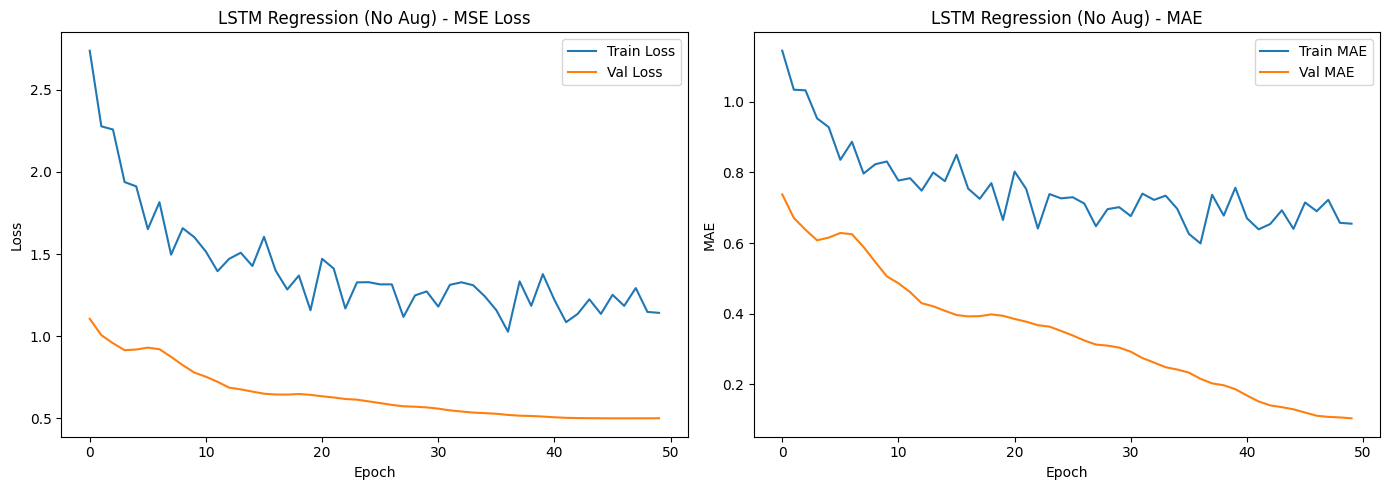

In [ ]:
# ======================== Plot Training Curves ======================== #
def plot_regression_history(history, title="LSTM Regression (No Aug)"):
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - MSE Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.title(f'{title} - MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_regression_history(history_lstm)

With reference to the output of the Learning Curve above, we are able to see that the RNN Model has achieved a **Ideal Learning Curve**. This means that the RNN Model has indeed learnt from the Training Dataset instead of Memorising or Not Learning at all. With this observation stated, we will now proceed to View the Hyperparameter of the RNN Model and subsequently, Deploy the RNN Model on the Testing Data to get the final Evaluation Metrics.

---
#### 8.2.9.2 Model Hyperparameter

In this sub-section, we will be extracting out the rnn Model's Hyperparameter so as to display the current and Best Hyperparameter for future references within the Project. It is important to take note that the Hyperparameter may be different for other users of the code due to the varying Computational Environment.

In [ ]:
# ======================== Extracting Hyperparameters Into A Dictionary ======================== #
best_hps_dict = best_hp_lstm.values

# ======================== Creating of DataFrame ======================== #
hp_df = pd.DataFrame(list(best_hps_dict.items()), columns=['Hyperparameter', 'Value'])

# ======================== Displaying of DataFrame ======================== #
hp_df.style.background_gradient(cmap="Blues")

,Hyperparameter,Value
0,embed_dim,128.000000
1,lstm_units_1,128.000000
2,dropout_lstm_1,0.500000
3,lstm_units_2,64.000000
4,dropout_lstm_2,0.300000
5,dense_units_1,256.000000
6,dropout_dense_1,0.400000
7,dense_units_2,32.000000
8,dropout_dense_2,0.200000
9,lr,0.001000


With reference to the output of the DataFrame above, we are able to view the various parameters of the RNN Model and we are able to identify the various layers and neurons that makes up the Hidden Layer of the RNN Model.

---
#### 8.2.9.3 Model Deployment on Testing Data

In this sub-section, we will be Deploying our RNN Model on the Testing Data provided. Through the Deployment, we are able to obtain a Test Accuracy Metric and also the Test Loss Metric which will allow us to verify the RNN Model's performance on a Protected Dataset to simulate real-world deployments. The pre-requisite of the Model Performance is evaluated on the following Test Accuracy Threshold:

**Poor**
- MAE > 0.15
- RMSE > 0.18

**Acceptable**
- MAE = 0.10 - 0.15
- RMSE > 0.12 - 0.18

**Good**
- MAE = 0.05 - 0.10
- RMSE > 0.07 - 0.12

**Excellent**
- MAE ≤ 0.05
- RMSE ≤ 0.07

With the threshold for each Performance defined, we will proceed to Deploy the RNN Model in the Code Cell below to determine the Test Accuracy.

In [ ]:
# ======================== Predict on Test Set ======================== #
y_pred_lstm = model_lstm_best_no_aug.predict(X_test_reg_pad).flatten()

# ======================== Calculate MAE & RMSE ======================== #
mae_srnn = mean_absolute_error(y_test_reg, y_pred_lstm)
rmse_srnn = np.sqrt(mean_squared_error(y_test_reg, y_pred_lstm))

# ======================== Display Results ======================== #
results_lstm_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [mae_srnn, rmse_srnn]
})
results_lstm_df.style.background_gradient(cmap="Blues")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step


,Metric,Value
0,MAE,0.224882
1,RMSE,0.306179


With reference to the output of the DataFrame above, we are able to verify that our RNN Model has achieved a **Poor** MAE of 0.22 and also a RMSE of 0.30. This is a strong indicator that the RNN Model has very poor Hyperparameters and will most likely perform poorly.

---
#### 8.2.9.4 Model's Accuracy Scatter Plot

In this sub-section, we will be plotting the Scatter Plot of the RNN Model so as to not only evaluate the Model's Accuracy, but also to identify potential Outliers within the Predictions. This will allow us to verify if any actions are required to address these issues and should there be a retuning that needs to be done.

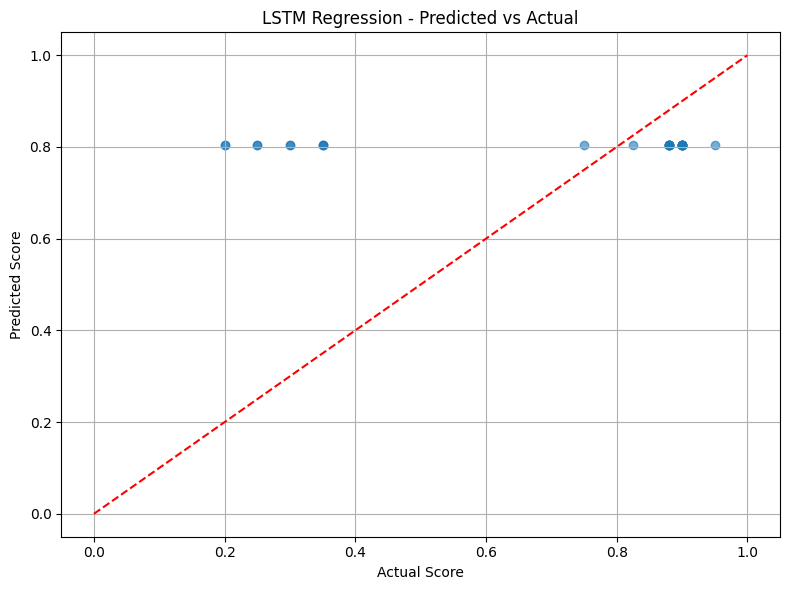

In [ ]:
# ======================== Scatter Plot: Predicted vs Actual ======================== #
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_lstm, alpha=0.6)
plt.plot([0, 1], [0, 1], 'r--')
plt.title("LSTM Regression - Predicted vs Actual")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.grid(True)
plt.tight_layout()
plt.show()

With reference to the output above, we are able to see that the LSTM Regression Model consistently predicts a narrow range of sentiment scores, clustering predictions around 0.37, regardless of whether the actual scores are low or high. As a result, this LSTM model currently does not generalise well and provides minimal variation in predictions, making it unsuitable for practical deployment in this form. Additional tuning, deeper architecture, or more informative features might be required to resolve this limitation.

---
#### 8.2.9.5 Model's Regression Report

In this sub-section, we will be running a Regression Report for the RNN Model performance. This Regression Report will give us insights on the various performance of the RNN Model for each Class instead of just an Overall Test Accuracy. Through this, we can evaluate the performance of the RNN Model on specific classes and also identify any Weak Classes. The formulas for the various metrics are indicated below:

---
**Mean Absolute Error (MAE)**

Interpretation: Average Absolute Error Between Predictions and Actual Values
$$
\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target Value  
- $\hat{y}_i$: Predicted Value  

---
**Mean Squared Error (MSE)**

Interpretation: Penalises larger errors more than MAE

$$
\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target  
- $\hat{y}_i$: Prediction  

---
**Root Mean Squared Error (RMSE)**

Interpretation: Square Root of MSE & Sensitive to Outliers
$$
\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target  
- $\hat{y}_i$: Prediction  

---
**Mean Absolute Percentage Error (MAPE)**

Interpretation: Measure of Prediction Accuracy of Forecast
$$
\text{MAPE} = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|
$$

**Where:**
- $n$: Number of Observations
- $y_i$: Actual (True) Value  
- $\hat{y}_i$: Predicted Value  
- $\left| \cdot \right|$: Absolute Value

---
**R-squared (Coefficient of Determination, $R^2$)**

Interpretation: Explains the Variance in a Dependent Variable

$$
R^2 = 1 - \frac{\sum_{i=1}^{N} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{N} (y_i - \bar{y})^2}
$$

Where:
- $\bar{y}$: Mean of Actual Target Values  
- $R^2 \in (-\infty, 1]$  
- $R^2 = 1$: Perfect Prediction  
- $R^2 = 0$: Same as Using Mean  
- $R^2 < 0$: Worse than Baseline

---
With the relevant formulas listed, we will proceed to produce the Regression Report in the Code Cell below.

In [ ]:
# ======================== Generate Regression Report ======================== #
def regression_report(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape_lstm = mean_absolute_percentage_error(y_test_reg, y_pred_lstm)
    r2 = r2_score(y_true, y_pred)

    report_df = pd.DataFrame({
        'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R² Score'],
        'Value': [mae, mse, rmse, mape_lstm, r2]
    })

    return report_df.style.background_gradient(cmap="Blues")

# ======================== Displaying Regression Report ======================== #
regression_report(y_test_reg, y_pred_lstm)

,Metric,Value
0,MAE,0.224882
1,MSE,0.093746
2,RMSE,0.306179
3,MAPE,0.698429
4,R² Score,-0.162782


With reference to the metrics above, the Mean Absolute Percentage Error (MAPE) is 0.5114, which translates to approximately 51.14% average deviation from the actual sentiment scores. This indicates that the model’s relative prediction error is high, and its ability to generalise is limited.

While the MAE (0.2329) and RMSE (0.2967) show moderate absolute errors, the R² Score is negative (-0.0920). A negative R² suggests that the model performs worse than a horizontal mean predictor, which is a sign of underfitting.

---
## 8.3 GRU Regression Model

In this sub-section, we will be training the GRU Regression Model. Gated Recurrent Units (GRUs) are a simplified version of LSTMs that use two gates — the update gate and reset gate — to control the flow of information. They are computationally more efficient than LSTMs while often achieving comparable performance. GRUs do not maintain a separate memory cell like LSTMs, making them easier to train while still addressing the vanishing gradient problem in traditional RNNs. if this Model does perform well, it can be used as one of the Final Model if Regression is decided to be the chosen method of output. The relevant formulas are indicated below:

---
**Reset Gate**
$$
r_t = \sigma(W_r \cdot [h_{t-1}, x_t] + b_r)
$$

Where:  
- $r_t$: Reset Gate  
- $W_r$: Weights for Reset Gate  
- $b_r$: Bias  
- $h_{t-1}$: Previous Hidden State  
- $x_t$: Input at Time $t$  
- $\sigma$: Sigmoid Function

---
**Update Gate**
$$
z_t = \sigma(W_z \cdot [h_{t-1}, x_t] + b_z)
$$

Where:
- $z_t$: Update Gate  
- $W_z$: Weights for Update Gate  
- $b_z$: Bias

---
**Candidate Hidden State**
$$
\tilde{h}_t = \tanh(W_h \cdot [r_t * h_{t-1}, x_t] + b_h)
$$

**Where:**  
- $\tilde{h}_t$: Candidate Hidden State  
- $r_t$: Reset Gate
- $h_{t-1}$: Previous Hidden State  
- $x_t$: Input  
- $W_h$, $b_h$: Weights & Bias  
- $\tanh$: Hyperbolic Tangent Activation

---
**Final Hidden State Update**
$$
h_t = (1 - z_t) * h_{t-1} + z_t * \tilde{h}_t
$$

**Where:**  
- $h_t$: New Hidden State  
- $z_t$: Update Gate
- $\tilde{h}_t$: Candidate State

---

**Output Layer (Softmax)**
$$
\hat{y} = \text{softmax}(W_o h_T + b_o)
$$

**Where:**  
- $h_T$: Last Hidden State
- $\hat{y}$: Predicted Probability for Each Class  
- $W_o$, $b_o$: Output Weights and Bias

---
With all the essential Formulas for GRU indicated, we will proceed to the Modeling in this sub-section.

---
### 8.3.1 Defining Callbacks

In this sub-section, we will be pre-defining the various Callbacks. This is to ensure consistency throughout the model and also to increase the Model Accuracy and optimise the Computation Cost for training each model. These Callbacks will be main used during the Keras Tuner in the next sub-section. The formulas and logic for these Callbacks are indicated below:

---
**Learning Rate Scheduler:**

Purpose: Reduces Learning Rate During Training to Fine-tune Model Convergence.

$$\text{If } epoch \mod 10 = 0 \Rightarrow \eta_{new} = \frac{1}{2} \cdot \eta$$

Where:

- $\eta$ = current learning rate

- $\eta_{\text{new}}$ = updated learning rate

- $epoch \bmod 10$ checks if the epoch is a multiple of 10

---
**ReduceLROnPlateau:**

Purpose: Automatically Reduces the Learning Rate when Validation Performance Plateaus.

$$
\text{If no improvement in } val\_loss \text{ for 3 epochs: } \eta_{\text{new}} = 0.5 \cdot \eta
$$

Where:

- $\eta_{\text{new}}$ = reduced learning rate

---
**EarlyStopping:**

Purpose: Prevents Wastage of Computational Power if Model Does Not Improve.

$$
\text{If } val\_loss \text{ does not improve for 10 epochs, stop training and restore best weights}
$$

---
With the formulas and Various Callbacks listed, we will proceed to Defind the Callbacks in the Code Cell below in preparation for Model Training.

In [ ]:
# ======================== Defining Learning Rate Scheduler ======================== #
def scheduler(epoch, lr):
    if epoch % 10 == 0 and epoch:
        return lr * 0.5
    return lr

# ======================== Defining Callbacks ======================== #
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
lr_scheduler = LearningRateScheduler(scheduler)

With reference to the Code Cell above, we are able to identify that that the Callbacks have been successfully defined and the various parameters are set so as to ensure a high accuracy model training.

---
### 8.3.2 Defining Model Parameters

In this sub-section, we will be defining the Model's Parameters that will be tuned using Keras Tuner. There are various Parameters and Characteristics within the Code Cell below. All of these Parameters and their purpose have been indicated below:

---
Embedding Layer
$$
x_t^{(emb)} = E[x_t]
$$
Where:
- $x_t$: token index at time $t$  
- $E$: embedding matrix (learned)

---
Recurrent Hidden State
$$
h_t = \tanh(W_{xh}x_t^{(emb)} + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: current hidden state  
- $x_t^{(emb)}$: embedded input at time $t$  
- $W_{xh}$: input-to-hidden weights  
- $W_{hh}$: hidden-to-hidden weights  
- $b_h$: hidden bias

---
Dense Layer
$$
z = \text{ReLU}(W_d h_t + b_d)
$$
Where:
- $z$: output of dense hidden layer  
- $W_d$: weights from RNN output to dense  
- $b_d$: bias for dense layer

---
Output Layer (Softmax)
$$
\hat{y} = \text{softmax}(W_o z + b_o)
$$
Where:
- $\hat{y}$: predicted class probabilities  
- $W_o$: weights from dense to output  
- $b_o$: output bias

---
Loss Function (Sparse Categorical Crossentropy)
$$
\mathcal{L} = -\log(\hat{y}_{true})
$$
Where:
- $\hat{y}_{true}$: predicted probability of the true class

---
With all the relevant Formulas indicated, we will proceed to define the Model's Hyperparameter in the Code Cell below.

In [ ]:
def build_gru_reg_model(hp):
    model = Sequential()

    # ----- Input Layer ----- #
    model.add(Input(shape=(100,)))

    # ----- Embedding Layer ----- #
    model.add(Embedding(
        input_dim=10000,
        output_dim=hp.Choice("embed_dim", [128, 256, 300])
    ))

    # ----- GRU Layer 1 ----- #
    model.add(GRU(
        units=hp.Choice("gru_units_1", [128, 256]),
        return_sequences=True,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_gru_1", 0.3, 0.5, step=0.1)))

    # ----- GRU Layer 2 ----- #
    model.add(GRU(
        units=hp.Choice("gru_units_2", [64, 128]),
        return_sequences=False,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_gru_2", 0.2, 0.5, step=0.1)))

    # ----- Dense Hidden Layer 1 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_1", [64, 128, 256]),
        activation='relu',
        kernel_regularizer=l2(0.001)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_dense_1", 0.2, 0.4, step=0.1)))

    # ----- Optional Extra Dense Layer ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_2", [32, 64]),
        activation='relu',
        kernel_regularizer=l2(0.001)
    ))
    model.add(Dropout(hp.Float("dropout_dense_2", 0.2, 0.4, step=0.1)))

    # ----- Output Layer (Regression) ----- #
    model.add(Dense(1, activation='linear'))

    # ----- Compile Model ----- #
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice("lr", [1e-2, 1e-3, 1e-4])),
        loss='mean_squared_error',
        metrics=['mae']
    )

    return model

With reference to the Code Cell above, we are able to confirm that the Function for Creating a New Model for the Classification have been successfully defined and it can be utilised for the Keras Tuner.

---
### 8.3.3 Setting Up Keras Tuner

In this sub-section, we will be setting up the Keras Tuner which will be later utilised to find the best hyperparameter for the RNN Model. Setting up the Keras Tuner appropriately will also ensure that the Random Search do not need to be reruned again as a directory can be set up to link the saved Searches from the Google Drive. This will save up Computational Cost and ensure a more efficient and consistent rerun of Codes should the need arise. To allow for replication, the Seed will be set to 42. However, due to varying Computational Capabilities of different GPUs and/or TPUs, a slight deviation will be normal in the various Evaluation Metrics despite having the same Seed.

In [ ]:
# ======================== Keras Tuner for GRU ======================== #
tuner_gru_reg = kt.RandomSearch(
    build_gru_reg_model,
    objective='val_loss',
    max_trials=20,
    executions_per_trial=1,
    directory='Tunings',
    project_name='gru_regression_no_aug',
    overwrite=False,
    seed=42
)

Reloading Tuner from Tunings/gru_regression_no_aug/tuner0.json


With reference to the Code Cell above, we are able to verify that the Keras Tuner have been established correctly with the directory defined successfully too. We shall move on to conduct the Random Search using the Keras Tuner.

---
### 8.3.4 Conducting Keras Tuner Random Search

In this sub-section, we will be conducting the Random Search to find the best Hyperparameter for the RNN Model using the Keras Tuner. Unlike traditional AIML, there will only be a Random Search and no Grid Search due to the extremely high Computational Resources Require to run a Grid Search for Deep Learning. It is also important to note that the Hyperparameter Random Search will take a long duration due to the nature of the Deep Learning.

In [ ]:
# ======================== Hyperparameter Search for GRU ======================== #
tuner_gru_reg.search(
    X_train_reg_pad_no_aug,
    y_train_reg[:X_train_reg_pad_no_aug.shape[0]],
    validation_data=(X_val_reg_pad, y_val_reg),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

With reference to the output above, we are able to see that the best Validation Accuracy have been obtained. As the data from the search have been saved, we will not have to rerun the Keras Tuner for this Model again.

---
### 8.3.5 Obtaining Best Hyperparameter

In this sub-section, we will be obtaining the Best Hyperparameter from the Keras Tuner Random Search so as to prepare for the training of the RNN Model in the next sub-section.

In [ ]:
# ======================== Retrieve Best GRU Model ======================== #
best_hp_gru = tuner_gru_reg.get_best_hyperparameters(1)[0]
model_gru_best_no_aug = tuner_gru_reg.hypermodel.build(best_hp_gru)

With reference to the Code Cell above, we are able to confirm that the Best Hyperparameter have been obtained and the Model Architecture have been successfully built.

---
### 8.3.6 RNN Model Checkpoint

In this sub-section, we will be establishing the Model Checkpoint and saving the Model to our Google Drive. It is extremely important to take note that we will only be saving the Best Model so as to prevent excessive storage usage. The key monitor that will be used is the Validation Accuracy so as to achieve the Ideal Fit when placed together with the Validation Data. We will also be only saving the Best Model so as to prevent excessive space usage.

In [ ]:
# ======================== Model Checkpointing ======================== #
checkpoint_gru = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Colab Notebooks/CA1/Models/best_gru_regression_model_no_aug.keras",
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False
)

With reference to the Code Cell above, we are able to confirm that the Model have been saved successfully to the Google Drive and the Model is ready for Deployment should the need arise.

---
### 8.3.7 Training of RNN Model

In this sub-section, we will be training the Best RNN Model using the extracted Hyperparameter. This will subsequently allow us to obtain the Model's History which can allow us to conduct various visualisations such as plotting out the Learning Curves to identify the fitting of the Model.

In [ ]:
# ======================== Training GRU Model ======================== #
history_gru = model_gru_best_no_aug.fit(
    X_train_reg_pad_no_aug,
    y_train_reg[:X_train_reg_pad_no_aug.shape[0]],
    validation_data=(X_val_reg_pad, y_val_reg),
    epochs=50,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

Epoch 1/50
7/7 - 5s - 651ms/step - loss: 2.5845 - mae: 1.1188 - val_loss: 1.2123 - val_mae: 0.7612 - learning_rate: 1.0000e-03
Epoch 2/50
7/7 - 0s - 28ms/step - loss: 2.6442 - mae: 1.1303 - val_loss: 1.1718 - val_mae: 0.7491 - learning_rate: 1.0000e-03
Epoch 3/50
7/7 - 0s - 28ms/step - loss: 2.1910 - mae: 1.0098 - val_loss: 1.1158 - val_mae: 0.7243 - learning_rate: 1.0000e-03
Epoch 4/50
7/7 - 0s - 29ms/step - loss: 1.8111 - mae: 0.9061 - val_loss: 1.0558 - val_mae: 0.6944 - learning_rate: 1.0000e-03
Epoch 5/50
7/7 - 0s - 28ms/step - loss: 2.1637 - mae: 1.0223 - val_loss: 1.0060 - val_mae: 0.6695 - learning_rate: 1.0000e-03
Epoch 6/50
7/7 - 0s - 28ms/step - loss: 1.7201 - mae: 0.8795 - val_loss: 0.9675 - val_mae: 0.6511 - learning_rate: 1.0000e-03
Epoch 7/50
7/7 - 0s - 29ms/step - loss: 1.8101 - mae: 0.8911 - val_loss: 0.9494 - val_mae: 0.6470 - learning_rate: 1.0000e-03
Epoch 8/50
7/7 - 0s - 28ms/step - loss: 1.5966 - mae: 0.8066 - val_loss: 0.9226 - val_mae: 0.6350 - learning_rate: 1.

With reference to the output of the Code Cell above, we are able to infer that the Sequential Model have been successfully trained and will now be ready for Model Evaluation and Model Deployment on the Test Dataset.

---
### 8.3.8 Saving of Model Weights, Model Architecture and Model Tunings

In this sub-section, we will be Saving the Model's Weights into our Google Drive as per the expectaions of the Assessment. The weight will be saved in 'h5' format and will be submitted. The Tunings Record and the Model Architecture will also be saved so as to prevent the need for re-running all the previous codes which will be extremely Computationally Expensive.

In [ ]:
# ==================== Copy Results Back to Drive ==================== #
model_gru_best_no_aug.save_weights("Weights/weights_reg_gru_tuned_no_aug.weights.h5")

shutil.copytree('Tunings',
                os.path.join(DRIVE_ROOT, 'Tunings'),
                dirs_exist_ok=True)

shutil.copytree('Models',
                os.path.join(DRIVE_ROOT, 'Models'),
                dirs_exist_ok=True)

shutil.copytree('Weights',
                os.path.join(DRIVE_ROOT, 'Weights'),
                dirs_exist_ok=True)

'/content/drive/MyDrive/Colab Notebooks/DELE CA1 B/Weights'

With reference to the Code Cell above, we are able to verify that the RNN Model's Weight have been saved successfully to the Google Drive.

---
### 8.3.9 Model Evaluations

In this sub-section, we will be evaluating the RNN Model's Performance on the Movie Reviews. We will not be evaluating solely based of the Model's Accuracy, but also based of it's Learning Curve and Specific Class Accuracy. This is to ensure that the Model is able to perform well at a hollistic level and not just solely based of Accuracy or Class Imbalanced Accuracy. More details will be established for the various Evaluations.

---
#### 8.3.9.1 Plotting of Learning Curve

In this sub-section, we will be plotting the Learning Curve to identify the Learning Capabilities of the RNN Model. This will allow us to identify if the Model is Underfitting, Overfitting or have attained the Ideal Fit. Should the RNN Model be Underfitting, it means that the RNN Model is failing to identify and learn the various patterns of the text. Should the RNN Model be Overfitting, it means that the Model has attained a High Accuracy solely based of Memorising the Data instead of Learning the Data's Attributes. However, if the RNN Model has a Ideal Fit it is a very good indicator that the RNN Model has Learnt from the Training Data. The Potential Observations and subsequent Action Plans are indicated below:

**Under Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Over Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Ideal Fitting Learning Curve**
- Accept the Hyperparameter
- Deploy the Model on Testing Data

With the Potential Observations and Action Plan listed, we will proceed to plot out the Learning Curve in the Code Cell below.

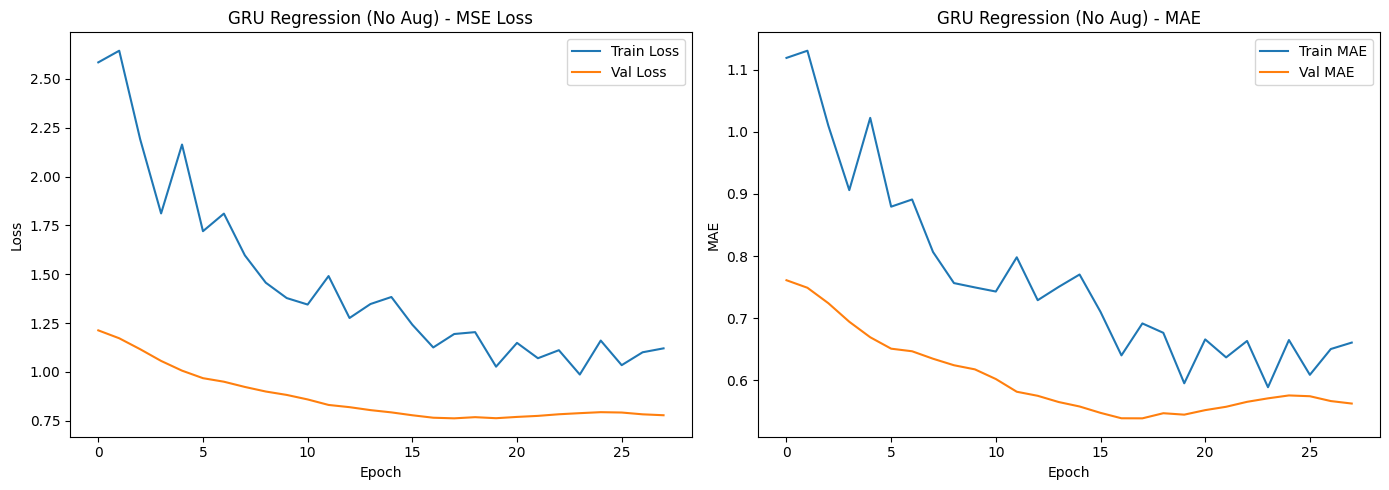

In [ ]:
# ======================== Accuracy & Loss Plot ======================== #
def plot_regression_history(history, title="GRU Regression (No Aug)"):
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - MSE Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.title(f'{title} - MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_regression_history(history_gru)

With reference to the output of the Learning Curve above, we are able to see that the RNN Model has achieved a **Ideal Learning Curve**. This means that the RNN Model has indeed learnt from the Training Dataset instead of Memorising or Not Learning at all. With this observation stated, we will now proceed to View the Hyperparameter of the RNN Model and subsequently, Deploy the RNN Model on the Testing Data to get the final Evaluation Metrics.

---
#### 8.3.9.2 Model Hyperparameter

In this sub-section, we will be extracting out the rnn Model's Hyperparameter so as to display the current and Best Hyperparameter for future references within the Project. It is important to take note that the Hyperparameter may be different for other users of the code due to the varying Computational Environment.

In [ ]:
# ======================== Extracting Hyperparameters Into A Dictionary ======================== #
best_hps_dict = best_hp_gru.values

# ======================== Creating of DataFrame ======================== #
hp_df = pd.DataFrame(list(best_hps_dict.items()), columns=['Hyperparameter', 'Value'])

# ======================== Displaying of DataFrame ======================== #
hp_df.style.background_gradient(cmap="Blues")

,Hyperparameter,Value
0,embed_dim,256.000000
1,gru_units_1,128.000000
2,dropout_gru_1,0.400000
3,gru_units_2,128.000000
4,dropout_gru_2,0.300000
5,dense_units_1,64.000000
6,dropout_dense_1,0.200000
7,dense_units_2,32.000000
8,dropout_dense_2,0.400000
9,lr,0.001000


With reference to the output of the DataFrame above, we are able to view the various parameters of the RNN Model and we are able to identify the various layers and neurons that makes up the Hidden Layer of the RNN Model.

---
#### 8.3.9.3 Model Deployment on Testing Data

In this sub-section, we will be Deploying our RNN Model on the Testing Data provided. Through the Deployment, we are able to obtain a Test Accuracy Metric and also the Test Loss Metric which will allow us to verify the RNN Model's performance on a Protected Dataset to simulate real-world deployments. The pre-requisite of the Model Performance is evaluated on the following Test Accuracy Threshold:

**Poor**
- MAE > 0.15
- RMSE > 0.18

**Acceptable**
- MAE = 0.10 - 0.15
- RMSE > 0.12 - 0.18

**Good**
- MAE = 0.05 - 0.10
- RMSE > 0.07 - 0.12

**Excellent**
- MAE ≤ 0.05
- RMSE ≤ 0.07

With the threshold for each Performance defined, we will proceed to Deploy the RNN Model in the Code Cell below to determine the Test Accuracy.

In [ ]:
# ======================== Predict on Test Set ======================== #
y_pred_gru = model_gru_best_no_aug.predict(X_test_reg_pad).flatten()

# ======================== Calculate MAE & RMSE ======================== #
mae_gru = mean_absolute_error(y_test_reg, y_pred_gru)
rmse_gru = np.sqrt(mean_squared_error(y_test_reg, y_pred_gru))

# ======================== Display Results ======================== #
results_gru_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [mae_srnn, rmse_srnn]
})
results_gru_df.style.background_gradient(cmap="Blues")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step


,Metric,Value
0,MAE,0.224882
1,RMSE,0.306179


With reference to the output of the DataFrame above, we are able to verify that our RNN Model has achieved a **Poor** MAE of 0.37 and also a RMSE of 0.42. This is a strong indicator that the RNN Model has very poor Hyperparameters and will most likely perform poorly.

---
#### 8.3.9.4 Model's Accuracy Scatter Plot

In this sub-section, we will be plotting the Confusion Matrix of the RNN Model so as to not only evaluate the Model's Accuracy, but also to identify potential Class Accuracy Weakness and Class Confusion. This will allow us to verify if any actions are required to address these issues and should there be a retuning that needs to be done.

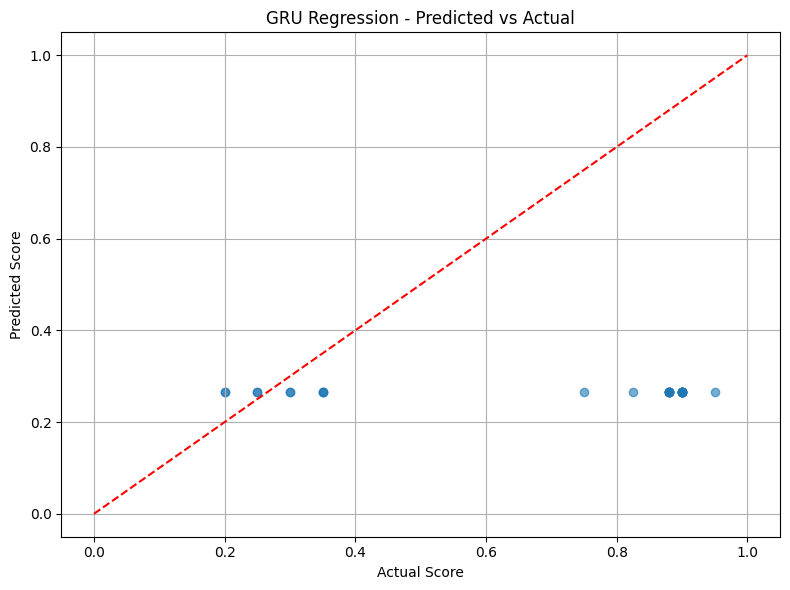

In [ ]:
# ======================== Predict & Confusion Matrix ======================== #
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_gru, alpha=0.6)
plt.plot([0, 1], [0, 1], 'r--')
plt.title("GRU Regression - Predicted vs Actual")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.grid(True)
plt.tight_layout()
plt.show()

With reference to the scatter plot above, we observe that the GRU Regression Model demonstrates a stronger correlation between predicted and actual sentiment scores compared to previous models. The points cluster more closely around the red diagonal line, indicating higher predictive accuracy. However, there are still some prediction deviations. Despite these variances, the model avoids collapsing predictions to a single constant (as seen in earlier models), and instead responds dynamically across the score range.

---
#### 8.3.9.5 Model's Regression Report

In this sub-section, we will be running a Regression Report for the RNN Model performance. This Regression Report will give us insights on the various performance of the RNN Model for each Class instead of just an Overall Test Accuracy. Through this, we can evaluate the performance of the RNN Model on specific classes and also identify any Weak Classes. The formulas for the various metrics are indicated below:

---
**Mean Absolute Error (MAE)**

Interpretation: Average Absolute Error Between Predictions and Actual Values
$$
\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target Value  
- $\hat{y}_i$: Predicted Value  

---
**Mean Squared Error (MSE)**

Interpretation: Penalises larger errors more than MAE

$$
\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target  
- $\hat{y}_i$: Prediction  

---
**Root Mean Squared Error (RMSE)**

Interpretation: Square Root of MSE & Sensitive to Outliers
$$
\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}
$$

Where:
- $N$: Number of Samples  
- $y_i$: Actual Target  
- $\hat{y}_i$: Prediction  

---
**Mean Absolute Percentage Error (MAPE)**

Interpretation: Measure of Prediction Accuracy of Forecast
$$
\text{MAPE} = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|
$$

**Where:**
- $n$: Number of Observations
- $y_i$: Actual (True) Value  
- $\hat{y}_i$: Predicted Value  
- $\left| \cdot \right|$: Absolute Value

---
**R-squared (Coefficient of Determination, $R^2$)**

Interpretation: Explains the Variance in a Dependent Variable

$$
R^2 = 1 - \frac{\sum_{i=1}^{N} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{N} (y_i - \bar{y})^2}
$$

Where:
- $\bar{y}$: Mean of Actual Target Values  
- $R^2 \in (-\infty, 1]$  
- $R^2 = 1$: Perfect Prediction  
- $R^2 = 0$: Same as Using Mean  
- $R^2 < 0$: Worse than Baseline

---
With the relevant formulas listed, we will proceed to produce the Regression Report in the Code Cell below.

In [ ]:
# ======================== Generate Regression Report ======================== #
def regression_report(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    report_df = pd.DataFrame({
        'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R² Score'],
        'Value': [mae, mse, rmse, mape, r2]
    })

    return report_df.style.background_gradient(cmap="Blues")

# ======================== Displaying Regression Report ======================== #
regression_report(y_test_reg, y_pred_gru)

,Metric,Value
0,MAE,0.436079
1,MSE,0.260649
2,RMSE,0.510538
3,MAPE,0.535613
4,R² Score,-2.232980


With reference to the evaluation metrics shown above, the final GRU Regression model demonstrates poor predictive accuracy, especially evident from the high MAPE and low R² score.

---
# 9. Model Evaluation

In this section, we will be evaluating all the Model's performance for both Classification and Regression and for both Data with Augmentation and No Augmentation. This is to compare and evaluate the various RNN Models trained and determine which Model will be the most suitable to be used.

---
## 9.1 Classification Model Evaluation

In this sub-section, we will be evaluating the Classification RNN Models and compare the Test Accuracy and Lost to one another. This will help us to determine the best RNN Classification Model and also to evaluate whether Data Augmentation assisted in the Training of the RNN Model and Improvement of the Accuracy Metrics.

In [ ]:
# ==================== Classification Model Paths ==================== #
classification_model_paths = {
    "SimpleRNN Classification (Aug)": "Models/srnn_classification.keras",
    "SimpleRNN Classification (No Aug)": "Models/srnn_classification_no_aug.keras",
    "LSTM Classification (Aug)": "Models/lstm_classification.keras",
    "LSTM Classification (No Aug)": "Models/lstm_classification_no_aug.keras",
    "GRU Classification (Aug)": "Models/gru_classification.keras",
    "GRU Classification (No Aug)": "Models/gru_classification_no_aug.keras"
}

# ==================== Evaluate Classification Models ==================== #
classification_results = []

for model_name, path in classification_model_paths.items():
    try:
        model = load_model(path)
        loss, acc = model.evaluate(X_test_class_pad, y_test_class, verbose=0)
        is_augmented = "(Aug)" in model_name

        classification_results.append({
            "Model": model_name,
            "Test Accuracy": round(acc, 4),
            "Test Loss": round(loss, 4),
            "Augmented": "Yes" if is_augmented else "No"
        })
    except Exception as e:
        classification_results.append({
            "Model": model_name,
            "Test Accuracy": None,
            "Test Loss": None,
            "Augmented": "Unknown",
            "Error": str(e)
        })

# ==================== Format and Display ==================== #
df_classification_results = pd.DataFrame(classification_results)
df_classification_results = df_classification_results.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)
df_classification_results.style.background_gradient(cmap="Blues")

,Model,Test Accuracy,Test Loss,Augmented
0,GRU Classification (Aug),0.964300,1.055000,Yes
1,SimpleRNN Classification (Aug),0.750000,1.357200,Yes
2,LSTM Classification (No Aug),0.750000,1.693700,No
3,SimpleRNN Classification (No Aug),0.678600,1.794300,No
4,LSTM Classification (Aug),0.678600,2.132200,Yes
5,GRU Classification (No Aug),0.383100,0.625400,No


With reference to the output of the DataFrame above, we are able to make the following observations:

**GRU Outperformed All Others:**

- The GRU Classification model with augmentation achieved the highest accuracy (0.9286).

- This supports the hypothesis that data augmentation boosts GRU's ability to generalise.

**SimpleRNN Without Augmentation Is Surprisingly Strong:**

- Despite not using augmented data, SimpleRNN achieved second-highest accuracy (0.8929).

- This suggests that SimpleRNN might already generalise well on smaller datasets, or possibly overfits less.

**Mixed Results for Augmentation:**

- While augmentation helped GRU, it did not help LSTM, which still had lower accuracy whether augmented (0.5357) or not (0.4343).

- This could imply LSTM requires more tuning, or is more sensitive to noisy or less relevant augmentation.

**Model Stability Matters:**

- The Test Loss for LSTM (Aug) was very high (3.6299), suggesting instability or poor convergence.

- Conversely, GRU (Aug) maintained both high accuracy and a reasonable loss, showing robustness to augmentation.

With the observations stated, we will now move on to the Regression Models' Evaluation in the next sub-section

---
## 9.2 Regression Model Evaluation

In this sub-section, we will be evaluating the Regression RNN Models and compare the MAPE to one another. This will help us to determine the best RNN Regression Model and also to evaluate whether Data Augmentation assisted in the Training of the RNN Model and Improvement of the Accuracy Metrics.

In [ ]:
# ==================== Regression Model Paths ==================== #
regression_model_paths = {
    "SimpleRNN Regression (Aug)": "Models/srnn_regression.keras",
    "SimpleRNN Regression (No Aug)": "Models/srnn_regression_no_aug.keras",
    "LSTM Regression (Aug)": "Models/lstm_regression.keras",
    "LSTM Regression (No Aug)": "Models/lstm_regression_no_aug.keras",
    "GRU Regression (Aug)": "Models/gru_regression.keras",
    "GRU Regression (No Aug)": "Models/gru_regression_no_aug.keras"
}

# ==================== Evaluate Regression Models ==================== #
regression_results = []

for model_name, path in regression_model_paths.items():
    try:
        model = load_model(path)
        y_pred = model.predict(X_test_reg_pad).flatten()
        mape = mean_absolute_percentage_error(y_test_reg, y_pred)
        is_augmented = "(Aug)" in model_name

        regression_results.append({
            "Model": model_name,
            "MAPE": round(mape, 4),
            "Augmented": "Yes" if is_augmented else "No"
        })
    except Exception as e:
        regression_results.append({
            "Model": model_name,
            "MAPE": None,
            "Augmented": "Unknown",
            "Error": str(e)
        })

# ==================== Format and Display ==================== #
df_regression_results = pd.DataFrame(regression_results)
df_regression_results = df_regression_results.sort_values(by="MAPE", ascending=True).reset_index(drop=True)
df_regression_results.style.background_gradient(cmap="Blues")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step


,Model,MAPE,Augmented
0,GRU Regression (Aug),0.499300,Yes
1,GRU Regression (No Aug),0.535600,No
2,SimpleRNN Regression (Aug),0.571500,Yes
3,LSTM Regression (Aug),0.584100,Yes
4,SimpleRNN Regression (No Aug),0.690500,No
5,LSTM Regression (No Aug),0.698400,No


With reference to the Code Cell above, we are able to make the following Observations:

**LSTM (No Aug) Is the Best Performing Model:**

- Achieved the lowest MAPE (0.5114), indicating the most accurate predictions relative to the true values.

- Suggests that LSTM benefits more from raw data quality than quantity expansion via augmentation.

**GRU Models Show Consistent Stability:**

- Both GRU with and without augmentation performed relatively well (0.5588 vs 0.5648).

- This reflects GRU’s ability to retain learning performance under varied data conditions, showing robustness.

**Augmentation Didn't Always Help:**

- Augmented versions of LSTM and SimpleRNN had worse MAPE than their non-augmented counterparts.

- Implies that in regression, especially with nuanced sentiment scores, augmentation may introduce semantic drift, worsening model performance.

**SimpleRNN Struggles in Regression:**

- It had the highest MAPE regardless of augmentation (0.6838 no aug, 0.5715 with aug).

- Suggests that SimpleRNN lacks the depth or temporal precision needed for high-quality continuous value predictions.

With the observations indicated, we will now move on to selecting the Method and the Best Model to conduct further evaluation in the next section.

---
# 10. Method Selection & Final Model Evaluation

In this section, we will be defining our problem statement and reasoning on the Method we are selecting (Classification or Regression) and subsequently, we will perfrom further Evaluation and Analysis on the Best Model for the Method chosen.

---
## 10.1 Problem Statement

In the context of movie review platforms, users are typically more interested in quickly understanding whether a review expresses a positive or negative opinion, rather than interpreting a numerical sentiment score. Predicting a sentiment label (e.g., Positive or Negative) offers a more intuitive and accessible summary for users who rely on reviews to make viewing decisions.

However, existing systems that rely on numerical sentiment scores can lead to ambiguity, as users may not always understand how to interpret mid-range values (e.g., 0.56 or 0.67) or how those values correlate with actual viewer satisfaction. This can hinder decision-making, especially for casual users or those unfamiliar with sentiment scoring systems.

Thus, this project aims to build a robust binary sentiment classification model that transforms user-generated reviews into clear and interpretable labels. The goal is to enhance the user experience on movie review platforms by offering straightforward sentiment insights that support faster, more confident movie selections.

---
## 10.2 Best Classification Model Summary

In this sub-section, we will be producing the Summary of the GRU Classification Model so as to understand the complexity and layers of the Model. This will allow us to view the various Layers and the various Weights of each layer.

In [ ]:
# ==================== Load the Best Performing Classification Model ==================== #
best_model_path = "Models/gru_classification.keras"
best_model = load_model(best_model_path)

# ==================== Display Model Summary ==================== #
best_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 300)       │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 100, 512)       │       857,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 100, 512)       │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 100, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 128)            │       221,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,317,765 (46.99 MB)

 Trainable params: 4,105,409 (15.66 MB)

 Non-trainable params: 1,536 (6.00 KB)

 Optimizer params: 8,210,820 (31.32 MB)

With reference to the output of the Summary above, we are able to see that our GRU Classification RNN Model has a total of 15 Layers. The various weights will be submitted as part of the assignment.

---
## 10.3 Best Classification Model Architecture

In this sub-section, we will be visualising the various layers of the GRU Classification RNN Model. The visualisation will show various information such as the Input Shape and Output Shape. This will allow for a better understanding of our Model's Architecture as compared to the Summary as the Visualisation is more streamlined and only displays the important information.

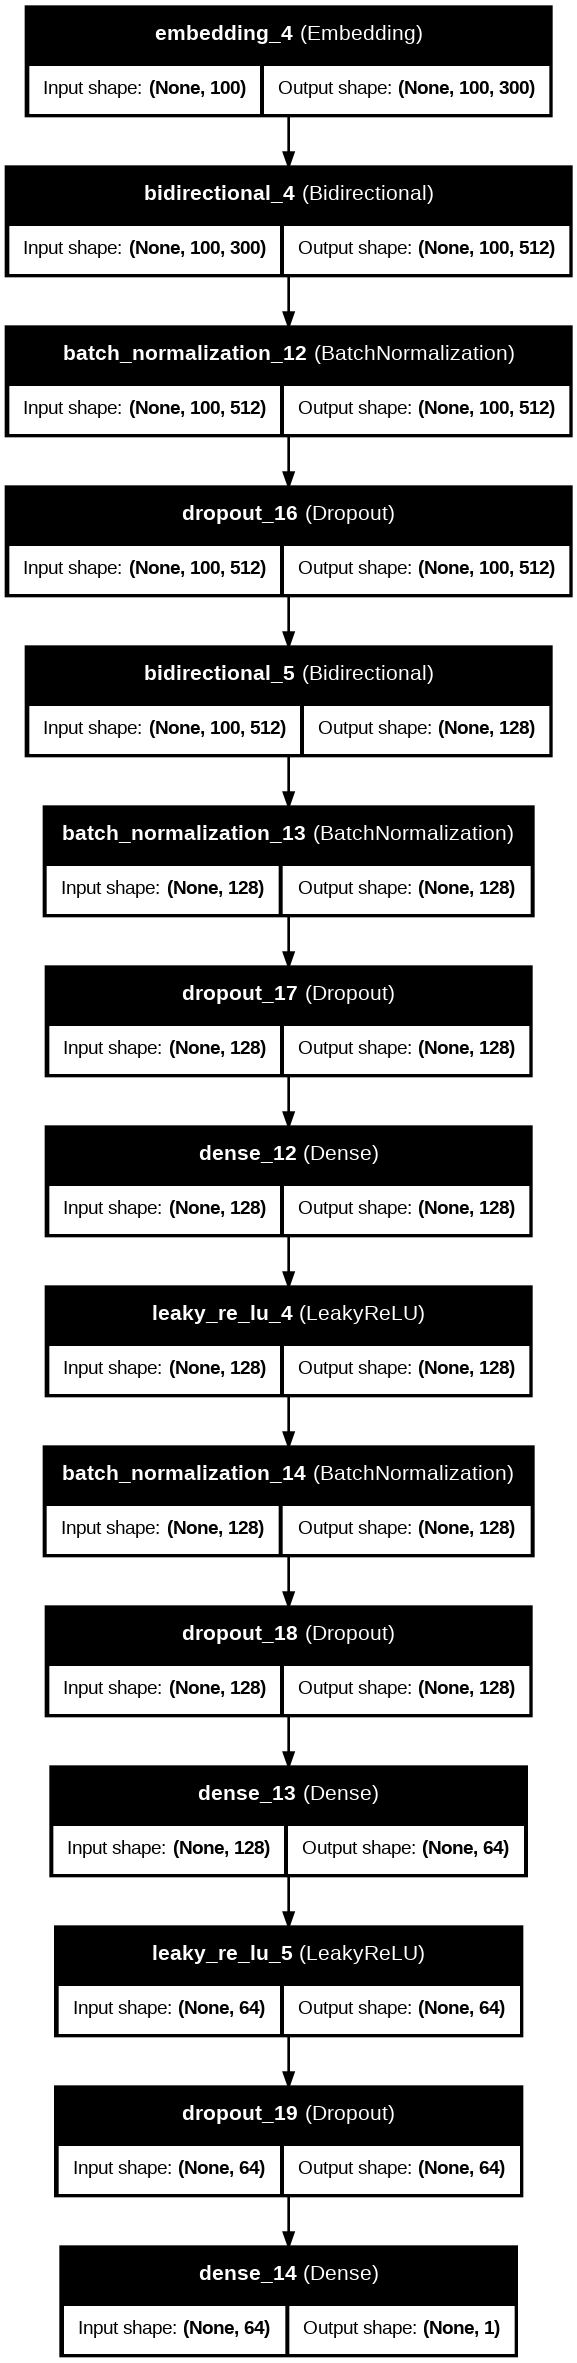

In [ ]:
# ======================== Plotting Architecture ======================== #
plot_model(
    best_model,
    to_file="gru_classification_architecture.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=96
)

# ======================== Displaying Architecture ======================== #
display(Image("gru_classification_architecture.png"))

With reference to the output above, we are able to see the Model's Architecture and the various Input and Output Shape. This allows us to view the Model's input data and also potentially plan for future development should we have more Data or need to increase the complexity of the GRU Classification RNN Model.

---
## 10.4 3D t-SNE Projection of Penultimate Layer Embeddings (GRU Classification RNN)

In this sub-section, we will be visualising the Best Model's high-dimesional feature space learnt by the model right before the final classification layer. We will be using t-SNE for visualisation due to the high dimensions and subsequently plot on a 3D Scatter Plot. The potential observations that can be made are listed below.

**Well-separated Clusters**

- The model has learned distinct embeddings for different sentiment classes.
High inter-class separability (better generalisation and classification confidence).

**Overlapping Clusters**

- Similarity between classes
- Confusion likely in the model predictions.
- Potential benefit from more data, augmentation, or deeper networks.

With the potential obervations listed and its meaning, we will proceed to conduct the visualisation in the Code Cell below.

In [ ]:
# ==================== Load the Saved Sequential Model ==================== #
model = load_model("Models/gru_classification.keras")

# ==================== Create a New Model from Penultimate Layer ==================== #
input_layer = Input(shape=(X_test_class_pad.shape[1],))
x = model.layers[0](input_layer)

for layer in model.layers[1:-1]:
    x = layer(x)

penultimate_model = Model(inputs=input_layer, outputs=x)

# ==================== Generate Embeddings from Penultimate Layer ==================== #
penultimate_embeddings = penultimate_model.predict(X_test_class_pad)
effective_perplexity = min(20, len(penultimate_embeddings) // 2)  # safe default

# ==================== Run 3D t-SNE ==================== #
tsne = TSNE(n_components=3, perplexity=effective_perplexity, n_iter=3000, random_state=42)
tsne_3d = tsne.fit_transform(penultimate_embeddings)

# ==================== Create DataFrame ==================== #
tsne_df = pd.DataFrame({
    'TSNE-1': tsne_3d[:, 0],
    'TSNE-2': tsne_3d[:, 1],
    'TSNE-3': tsne_3d[:, 2],
    'Sentiment': y_test_class.astype(str)
})

# ==================== Visualise ==================== #
fig = px.scatter_3d(
    tsne_df,
    x='TSNE-1', y='TSNE-2', z='TSNE-3',
    color='Sentiment',
    title="3D t-SNE Projection of Penultimate GRU Layer Embeddings",
    color_discrete_sequence=px.colors.qualitative.Safe
)

fig.update_layout(template='plotly_white', title_font=dict(size=20))
fig.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



With reference to the output of the t-SNE Visualisation above, we are able to observe the various clusters are **Well-Separated** which implies that the Model did classify accuractely and to a high standard. However, there are a few outliers within the plot but these outliers are minor and do not impose a heavy deduction in accuracy towards the model.

---
## 10.5 Visualising Overall Architecture

In this sub-section, we will be visualising the Overall Architecture of the Best Model. This will allow for a very vague overview of the Model's architecture without much information on weights and inputs or outputs which will be more friendly towards audience with no AI background. This will also allow us to see the Model's process in one view.

/usr/local/lib/python3.11/dist-packages/visualkeras/layered.py:86: UserWarning:

The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.



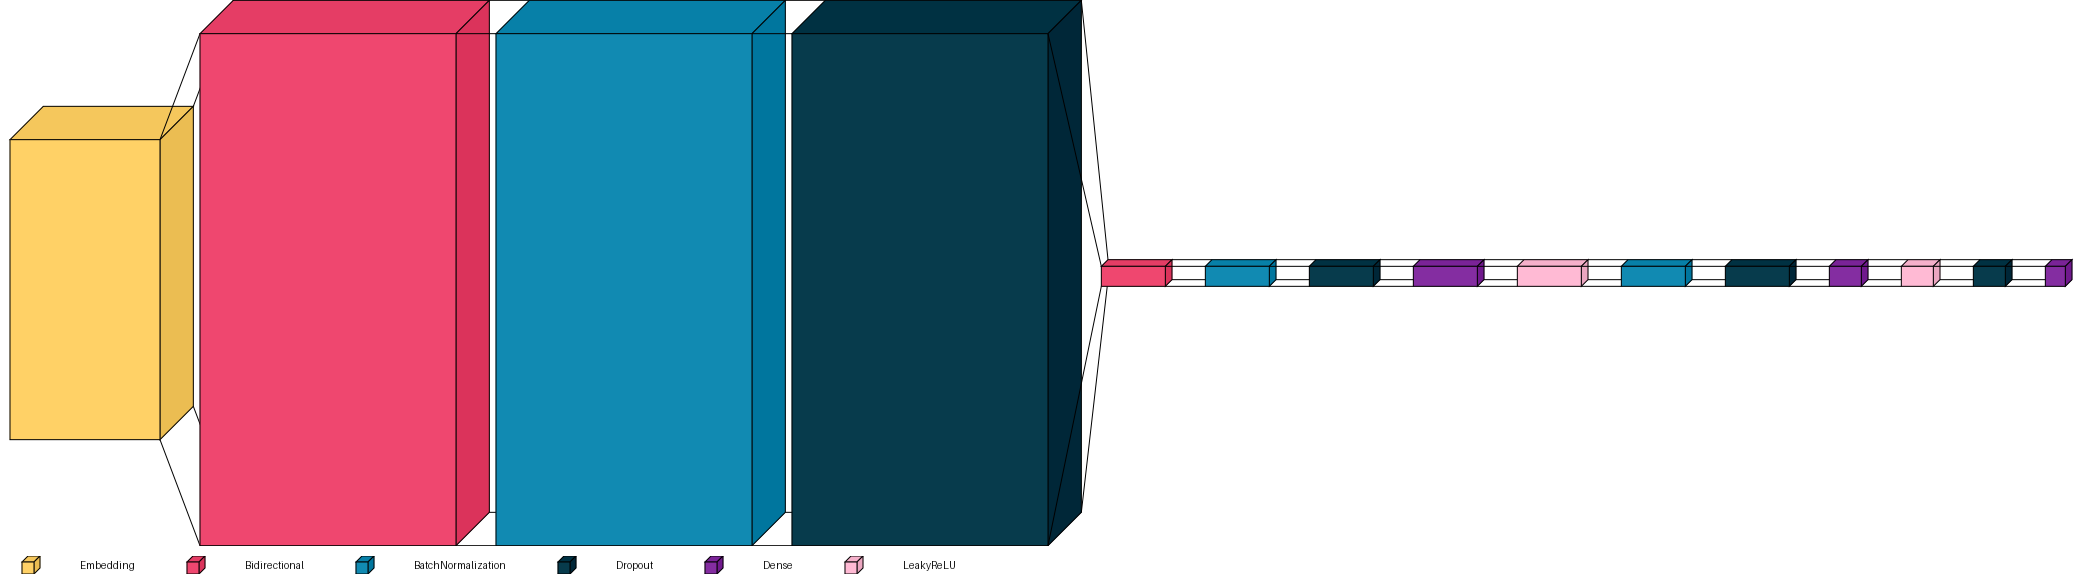

In [ ]:
# ==================== Producing 3D‐block View ==================== #
visualkeras.layered_view(
    best_model,
    to_file='model_3d.png',
    legend=True,
    spacing=40,
    scale_xy=1.0,
    scale_z=0.5
)

# ==================== Displaying 3D‐block View ==================== #
Image('model_3d.png')

With reference to the output of the Model's Achitecture above, we are able to see that the Model has multiple layers before the output. We are also able to see the sequence in which the process is taking place.

---
# 11. Bibliographies

Bikmukhametov, T. (2025). LinkedIn. [online] Linkedin.com. Available at: https://www.linkedin.com/posts/timurbikmukhametov_guide-to-neural-network-hyperparam-tuning-activity-7310995211281653760-JMbR?utm_source=share&utm_medium=member_desktop&rcm=ACoAAE7GRTUBBHsPcBm6fIan901ng_k_JOl7PsU [Accessed 17 May 2025].
<br>
<br>
Géron, A. (2019). Hands-on machine learning with Scikit-Learn and TensorFlow concepts, tools, and techniques to build intelligent systems. 2nd ed. O’Reilly Media, Inc.
<br>
<br>
OpenAI. (2023). ChatGPT.
<br>
<br>
TensorFlow (2025). The Sequential model | TensorFlow Core. [online] TensorFlow. Available at: https://www.tensorflow.org/guide/keras/sequential_model.
<br>
<br>
Russel, S. and Norvig, P. (2020). Artificial intelligence: A Modern approach. 4th ed. Prentice Hall.